<a href="https://colab.research.google.com/github/shifu027/TCC-Pyomo/blob/main/Pymo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# ==============================================================
# TCC – LinDistFlow (Baran & Wu) + Custos + Soft Constraints
# A.1–A.10 (reais) + A.11 (alocação nodal DER)
# Estruturas: Grupo B (Branca), Grupo A Verde, Grupo A Azul
# ==============================================================

# 0) Instalações
!apt-get -y -qq install coinor-cbc >/dev/null
%pip -q install -U pyomo pandas numpy matplotlib

# 1) Imports e Setup
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
from IPython.display import display

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True

ROOT = "/content/TCC_DATA"
os.makedirs(ROOT, exist_ok=True)

# ============================
# PARÂMETROS DE EXECUÇÃO
# ============================
ACTIVE_BANDEIRA = "Verde"               # A.10
TARIF_STRUCTURE_LIST = ["B","GA_VERDE","GA_AZUL"]
PF_LOAD = 0.98
TANPHI = math.tan(math.acos(PF_LOAD))   # Q = P * tan(phi)

# Penalidades (R$) para soft constraints
PEN_V  = 1e6   # tensão (por unidade de folga em V^2)
PEN_I  = 5e5   # ampacidade (por unidade de folga em MW/MVAr)

# ============================
# 2) APÊNDICE A – Tabelas reais
# ============================
# A.1 — Parâmetros Gerais
A1 = pd.DataFrame({
    "parametro":[
        "base_power_MVA","base_voltage_kV","time_step_hours",
        "bess_capacity_kWh","bess_max_charge_kW","bess_max_discharge_kW",
        "bess_efficiency","battery_min_SOC","battery_max_SOC",
        "ev_charge_efficiency","ev_discharge_efficiency",
        "volt_min_pu","volt_max_pu","degradation_cost_R_per_kWh"
    ],
    "valor":[
        1.0, 11.0, 1,
        500, 200, 200,
        0.90, 0.20, 0.90,
        0.95, 0.95,
        0.95, 1.05, 0.05
    ],
    "unidade":[
        "MVA","kV","h","kWh","kW","kW","–","p.u.","p.u.","–","–","p.u.","p.u.","R$/kWh"
    ]
})

# A.2 — Tarifa Branca – B1 EDP ES 2025/26 (R$/kWh)
tb = [0.66784]*24
tb[17]=0.95140; tb[18]=1.41098; tb[19]=1.41098; tb[20]=1.41098; tb[21]=0.95140
A2 = pd.DataFrame({"hora":list(range(24)),"tarifa_R_per_kWh":tb})

# A.3 — Perfil de Carga por Nó (10 nós) – kW
loads = {
0:[80,70,60,50,40,45,80,130,180,170,160,150,150,160,170,180,180,190,200,180,140,100,80,70],
1:[70,60,50,40,35,40,70,110,150,140,130,125,130,140,150,160,160,170,180,160,120,90,70,60],
2:[60,50,40,30,30,35,60, 90,130,120,110,105,120,130,140,150,150,160,150,140,100,80,60,50],
3:[50,40,30,20,25,30,50, 70,100, 90, 85, 80,100,110,120,130,130,140,120,110, 80,60,50,45],
4:[40,35,25,20,20,25,40, 60, 90, 80, 75, 70, 90,100,110,120,120,130,100, 90, 60,50,40,35],
5:[30,25,20,15,15,20,30, 50, 80, 70, 65, 60, 70, 80, 90,100,100,100, 80, 70, 50,40,30,25],
6:[20,15,10,10,10,15,20, 40, 50, 45, 40, 35, 60, 65, 75, 85, 90, 80, 80, 60, 40,30,25,20],
7:[15,10,10,10,10,15,15, 30, 50, 45, 40, 35, 50, 55, 60, 70, 80, 60, 70, 50, 30,20,20,15],
8:[10,10,10,10,10,12,10, 25, 40, 35, 30, 25, 40, 45, 50, 60, 60, 50, 60, 40, 25,20,15,15],
9:[10,10,10,10,10,10,10, 20, 40, 30, 25, 20, 30, 35, 40, 50, 50, 40, 60, 40, 25,20,15,15]
}
A3 = pd.DataFrame({"hora":list(range(24))})
for n in range(10):
    A3[f"no_{n+1}_kW"] = loads[n]

# A.4 — PV (kW)
A4 = pd.DataFrame({"hora":list(range(24)),
                   "pv_kW":[0,0,0,0,0,0,50,100,200,300,400,500,600,550,500,400,300,100,0,0,0,0,0,0]})

# A.5 — Frota de VEs (10)
A5 = pd.DataFrame({
    "VE":list(range(1,11)),
    "cap_kWh":[60,50,55,45,50,40,50,55,45,60],
    "P_carga_kW":[7]*10,
    "P_desc_kW":[7]*10,
    "chegada_h":[18,17,19,18,17,19,18,17,19,18],
    "partida_h":[7,8,7,6,8,7,7,8,6,8],
    "soc_ini_pct":[20,30,15,25,20,10,15,25,30,20],
    "soc_alvo_pct":[80,90,85,80,80,90,80,85,80,90],
    "V2G":[1,0,1,0,0,1,0,0,1,0]
})

# A.6 — Rede radial (p.u., base 11 kV / 1 MVA)
A6 = pd.DataFrame({
    "From":[1,2,3,4,2,6,7,3,9],
    "To"  :[2,3,4,5,6,7,8,9,10],
    "R_pu":[0.010,0.015,0.010,0.020,0.020,0.010,0.015,0.025,0.010],
    "X_pu":[0.030,0.035,0.030,0.040,0.050,0.030,0.040,0.050,0.030],
    "I_max_pu":[2.00,2.00,2.00,2.00,1.50,1.50,1.00,1.50,1.00]
})

# A.7 — Postos
A7 = pd.DataFrame([
    {"Posto":"Ponta","Janela":"18:00–20:59","Observacao":"Só em dias úteis"},
    {"Posto":"Intermediário","Janela":"17:00–17:59 e 21:00–21:59","Observacao":"Só em dias úteis (Tarifa Branca)"},
    {"Posto":"Fora-ponta","Janela":"Demais horas","Observacao":"Finais de semana e feriados: fora-ponta o dia todo"},
])

# A.8 — Grupo A – A4 (base econômica)
A8_verde = pd.DataFrame({
    "Item":[
        "TUSD Demanda (contratada)",
        "Energia – Fora-ponta (TUSD)",
        "Energia – Fora-ponta (TE)",
        "Energia – Fora-ponta (TUSD+TE)",
        "Energia – Ponta (TUSD)",
        "Energia – Ponta (TE)",
        "Energia – Ponta (TUSD+TE)",
    ],
    "Unidade":["R$/kW·mês","R$/MWh","R$/MWh","R$/kWh","R$/MWh","R$/MWh","R$/kWh"],
    "Valor":[31.51,152.16,310.97,0.46313,1298.90,486.99,1.78589]
})
A8_azul = pd.DataFrame({
    "Item":[
        "TUSD Demanda (contratada) – PONTA",
        "TUSD Demanda (contratada) – FORA-PONTA",
        "Energia – TUSD (PONTA+FORA)",
        "Energia – TE (PONTA)",
        "Energia – TE (FORA-PONTA)",
        "Energia (TUSD+TE) – PONTA",
        "Energia (TUSD+TE) – FORA-PONTA",
    ],
    "Unidade":["R$/kW·mês","R$/kW·mês","R$/MWh","R$/MWh","R$/MWh","R$/kWh","R$/kWh"],
    "Valor":[47.16,31.51,152.16,486.99,310.97,0.63915,0.46313]
})

# A.9 — Demanda contratada / Ultrapassagem
A9 = pd.DataFrame([
    {"Modalidade":"Verde (A4)","Posto":"—","TUSD_Demanda_R$/kW_mes":31.51,"Ultrapassagem_2x_R$/kW_mes":63.02},
    {"Modalidade":"Azul (A4)","Posto":"Ponta","TUSD_Demanda_R$/kW_mes":47.16,"Ultrapassagem_2x_R$/kW_mes":94.32},
    {"Modalidade":"Azul (A4)","Posto":"Fora-ponta","TUSD_Demanda_R$/kW_mes":31.51,"Ultrapassagem_2x_R$/kW_mes":63.02},
])

# A.10 — Bandeiras (R$/kWh)
A10 = pd.DataFrame({
    "Bandeira":["Verde","Amarela","Vermelha – Patamar 1","Vermelha – Patamar 2"],
    "Adicional_R$/kWh":[0.00000,0.01885,0.04460,0.07877]
})

# A.11 — Alocação nodal dos DERs
A11_pv   = pd.DataFrame([{"asset":"PV","node":5}])        # PV no nó 5
A11_bess = pd.DataFrame([{"asset":"BESS","node":3}])      # BESS no nó 3
A11_ev   = pd.DataFrame({"VE":list(range(1,11)),"node":[7,7,7,8,8,8,9,9,10,10]})

# (Opcional) CSVs
for df,name in [(A1,"general_parameters.csv"),(A2,"energy_tariffs.csv"),(A3,"load_profiles.csv"),
                (A4,"pv_profiles.csv"),(A5,"ev_parameters.csv"),(A6,"network_parameters.csv"),
                (A7,"posts_tarifarios.csv"),(A8_verde,"tarifas_grupoA_verde.csv"),
                (A8_azul,"tarifas_grupoA_azul.csv"),(A9,"demanda_ultrapassagem.csv"),
                (A10,"bandeiras_tarifarias.csv"),(A11_pv,"der_pv_nodes.csv"),
                (A11_bess,"der_bess_node.csv"),(A11_ev,"der_ev_nodes.csv")]:
    df.to_csv(os.path.join(ROOT,name), index=False)

# ============================
# 3) EXIBIÇÃO (A.1–A.11)
# ============================
print("=== A.1 – Parâmetros Gerais ==="); display(A1)
print("\n=== A.2 – Tarifa Branca (R$/kWh) ==="); display(A2)
print("\n=== A.3 – Perfil de Carga por Nó (kW) ==="); display(A3.head()); print("..."); display(A3.tail())
print("\n=== A.4 – PV (kW) ==="); display(A4)
print("\n=== A.5 – Frota de VEs ==="); display(A5)
print("\n=== A.6 – Rede (p.u.) ==="); display(A6)
print("\n=== A.7 – Postos Tarifários ==="); display(A7)
print("\n=== A.8.1 – Grupo A Verde (A4) ==="); display(A8_verde)
print("\n=== A.8.2 – Grupo A Azul (A4) ==="); display(A8_azul)
print("\n=== A.9 – Demanda Contratada e Ultrapassagem ==="); display(A9)
print("\n=== A.10 – Bandeiras Tarifárias (R$/kWh) ==="); display(A10)
print("\n=== A.11 – Alocação nodal dos DERs ==="); print("PV:"); display(A11_pv); print("BESS:"); display(A11_bess); print("VEs:"); display(A11_ev)

# ============================
# 4) Preparação de dados
# ============================
PARAM = {r["parametro"]: float(r["valor"]) for _,r in A1.iterrows()}
TIME_H = int(PARAM["time_step_hours"])
V_MIN2 = float(PARAM["volt_min_pu"])**2
V_MAX2 = float(PARAM["volt_max_pu"])**2

nodes = list(range(1,11))
P_load_MW = {t:{j: float(A3.loc[t,f"no_{j}_kW"])/1000.0 for j in nodes} for t in range(24)}
Q_load_MVAr = {t:{j: P_load_MW[t][j]*TANPHI for j in nodes} for t in range(24)}

PV_avail_MW = [float(A4.loc[t,"pv_kW"])/1000.0 for t in range(24)]
PV_nodes = list(A11_pv["node"].astype(int).unique())
BESS_node = int(A11_bess["node"].iloc[0])
EV_node_map = {int(r.VE)-1:int(r.node) for _,r in A11_ev.iterrows()}

flag_add = float(A10.loc[A10["Bandeira"]==ACTIVE_BANDEIRA,"Adicional_R$/kWh"].iloc[0])
ponta_hours = {18,19,20}

# Rede
E = [(int(r.From),int(r.To)) for _,r in A6.iterrows()]
R = {(int(r.From),int(r.To)):float(r.R_pu) for _,r in A6.iterrows()}
X = {(int(r.From),int(r.To)):float(r.X_pu) for _,r in A6.iterrows()}
Imax = {(int(r.From),int(r.To)):float(r.I_max_pu) for _,r in A6.iterrows()}

children = {j:[] for j in nodes}
parent_of = {j:None for j in nodes}
for i,j in E:
    children[i].append(j); parent_of[j]=i
SLACK = 1

# ============================
# 5) Tarifas
# ============================
def build_energy_price_array(structure="B"):
    if structure=="B":
        return A2["tarifa_R_per_kWh"].values.astype(float) + flag_add
    if structure=="GA_VERDE":
        v_ponta=float(A8_verde.loc[A8_verde["Item"].str.contains(r"Ponta \(TUSD\+TE\)"),"Valor"].iloc[0])
        v_fp   =float(A8_verde.loc[A8_verde["Item"].str.contains(r"Fora-ponta \(TUSD\+TE\)"),"Valor"].iloc[0])
        arr=np.full(24,v_fp,dtype=float);  [arr.__setitem__(h,v_ponta) for h in ponta_hours]; return arr
    if structure=="GA_AZUL":
        v_ponta=float(A8_azul.loc[A8_azul["Item"].str.contains(r"TUSD\+TE\) – PONTA"),"Valor"].iloc[0])
        v_fp   =float(A8_azul.loc[A8_azul["Item"].str.contains(r"TUSD\+TE\) – FORA-PONTA"),"Valor"].iloc[0])
        arr=np.full(24,v_fp,dtype=float);  [arr.__setitem__(h,v_ponta) for h in ponta_hours]; return arr
    raise ValueError("Estrutura tarifária desconhecida.")

def build_demand_tariff(structure="B"):
    if structure=="B": return {"type":"NONE"}
    if structure=="GA_VERDE":
        t=float(A9.loc[A9["Modalidade"].str.contains("Verde"),"TUSD_Demanda_R$/kW_mes"].iloc[0])
        return {"type":"VERDE","tariff":t}
    if structure=="GA_AZUL":
        t_p=float(A9[(A9["Modalidade"].str.contains("Azul"))&(A9["Posto"]=="Ponta")]["TUSD_Demanda_R$/kW_mes"].iloc[0])
        t_f=float(A9[(A9["Modalidade"].str.contains("Azul"))&(A9["Posto"]=="Fora-ponta")]["TUSD_Demanda_R$/kW_mes"].iloc[0])
        return {"type":"AZUL","tariff_ponta":t_p,"tariff_fp":t_f}
    raise ValueError("Estrutura tarifária desconhecida.")

# ============================
# 6) Plots utilitários
# ============================
def _fmt_brl(x):
    s=f"R$ {x:,.2f}"
    return s.replace(",", "X").replace(".", ",").replace("X",".")

def _fmt_kw(x):
    return (f"{int(round(x))} kW" if abs(x-int(round(x)))<1e-9 else f"{x:.1f} kW".replace(".",","))

def _fmt_pu(x,casas=3): return f"{x:.{casas}f} p.u.".replace(".",",")

def _annotate(ax, rects, fmt, dy=0.02):
    y0,y1=ax.get_ylim(); span=max(y1-y0,1)
    for r in rects:
        v=r.get_height()
        ax.text(r.get_x()+r.get_width()/2, v+dy*span, fmt(v), ha="center", va="bottom", fontsize=10)

def plot_kpis(df_kpis, mode="triptych", out_path="kpi_global.png", dpi=180):
    scen=list(df_kpis.index)
    custo=df_kpis['Custo Total (R$)'].values.astype(float)
    pico =df_kpis['Pico de Demanda (kW)'].values.astype(float)
    vmin =df_kpis['Tensão Mínima (p.u.)'].values.astype(float)
    if mode=="triptych":
        fig,axes=plt.subplots(1,3,figsize=(14,5),dpi=dpi); fig.suptitle("KPIs Globais",fontsize=16)
        ax=axes[0]; r=ax.bar(scen,custo); ax.set_ylabel("R$"); ax.grid(True,axis='y',alpha=0.25); _annotate(ax,r,_fmt_brl)
        ax=axes[1]; r=ax.bar(scen,pico);  ax.set_ylabel("kW"); ax.grid(True,axis='y',alpha=0.25); _annotate(ax,r,_fmt_kw)
        ax=axes[2]; r=ax.bar(scen,vmin);  ax.set_ylabel("p.u."); ax.grid(True,axis='y',alpha=0.25)
        ax.set_ylim(min(0.945,vmin.min()-0.005), max(1.005,vmin.max()+0.005)); _annotate(ax,r,lambda x:_fmt_pu(x,3))
        plt.tight_layout(rect=[0,0,1,0.95]); plt.figtext(0.01,0.01,"Fonte: Simulações do autor (2025).",fontsize=9)
        plt.savefig(out_path,bbox_inches="tight"); plt.close()
    else:
        width=0.36; x=np.arange(len(scen))
        fig,ax1=plt.subplots(figsize=(11.5,6),dpi=dpi); fig.suptitle("KPIs Globais",fontsize=16)
        r1=ax1.bar(x-width/2,custo,width=width,label="Custo Total (R$)"); ax1.set_ylabel("R$"); ax1.grid(True,axis='y',alpha=0.25); ax1.set_xticks(x,scen); _annotate(ax1,r1,_fmt_brl)
        ax2=ax1.twinx(); r2=ax2.bar(x+width/2,pico,width=width,label="Pico de Demanda (kW)",alpha=0.9); ax2.set_ylabel("kW"); _annotate(ax2,r2,_fmt_kw)
        ax3=ax1.twinx(); ax3.spines.right.set_position(("axes",1.12)); ax3.set_ylabel("Tensão mínima (p.u.)")
        ax3.set_ylim(min(0.945,vmin.min()-0.005), max(1.005,vmin.max()+0.005))
        l3,=ax3.plot(x,vmin,marker="o",linestyle="-",linewidth=2.0,label="Tensão Mínima (p.u.)")
        handles=list(r1)+list(r2)+[l3]; labels=[h.get_label() for h in handles]
        ax1.legend(handles,labels,loc="upper center",ncol=3,frameon=False)
        plt.tight_layout(rect=[0,0,1,0.94]); plt.figtext(0.01,0.01,"Fonte: Simulações do autor (2025).",fontsize=9)
        plt.savefig(out_path,bbox_inches="tight"); plt.close()

def plot_soc_v2g(hours, ev_soc_dict, bess_soc, out_path="soc_v2g.png", dpi=180, legend="outside", markers_every=2):
    fig,ax=plt.subplots(figsize=(14,5),dpi=dpi); ax.set_title("SoC – V2G")
    palette=plt.cm.get_cmap("tab20",max(10,len(ev_soc_dict))); markers=['o','s','^','v','<','>','D','p','h','x']
    for i,(name,series) in enumerate(ev_soc_dict.items()):
        kw=dict(linewidth=1.5,alpha=0.95,label=name,color=palette(i))
        if markers_every: kw.update(marker=markers[i%len(markers)], markevery=markers_every)
        ax.plot(hours,series,**kw)
    ax.plot(hours,bess_soc,linestyle="--",linewidth=3.0,alpha=0.95,label="BESS")
    ax.set_xlabel("Hora"); ax.set_ylabel("Energia (MWh)"); ax.grid(True,alpha=0.3)
    if legend=="outside": ax.legend(loc="center left",bbox_to_anchor=(1.01,0.5),frameon=False); plt.tight_layout(rect=[0,0,0.98,0.95])
    else: ax.legend(loc="best",frameon=False); plt.tight_layout(rect=[0,0,1,0.95])
    plt.figtext(0.01,0.01,"Fonte: Simulações do autor (2025).",fontsize=9); plt.savefig(out_path,bbox_inches="tight"); plt.close()

def plot_costs_breakdown(cost_series, title="Custos – cenário", out_path="custos.png", dpi=180, orientation="v"):
    labels=['Energia','Demanda (uso)','Demanda (ultra)','Degradação']
    vals=[float(cost_series.get(k,0.0)) for k in labels]
    fig,ax=plt.subplots(figsize=(9,5),dpi=dpi); ax.set_title(title)
    if orientation=='v':
        r=ax.bar(labels,vals); ax.set_ylabel("R$"); ax.grid(True,axis='y',alpha=0.25); _annotate(ax,r,_fmt_brl)
    else:
        r=ax.barh(labels,vals); ax.set_xlabel("R$"); ax.grid(True,axis='x',alpha=0.25)
        for bar,v in zip(r,vals):
            ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2, _fmt_brl(v), va="center",ha="left",fontsize=10)
    plt.tight_layout(rect=[0,0,1,0.95]); plt.figtext(0.01,0.01,"Fonte: Simulações do autor (2025).",fontsize=9); plt.savefig(out_path,bbox_inches="tight"); plt.close()

def plot_despacho(t, grid_kw, pv_used_kw, bess_dis_kw, ev_dis_kw, demanda_kw, title, out_path):
    fig,ax=plt.subplots(figsize=(13,4.8),dpi=160)
    ax.set_title(title)
    ax.stackplot(t, pv_used_kw, labels=["PV Usado"], alpha=0.45)
    ax.stackplot(t, bess_dis_kw, labels=["BESS Desc."], alpha=0.45)
    ax.stackplot(t, ev_dis_kw, labels=["VE Desc."], alpha=0.45)
    ax.plot(t, grid_kw, label="Rede (Grid)", linewidth=3)
    ax.plot(t, demanda_kw, label="Demanda Total", linewidth=2)
    ax.set_xlabel("Hora"); ax.set_ylabel("Potência (kW)")
    ax.legend(loc="upper left", ncol=3, frameon=False)
    plt.figtext(0.01, 0.01, "Fonte: Simulações do autor (2025).", fontsize=9)
    plt.tight_layout(rect=[0,0,1,0.95]); plt.savefig(out_path,bbox_inches="tight"); plt.close()

# ============================
# 7) Modelo (Pyomo) – LinDistFlow com soft constraints
# ============================
def availability_window(arrival, departure):
    a=np.zeros(24,dtype=int)
    if arrival<=departure: a[arrival:departure]=1
    else: a[:departure]=1; a[arrival:]=1
    return a

def run_scenario(tariff_setup, mode="BAU"):
    T = range(24)
    evs = A5.to_dict(orient="records")

    m = pyo.ConcreteModel()
    m.T = pyo.RangeSet(0,23)
    m.I = pyo.RangeSet(0,len(evs)-1)
    m.N = pyo.Set(initialize=nodes)
    m.E = pyo.Set(initialize=E, dimen=2)

    # Variáveis
    m.P_grid = pyo.Var(m.T, domain=pyo.NonNegativeReals)      # MW (ativa do grid)
    m.Q_grid = pyo.Var(m.T)                                   # MVAr (reativa do grid, sem custo)

    m.P_pv_node = pyo.Var(m.N, m.T, domain=pyo.NonNegativeReals)

    m.Pb_ch  = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.Pb_dis = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.SOCb   = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.yb_ch  = pyo.Var(m.T, domain=pyo.Binary)
    m.yb_dis = pyo.Var(m.T, domain=pyo.Binary)

    m.Pev_ch  = pyo.Var(m.I, m.T, domain=pyo.NonNegativeReals)
    m.Pev_dis = pyo.Var(m.I, m.T, domain=pyo.NonNegativeReals)
    m.SOCev   = pyo.Var(m.I, m.T, domain=pyo.NonNegativeReals)
    m.yev_ch  = pyo.Var(m.I, m.T, domain=pyo.Binary)
    m.yev_dis = pyo.Var(m.I, m.T, domain=pyo.Binary)

    m.Pbr = pyo.Var(m.E, m.T)  # MW
    m.Qbr = pyo.Var(m.E, m.T)  # MVAr
    m.Vsq = pyo.Var(m.N, m.T)  # p.u.^2  (SEM bounds rígidos)

    # Soft constraints (folgas >= 0)
    m.sV_low  = pyo.Var(m.N, m.T, domain=pyo.NonNegativeReals)  # afrouxa limite inferior
    m.sV_high = pyo.Var(m.N, m.T, domain=pyo.NonNegativeReals)  # afrouxa limite superior
    m.sP_pos  = pyo.Var(m.E, m.T, domain=pyo.NonNegativeReals)
    m.sP_neg  = pyo.Var(m.E, m.T, domain=pyo.NonNegativeReals)
    m.sQ_pos  = pyo.Var(m.E, m.T, domain=pyo.NonNegativeReals)
    m.sQ_neg  = pyo.Var(m.E, m.T, domain=pyo.NonNegativeReals)

    # Parâmetros
    eta_b  = float(PARAM["bess_efficiency"])
    eta_ev = float(PARAM["ev_charge_efficiency"])
    eta_ev_dis = float(PARAM["ev_discharge_efficiency"])
    Bcap   = float(PARAM["bess_capacity_kWh"])/1000.0
    SOCmin = float(PARAM["battery_min_SOC"])*Bcap
    SOCmax = float(PARAM["battery_max_SOC"])*Bcap
    dt     = int(PARAM["time_step_hours"])
    deg_R_per_kWh = float(PARAM["degradation_cost_R_per_kWh"])

    if mode=="BAU":
        Pb_max=0.0; Pd_max=0.0; EV_ALLOW_DISCH=False; EV_ALLOW_CH=True
    elif mode=="V1G":
        Pb_max=float(PARAM["bess_max_charge_kW"])/1000.0
        Pd_max=float(PARAM["bess_max_discharge_kW"])/1000.0
        EV_ALLOW_DISCH=False; EV_ALLOW_CH=True
    else:
        Pb_max=float(PARAM["bess_max_charge_kW"])/1000.0
        Pd_max=float(PARAM["bess_max_discharge_kW"])/1000.0
        EV_ALLOW_DISCH=True; EV_ALLOW_CH=True

    # PV total ≤ disponibilidade; PV só nos nós da lista
    m.pv_total_cap = pyo.Constraint(m.T, rule=lambda mdl,t: sum(mdl.P_pv_node[n,t] for n in nodes) <= PV_avail_MW[t])
    for n in nodes:
        if n not in PV_nodes:
            for t in T:
                m.P_pv_node[n,t].setub(0.0)

    # BESS caps/mutex/SOC
    m.bess_ch_cap = pyo.Constraint(m.T, rule=lambda md,t: md.Pb_ch[t] <= Pb_max*md.yb_ch[t])
    m.bess_dis_cap= pyo.Constraint(m.T, rule=lambda md,t: md.Pb_dis[t] <= Pd_max*md.yb_dis[t])
    m.bess_mutex  = pyo.Constraint(m.T, rule=lambda md,t: md.yb_ch[t] + md.yb_dis[t] <= 1)

    def bess_soc(md,t):
        if t==0: return md.SOCb[t] == 0.5*Bcap + (eta_b*md.Pb_ch[t] - (1/eta_b)*md.Pb_dis[t])*dt
        return md.SOCb[t] == md.SOCb[t-1] + (eta_b*md.Pb_ch[t] - (1/eta_b)*md.Pb_dis[t])*dt
    m.bess_soc = pyo.Constraint(m.T, rule=bess_soc)
    m.bess_soc_lo = pyo.Constraint(m.T, rule=lambda md,t: md.SOCb[t] >= SOCmin)
    m.bess_soc_hi = pyo.Constraint(m.T, rule=lambda md,t: md.SOCb[t] <= SOCmax)

    # EV disponibilidade / mutex
    avail = [availability_window(int(ev["chegada_h"]), int(ev["partida_h"])) for ev in evs]
    m.ev_caps  = pyo.ConstraintList()
    m.ev_mutex = pyo.ConstraintList()
    for i in range(len(evs)):
        for t in T:
            if avail[i][t]==1:
                m.ev_caps.add(m.Pev_ch[i,t]  <= (evs[i]["P_carga_kW"]/1000.0 if EV_ALLOW_CH else 0.0) * m.yev_ch[i,t])
                m.ev_caps.add(m.Pev_dis[i,t] <= (evs[i]["P_desc_kW"]/1000.0  if EV_ALLOW_DISCH else 0.0) * m.yev_dis[i,t])
                m.ev_mutex.add(m.yev_ch[i,t] + m.yev_dis[i,t] <= 1)
            else:
                m.ev_caps.add(m.Pev_ch[i,t]  == 0)
                m.ev_caps.add(m.Pev_dis[i,t] == 0)
                m.ev_mutex.add(m.yev_ch[i,t] + m.yev_dis[i,t] == 0)

    # EV SOC
    ev_cap_MWh=[ev["cap_kWh"]/1000.0 for ev in evs]
    soc_lo_b  =[0.05*ev["cap_kWh"]/1000.0 for ev in evs]
    def ev_soc_dyn(md,i,t):
        cap=ev_cap_MWh[i]; soc0=evs[i]["soc_ini_pct"]/100.0*cap
        if t==0: return md.SOCev[i,t] == soc0 + (eta_ev*md.Pev_ch[i,t] - (1/eta_ev_dis)*md.Pev_dis[i,t])*dt
        return md.SOCev[i,t] == md.SOCev[i,t-1] + (eta_ev*md.Pev_ch[i,t] - (1/eta_ev_dis)*md.Pev_dis[i,t])*dt
    m.ev_soc_dyn = pyo.Constraint(m.I, m.T, rule=ev_soc_dyn)
    m.ev_soc_lo  = pyo.Constraint(m.I, m.T, rule=lambda md,i,t: md.SOCev[i,t] >= soc_lo_b[i])
    m.ev_soc_hi  = pyo.Constraint(m.I, m.T, rule=lambda md,i,t: md.SOCev[i,t] <= ev_cap_MWh[i])

    # Meta de SoC
    m.ev_target = pyo.ConstraintList()
    for i in range(len(evs)):
        dep = int(evs[i]["partida_h"])%24
        target = evs[i]["soc_alvo_pct"]/100.0 * ev_cap_MWh[i]
        m.ev_target.add(m.SOCev[i,dep] >= target)

    # -------- LinDistFlow --------
    # Slack: V^2 = 1.0
    m.slack_vs = pyo.Constraint(m.T, rule=lambda md,t: md.Vsq[1,t] == 1.0)

    # Queda de tensão nos ramos
    def vdrop_rule(md, i, j, t):
        return md.Vsq[j,t] == md.Vsq[i,t] - 2*(R[(i,j)]*md.Pbr[(i,j),t] + X[(i,j)]*md.Qbr[(i,j),t])
    m.vdrop = pyo.Constraint(m.E, m.T, rule=vdrop_rule)

    # Limites de tensão (soft)
    m.v_low  = pyo.Constraint(m.N, m.T, rule=lambda md,n,t: md.Vsq[n,t] + md.sV_low[n,t]  >= V_MIN2)
    m.v_high = pyo.Constraint(m.N, m.T, rule=lambda md,n,t: md.Vsq[n,t] - md.sV_high[n,t] <= V_MAX2)

    # Limites |P|, |Q| ≤ Imax (soft)
    m.amp_P_hi = pyo.Constraint(m.E, m.T, rule=lambda md,i,j,t:  md.Pbr[(i,j),t] <=  Imax[(i,j)] + md.sP_pos[(i,j),t])
    m.amp_P_lo = pyo.Constraint(m.E, m.T, rule=lambda md,i,j,t: -md.Pbr[(i,j),t] <=  Imax[(i,j)] + md.sP_neg[(i,j),t])
    m.amp_Q_hi = pyo.Constraint(m.E, m.T, rule=lambda md,i,j,t:  md.Qbr[(i,j),t] <=  Imax[(i,j)] + md.sQ_pos[(i,j),t])
    m.amp_Q_lo = pyo.Constraint(m.E, m.T, rule=lambda md,i,j,t: -md.Qbr[(i,j),t] <=  Imax[(i,j)] + md.sQ_neg[(i,j),t])

    # Geração ativa líquida por nó (MW)
    def Pgen_node(md, n, t):
        pv_n = md.P_pv_node[n,t]
        bess_n = (md.Pb_dis[t] - md.Pb_ch[t]) if n==BESS_node else 0.0
        ev_sum = sum(md.Pev_dis[i,t] - md.Pev_ch[i,t] for i in md.I if EV_node_map[i]==n)
        return pv_n + bess_n + ev_sum

    # Balanço P
    def P_bal_root(md,t):
        out_sum = sum(md.Pbr[(1,k),t] for k in children[1])
        return out_sum == md.P_grid[t] + Pgen_node(md,1,t) - P_load_MW[t][1]
    m.P_bal_root = pyo.Constraint(m.T, rule=P_bal_root)

    m.P_bal_others = pyo.ConstraintList()
    for j in nodes:
        if j==1: continue
        i = parent_of[j]
        for t in T:
            m.P_bal_others.add(
                m.Pbr[(i,j),t] - sum(m.Pbr[(j,k),t] for k in children[j]) ==
                P_load_MW[t][j] - Pgen_node(m,j,t)
            )

    # Balanço Q (com Q_grid no slack)
    m.Q_bal_root = pyo.Constraint(m.T, rule=lambda md,t: sum(md.Qbr[(1,k),t] for k in children[1]) ==
                                                  md.Q_grid[t] - Q_load_MVAr[t][1])
    m.Q_bal_others = pyo.ConstraintList()
    for j in nodes:
        if j==1: continue
        i = parent_of[j]
        for t in T:
            m.Q_bal_others.add(
                m.Qbr[(i,j),t] - sum(m.Qbr[(j,k),t] for k in children[j]) == Q_load_MVAr[t][j]
            )

    # Sem exportação ativa
    m.no_export = pyo.Constraint(m.T, rule=lambda md,t: md.P_grid[t] >= 0)

    # Picos na fronteira
    m.D_peak_all = pyo.Var(domain=pyo.NonNegativeReals)
    m.D_peak_p   = pyo.Var(domain=pyo.NonNegativeReals)
    m.D_peak_f   = pyo.Var(domain=pyo.NonNegativeReals)
    if tariff_setup["demand"]["type"]=="VERDE":
        m.peak_all = pyo.Constraint(m.T, rule=lambda md,t: md.D_peak_all >= md.P_grid[t])
    elif tariff_setup["demand"]["type"]=="AZUL":
        def cons_azul(md,t):
            return (md.D_peak_p >= md.P_grid[t]) if t in {18,19,20} else (md.D_peak_f >= md.P_grid[t])
        m.peak_azul = pyo.Constraint(m.T, rule=cons_azul)

    # Objetivo: energia + demanda + degradação + penalidades (soft)
    price = tariff_setup["price"]
    energy_cost = sum(price[t]*(m.P_grid[t]*1000.0*dt) for t in T)
    if tariff_setup["demand"]["type"]=="VERDE":
        demand_cost = tariff_setup["demand"]["tariff"]*(m.D_peak_all*1000.0)
    elif tariff_setup["demand"]["type"]=="AZUL":
        demand_cost = (tariff_setup["demand"]["tariff_ponta"]*(m.D_peak_p*1000.0) +
                       tariff_setup["demand"]["tariff_fp"]*(m.D_peak_f*1000.0))
    else:
        demand_cost = 0.0

    degr_energy_MW = (
        sum(m.Pb_ch[t]*dt + m.Pb_dis[t]*dt for t in T) +
        sum(sum(m.Pev_ch[i,t]*dt + m.Pev_dis[i,t]*dt for t in T) for i in m.I)
    )
    deg_cost = deg_R_per_kWh * (degr_energy_MW*1000.0) * 0.5

    pen_V = PEN_V*( sum(m.sV_low[n,t] + m.sV_high[n,t] for n in m.N for t in m.T) )
    pen_I = PEN_I*( sum(m.sP_pos[e,t]+m.sP_neg[e,t]+m.sQ_pos[e,t]+m.sQ_neg[e,t] for e in m.E for t in m.T) )

    m.obj = pyo.Objective(expr=energy_cost + demand_cost + deg_cost + pen_V + pen_I, sense=pyo.minimize)

    # Solve
    res = pyo.SolverFactory('cbc').solve(m, tee=False)

    # Extração
    Tlist=list(T)
    grid_MW  = np.array([pyo.value(m.P_grid[t]) for t in Tlist])
    pv_node_MW = {n: np.array([pyo.value(m.P_pv_node[n,t]) for t in Tlist]) for n in nodes}
    pv_total_MW = sum(pv_node_MW[n] for n in nodes)
    bess_ch  = np.array([pyo.value(m.Pb_ch[t])  for t in Tlist])
    bess_dis = np.array([pyo.value(m.Pb_dis[t]) for t in Tlist])
    soc_b    = np.array([pyo.value(m.SOCb[t])   for t in Tlist])
    ev_ch    = np.array([[pyo.value(m.Pev_ch[i,t])  for t in Tlist] for i in range(len(evs))])
    ev_dis   = np.array([[pyo.value(m.Pev_dis[i,t]) for t in Tlist] for i in range(len(evs))])
    soc_ev   = np.array([[pyo.value(m.SOCev[i,t])   for t in Tlist] for i in range(len(evs))])

    vmin = 1.0
    for t in Tlist:
        for n in nodes:
            vmin = min(vmin, math.sqrt(max(0.0, pyo.value(m.Vsq[n,t]))))

    energia_importada_kWh = float(np.sum(grid_MW)*1000.0*dt)
    pv_curtail_kWh        = float(np.sum(np.maximum(0.0, np.array(PV_avail_MW) - pv_total_MW))*1000.0*dt)
    pico_kw               = float(np.max(grid_MW)*1000.0)
    custo_energia         = float(np.sum(grid_MW*1000.0*dt*price))

    # custo de demanda
    if tariff_setup["demand"]["type"]=="VERDE":
        D_all=float(max([pyo.value(m.P_grid[t]) for t in Tlist]))*1000.0
        custo_dem_uso = float(tariff_setup["demand"]["tariff"]*D_all)
        custo_dem_ultra = 0.0
    elif tariff_setup["demand"]["type"]=="AZUL":
        Dp = float(max([pyo.value(m.P_grid[t]) for t in Tlist if t in ponta_hours]))*1000.0 if any(t in ponta_hours for t in Tlist) else 0.0
        Df = float(max([pyo.value(m.P_grid[t]) for t in Tlist if t not in ponta_hours]))*1000.0
        custo_dem_uso = float(tariff_setup["demand"]["tariff_ponta"]*Dp + tariff_setup["demand"]["tariff_fp"]*Df)
        custo_dem_ultra = 0.0
    else:
        custo_dem_uso=0.0; custo_dem_ultra=0.0

    custo_degrad = float(pyo.value(deg_cost))
    custo_total  = float(pyo.value(m.obj))

    # Soma de violações (para diagnóstico)
    viol_V = float(sum(pyo.value(m.sV_low[n,t] + m.sV_high[n,t]) for n in nodes for t in Tlist))
    viol_I = float(sum(pyo.value(m.sP_pos[(i,j),t] + m.sP_neg[(i,j),t] + m.sQ_pos[(i,j),t] + m.sQ_neg[(i,j),t])
                       for (i,j) in E for t in Tlist))

    return {
        "grid_MW":grid_MW,
        "pv_total_MW":pv_total_MW,
        "pv_node_MW":pv_node_MW,
        "bess_ch_MW":bess_ch, "bess_dis_MW":bess_dis, "soc_b_MWh":soc_b,
        "ev_ch_MW":ev_ch, "ev_dis_MW":ev_dis, "soc_ev_MWh":soc_ev,
        "vmin_pu": vmin,
        "viol_V": viol_V, "viol_I": viol_I,
        "kpis":{
            "Custo Total (R$)":custo_total,
            "Custo de Energia (R$)":custo_energia,
            "Custo Demanda – uso (R$)":custo_dem_uso,
            "Custo Demanda – ultrapassagem (R$)":custo_dem_ultra,
            "Custo de Degradação (R$)":custo_degrad,
            "Pico de Demanda (kW)":pico_kw,
            "Energia Importada (kWh)":energia_importada_kWh,
            "Energia PV Curtailada (kWh)":pv_curtail_kWh,
            "Tensão Mínima (p.u.)":vmin
        }
    }

# ============================
# 8) Execução – todas as estruturas
# ============================
def plot_kpis_bundle(df_kpis, suf):
    plot_kpis(df_kpis[["Custo Total (R$)","Pico de Demanda (kW)","Tensão Mínima (p.u.)"]].copy(),
              mode="triptych", out_path=f"kpi_global_triptych_{suf}.png", dpi=180)
    plot_kpis(df_kpis[["Custo Total (R$)","Pico de Demanda (kW)","Tensão Mínima (p.u.)"]].copy(),
              mode="single", out_path=f"kpi_global_single_{suf}.png", dpi=180)

def run_all_for_structure(structure_code):
    price = build_energy_price_array(structure_code)
    demand = build_demand_tariff(structure_code)
    setup = {"structure":structure_code,"price":price,"demand":demand}

    print(f"\n>>> Estrutura tarifária: {structure_code}")
    print("Executando: BAU ...");    res_BAU = run_scenario(setup,"BAU")
    print("Executando: BESS+V1G ...");res_V1G = run_scenario(setup,"V1G")
    print("Executando: BESS+V2G ...");res_V2G = run_scenario(setup,"V2G")
    print("Cenários executados.")
    print(f"Violação (Σ folgas) – BAU: V={res_BAU['viol_V']:.4f}, I={res_BAU['viol_I']:.4f} | "
          f"V1G: V={res_V1G['viol_V']:.4f}, I={res_V1G['viol_I']:.4f} | "
          f"V2G: V={res_V2G['viol_V']:.4f}, I={res_V2G['viol_I']:.4f}")

    df_kpis = pd.DataFrame({
        "Custo Total (R$)":[res_BAU["kpis"]["Custo Total (R$)"],res_V1G["kpis"]["Custo Total (R$)"],res_V2G["kpis"]["Custo Total (R$)"]],
        "Custo de Energia (R$)":[res_BAU["kpis"]["Custo de Energia (R$)"],res_V1G["kpis"]["Custo de Energia (R$)"],res_V2G["kpis"]["Custo de Energia (R$)"]],
        "Custo Demanda – uso (R$)":[res_BAU["kpis"]["Custo Demanda – uso (R$)"],res_V1G["kpis"]["Custo Demanda – uso (R$)"],res_V2G["kpis"]["Custo Demanda – uso (R$)"]],
        "Custo Demanda – ultrapassagem (R$)":[res_BAU["kpis"]["Custo Demanda – ultrapassagem (R$)"],res_V1G["kpis"]["Custo Demanda – ultrapassagem (R$)"],res_V2G["kpis"]["Custo Demanda – ultrapassagem (R$)"]],
        "Custo de Degradação (R$)":[res_BAU["kpis"]["Custo de Degradação (R$)"],res_V1G["kpis"]["Custo de Degradação (R$)"],res_V2G["kpis"]["Custo de Degradação (R$)"]],
        "Pico de Demanda (kW)":[res_BAU["kpis"]["Pico de Demanda (kW)"],res_V1G["kpis"]["Pico de Demanda (kW)"],res_V2G["kpis"]["Pico de Demanda (kW)"]],
        "Energia Importada (kWh)":[res_BAU["kpis"]["Energia Importada (kWh)"],res_V1G["kpis"]["Energia Importada (kWh)"],res_V2G["kpis"]["Energia Importada (kWh)"]],
        "Energia PV Curtailada (kWh)":[res_BAU["kpis"]["Energia PV Curtailada (kWh)"],res_V1G["kpis"]["Energia PV Curtailada (kWh)"],res_V2G["kpis"]["Energia PV Curtailada (kWh)"]],
        "Tensão Mínima (p.u.)":[res_BAU["kpis"]["Tensão Mínima (p.u.)"],res_V1G["kpis"]["Tensão Mínima (p.u.)"],res_V2G["kpis"]["Tensão Mínima (p.u.)"]],
    }, index=["BAU","BESS+V1G","BESS+V2G"])
    df_kpis["Redução Custo Total (%)"] = (1 - df_kpis["Custo Total (R$)"]/df_kpis.loc["BAU","Custo Total (R$)"])*100
    df_kpis["Redução Pico Demanda (%)"] = (1 - df_kpis["Pico de Demanda (kW)"]/df_kpis.loc["BAU","Pico de Demanda (kW)"])*100

    print("\n--- Tabela 4.1 – Indicadores de Desempenho (KPIs) ---")
    display(df_kpis.round(3))

    suf = structure_code
    plot_kpis_bundle(df_kpis, suf)

    # SoC – V2G
    ev_soc_dict = {f"VE {i+1}": list(res_V2G["soc_ev_MWh"][i]) for i in range(10)}
    plot_soc_v2g(list(range(24)), ev_soc_dict, list(res_V2G["soc_b_MWh"]),
                 out_path=f"soc_v2g_legenda_fora_{suf}.png", legend="outside", markers_every=2)
    plot_soc_v2g(list(range(24)), ev_soc_dict, list(res_V2G["soc_b_MWh"]),
                 out_path=f"soc_v2g_legenda_dentro_{suf}.png", legend="inside", markers_every=3)

    # Custos
    def custos_from(res):
        return {
            "Energia": res["kpis"]["Custo de Energia (R$)"],
            "Demanda (uso)": res["kpis"]["Custo Demanda – uso (R$)"],
            "Demanda (ultra)": res["kpis"]["Custo Demanda – ultrapassagem (R$)"],
            "Degradação": res["kpis"]["Custo de Degradação (R$)"]
        }
    plot_costs_breakdown(custos_from(res_BAU), title=f"Custos – BAU [{suf}]", out_path=f"custos_BAU_vertical_{suf}.png", orientation="v")
    plot_costs_breakdown(custos_from(res_V1G), title=f"Custos – BESS+V1G [{suf}]", out_path=f"custos_V1G_vertical_{suf}.png", orientation="v")
    plot_costs_breakdown(custos_from(res_V2G), title=f"Custos – BESS+V2G [{suf}]", out_path=f"custos_V2G_vertical_{suf}.png", orientation="v")
    plot_costs_breakdown(custos_from(res_V2G), title=f"Custos – BESS+V2G (horizontal) [{suf}]", out_path=f"custos_V2G_horizontal_{suf}.png", orientation="h")

    # Despachos
    H = list(range(24))
    DEM_kW = [sum(A3.loc[t,c] for c in A3.columns if c.startswith("no_")) for t in H]
    for name,res in [("BAU",res_BAU),("V1G",res_V1G),("V2G",res_V2G)]:
        plot_despacho(H, res["grid_MW"]*1000.0, res["pv_total_MW"]*1000.0,
                      res["bess_dis_MW"]*1000.0, res["ev_dis_MW"].sum(axis=0)*1000.0,
                      DEM_kW, f"Despacho – {name} [{suf}]", f"despacho_{name}_{suf}.png")

    return df_kpis

# Cabeçalho
print("Ambiente pronto.")
peak_kw_18 = int(sum(A3.loc[18,c] for c in A3.columns if c.startswith("no_")))
print(f"Pico da carga agregada @18h: {peak_kw_18} kW")
print(f"Nós da rede: {sorted(set(A6['From']).union(set(A6['To'])))} | SLACK: 1")
print(f"PV nodes: {list(A11_pv['node'])} | BESS node: {int(A11_bess['node'].iloc[0])} | EV map (VE→nó): {dict(zip(A11_ev['VE'],A11_ev['node']))}")

# Rodadas
df_kpis_results = {}
for s in TARIF_STRUCTURE_LIST:
    df_kpis_results[s] = run_all_for_structure(s)

print("\nFiguras geradas (por estrutura):")
for s in TARIF_STRUCTURE_LIST:
    for f in [f"kpi_global_triptych_{s}.png", f"kpi_global_single_{s}.png",
              f"soc_v2g_legenda_fora_{s}.png", f"soc_v2g_legenda_dentro_{s}.png",
              f"custos_BAU_vertical_{s}.png", f"custos_V1G_vertical_{s}.png", f"custos_V2G_vertical_{s}.png",
              f"custos_V2G_horizontal_{s}.png",
              f"despacho_BAU_{s}.png", f"despacho_V1G_{s}.png", f"despacho_V2G_{s}.png"]:
        print(" -", f)


=== A.1 – Parâmetros Gerais ===


,parametro,valor,unidade
0,base_power_MVA,1.00,MVA
1,base_voltage_kV,11.00,kV
2,time_step_hours,1.00,h
3,bess_capacity_kWh,500.00,kWh
4,bess_max_charge_kW,200.00,kW
5,bess_max_discharge_kW,200.00,kW
6,bess_efficiency,0.90,–
7,battery_min_SOC,0.20,p.u.
8,battery_max_SOC,0.90,p.u.
9,ev_charge_efficiency,0.95,–



=== A.2 – Tarifa Branca (R$/kWh) ===


,hora,tarifa_R_per_kWh
0,0,0.66784
1,1,0.66784
2,2,0.66784
3,3,0.66784
4,4,0.66784
5,5,0.66784
6,6,0.66784
7,7,0.66784
8,8,0.66784
9,9,0.66784



=== A.3 – Perfil de Carga por Nó (kW) ===


...

/tmp/ipython-input-3018489686.py:292: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette=plt.cm.get_cmap("tab20",max(10,len(ev_soc_dict))); markers=['o','s','^','v','<','>','D','p','h','x']



>>> Estrutura tarifária: GA_AZUL
Executando: BAU ...
Executando: BESS+V1G ...
Executando: BESS+V2G ...
Cenários executados.
Violação (Σ folgas) – BAU: V=0.0000, I=0.0000 | V1G: V=0.0000, I=0.0000 | V2G: V=0.0000, I=0.0000

--- Tabela 4.1 – Indicadores de Desempenho (KPIs) ---


,Custo Total (R$),Custo de Energia (R$),Custo Demanda – uso (R$),Custo Demanda – ultrapassagem (R$),Custo de Degradação (R$),Pico de Demanda (kW),Energia Importada (kWh),Energia PV Curtailada (kWh),Tensão Mínima (p.u.),Redução Custo Total (%),Redução Pico Demanda (%)
BAU,90186.662,6162.008,84016.20,0.0,8.454,1100.0,12275.158,0.0,0.968,0.000,0.000
BESS+V1G,77699.311,6090.877,71586.55,0.0,21.885,940.0,12182.380,0.0,0.972,13.846,14.545
BESS+V2G,74199.543,5883.087,68285.35,0.0,31.106,870.0,11813.530,0.0,0.973,17.727,20.909


/tmp/ipython-input-3018489686.py:292: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette=plt.cm.get_cmap("tab20",max(10,len(ev_soc_dict))); markers=['o','s','^','v','<','>','D','p','h','x']



Figuras geradas (por estrutura):
 - kpi_global_triptych_B.png
 - kpi_global_single_B.png
 - soc_v2g_legenda_fora_B.png
 - soc_v2g_legenda_dentro_B.png
 - custos_BAU_vertical_B.png
 - custos_V1G_vertical_B.png
 - custos_V2G_vertical_B.png
 - custos_V2G_horizontal_B.png
 - despacho_BAU_B.png
 - despacho_V1G_B.png
 - despacho_V2G_B.png
 - kpi_global_triptych_GA_VERDE.png
 - kpi_global_single_GA_VERDE.png
 - soc_v2g_legenda_fora_GA_VERDE.png
 - soc_v2g_legenda_dentro_GA_VERDE.png
 - custos_BAU_vertical_GA_VERDE.png
 - custos_V1G_vertical_GA_VERDE.png
 - custos_V2G_vertical_GA_VERDE.png
 - custos_V2G_horizontal_GA_VERDE.png
 - despacho_BAU_GA_VERDE.png
 - despacho_V1G_GA_VERDE.png
 - despacho_V2G_GA_VERDE.png
 - kpi_global_triptych_GA_AZUL.png
 - kpi_global_single_GA_AZUL.png
 - soc_v2g_legenda_fora_GA_AZUL.png
 - soc_v2g_legenda_dentro_GA_AZUL.png
 - custos_BAU_vertical_GA_AZUL.png
 - custos_V1G_vertical_GA_AZUL.png
 - custos_V2G_vertical_GA_AZUL.png
 - custos_V2G_horizontal_GA_AZUL.png
 

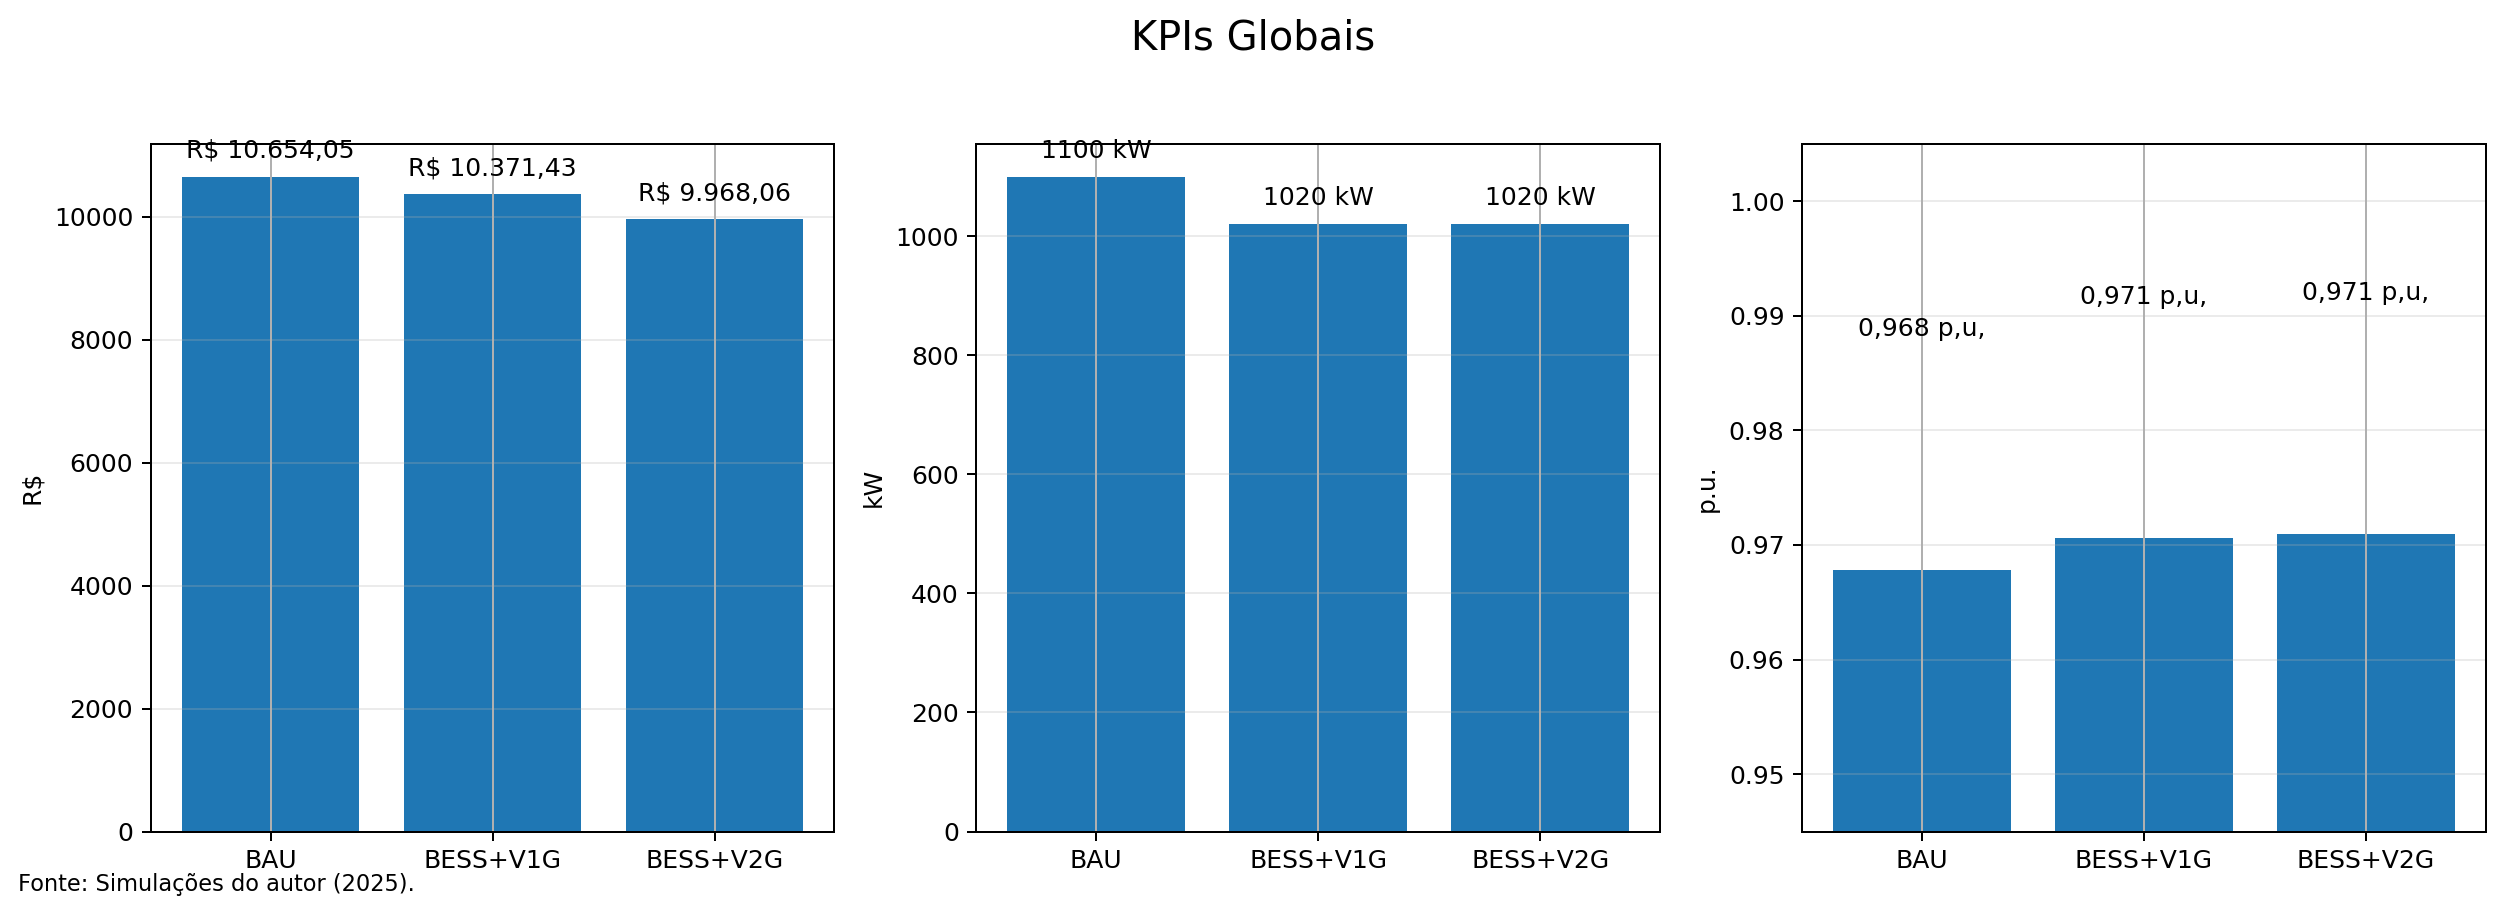

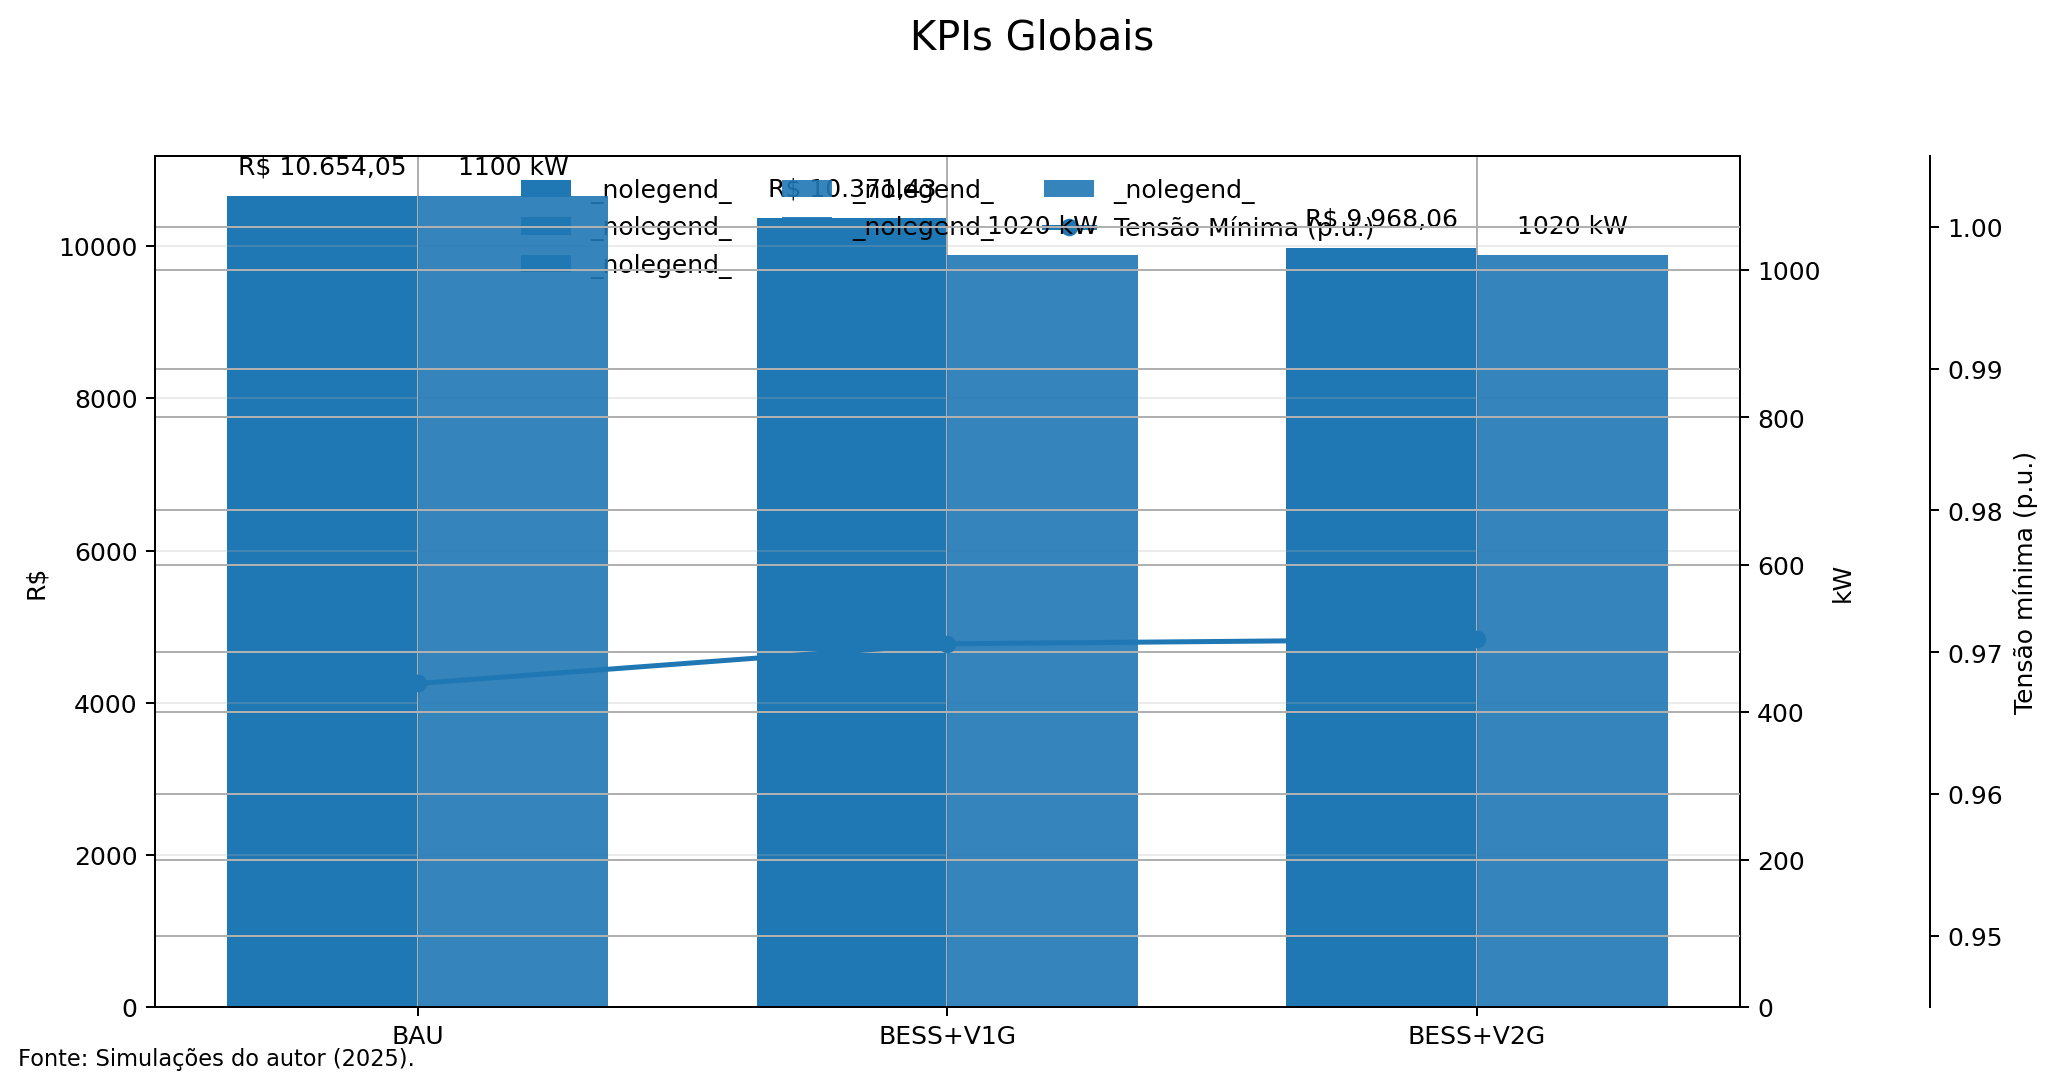

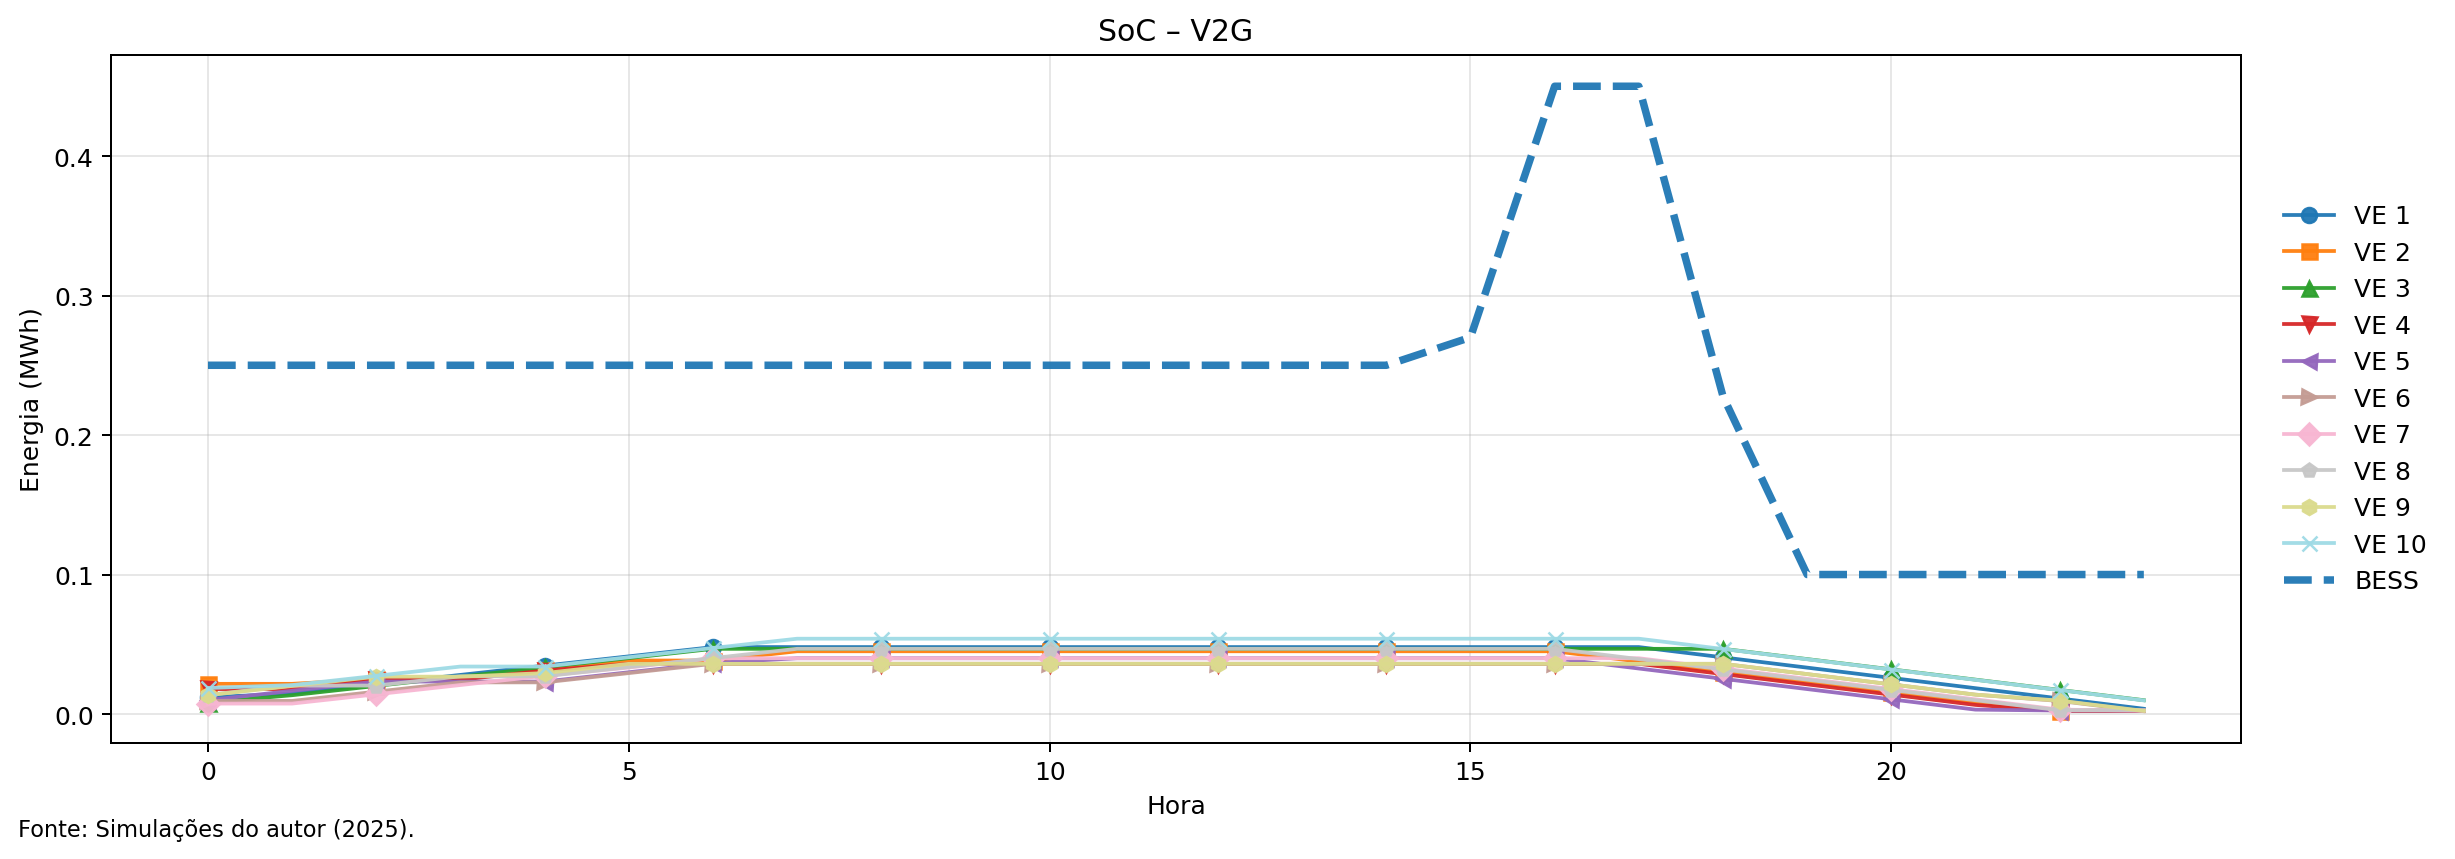

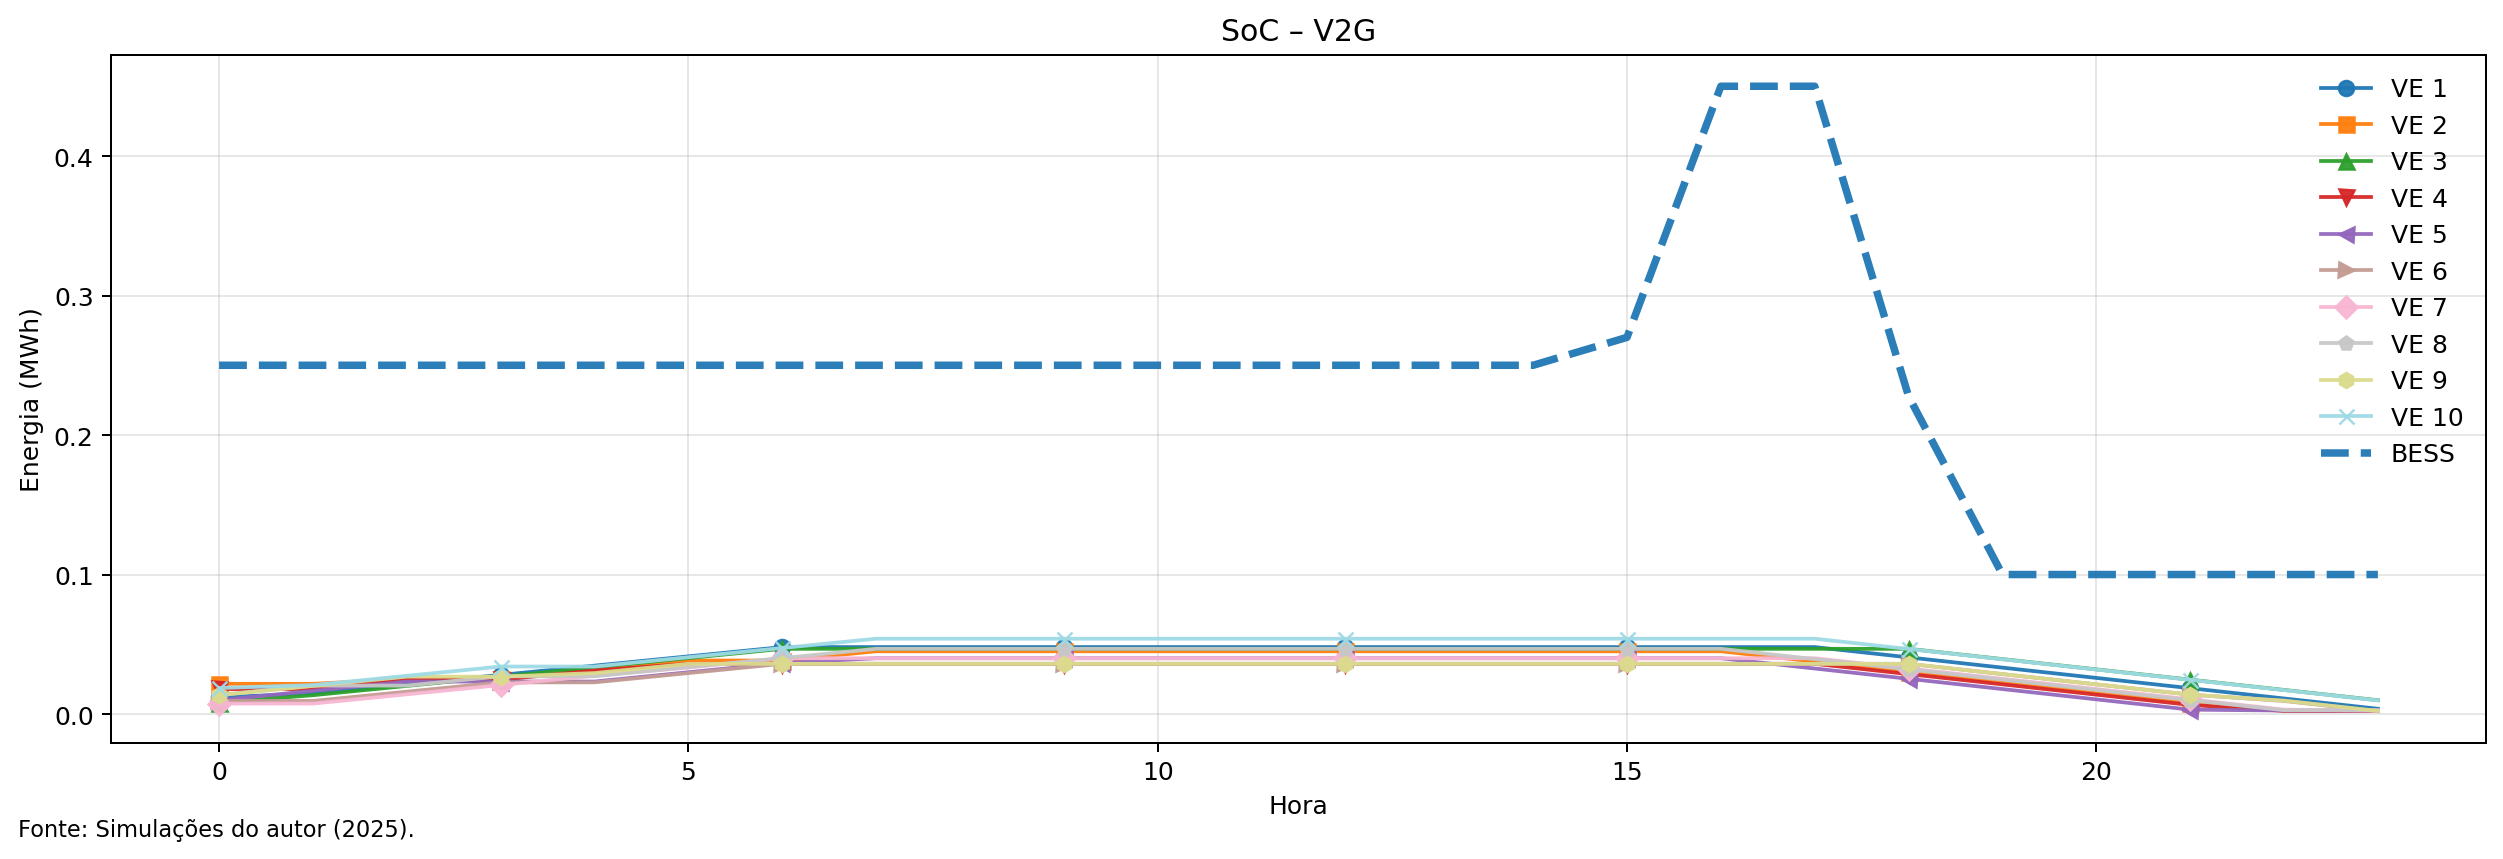

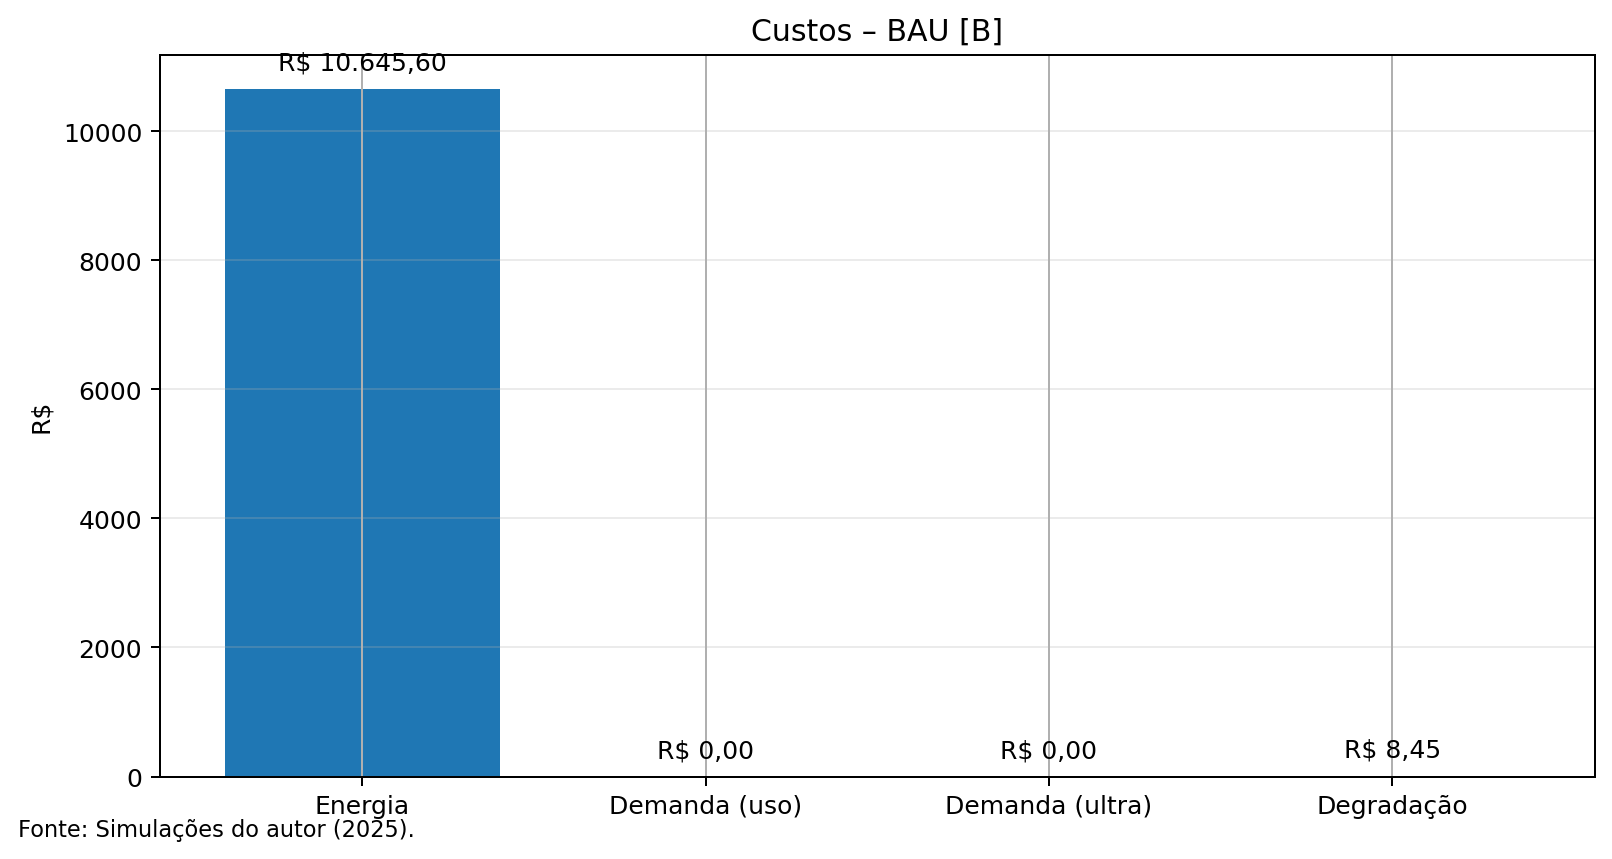

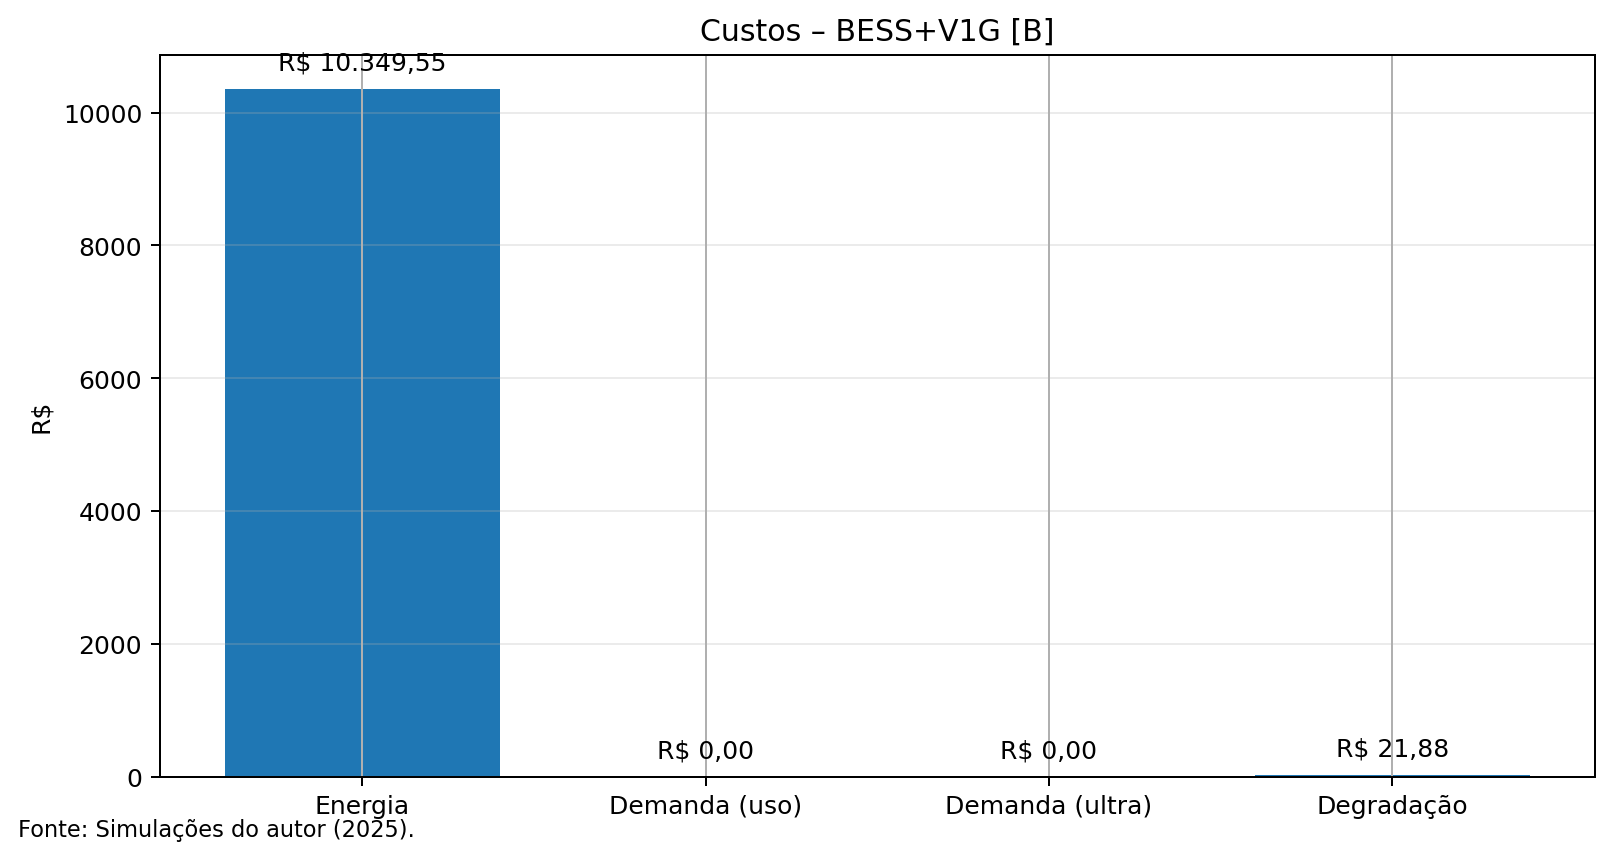

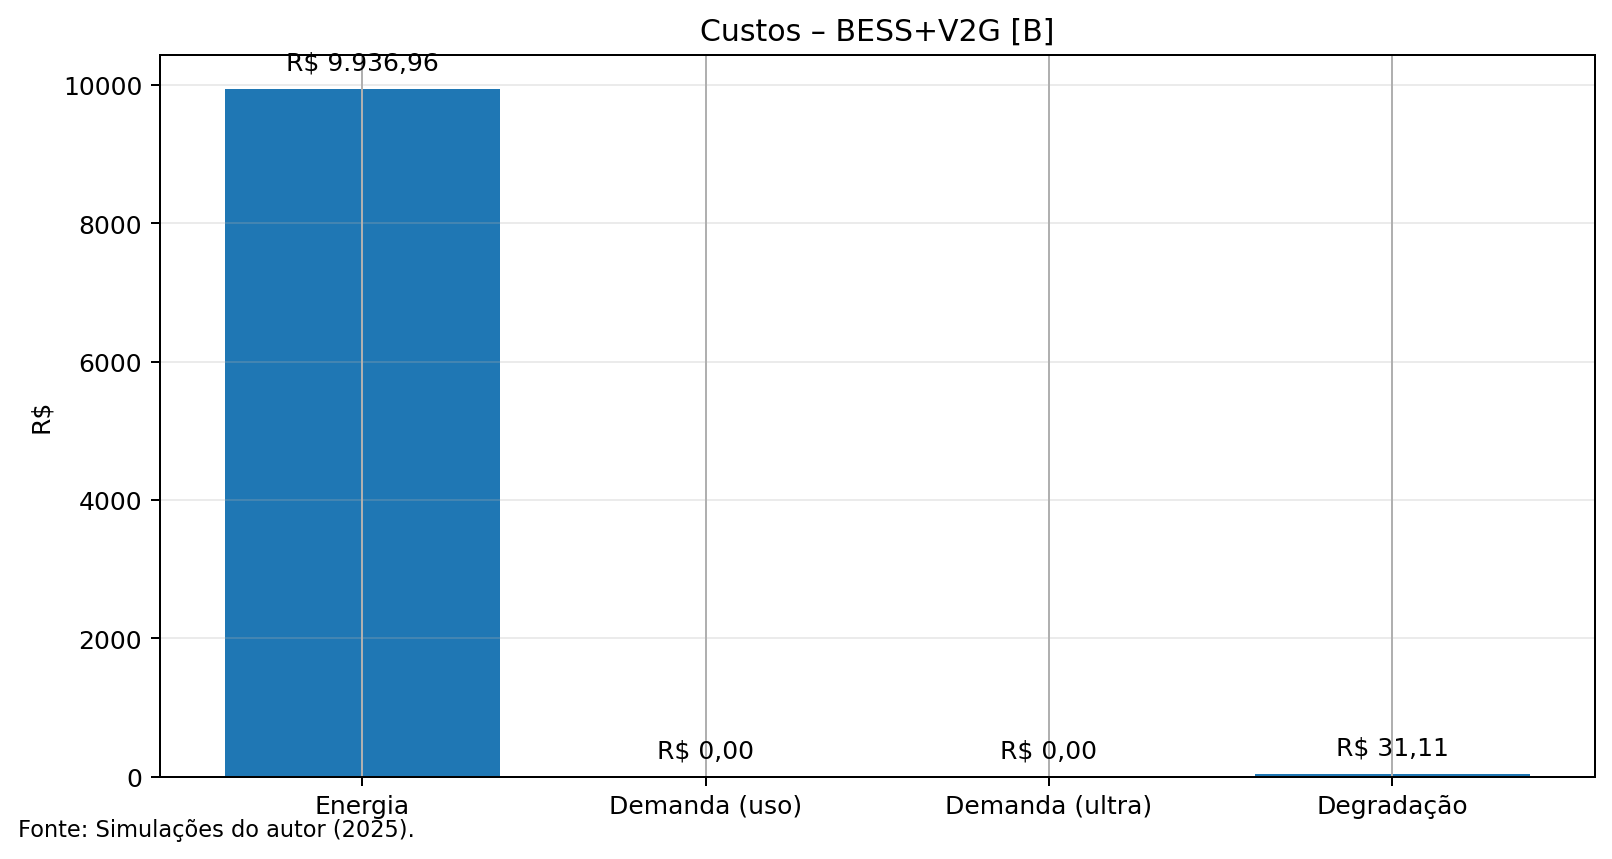

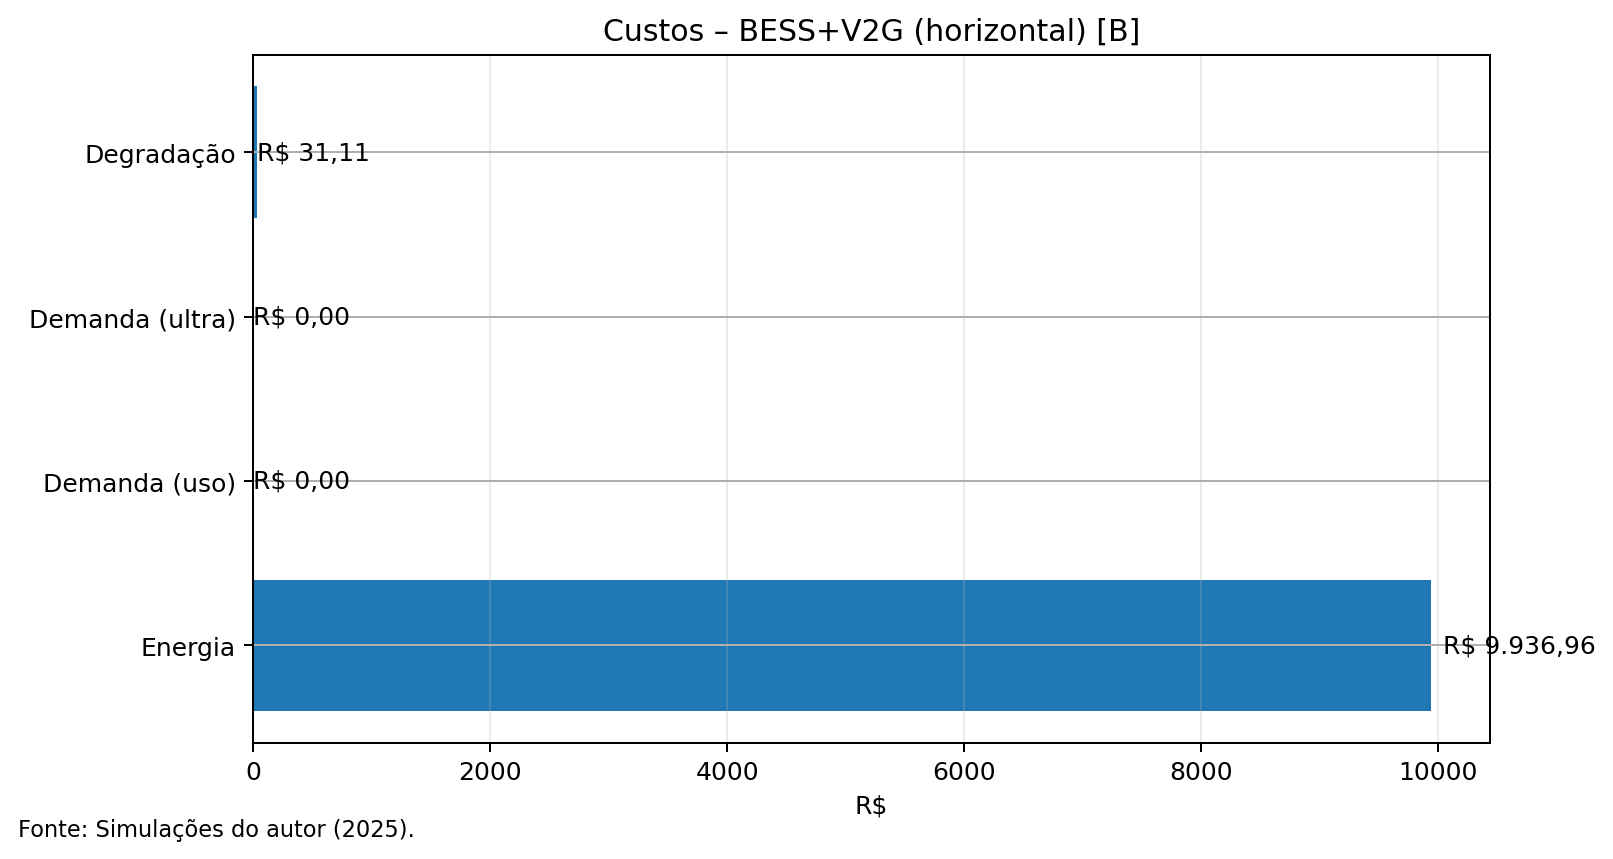

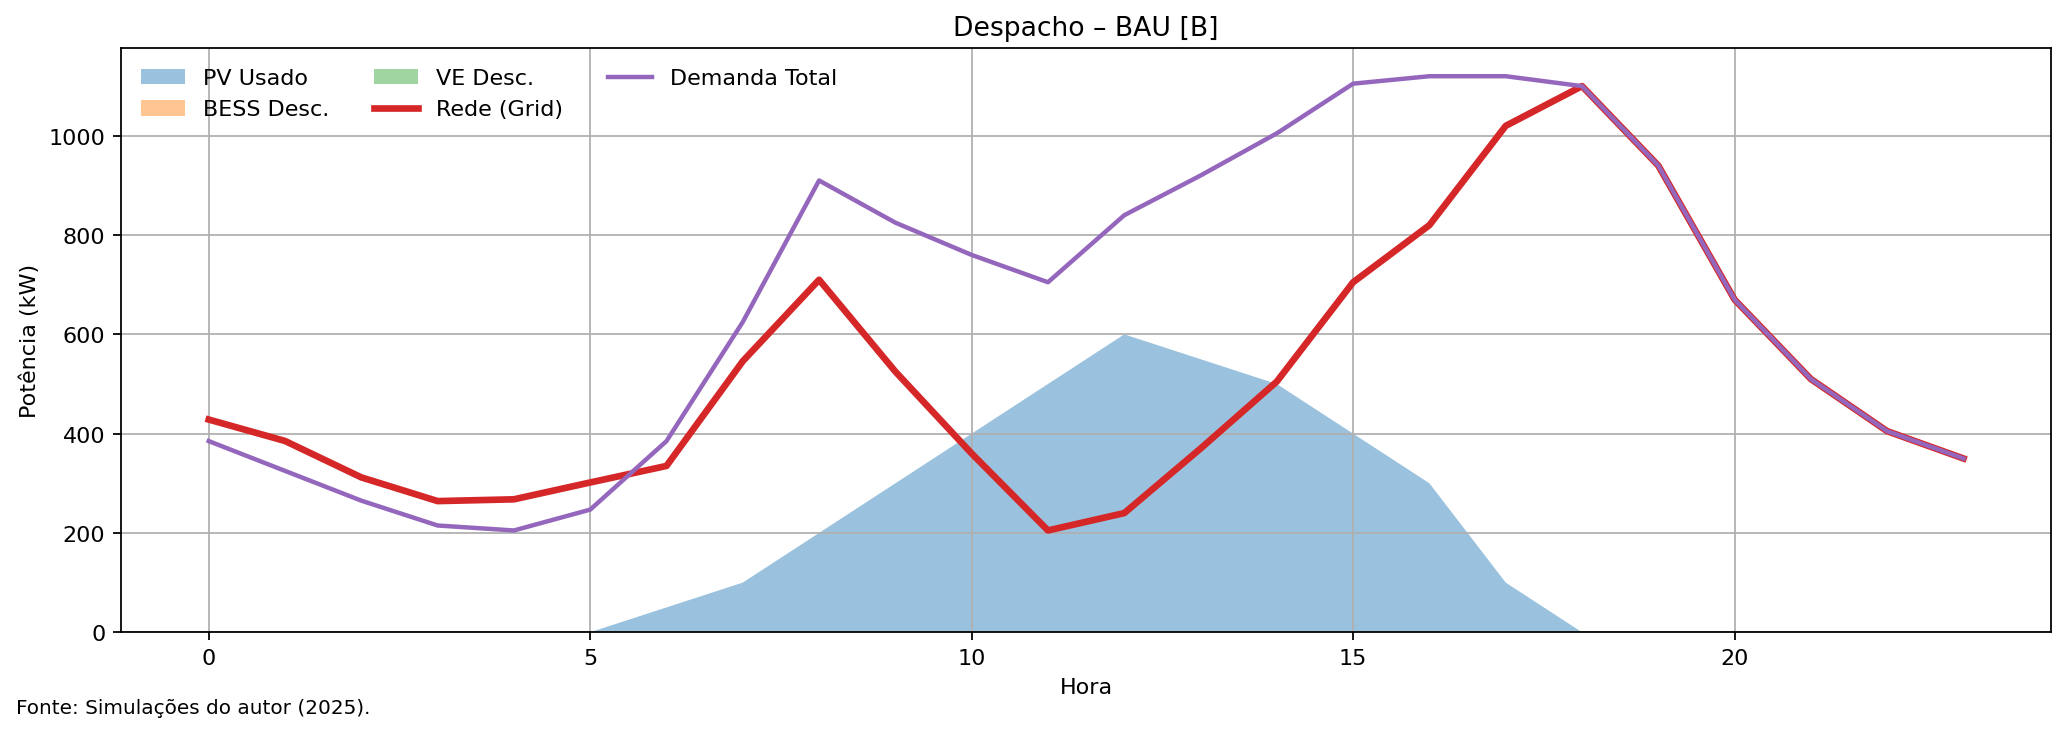

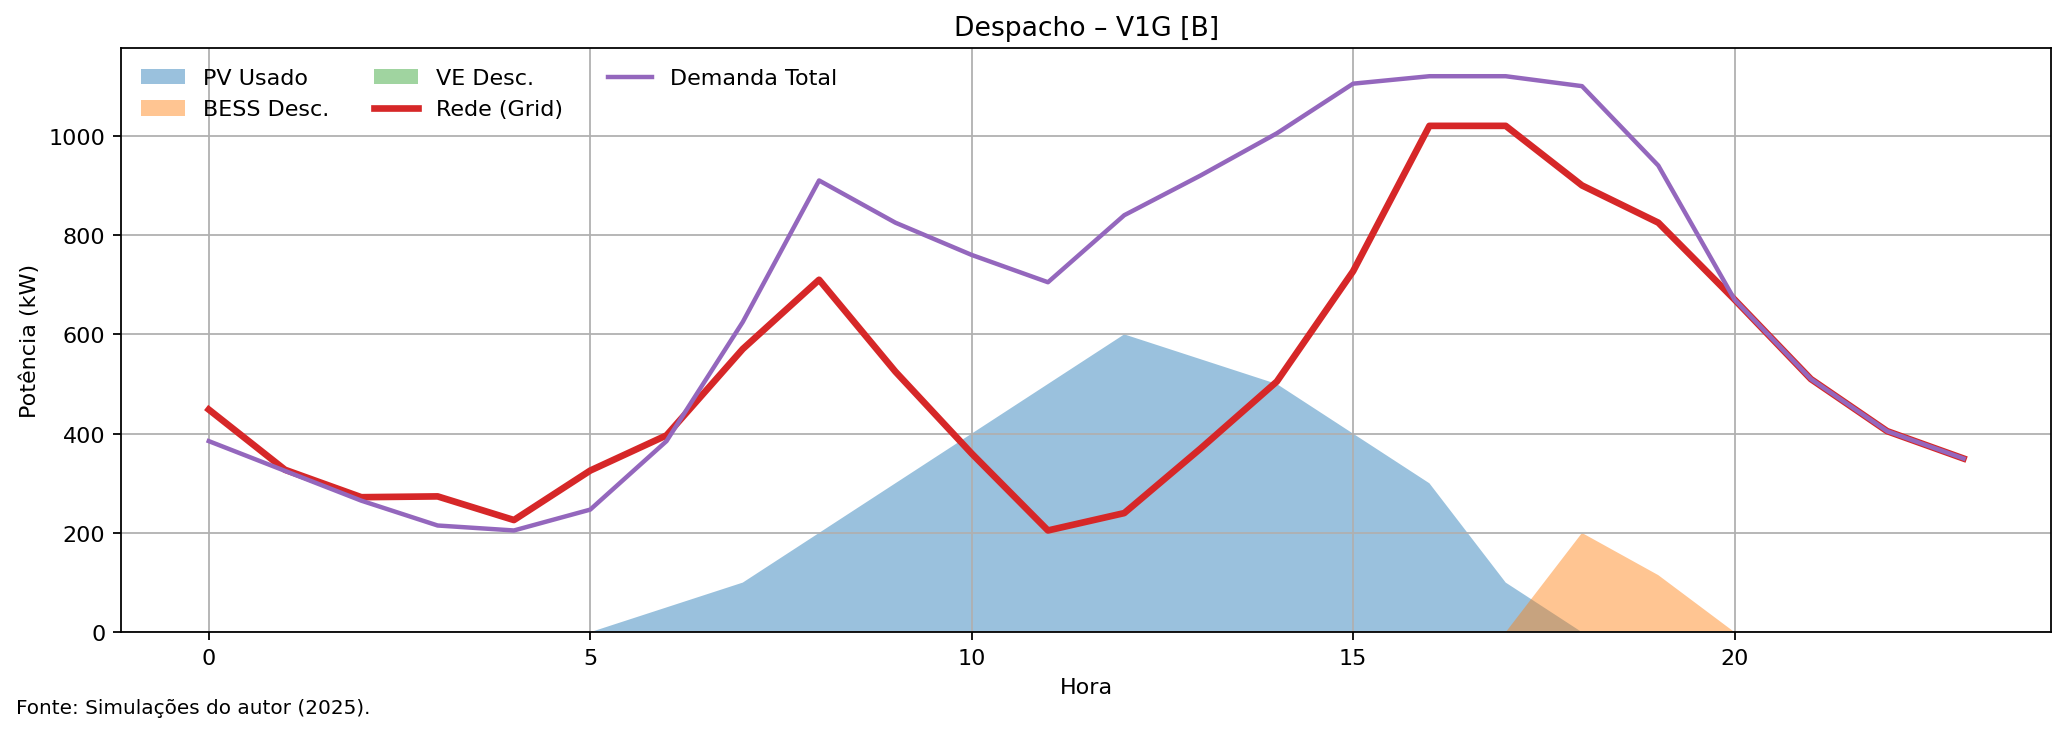

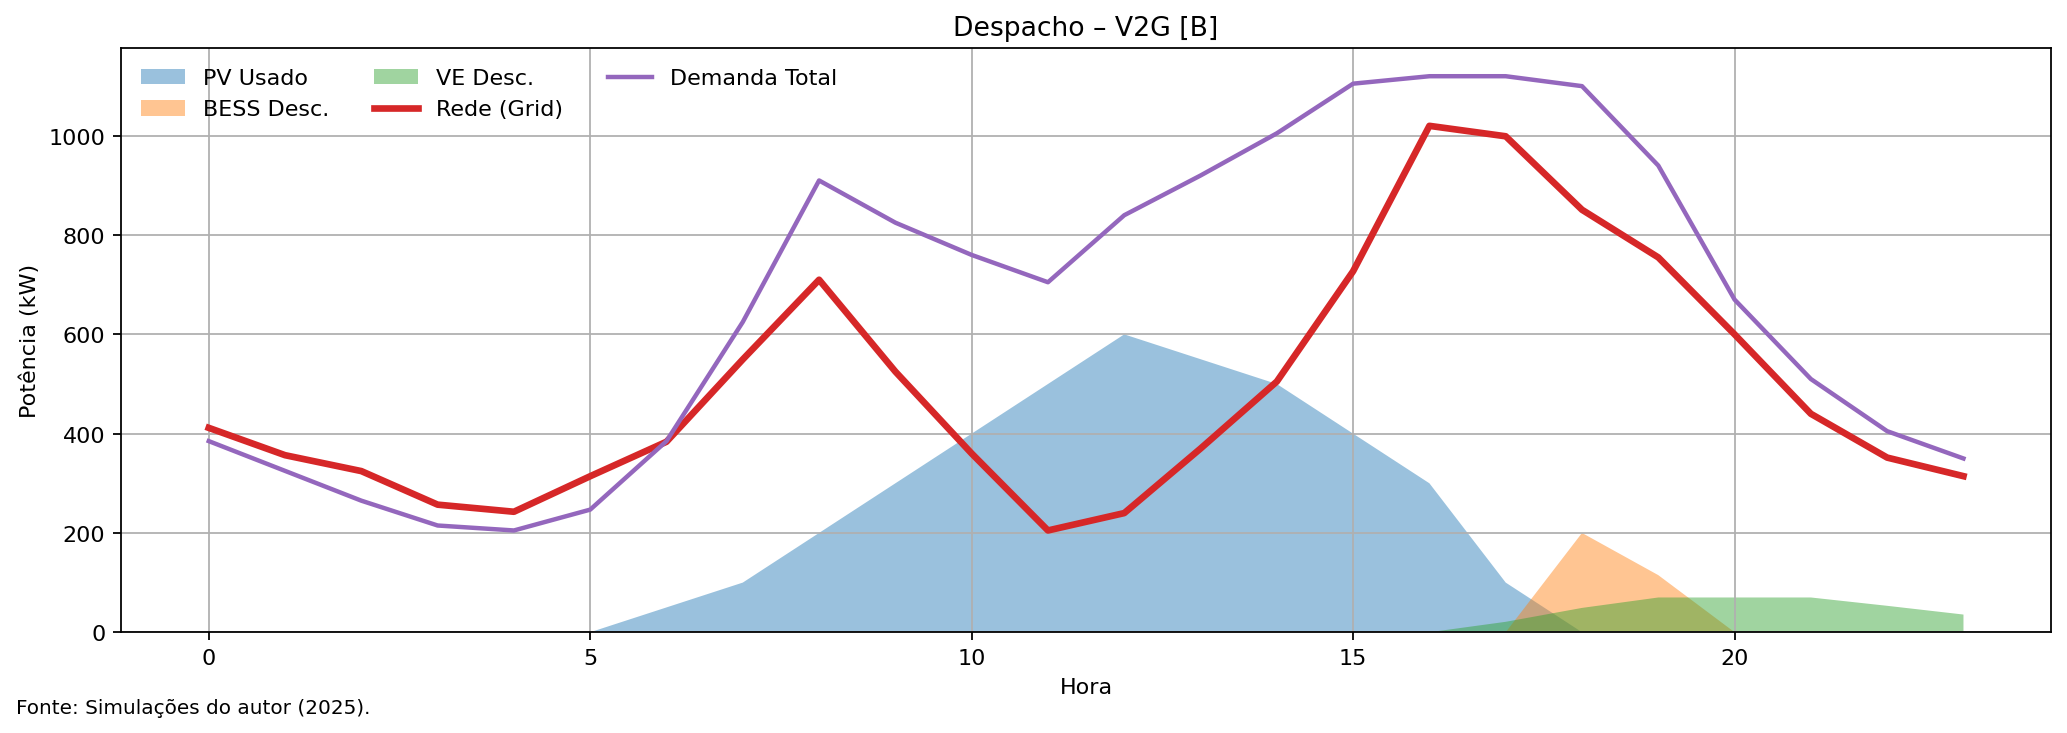

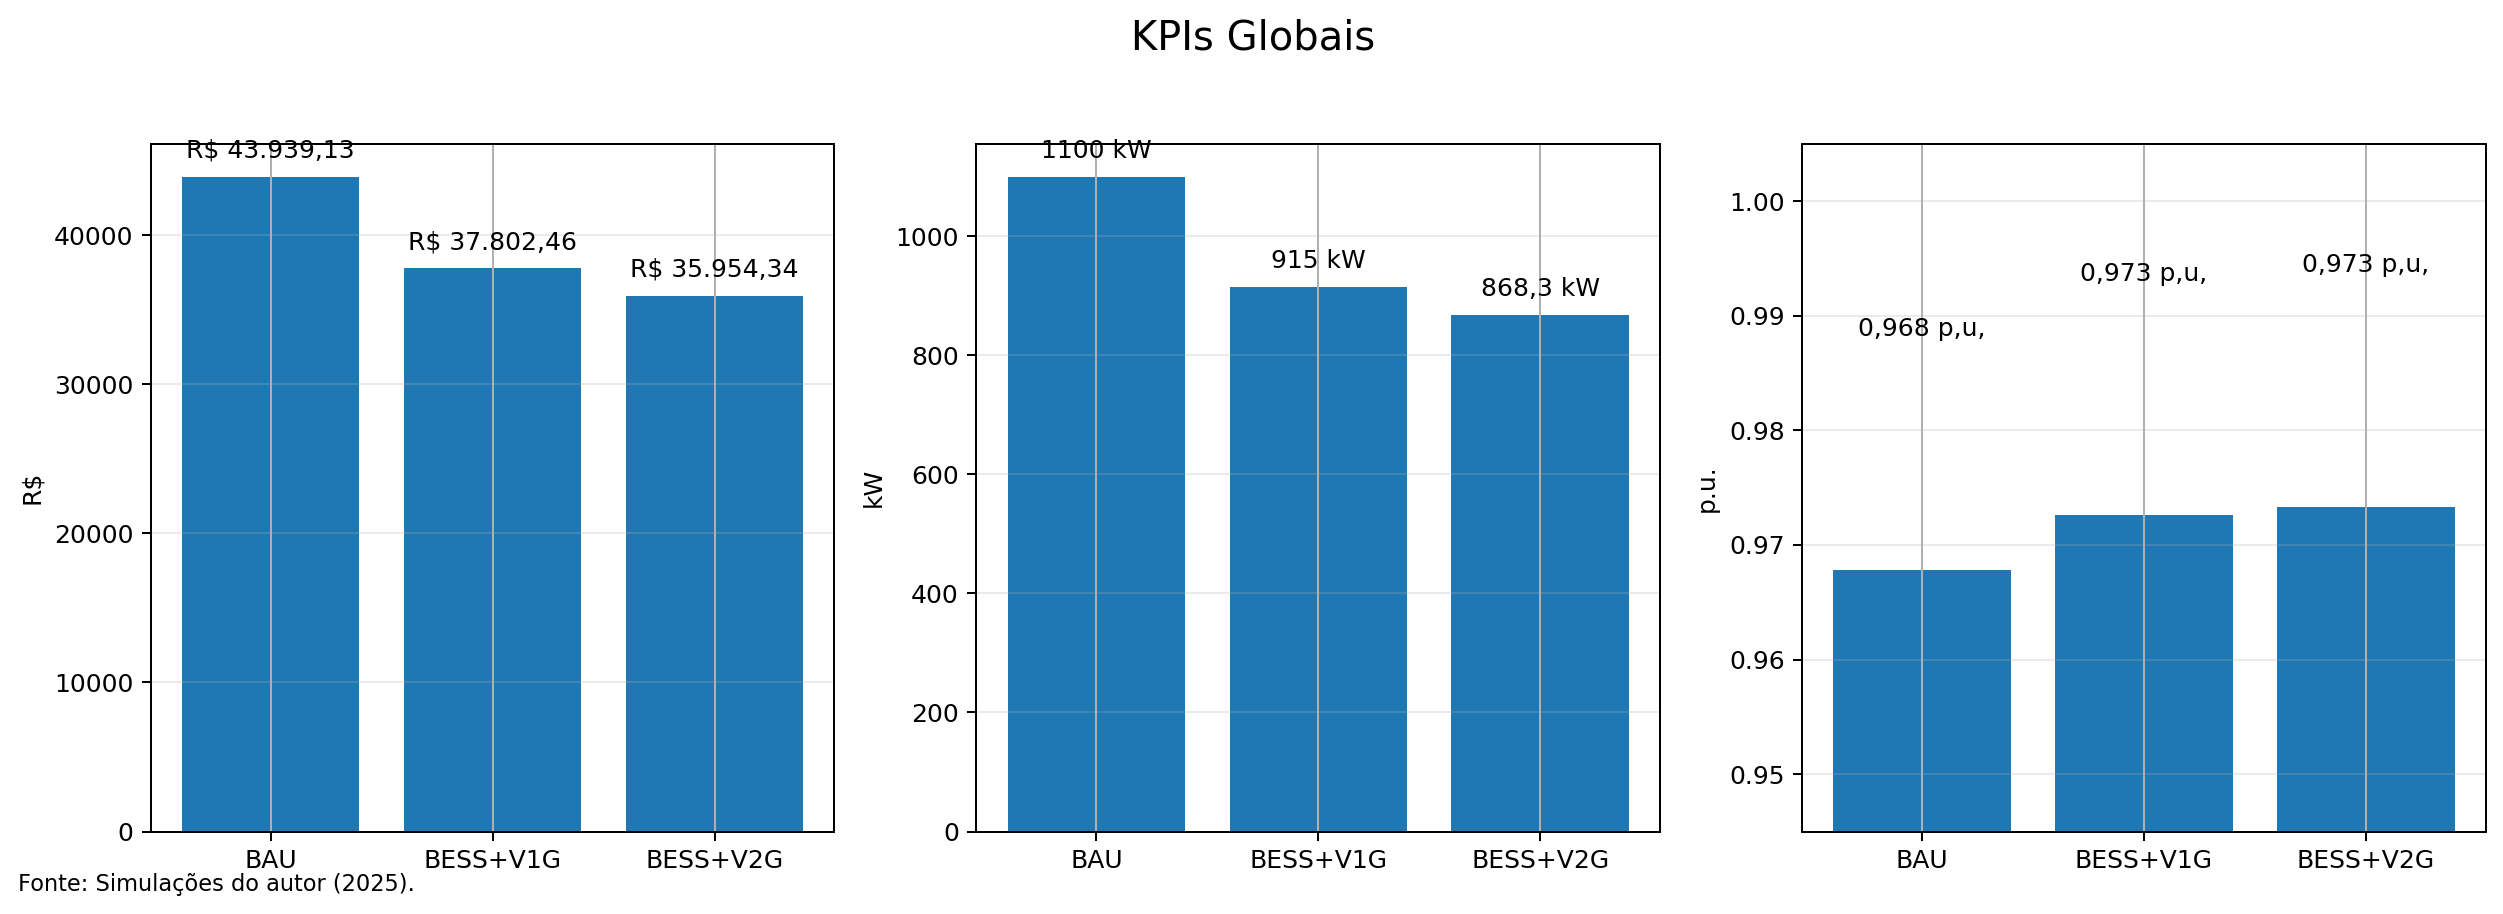

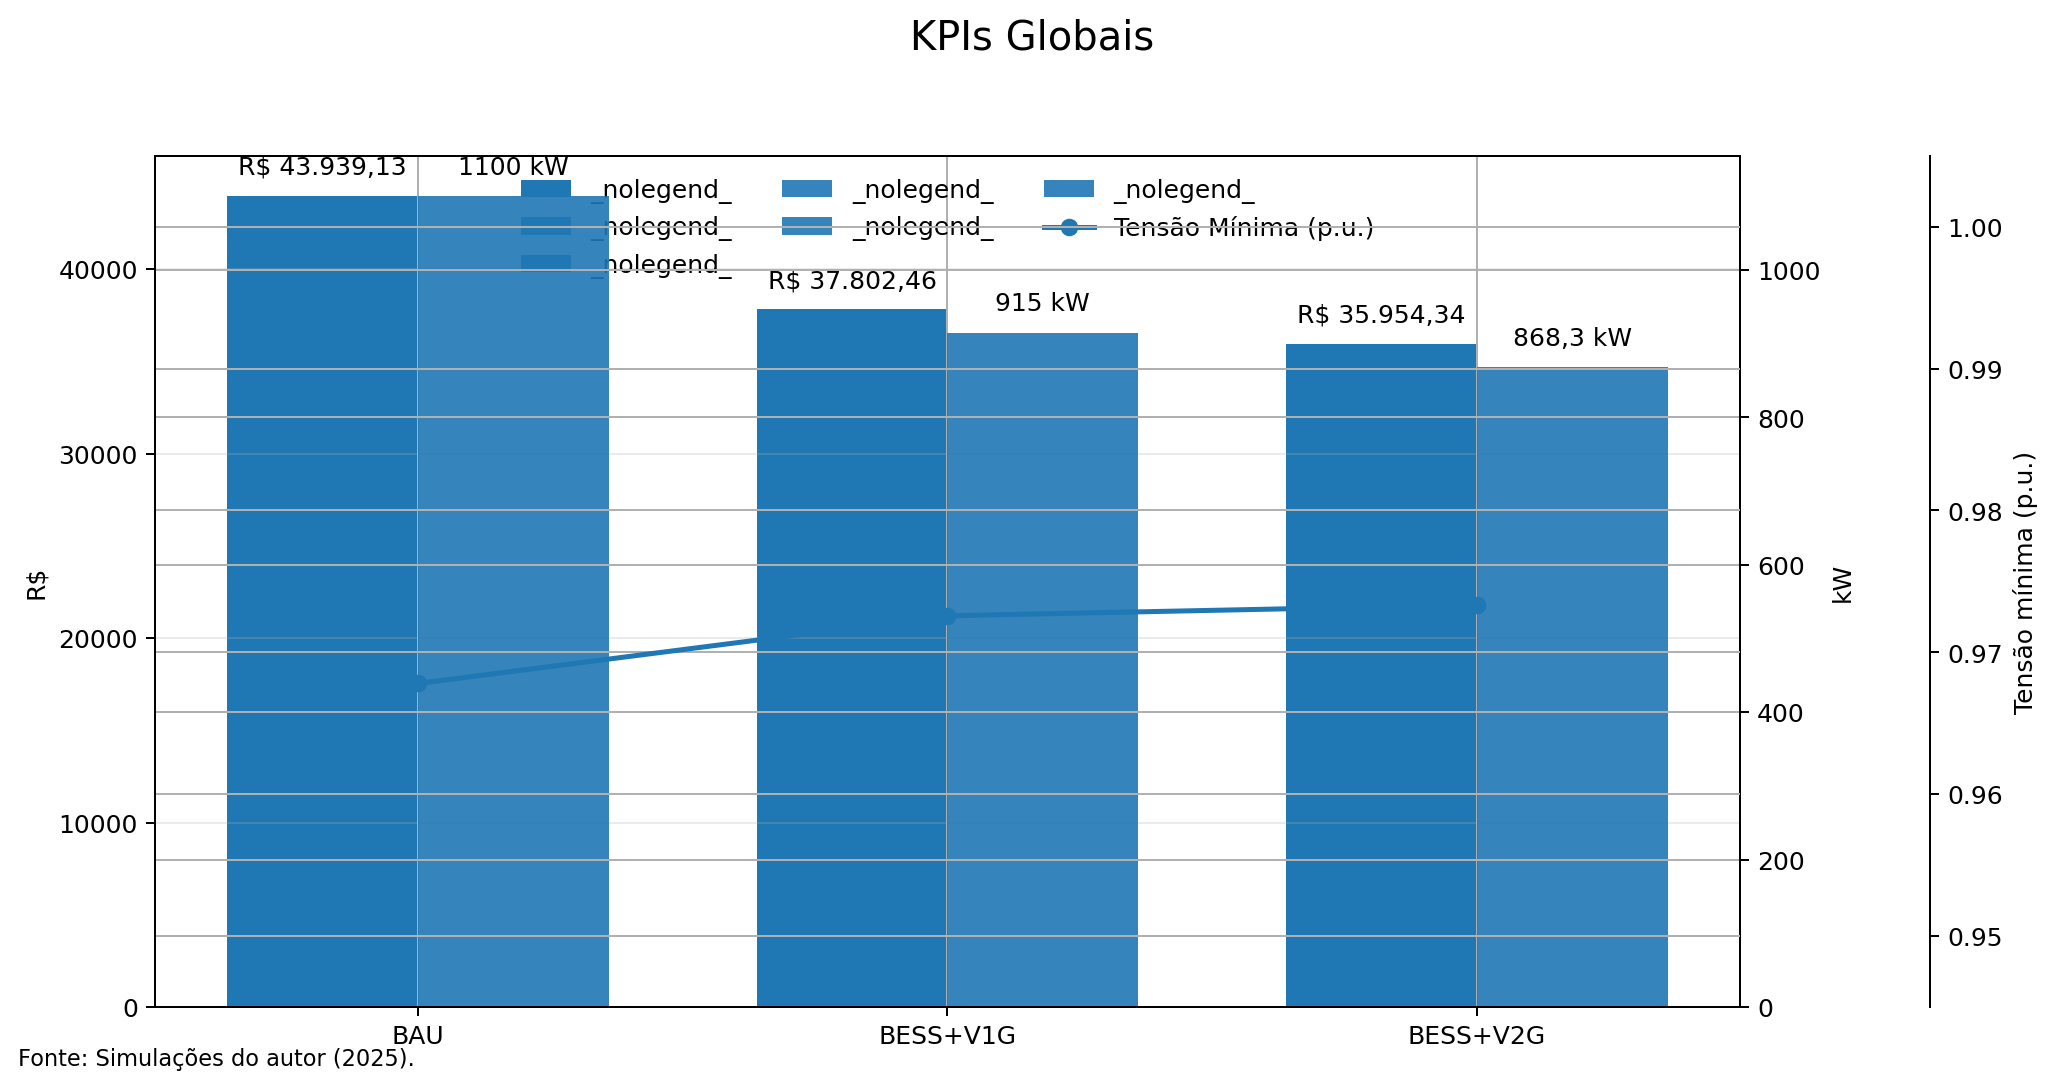

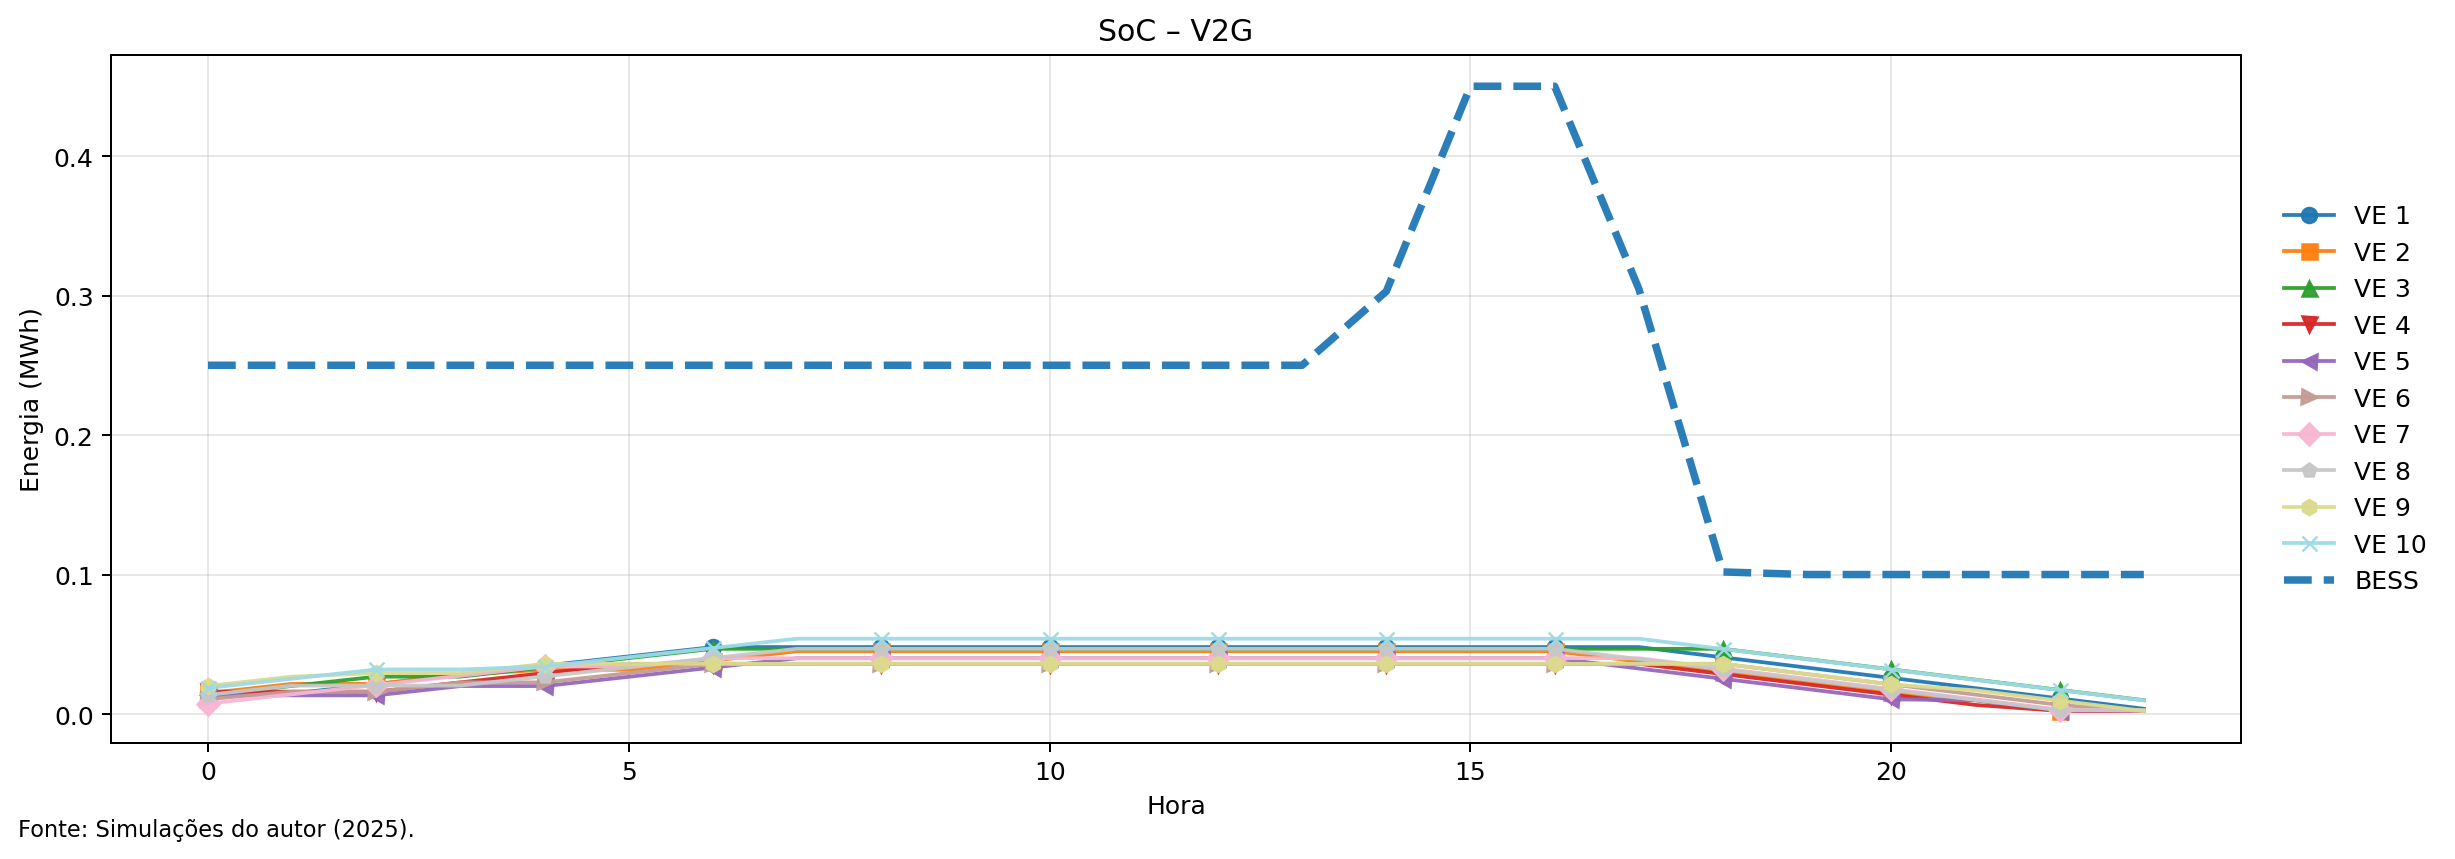

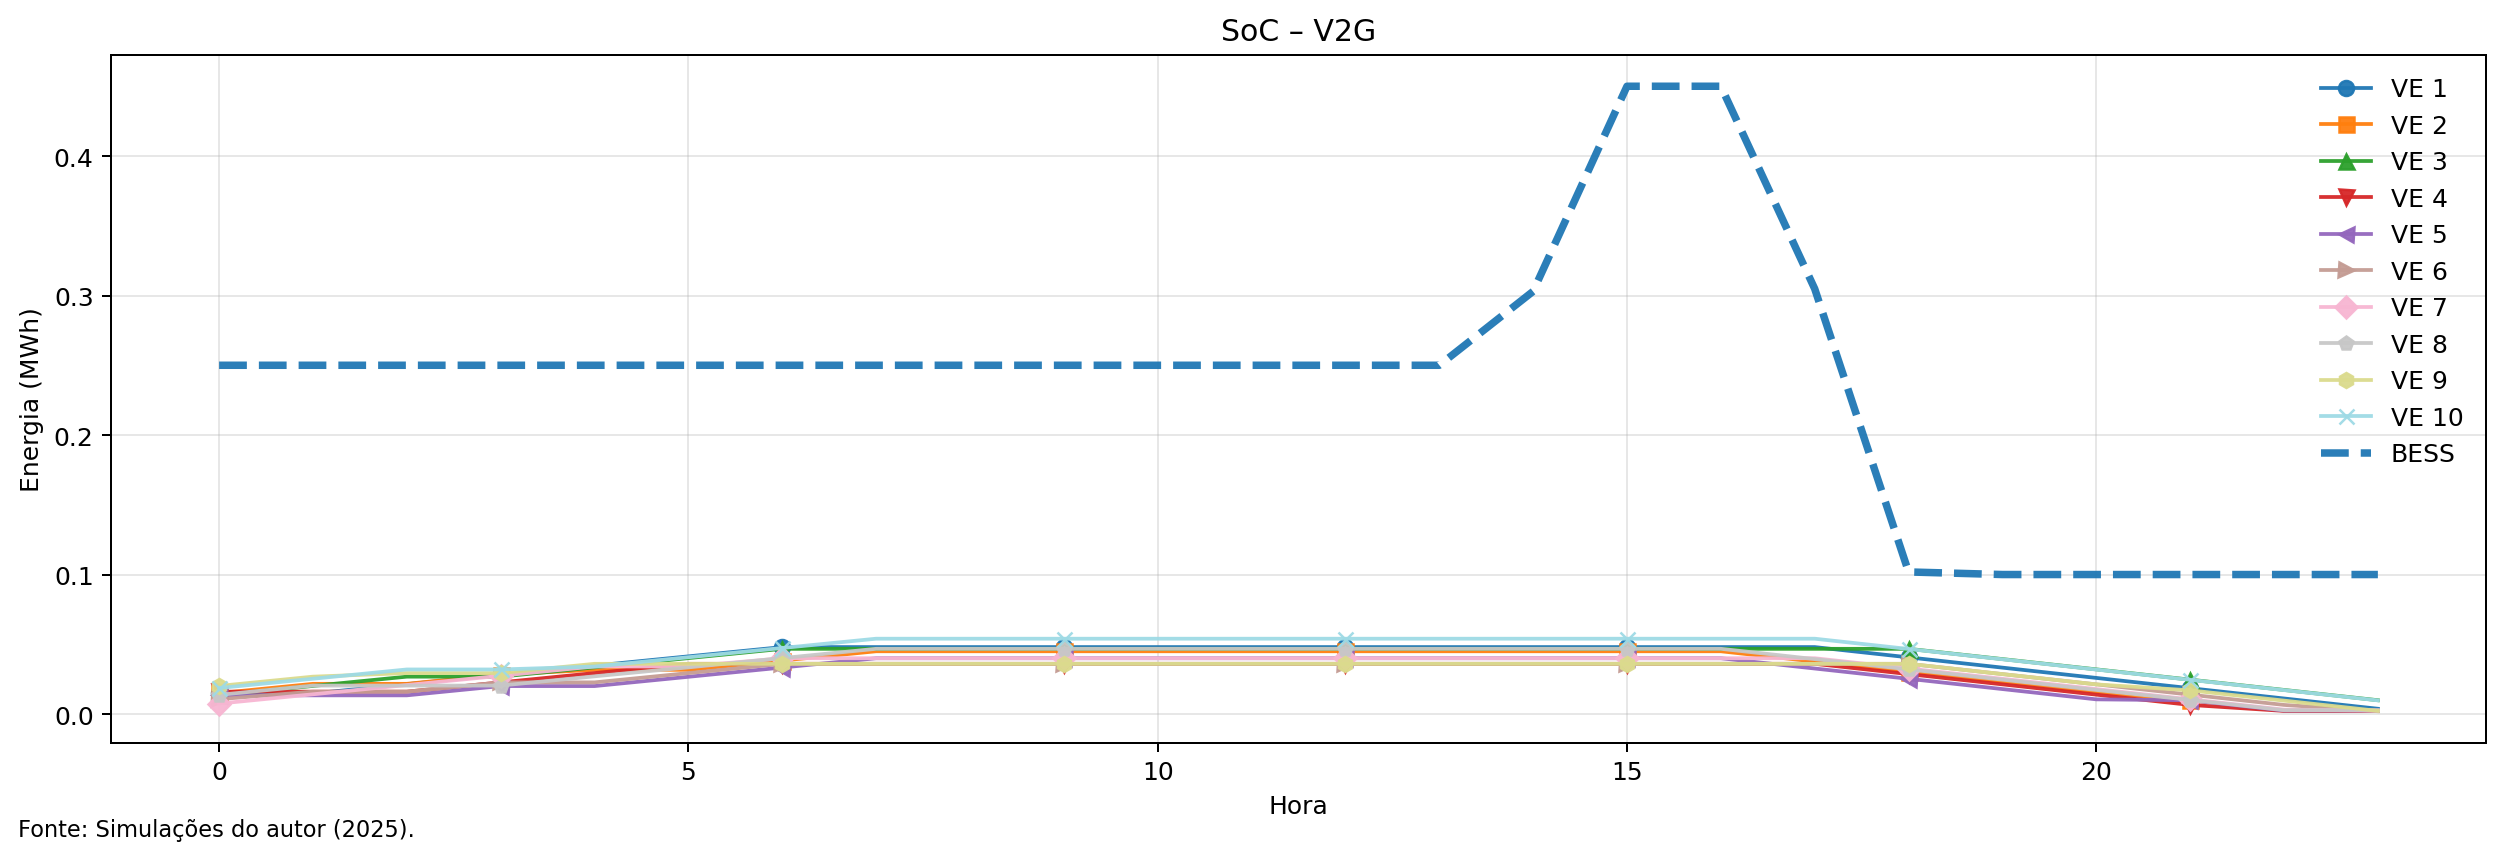

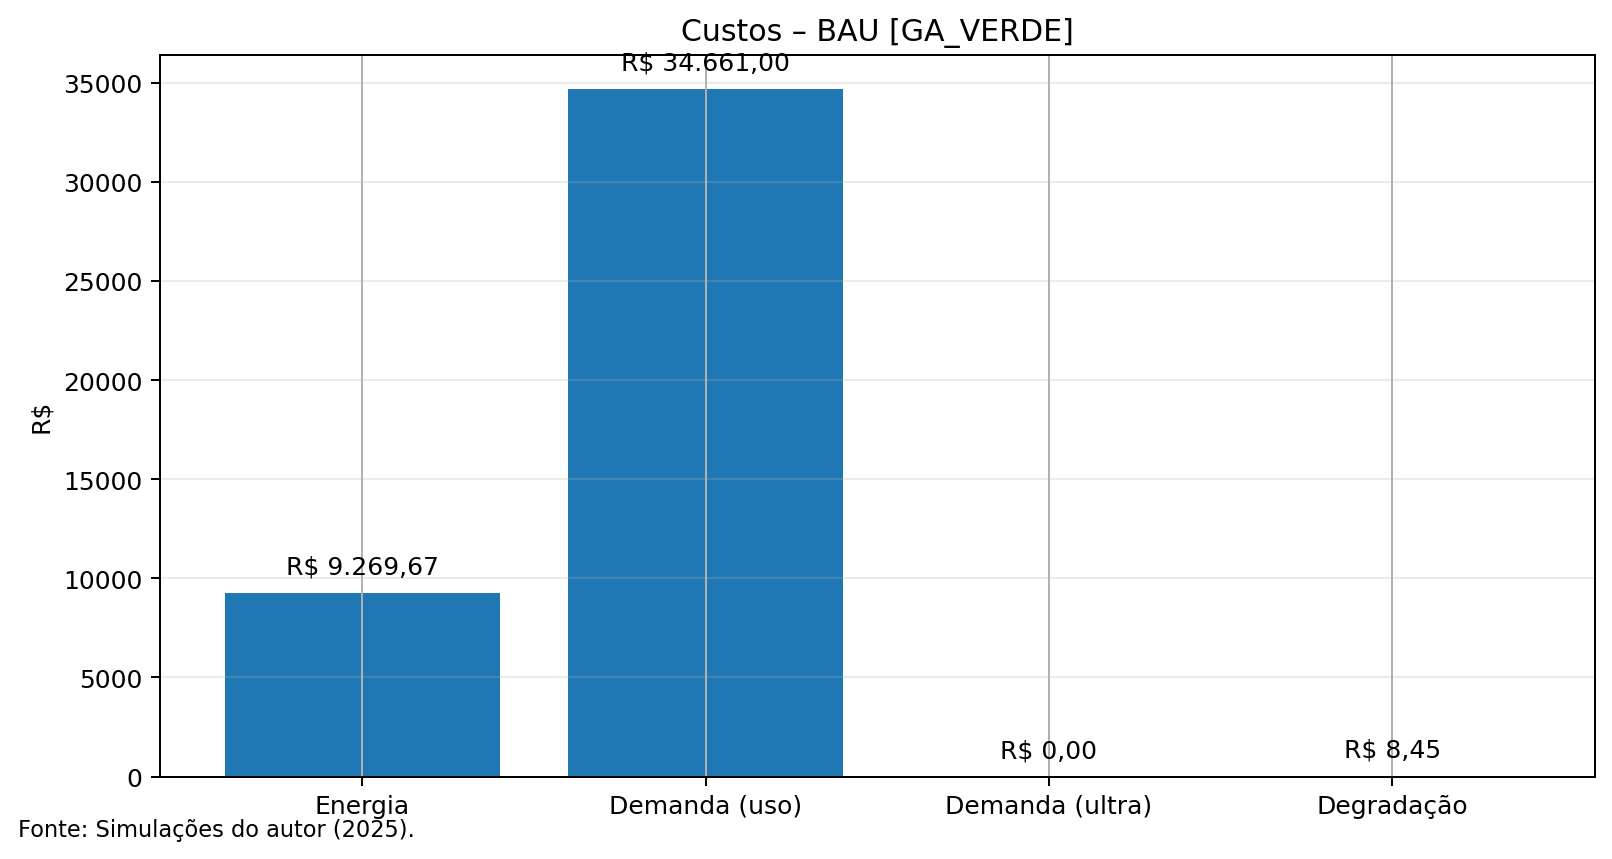

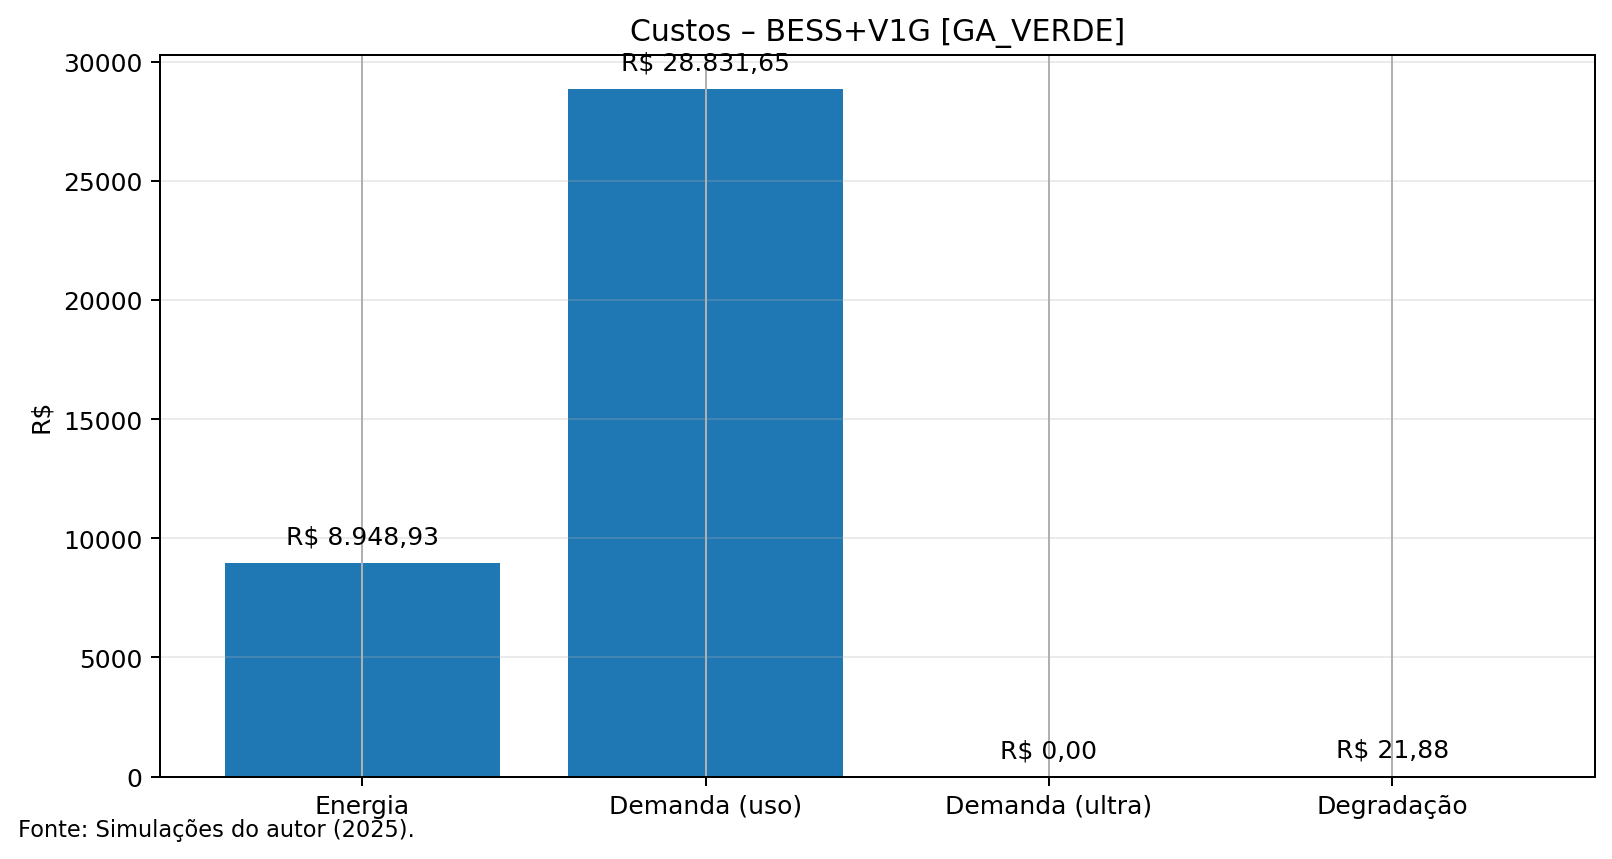

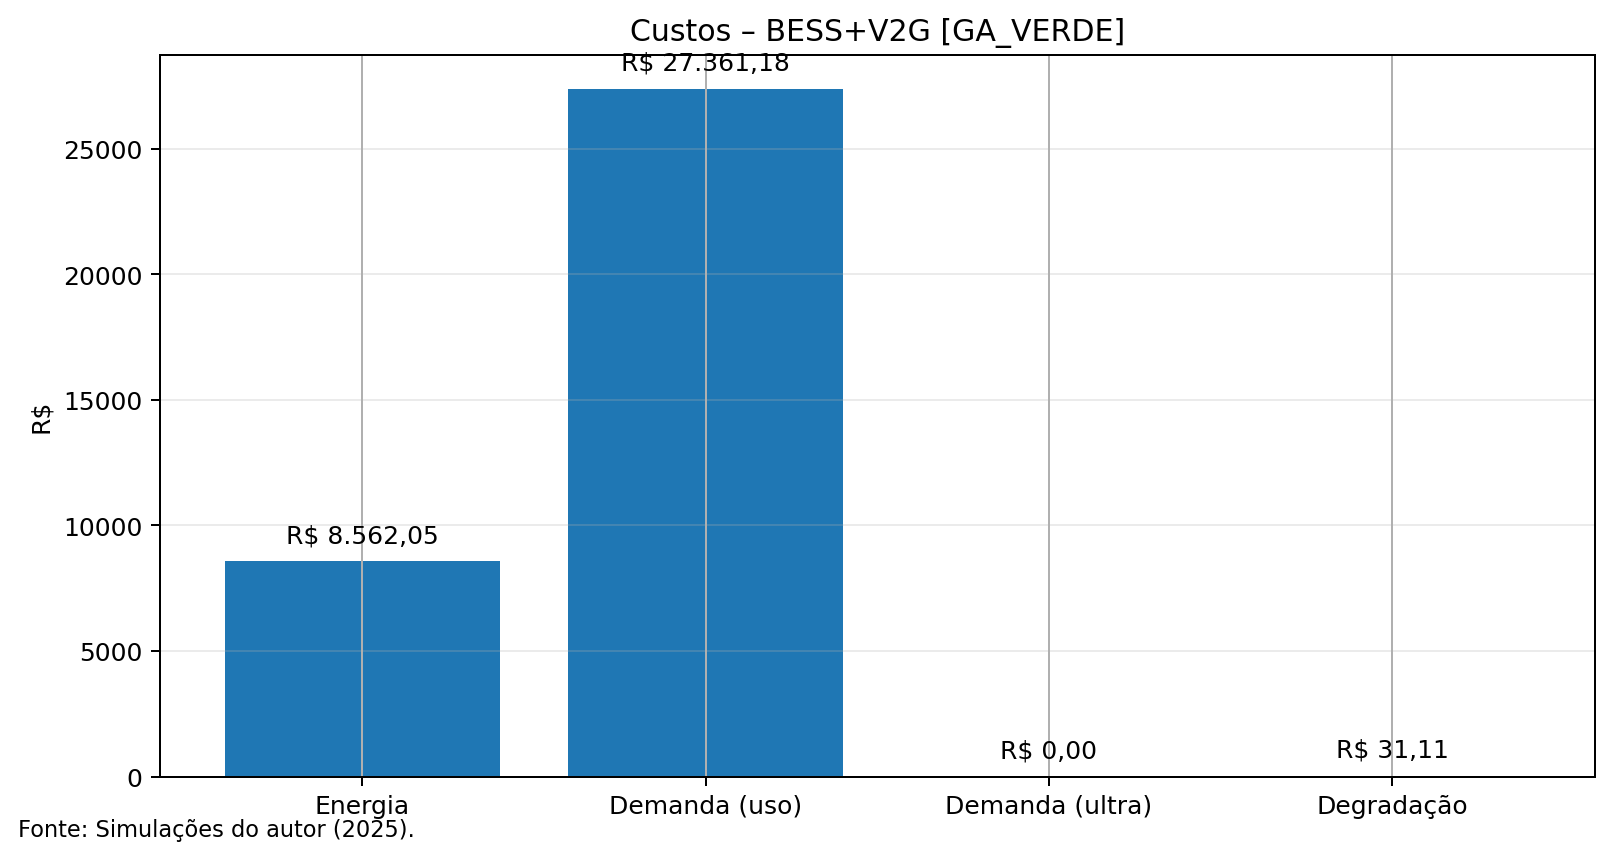

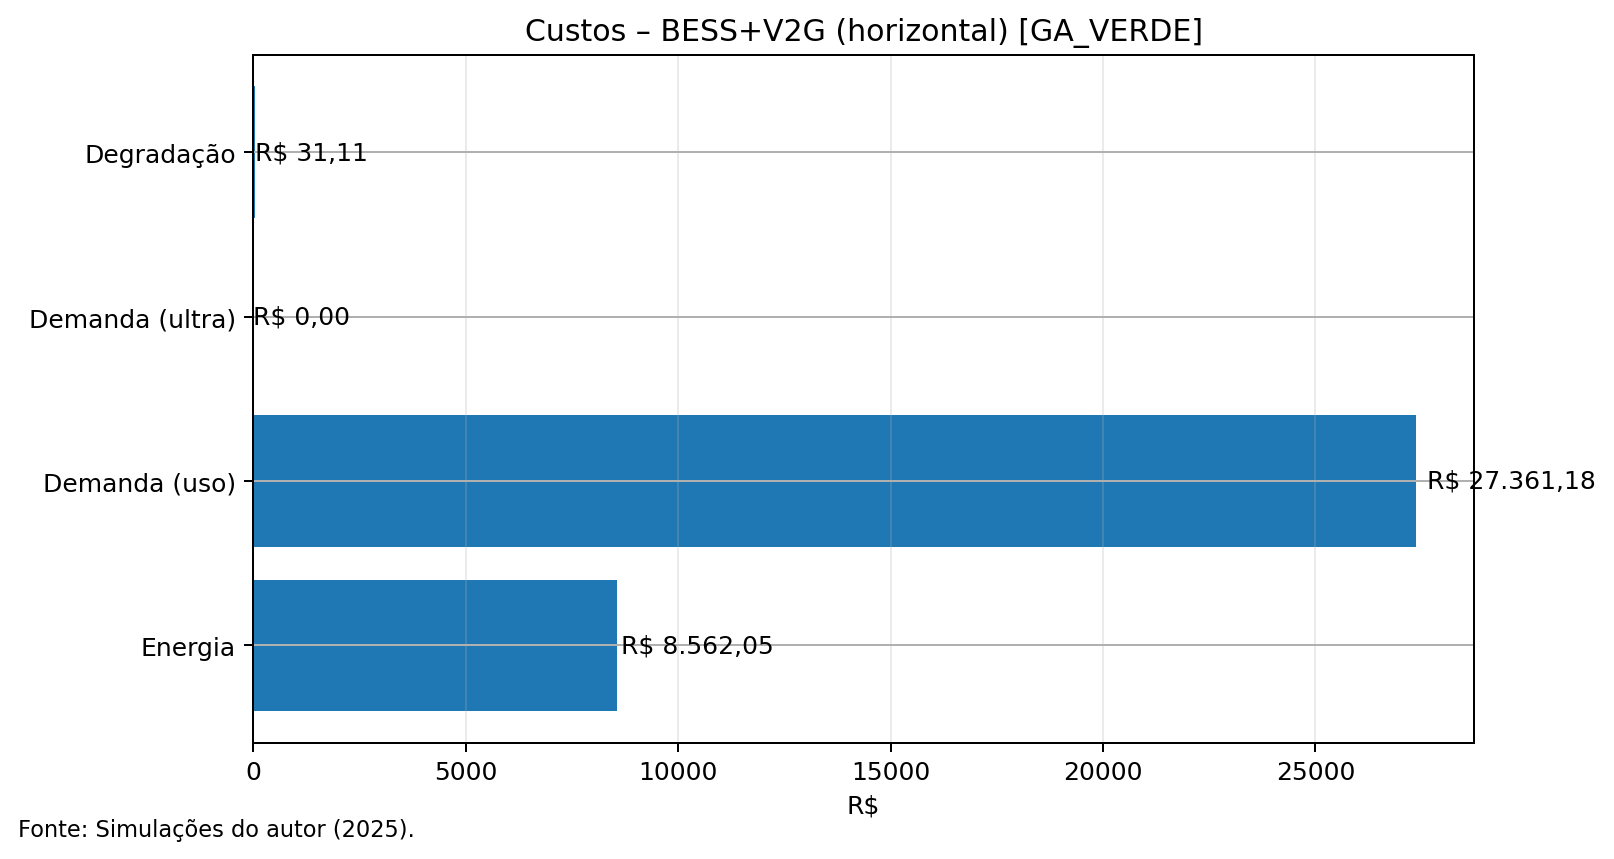

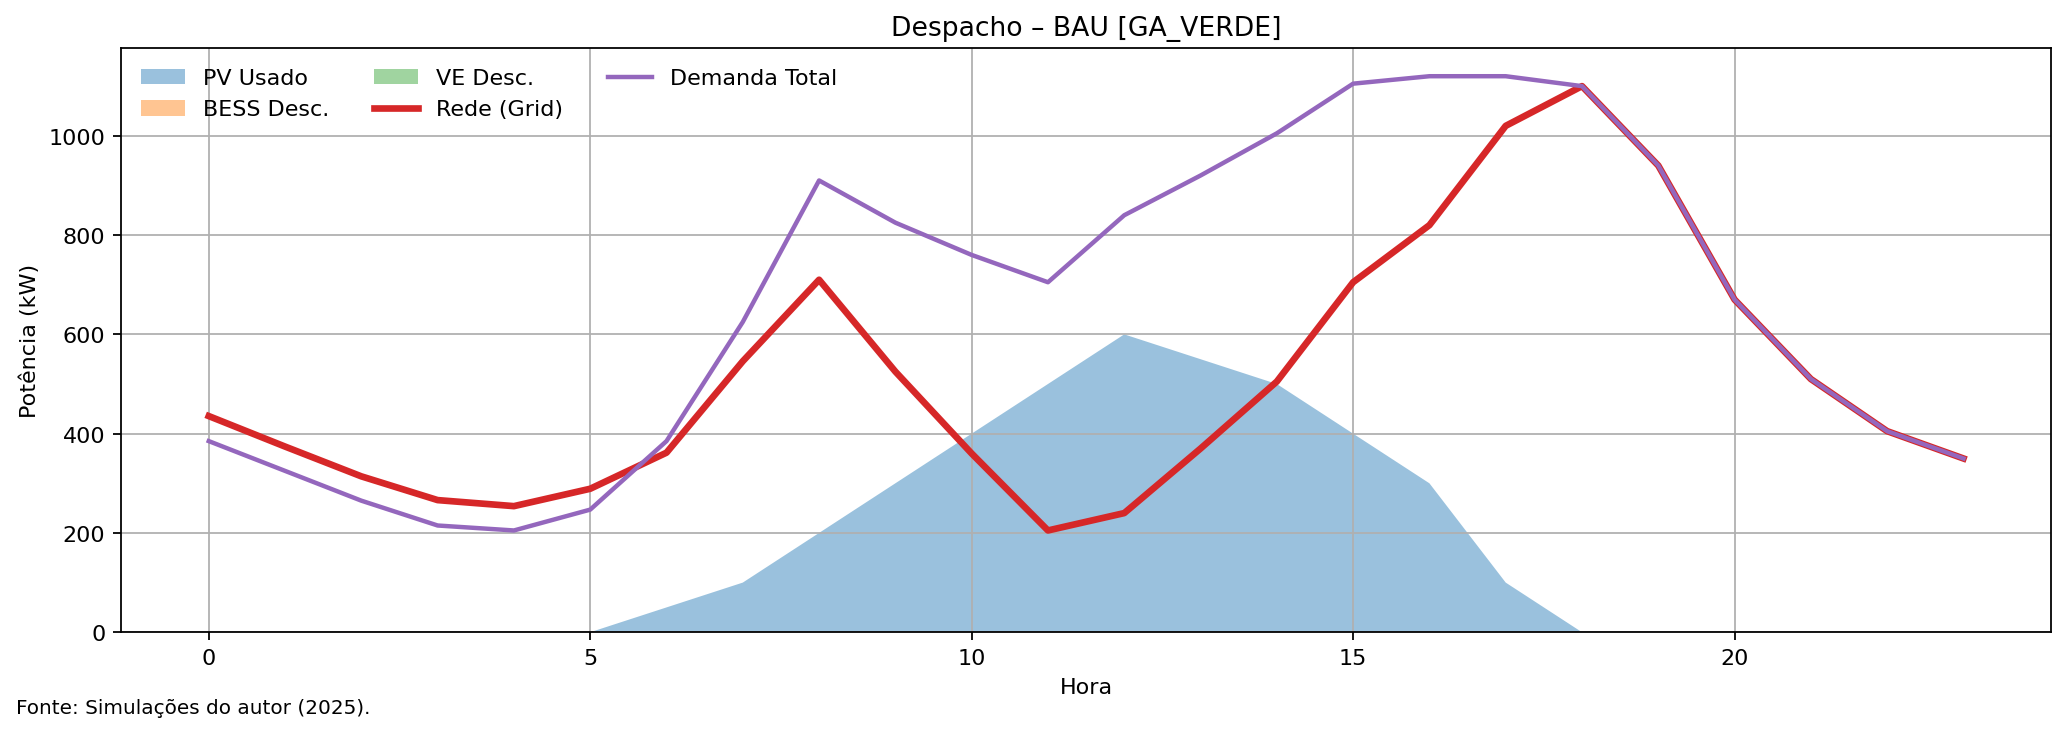

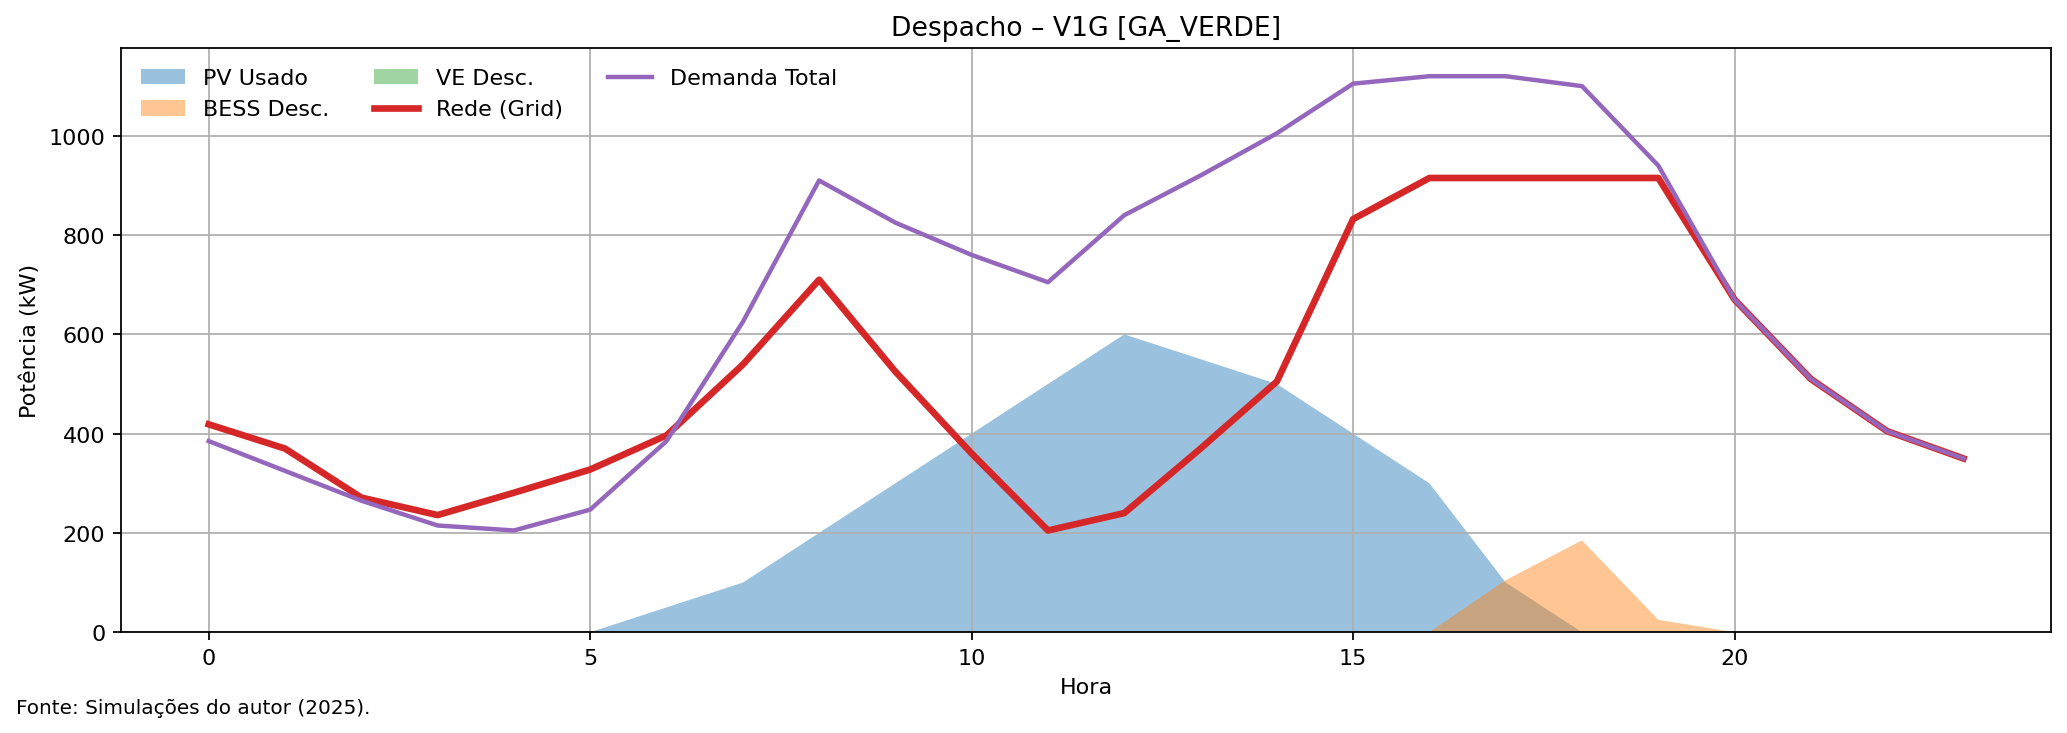

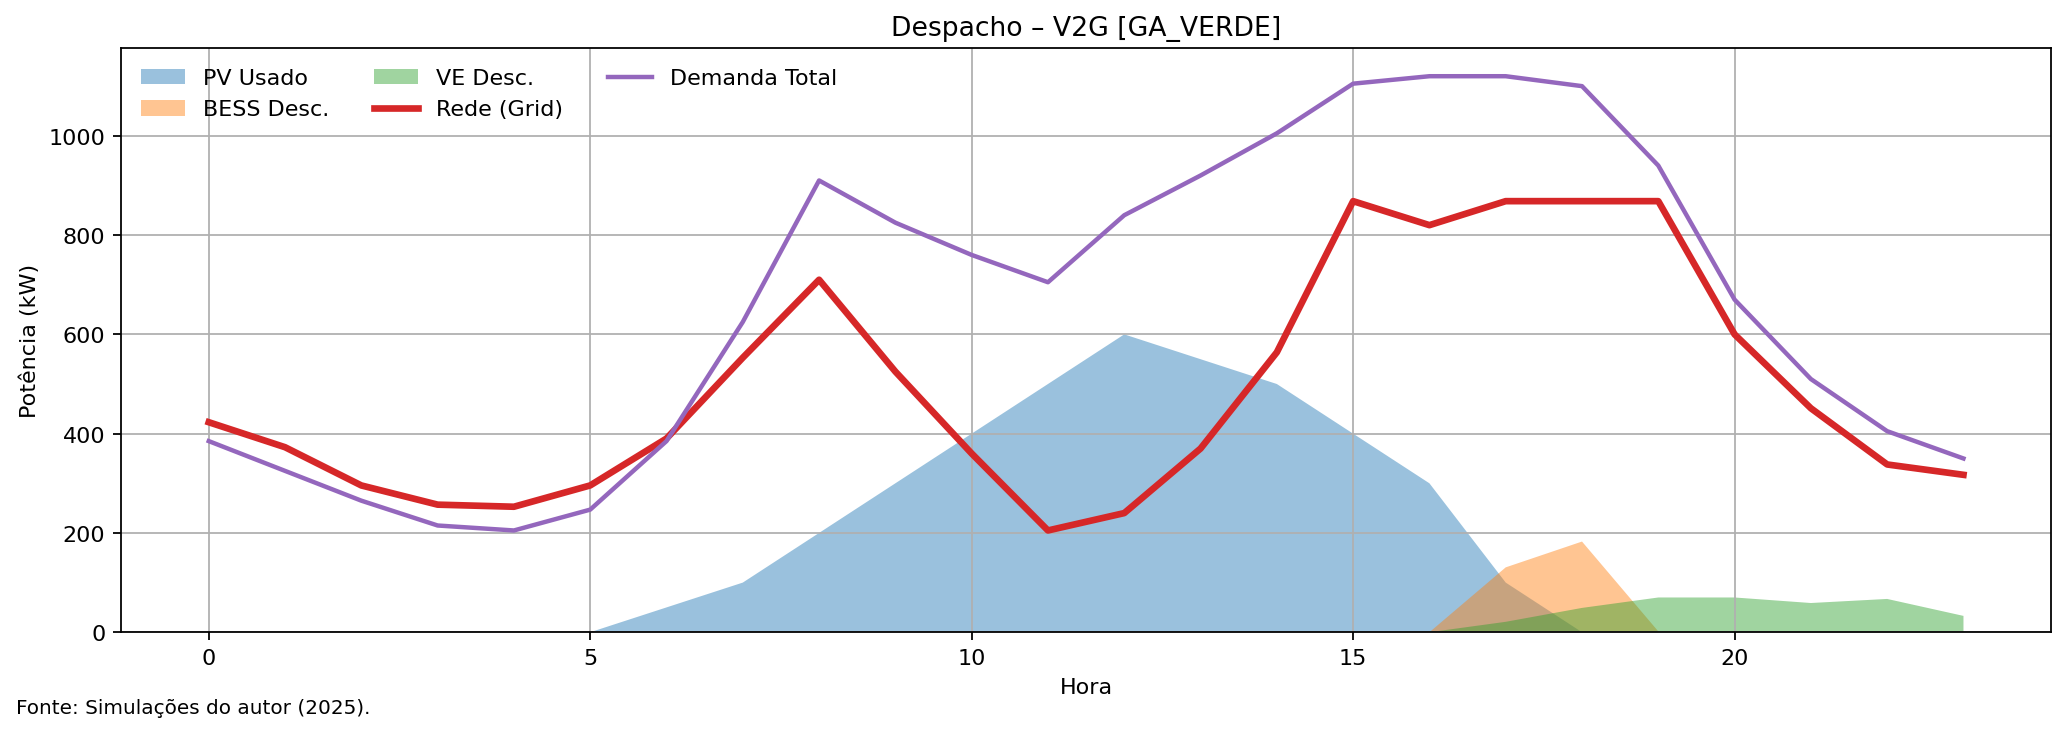

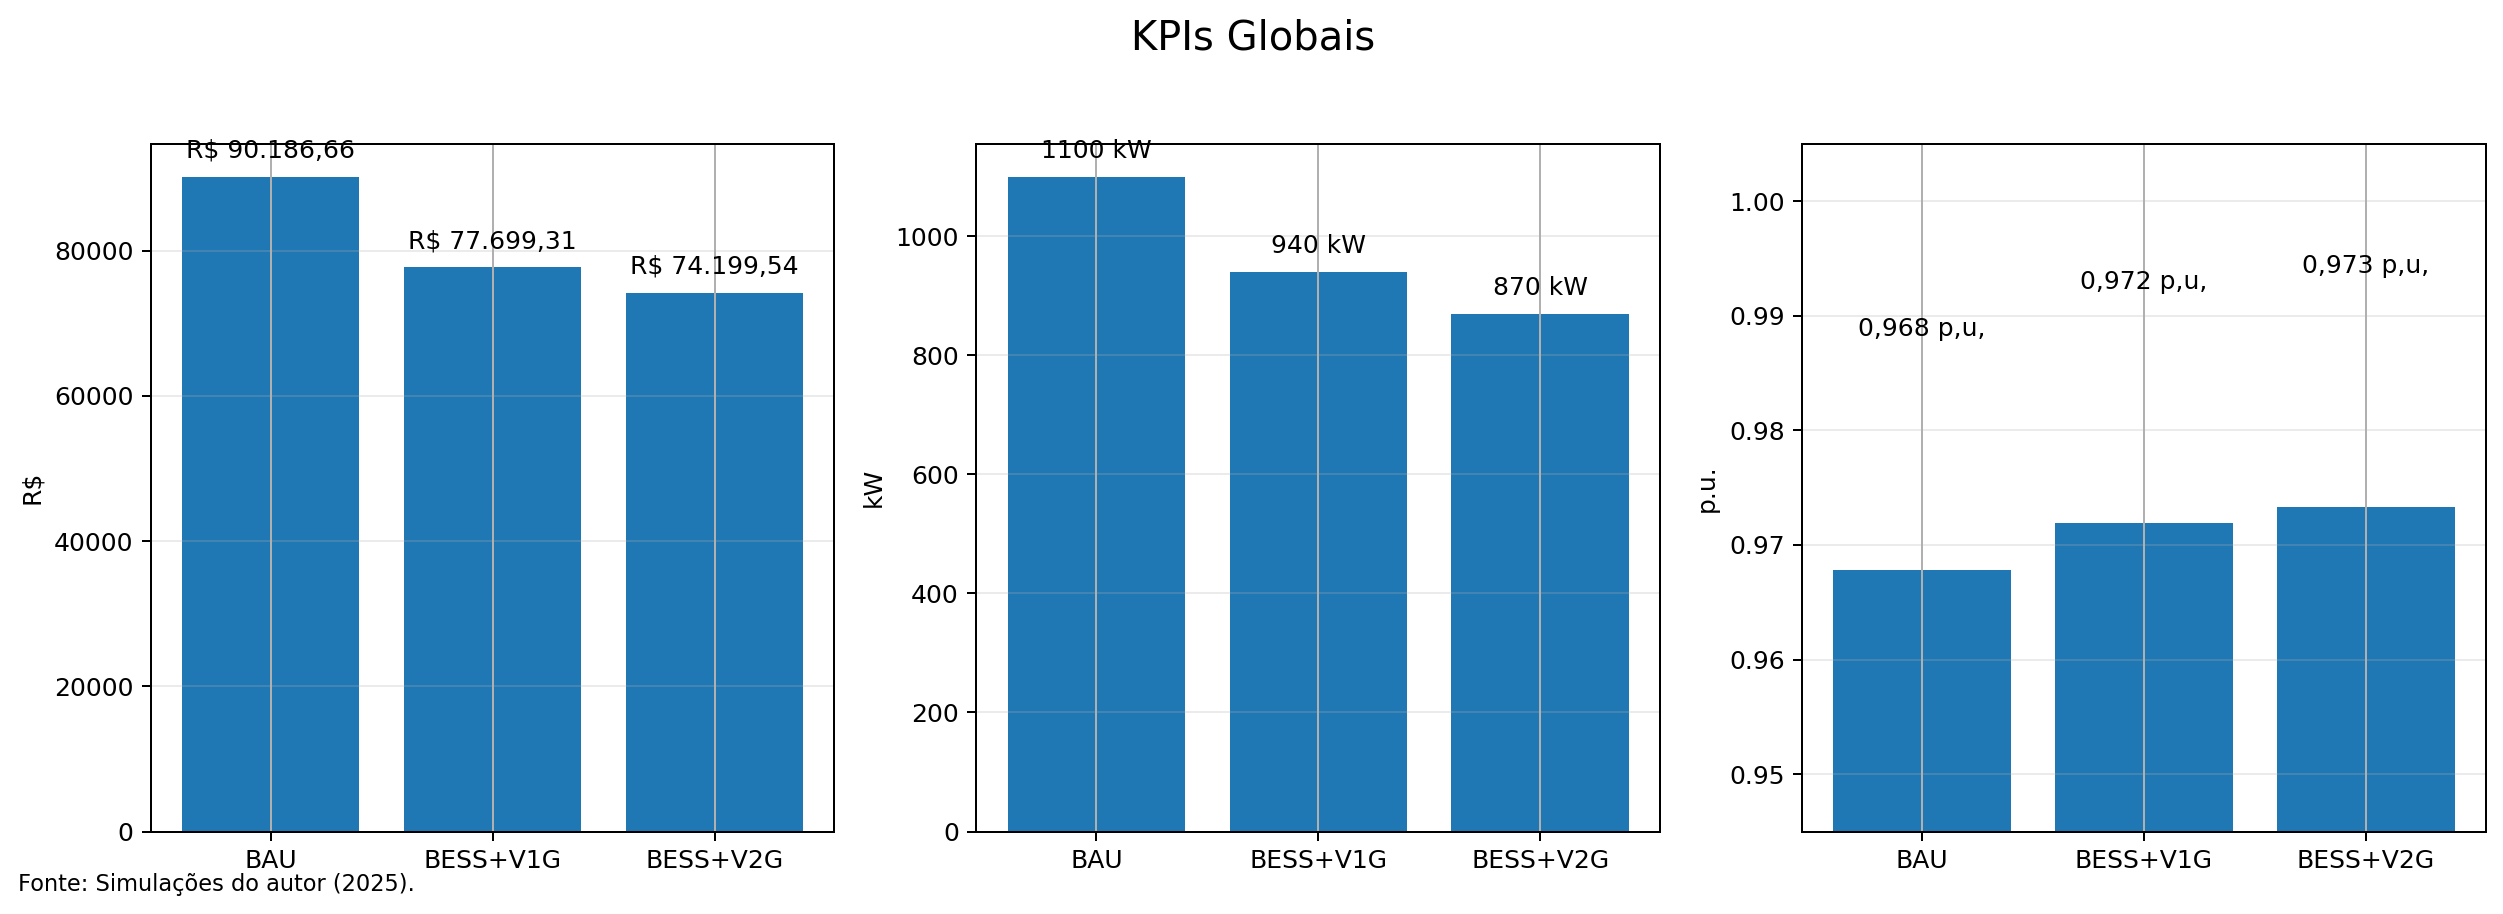

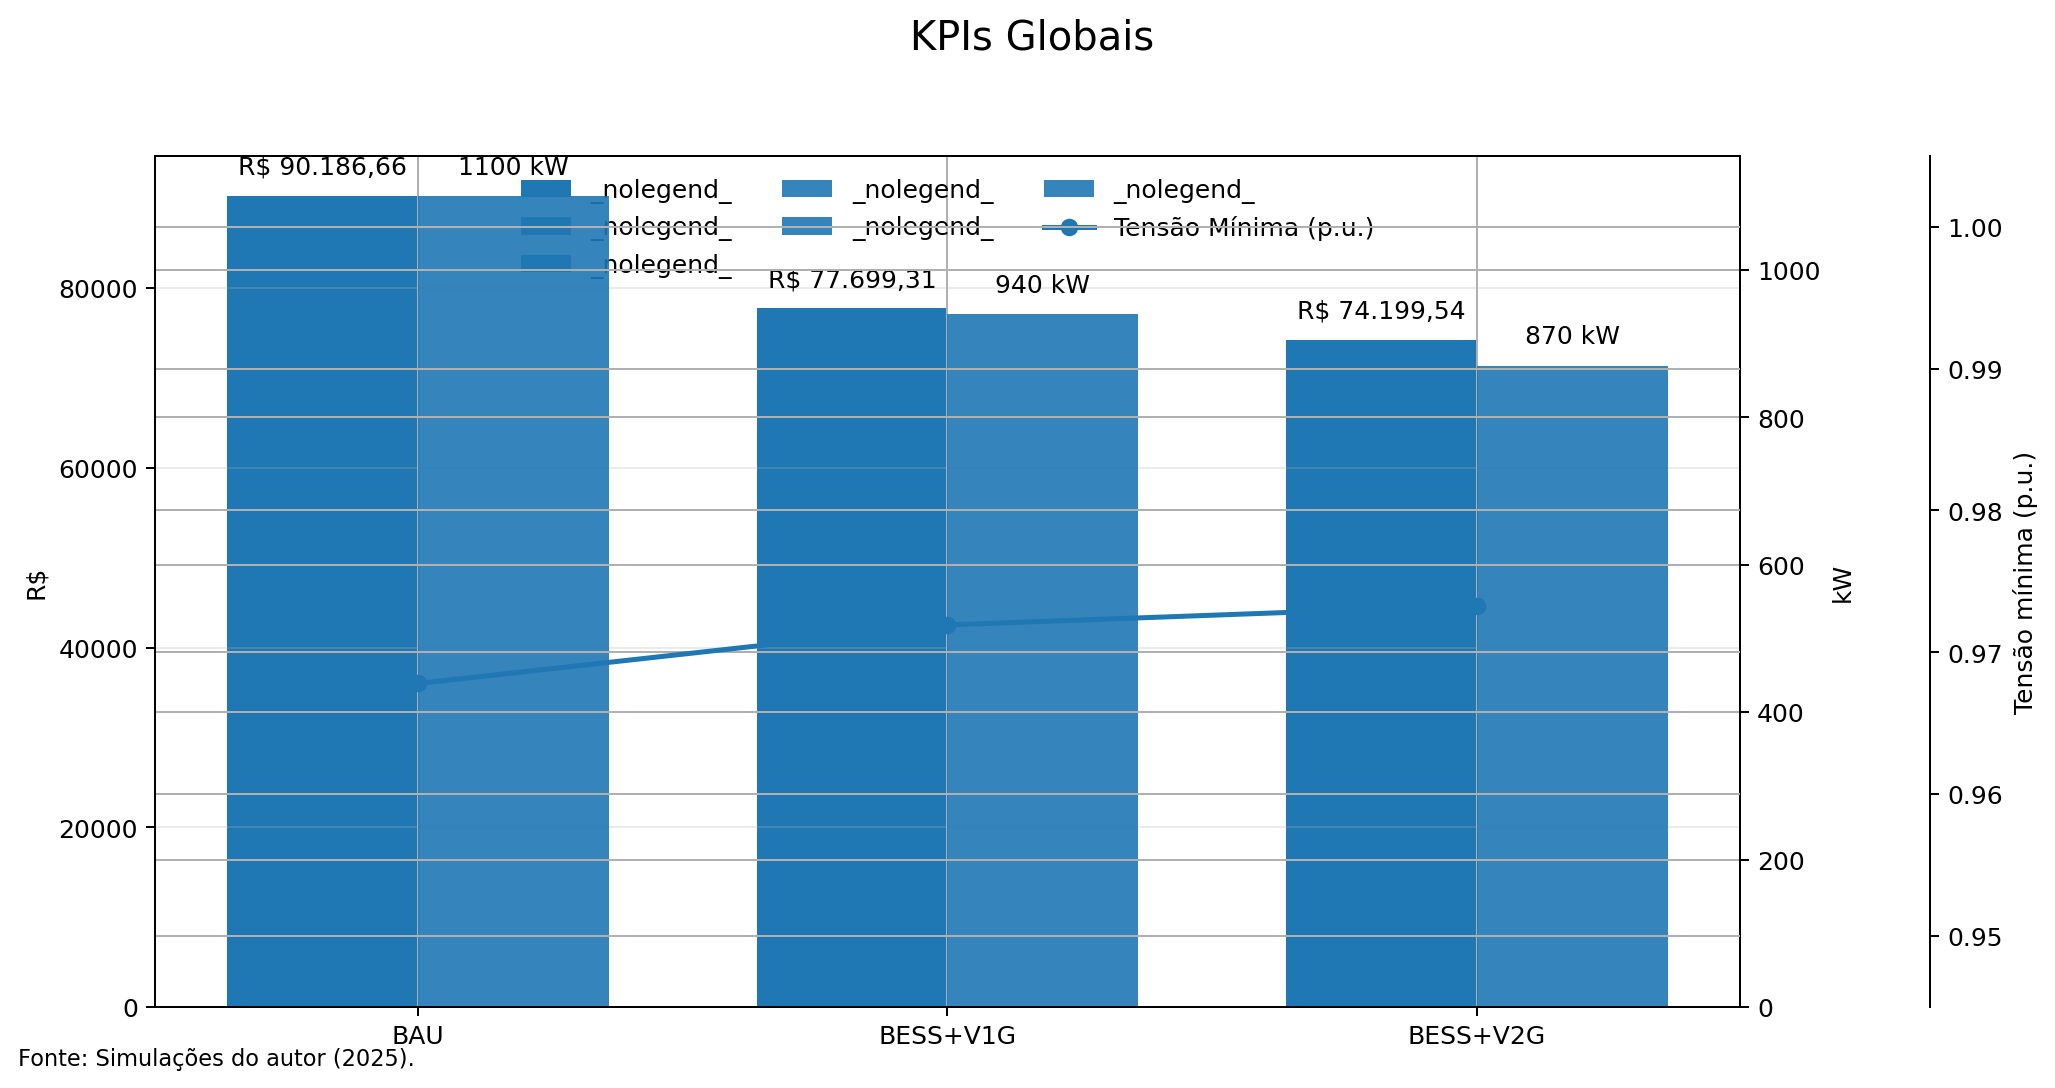

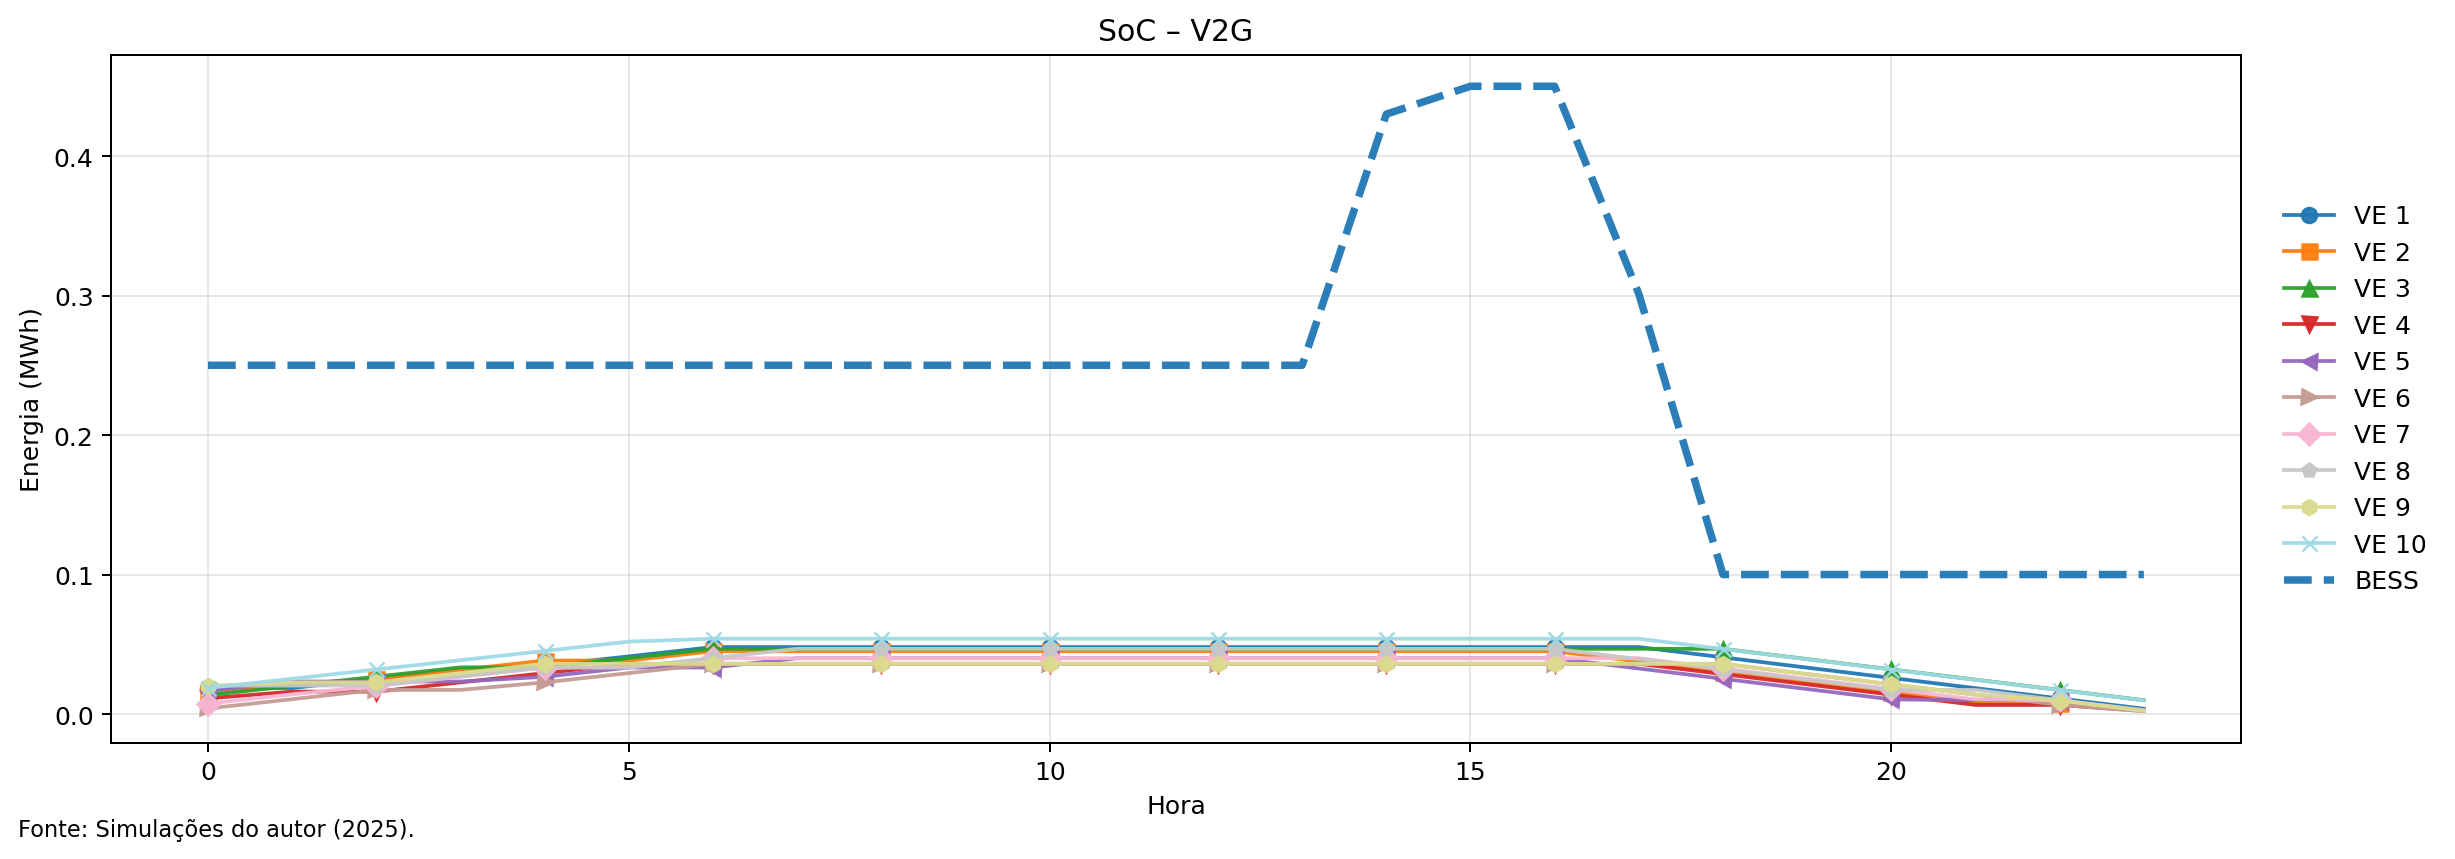

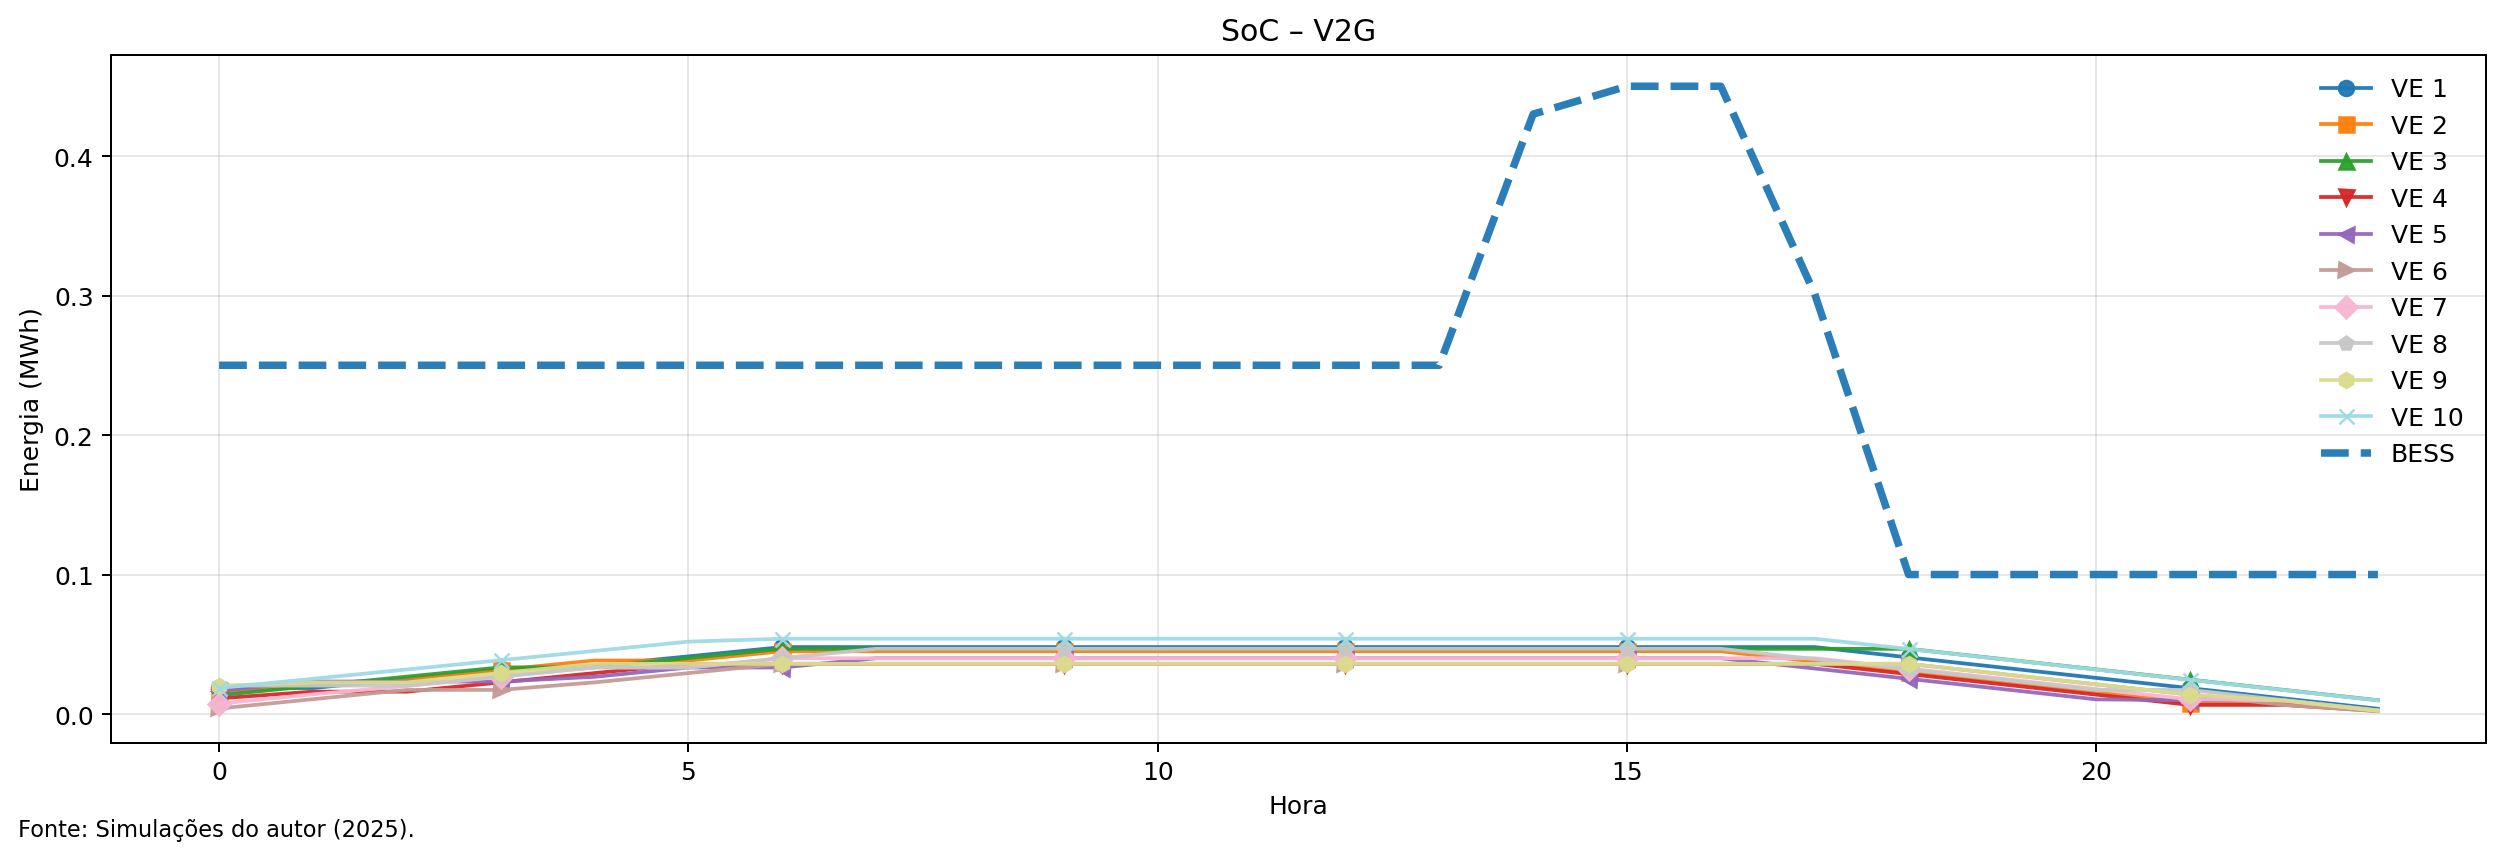

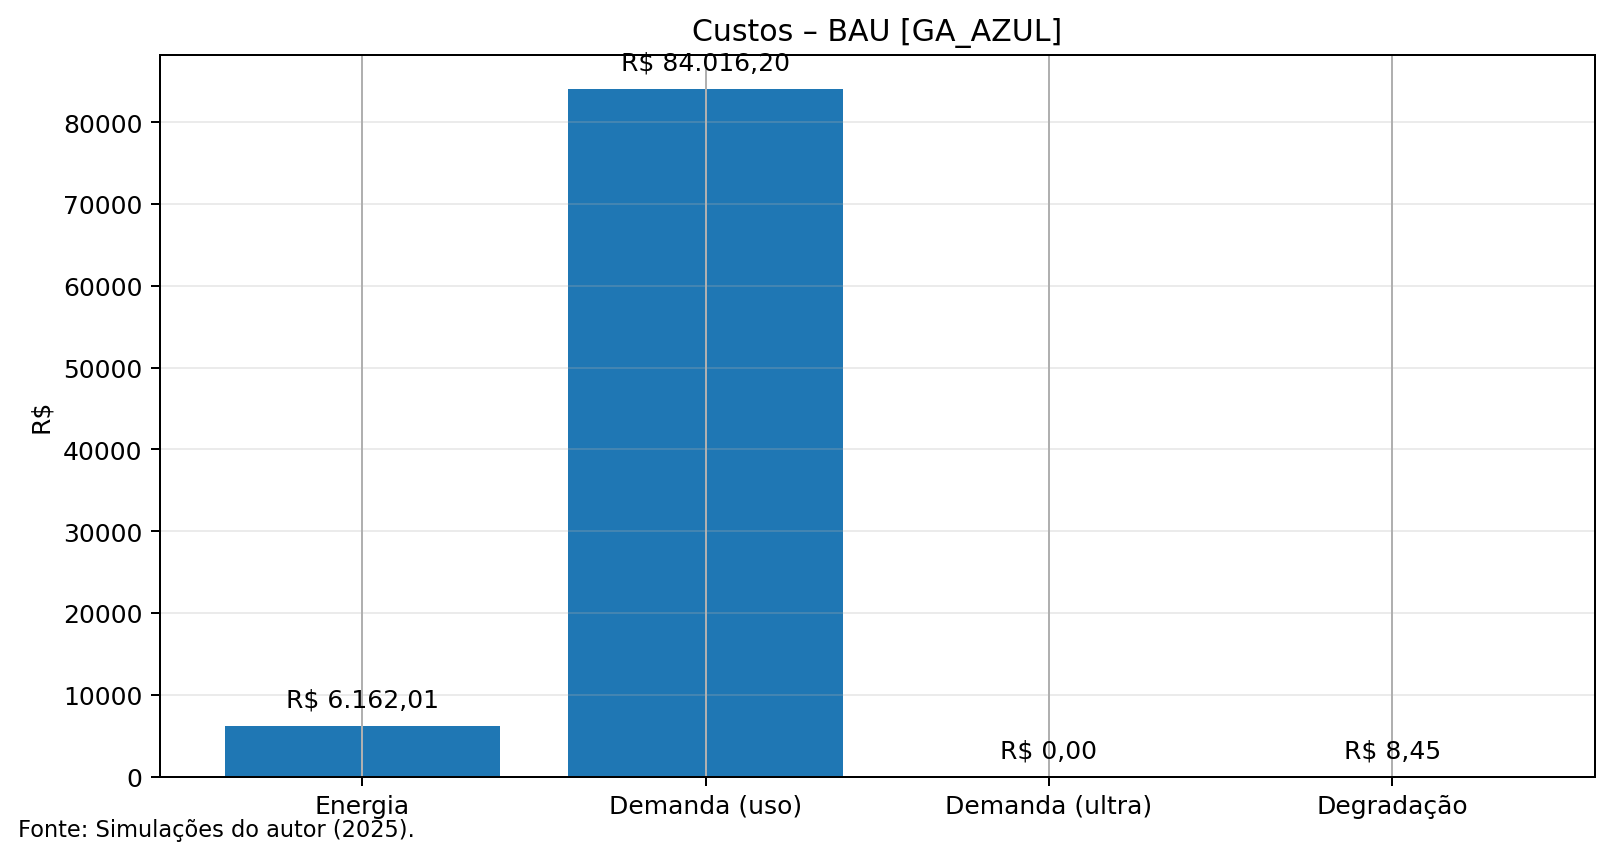

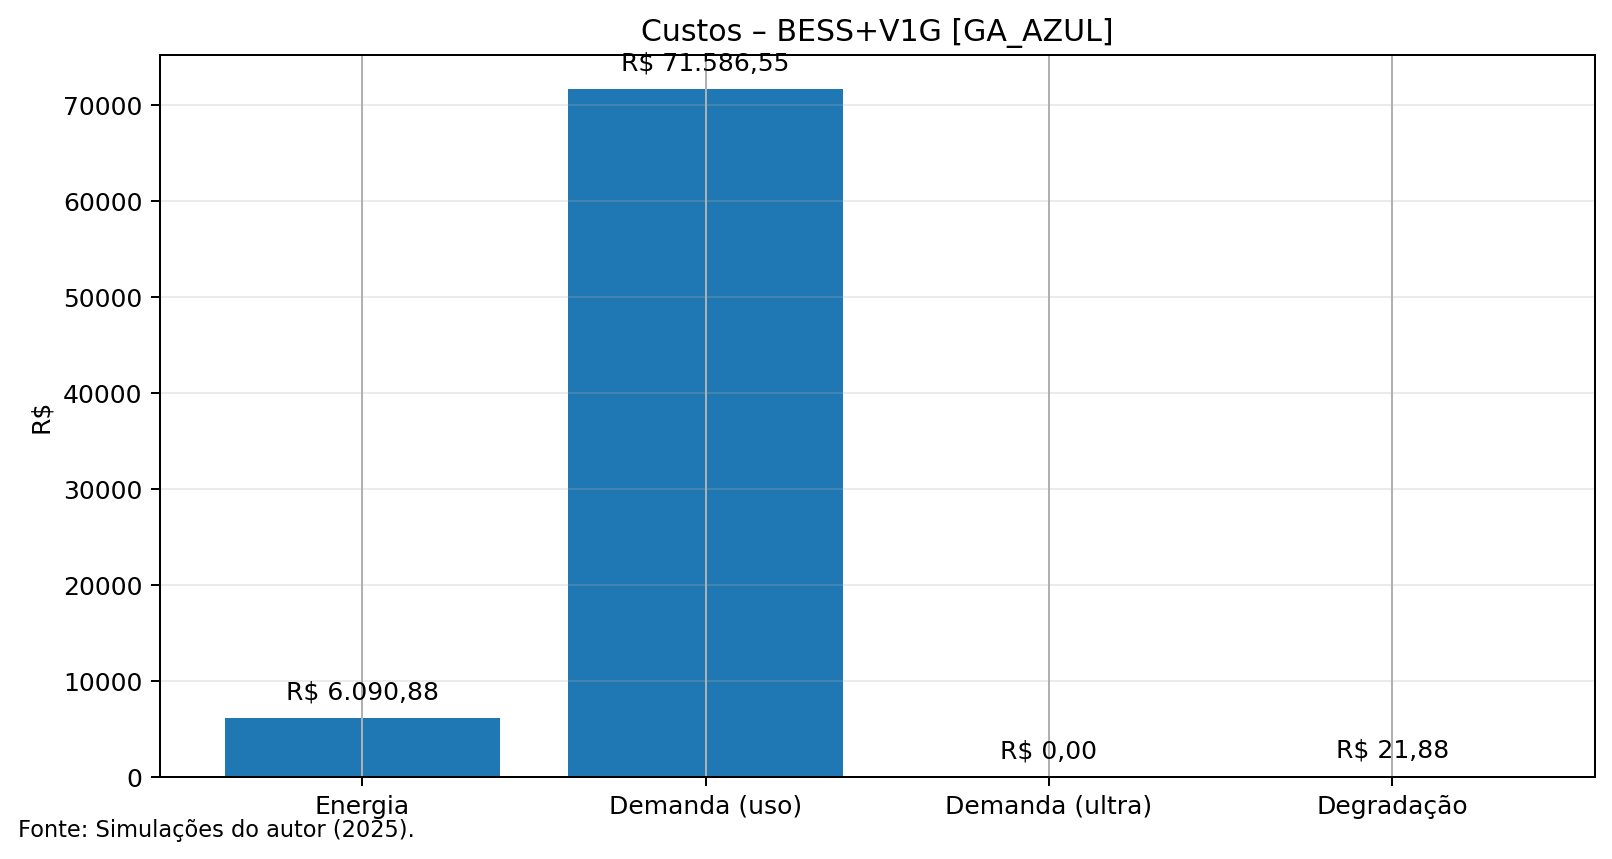

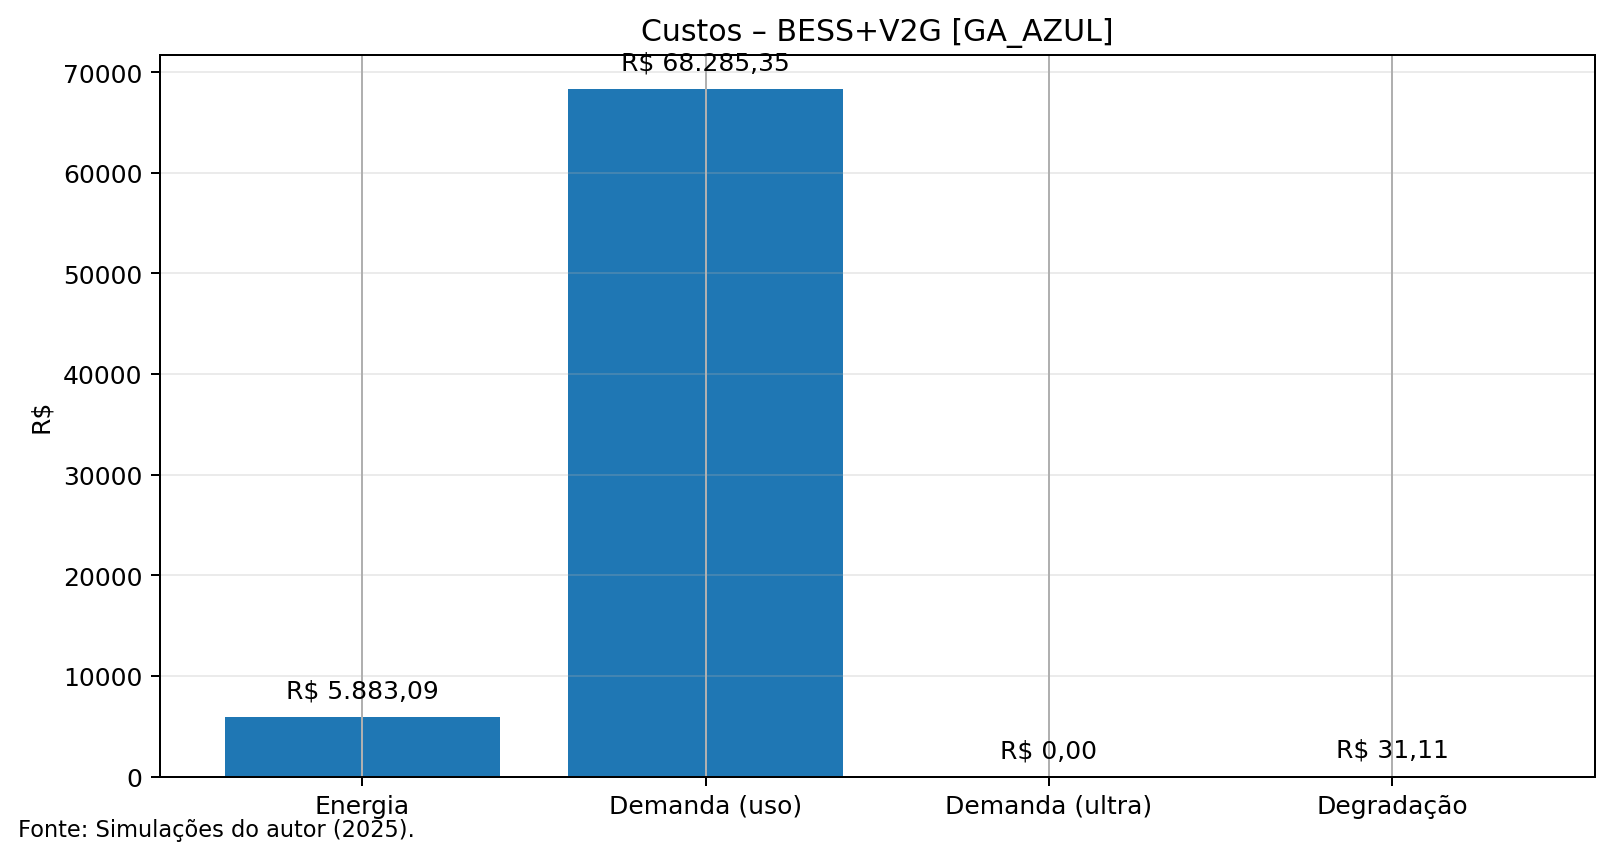

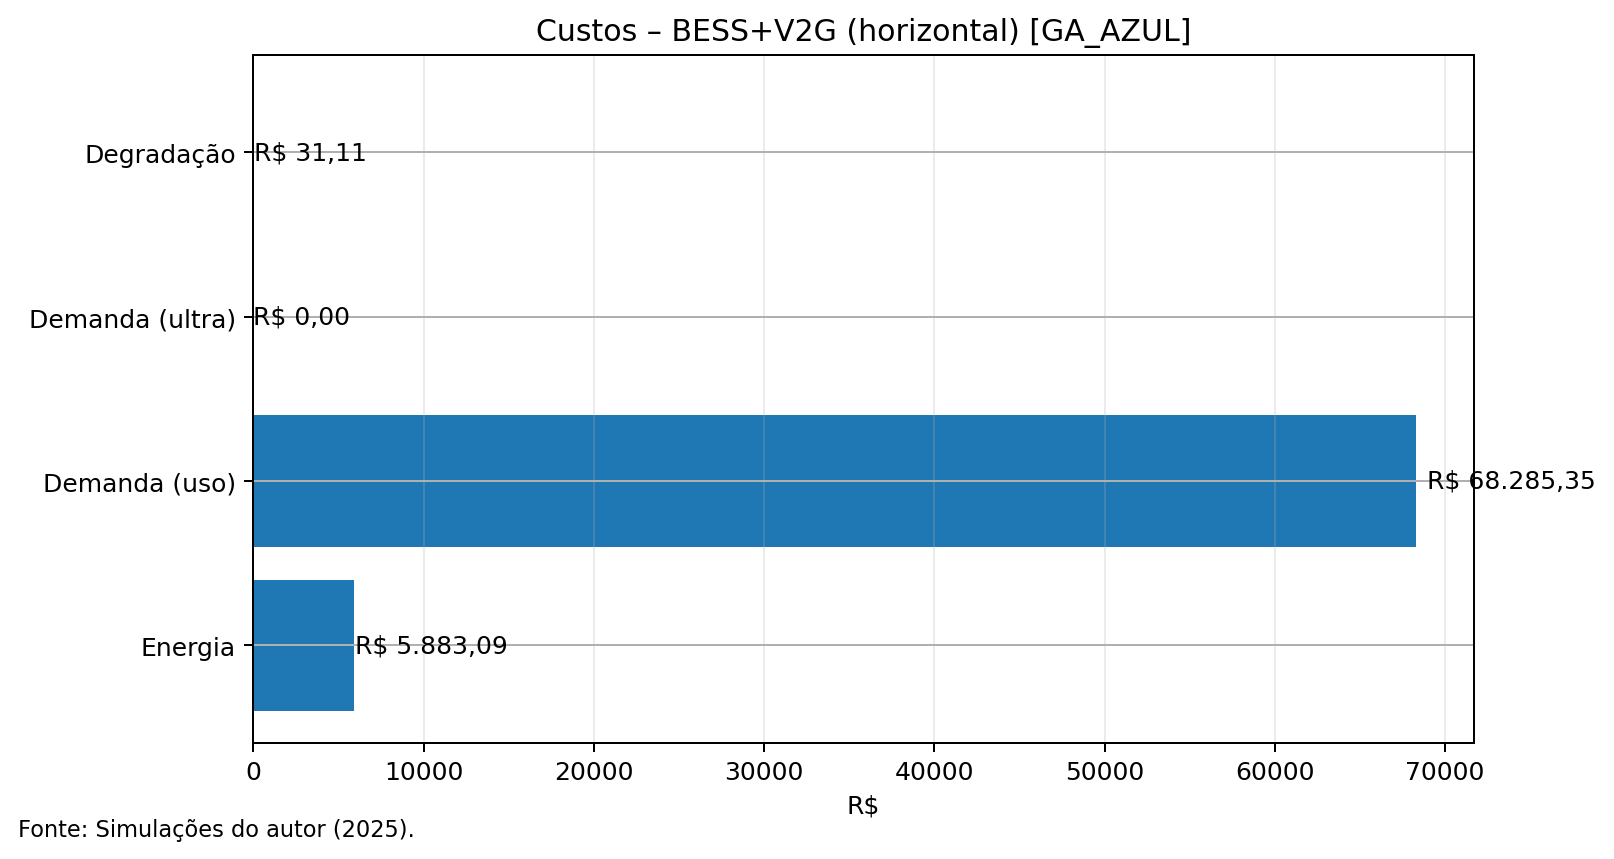

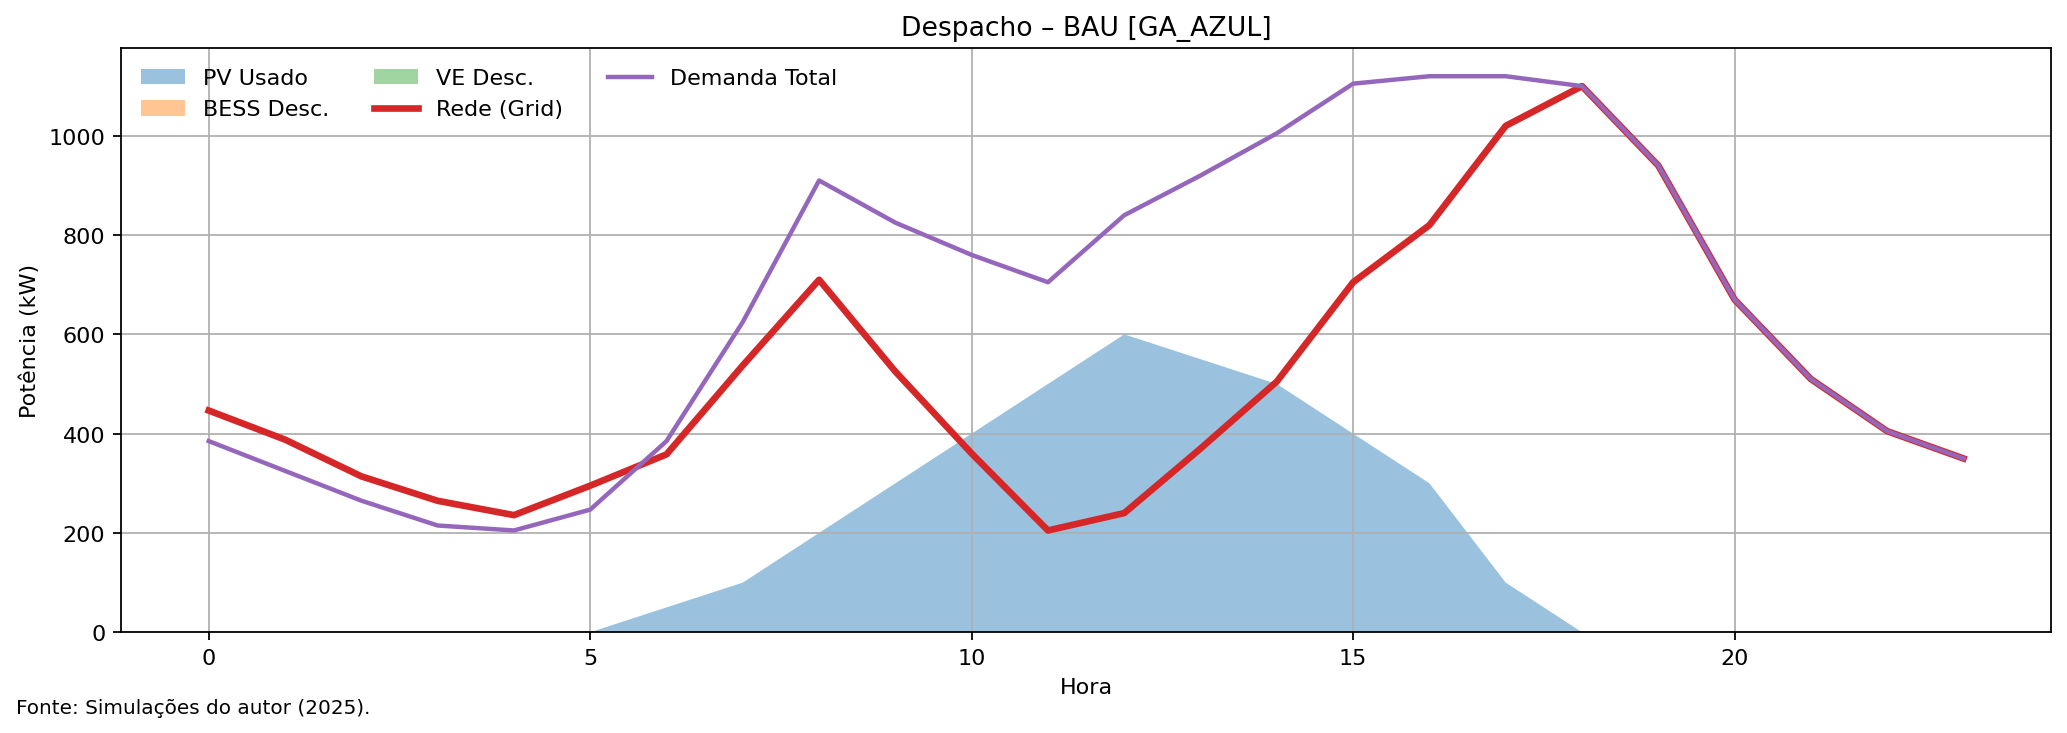

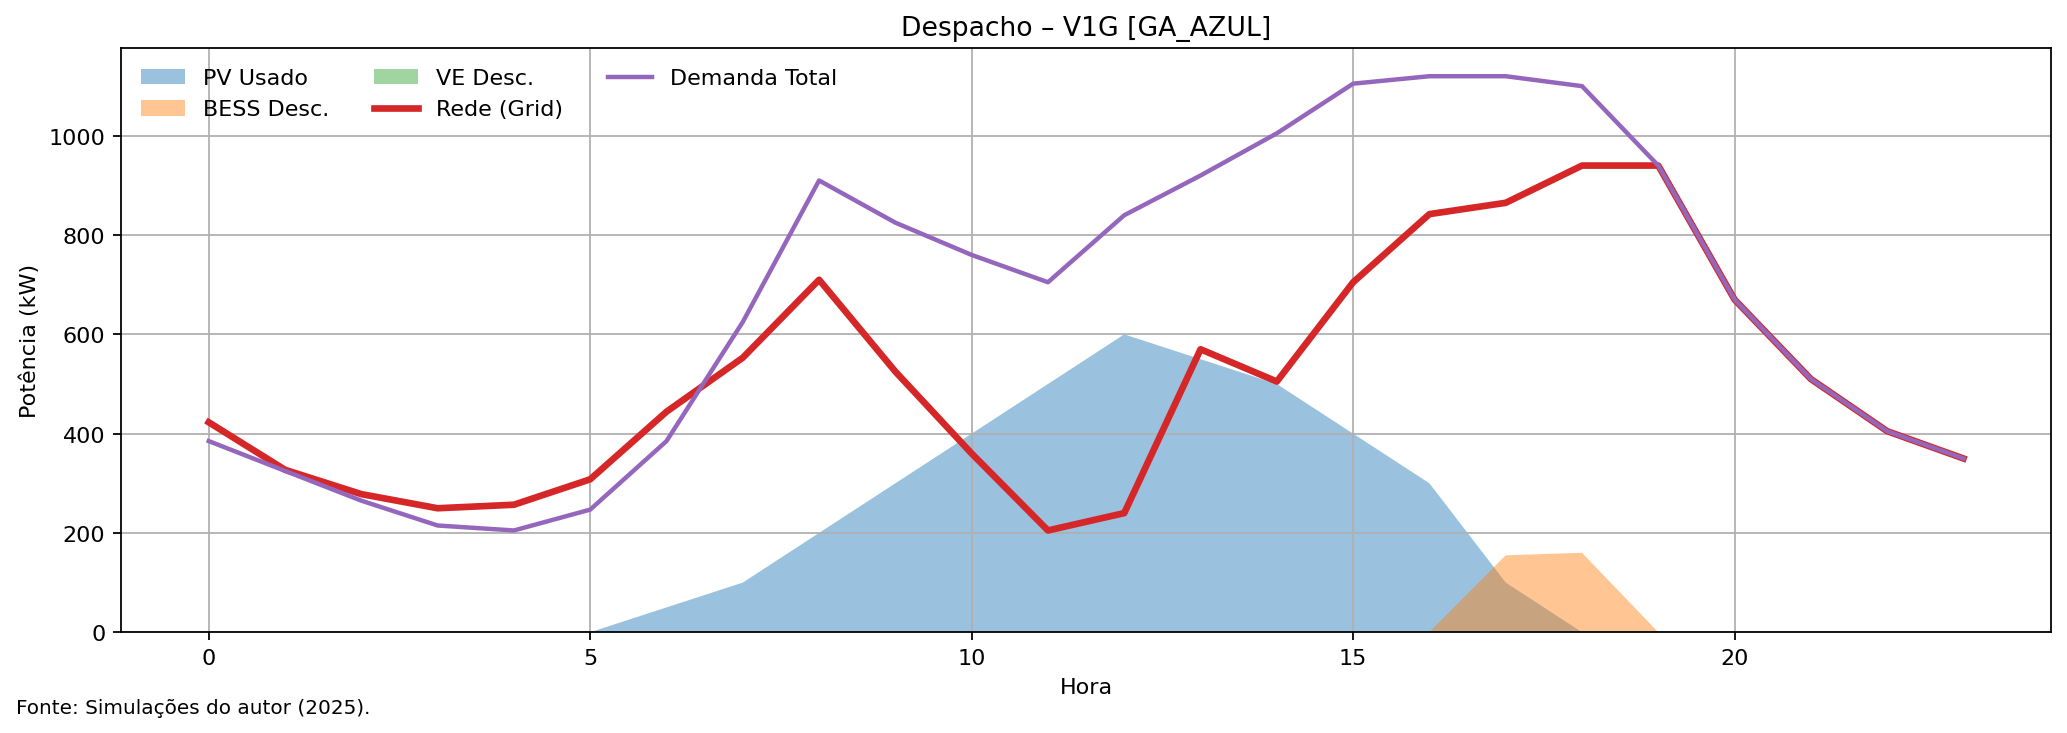

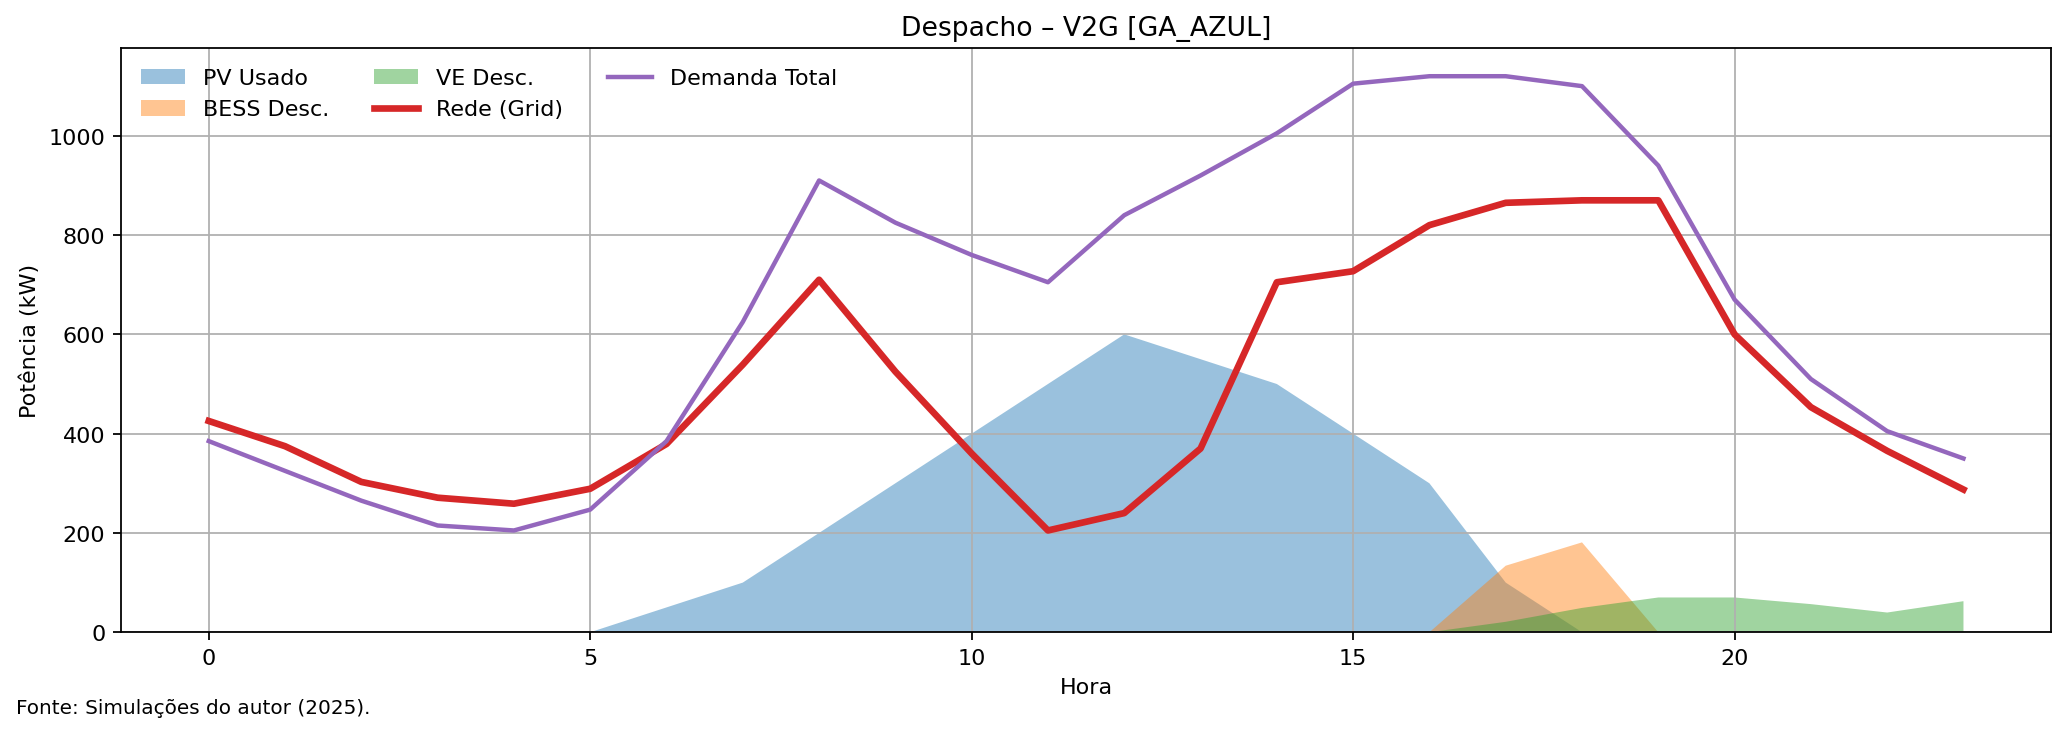

In [13]:
# === Exibir todas as figuras geradas por estrutura (inline no Colab) ===
from IPython.display import display, HTML, Image as IPyImage
import os

def show_all_figs(structures=("B","GA_VERDE","GA_AZUL"), width=1100):
    templates = [
        "kpi_global_triptych_{s}.png",
        "kpi_global_single_{s}.png",
        "soc_v2g_legenda_fora_{s}.png",
        "soc_v2g_legenda_dentro_{s}.png",
        "custos_BAU_vertical_{s}.png",
        "custos_V1G_vertical_{s}.png",
        "custos_V2G_vertical_{s}.png",
        "custos_V2G_horizontal_{s}.png",
        "despacho_BAU_{s}.png",
        "despacho_V1G_{s}.png",
        "despacho_V2G_{s}.png",
    ]
    for s in structures:
        display(HTML(f"<h2 style='margin:16px 0'>Estrutura: {s}</h2>"))
        for t in templates:
            fname = t.format(s=s)
            if os.path.exists(fname):
                display(HTML(f"<div style='font-weight:600;margin:8px 0'>{fname}</div>"))
                display(IPyImage(filename=fname, width=width))
            else:
                display(HTML(f"<div style='color:#a00'>[Aviso] Arquivo não encontrado: {fname}</div>"))

show_all_figs()


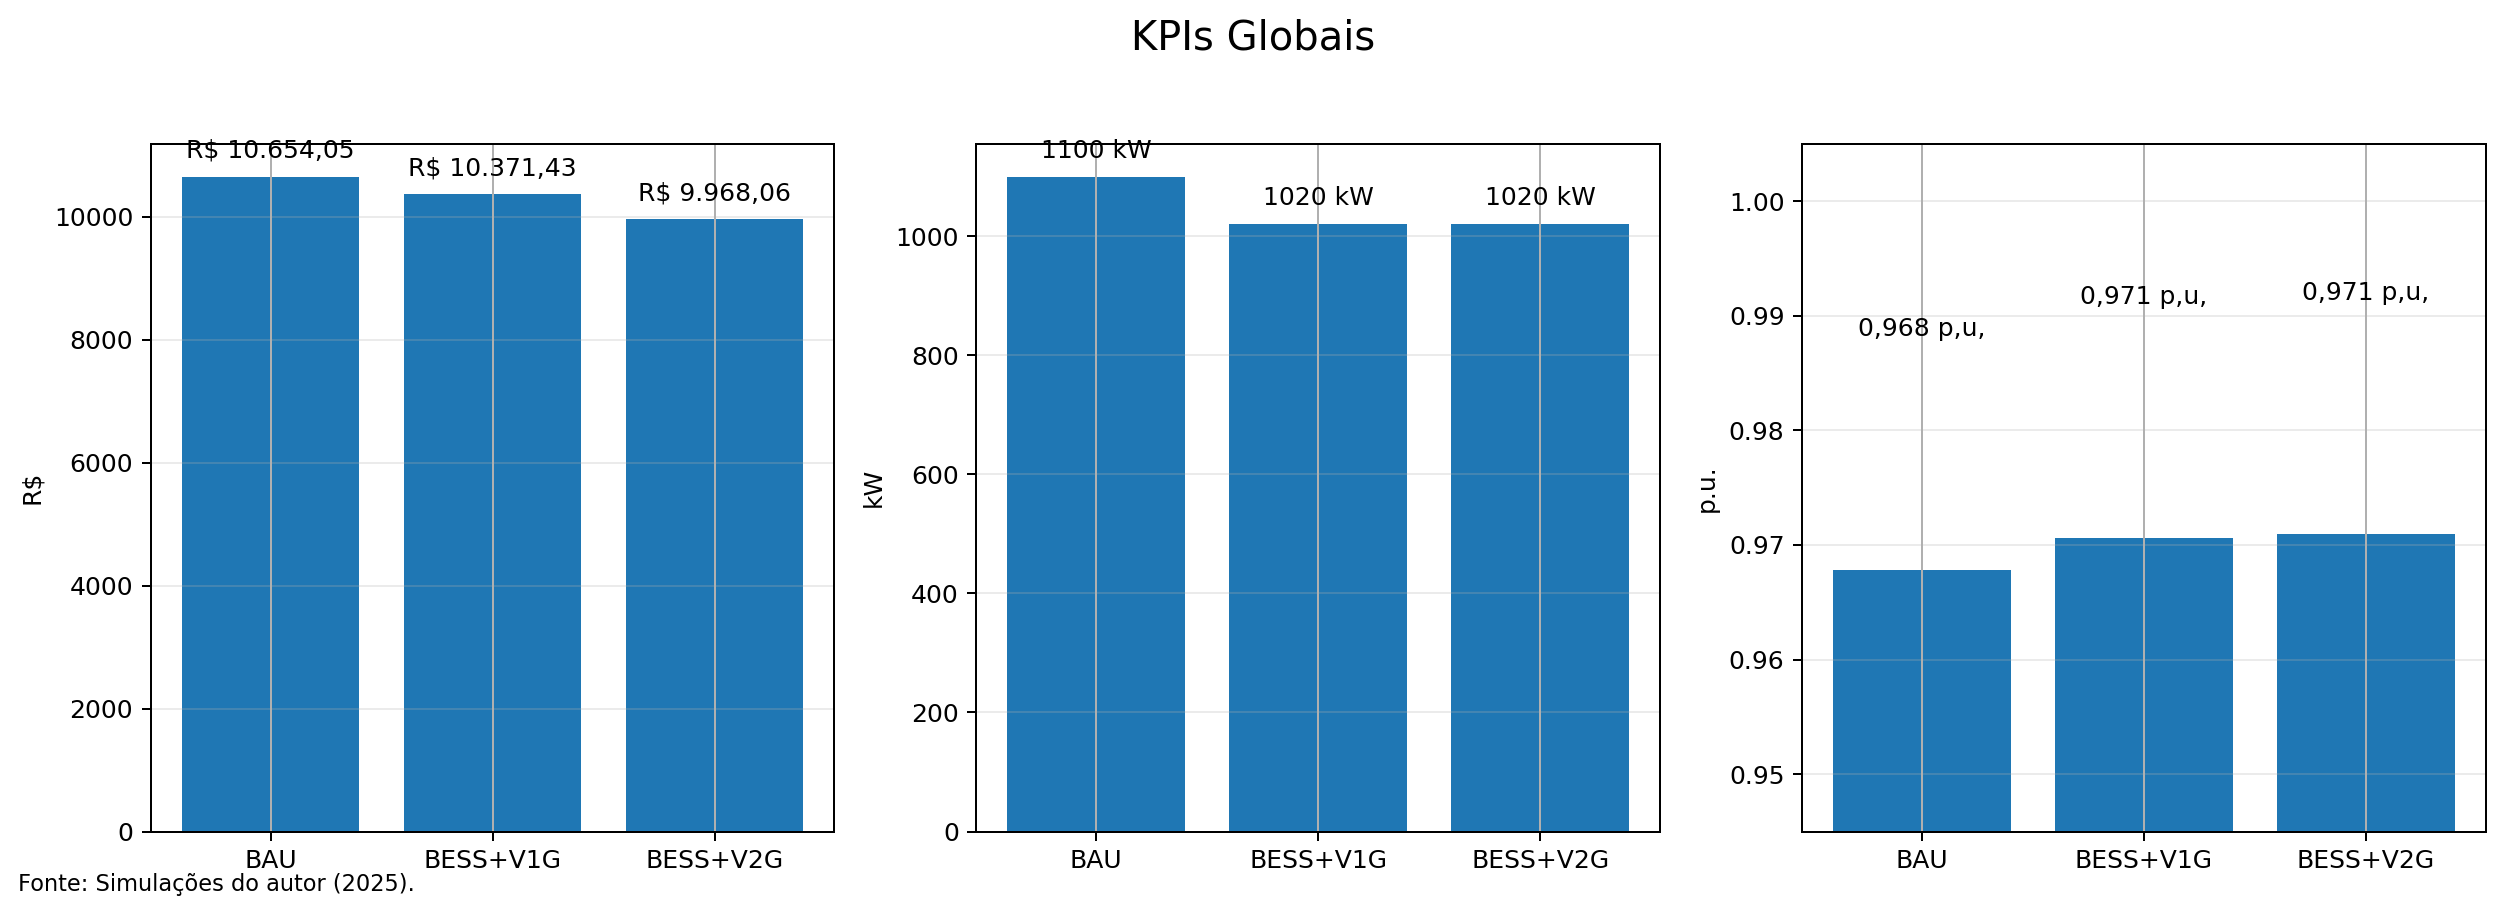

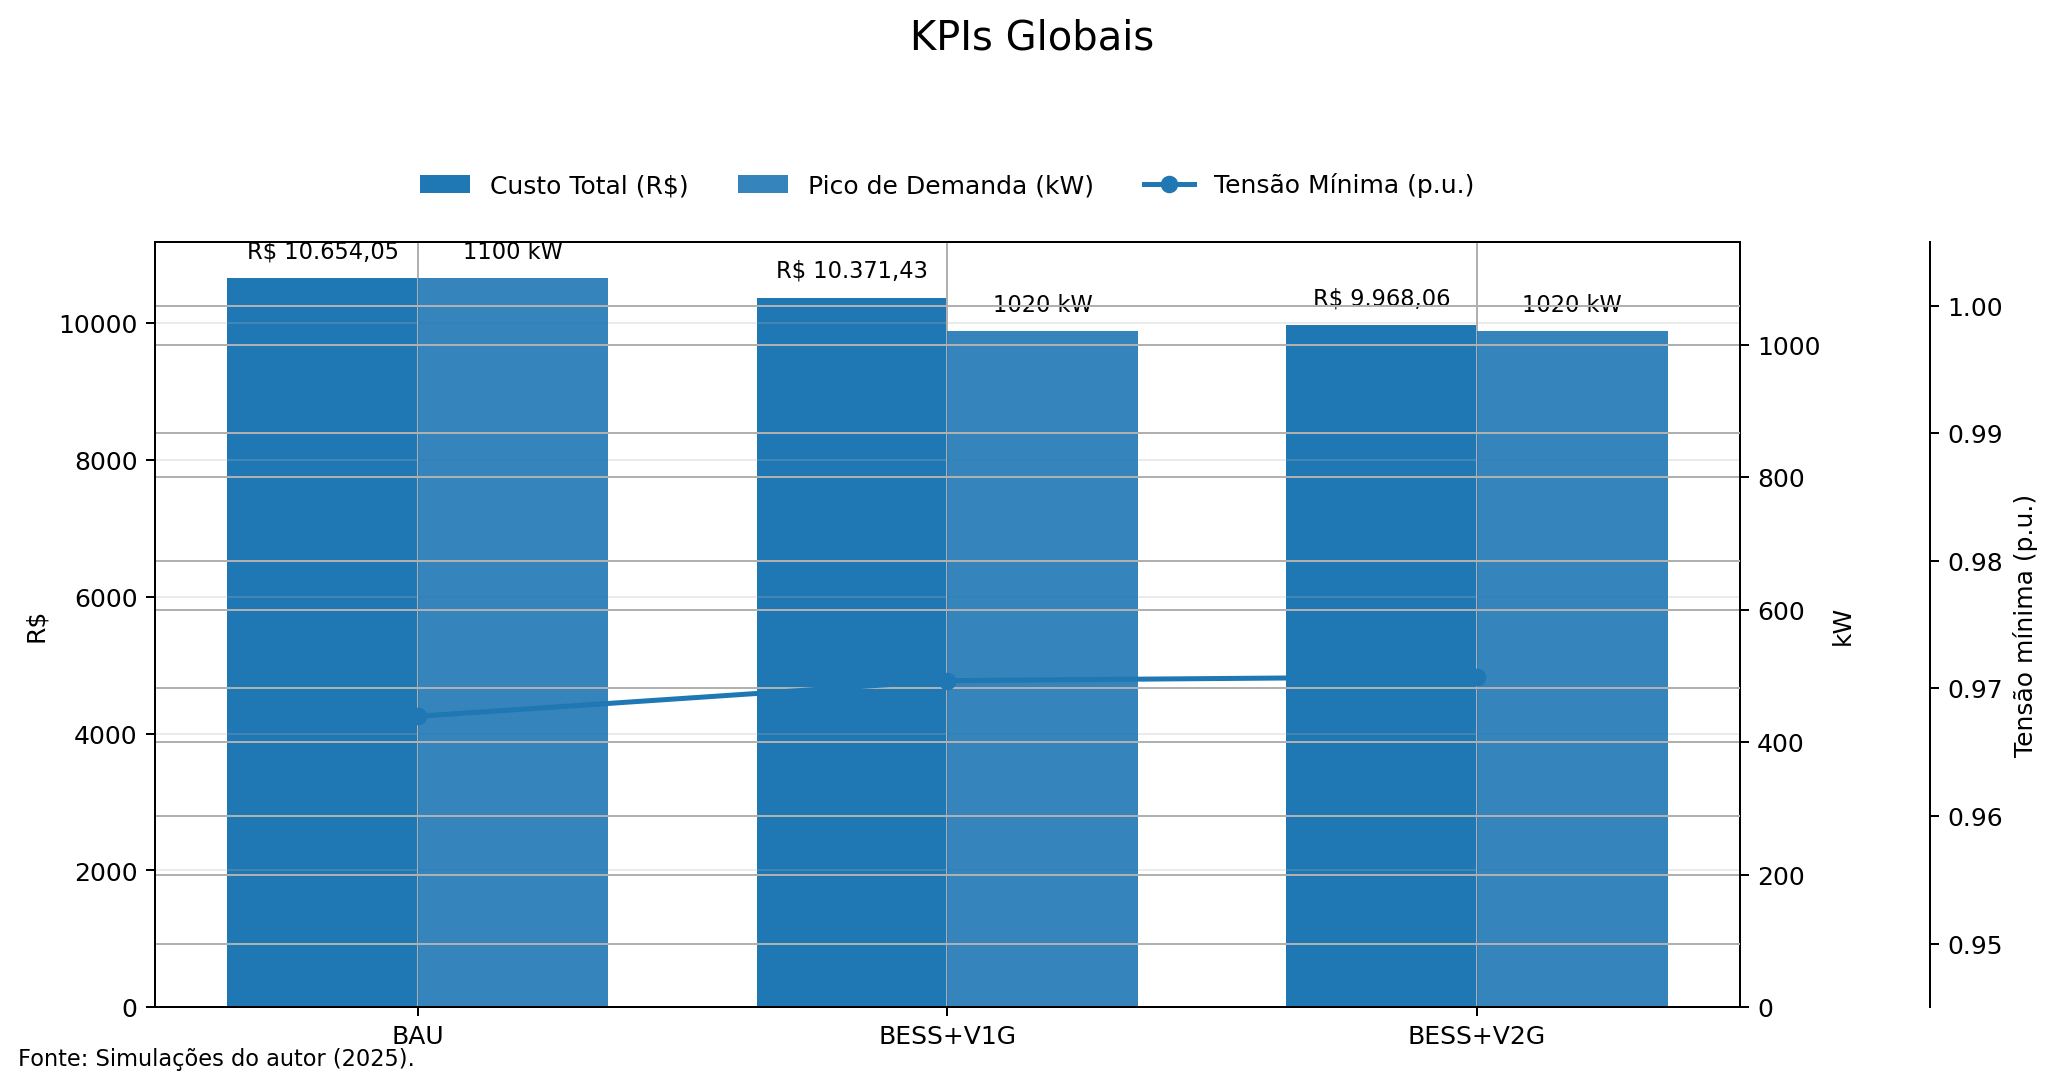

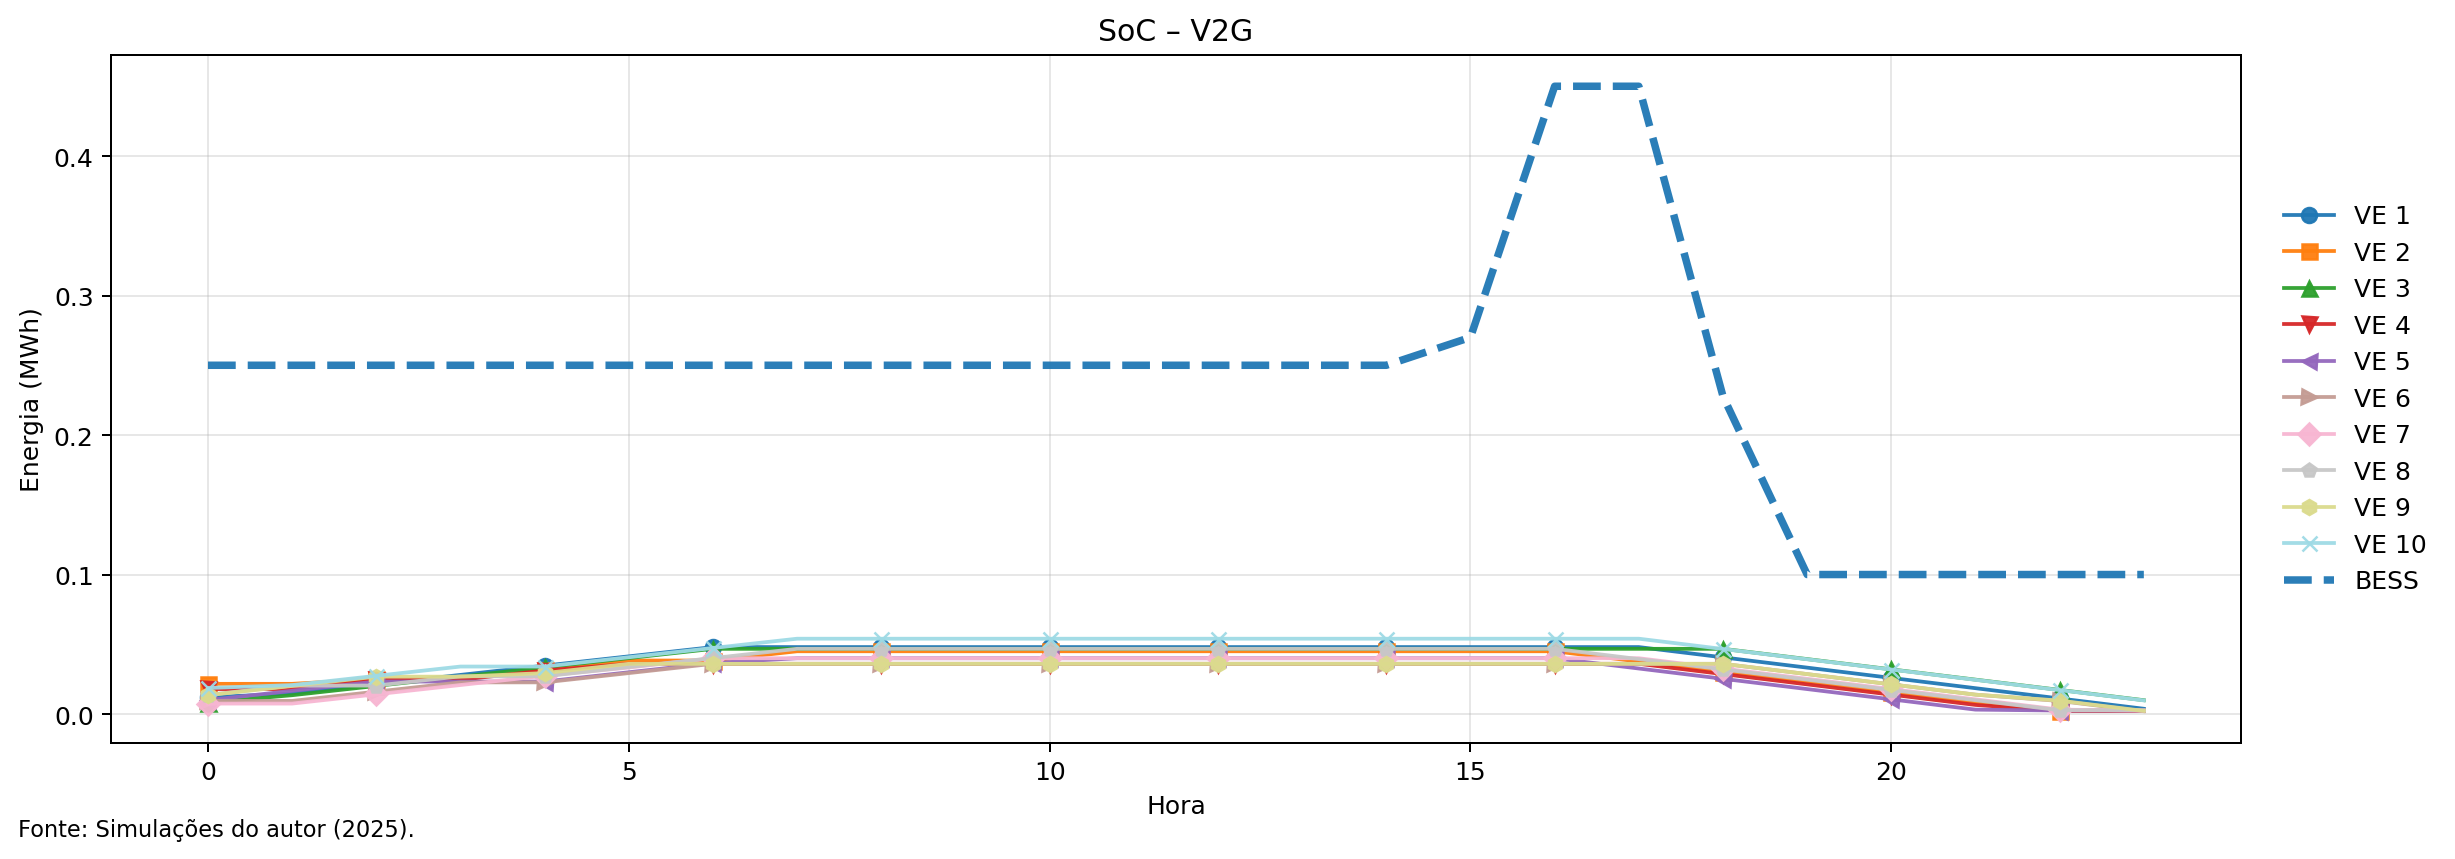

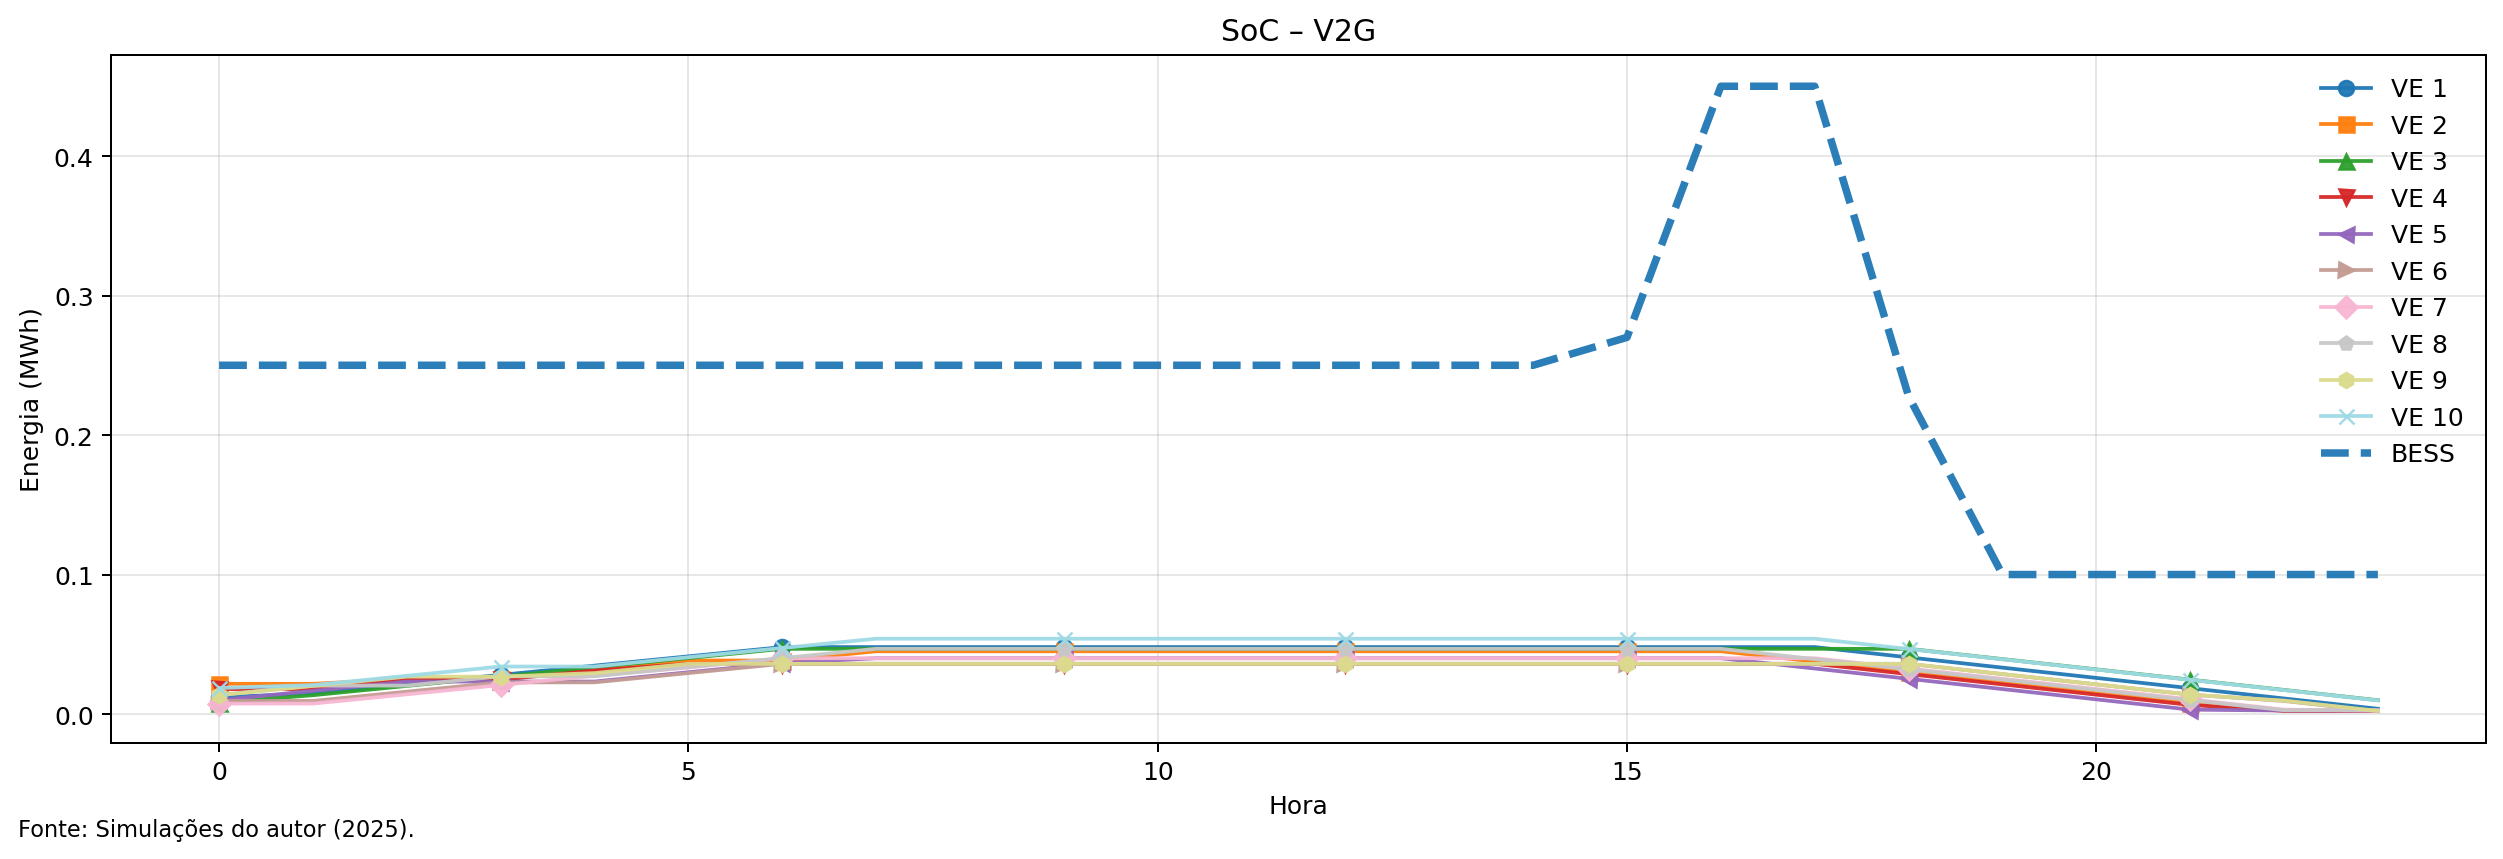

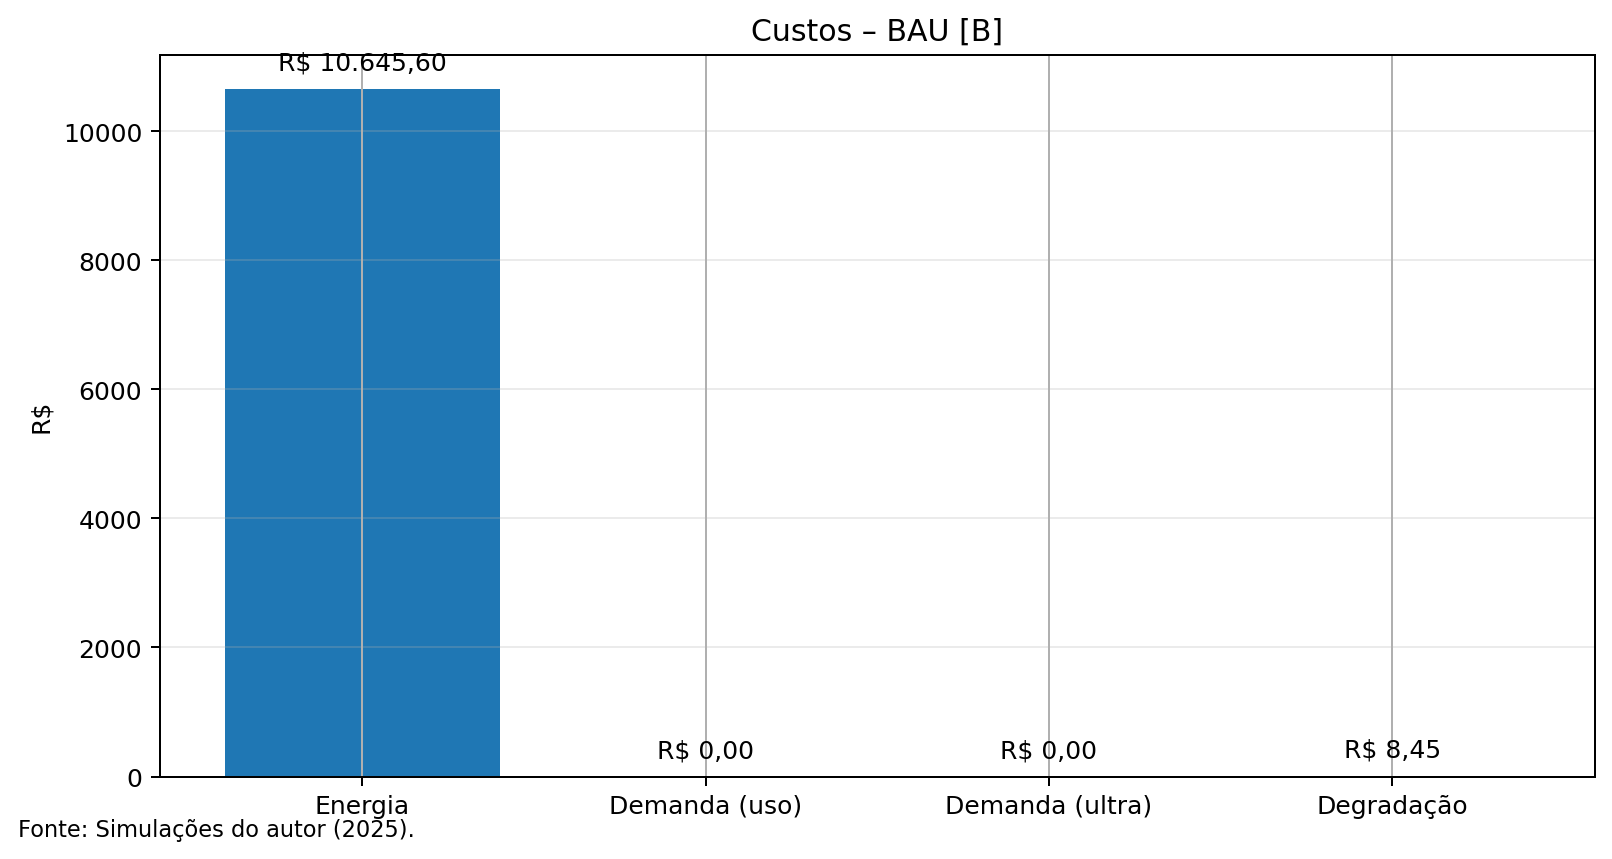

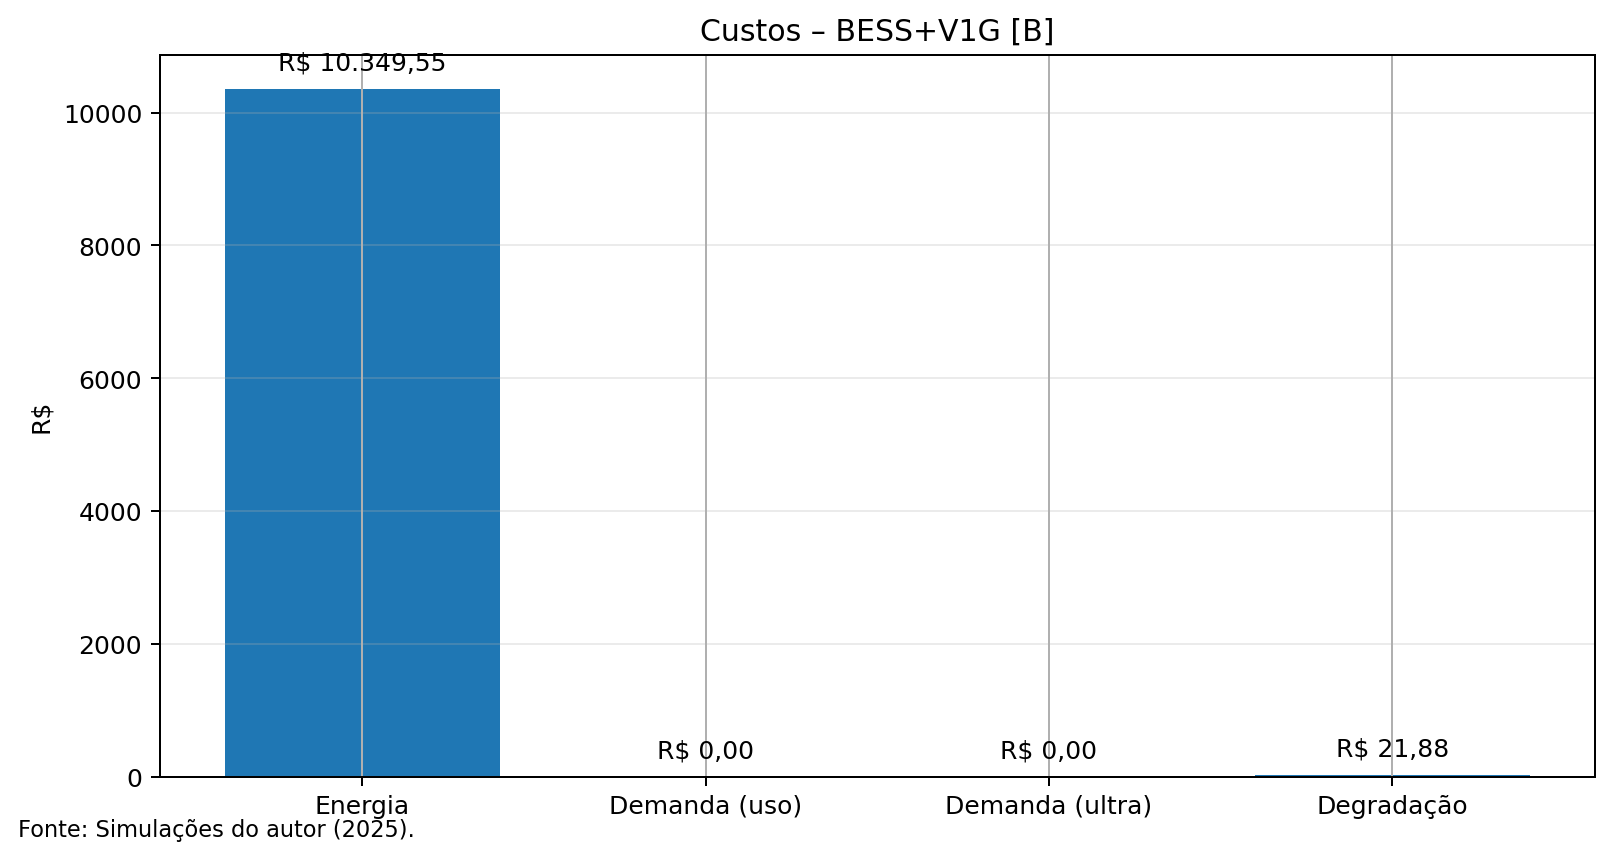

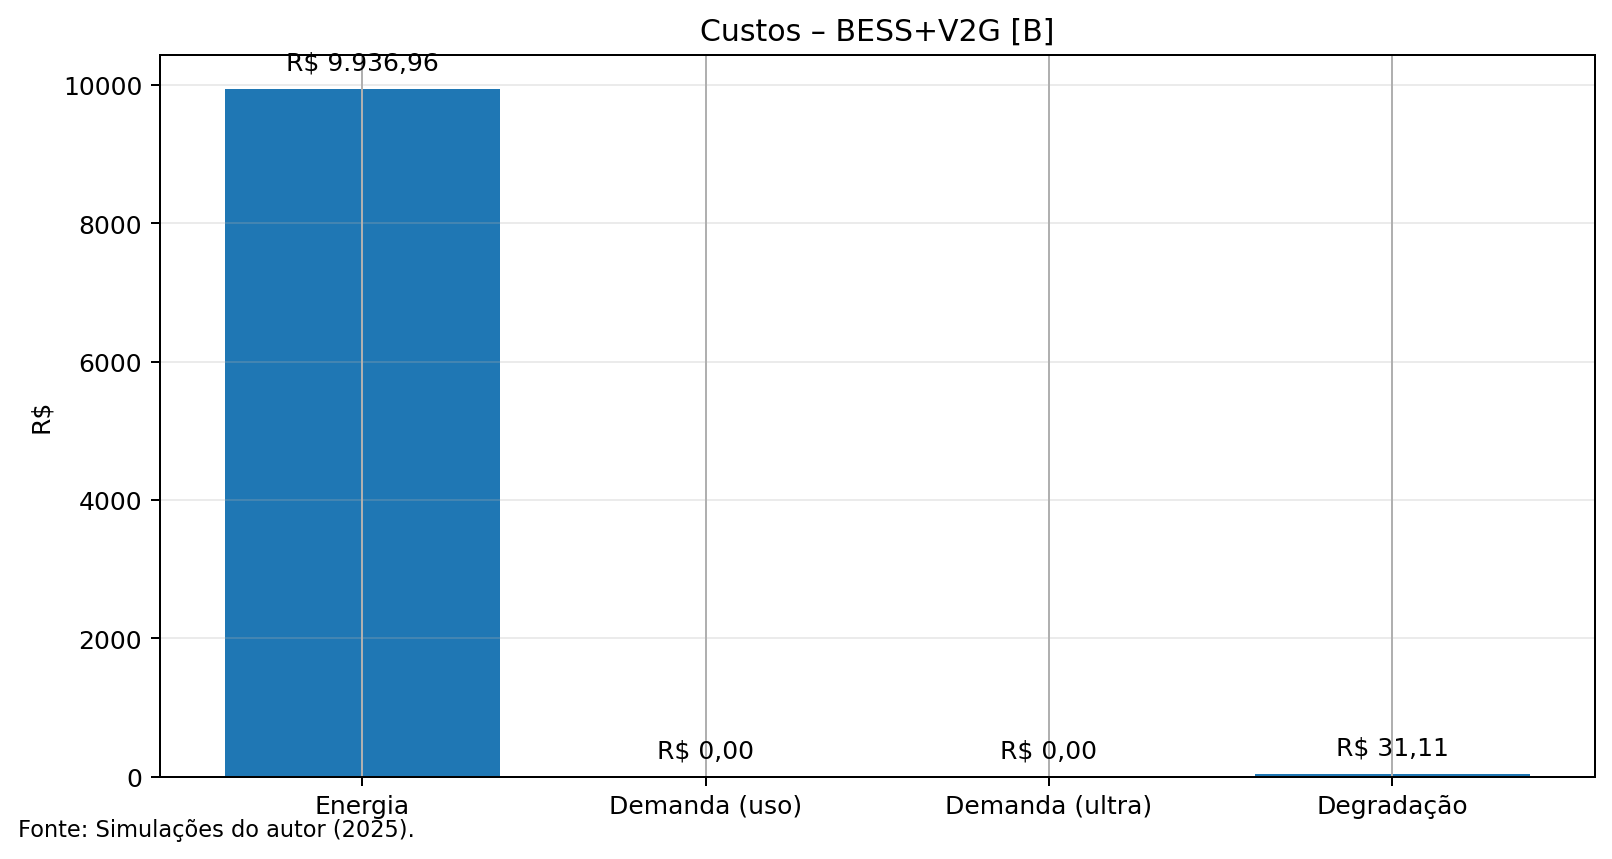

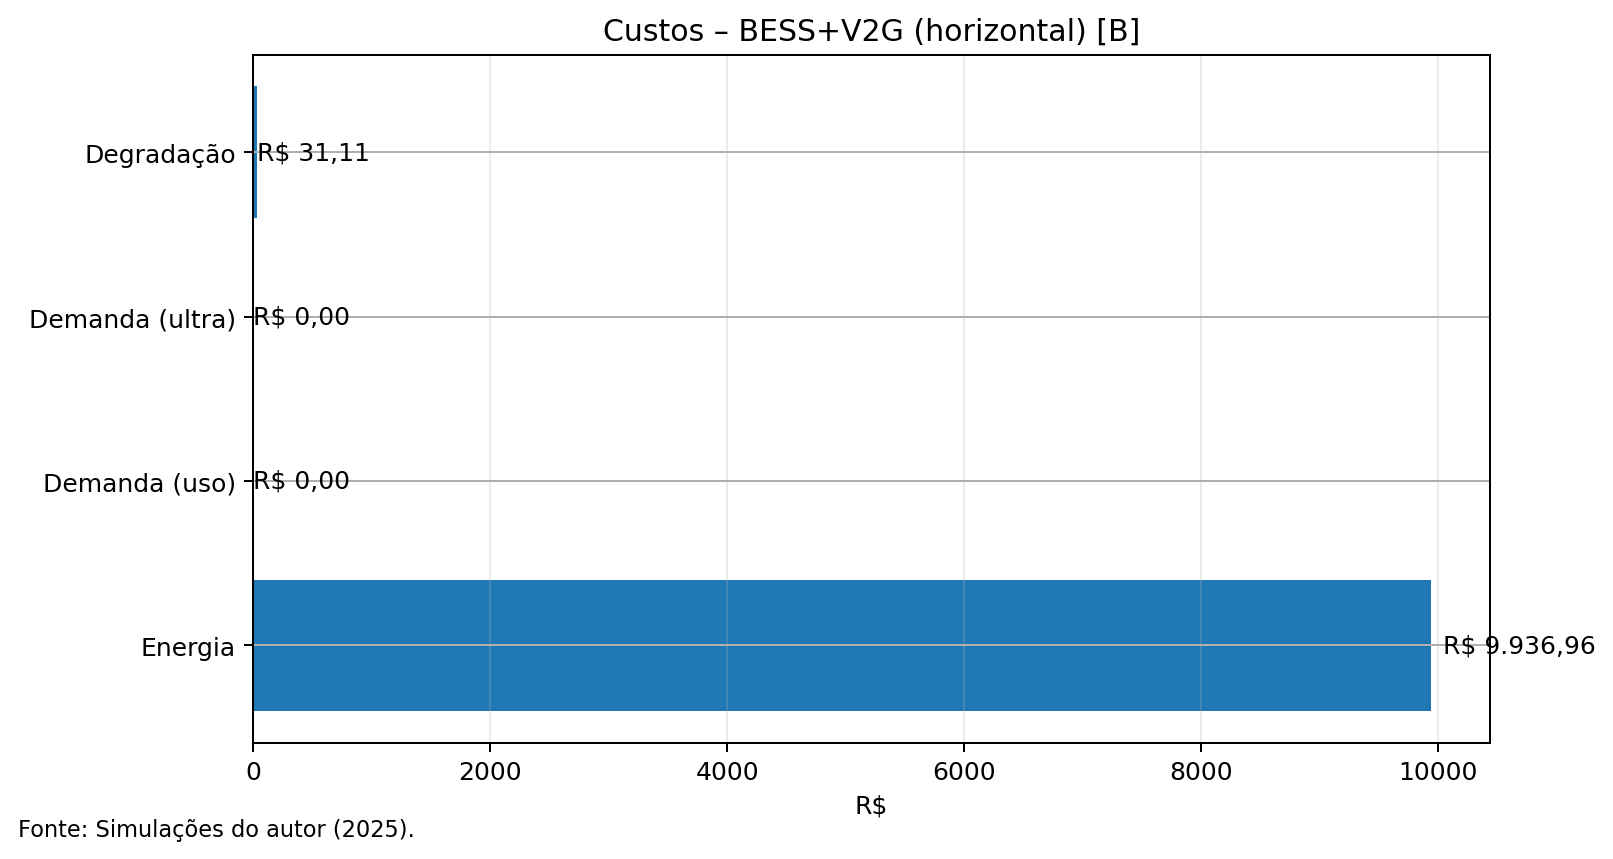

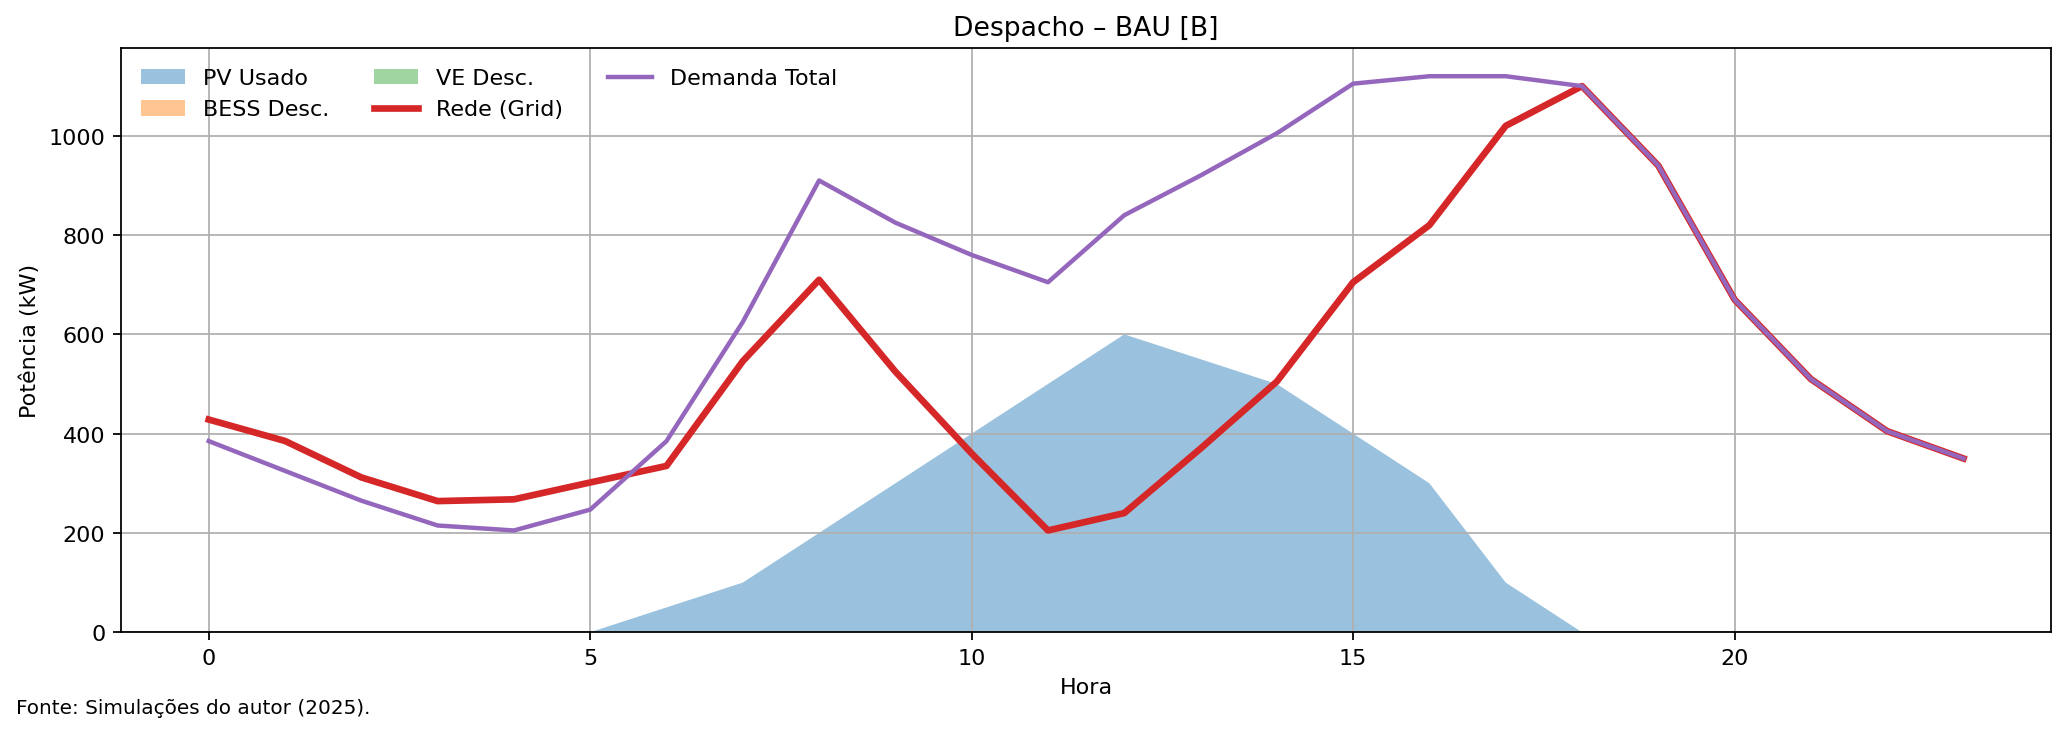

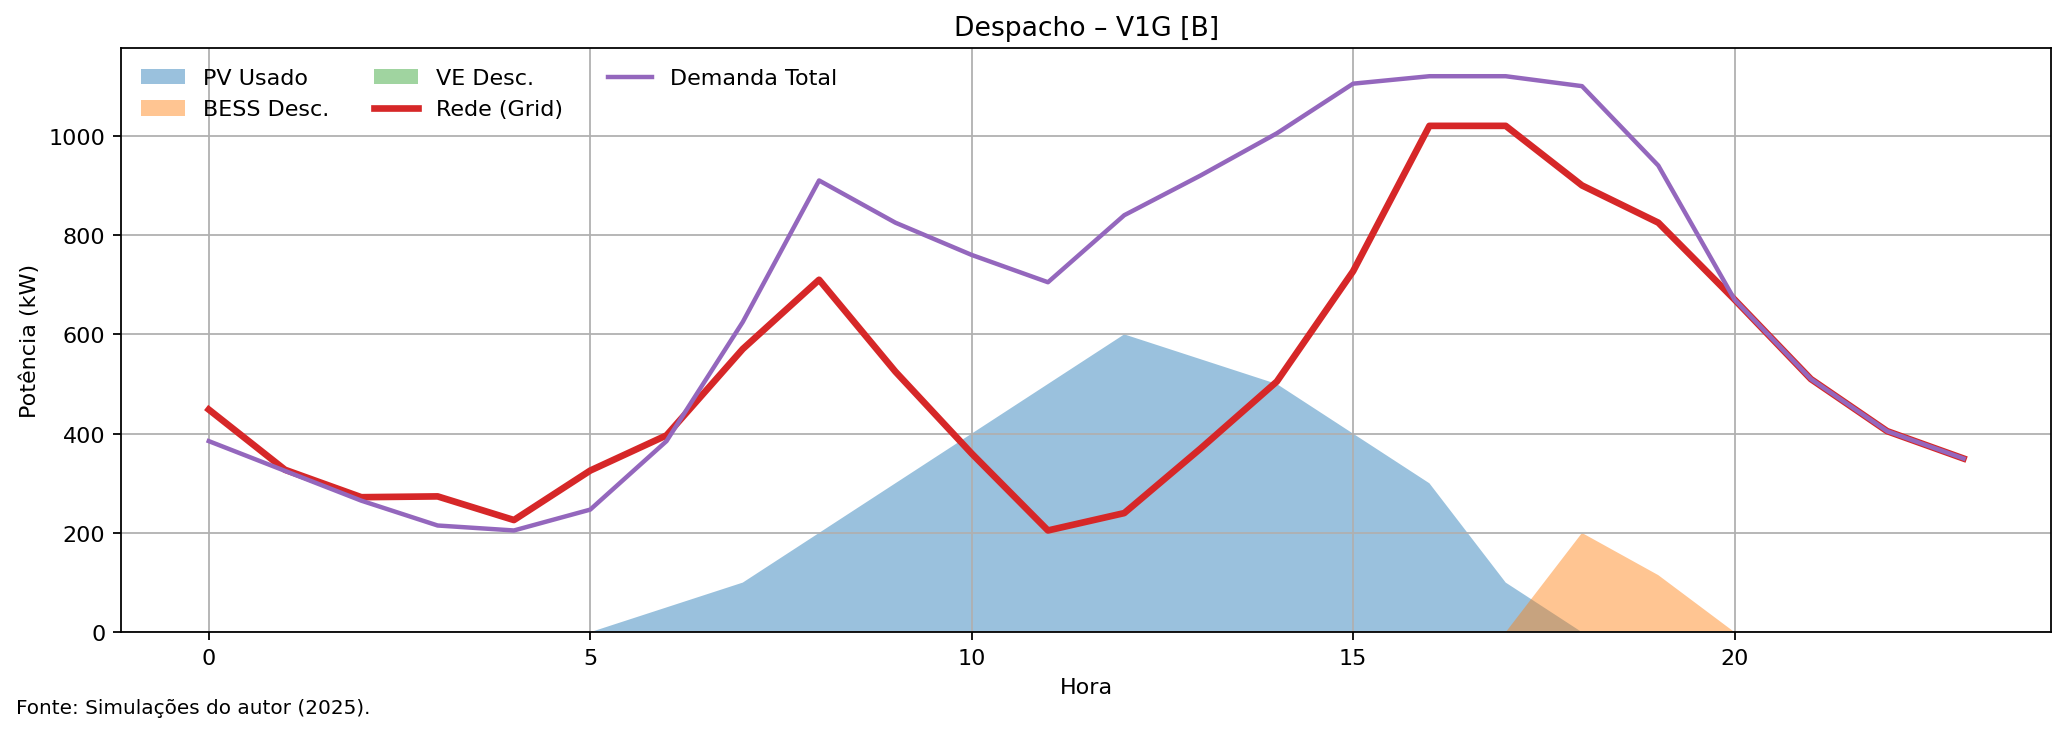

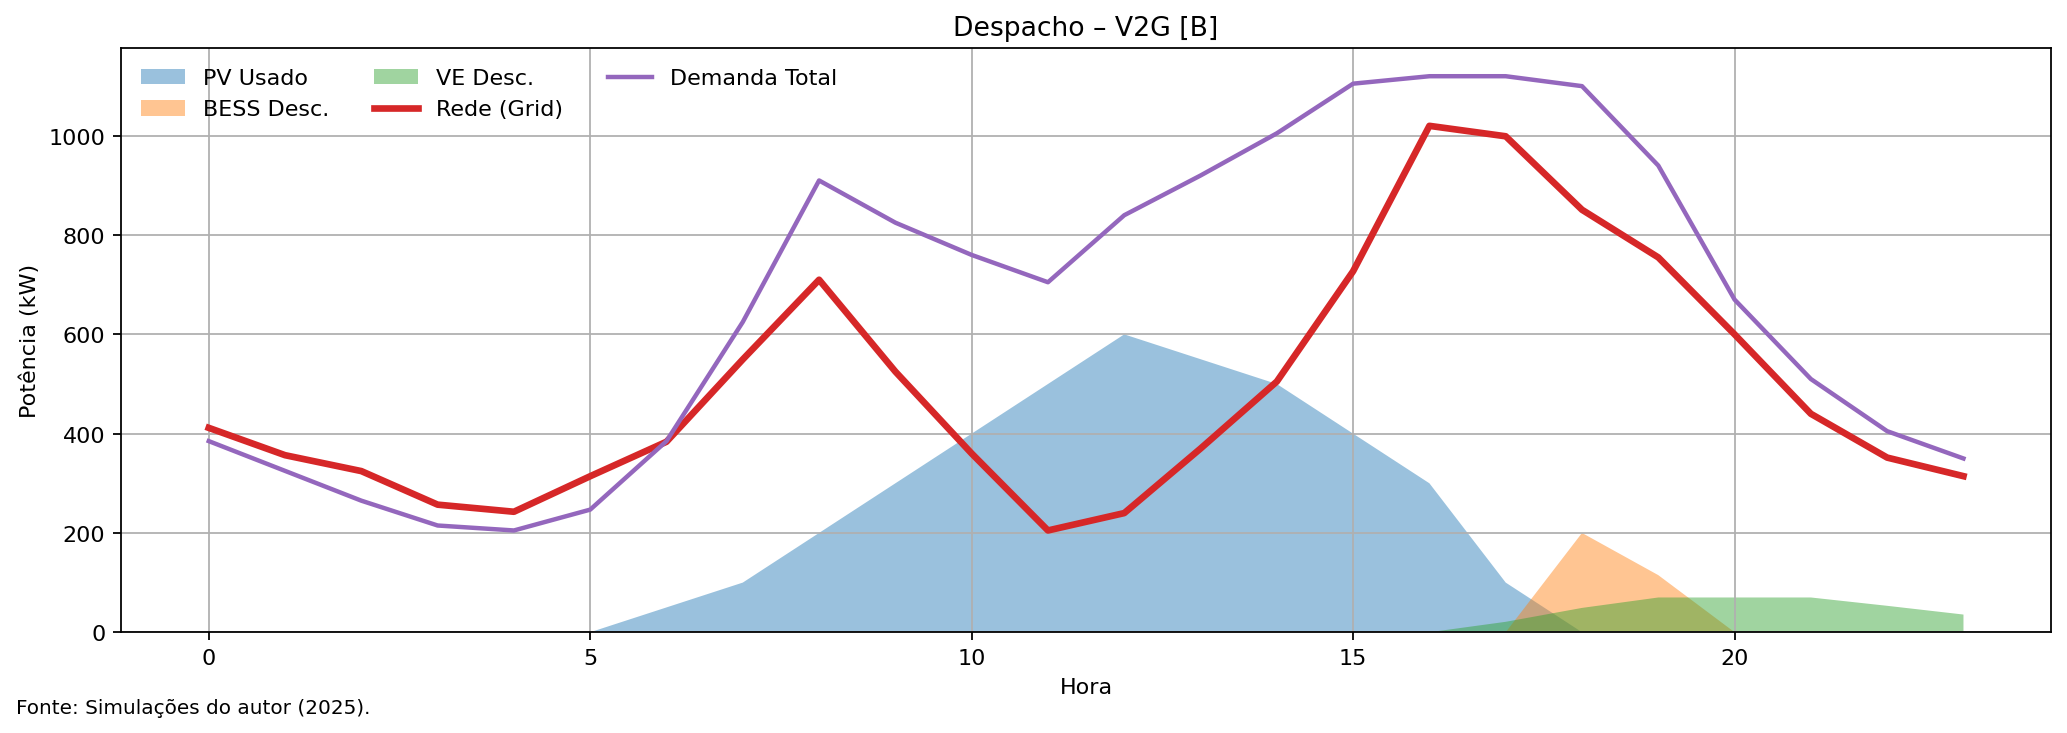

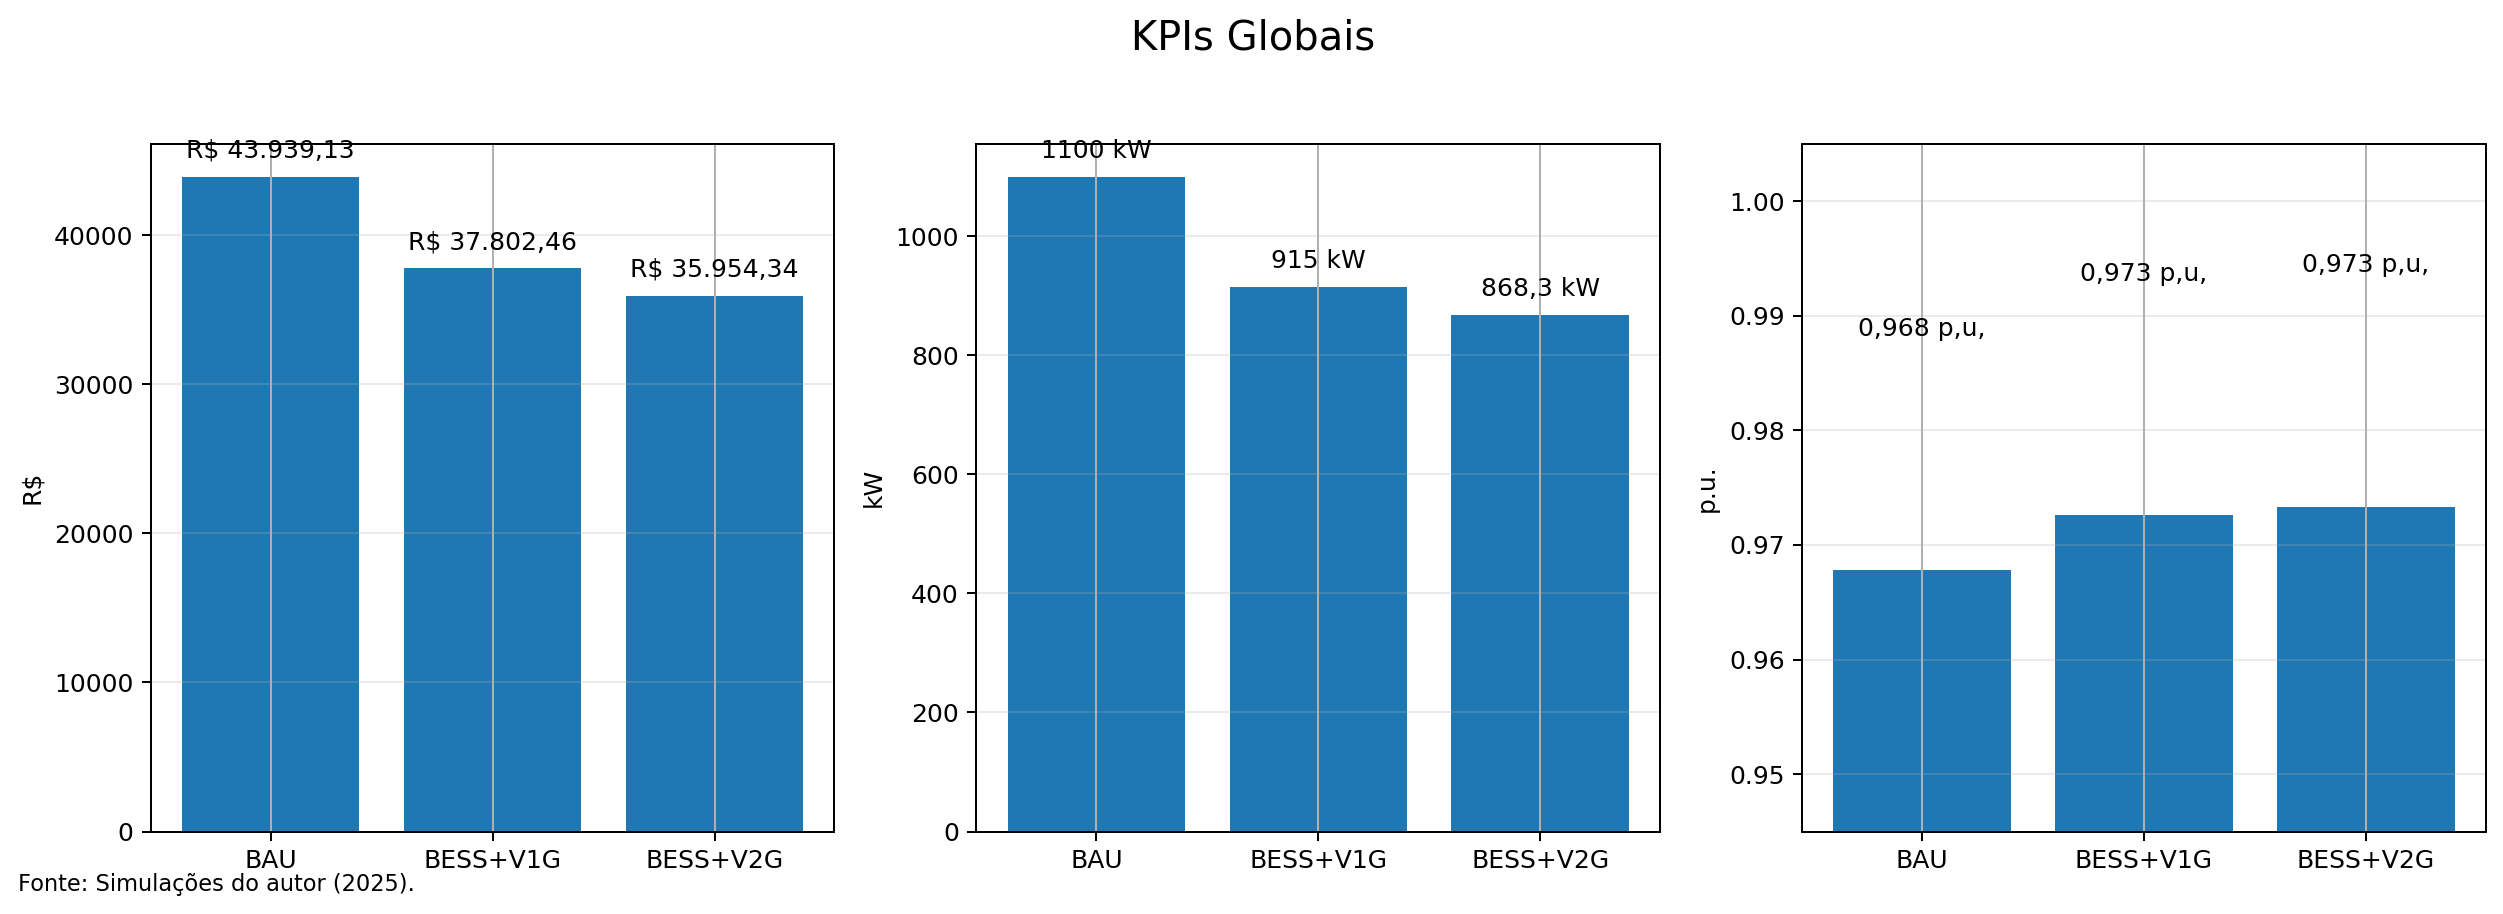

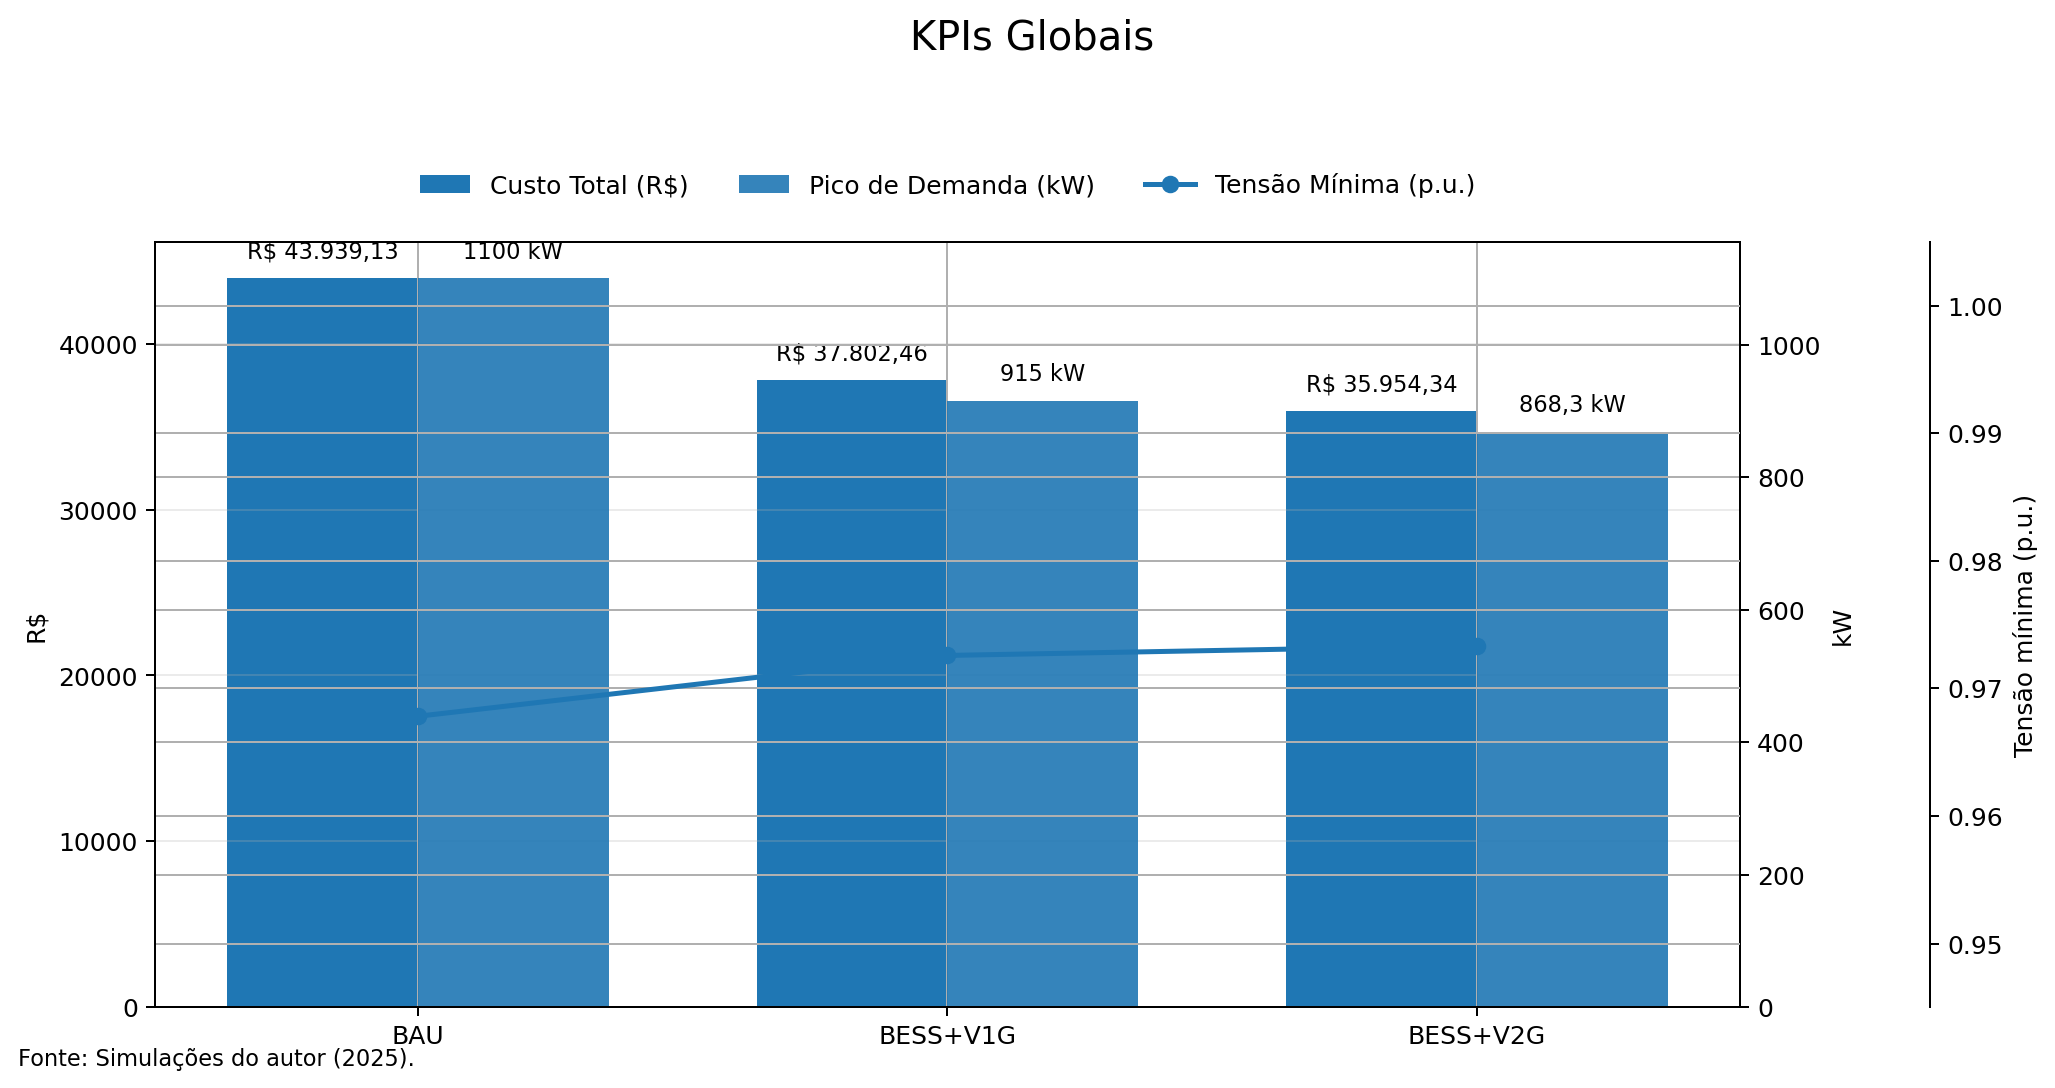

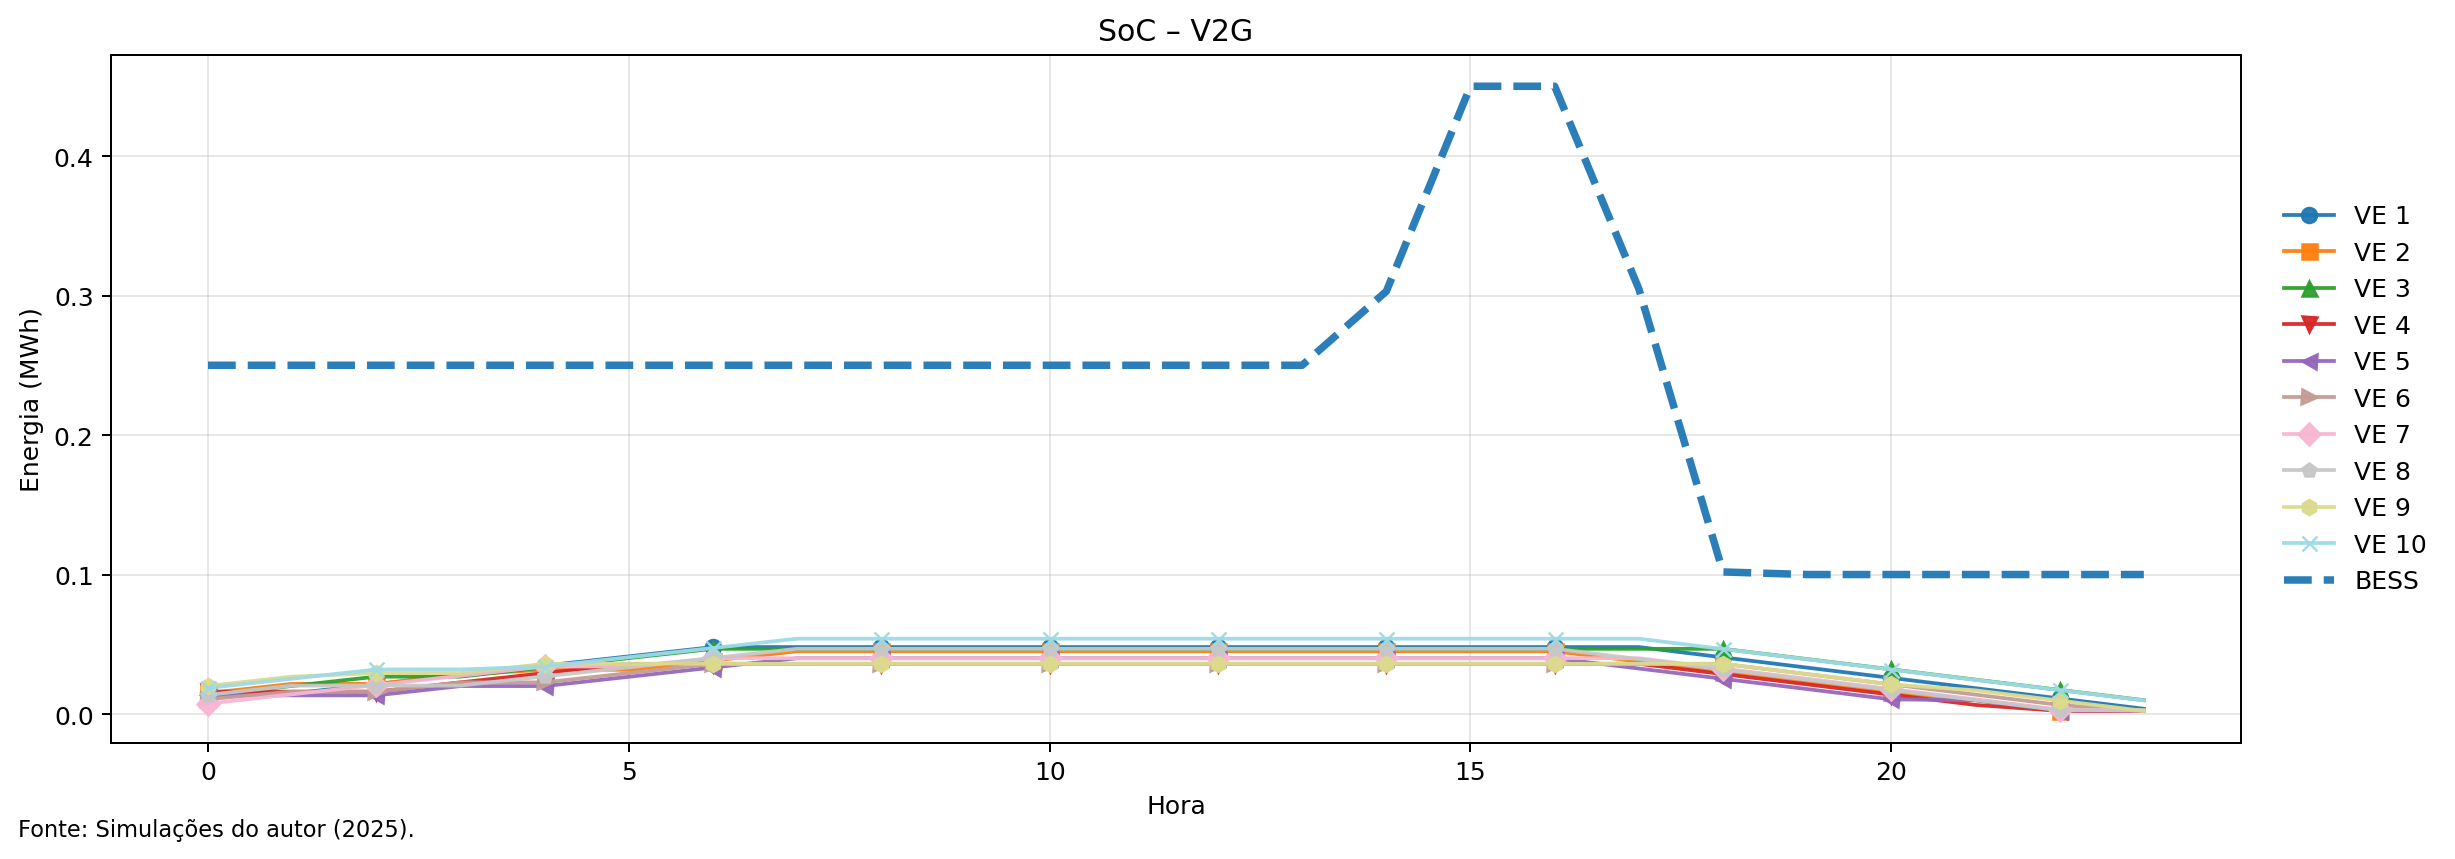

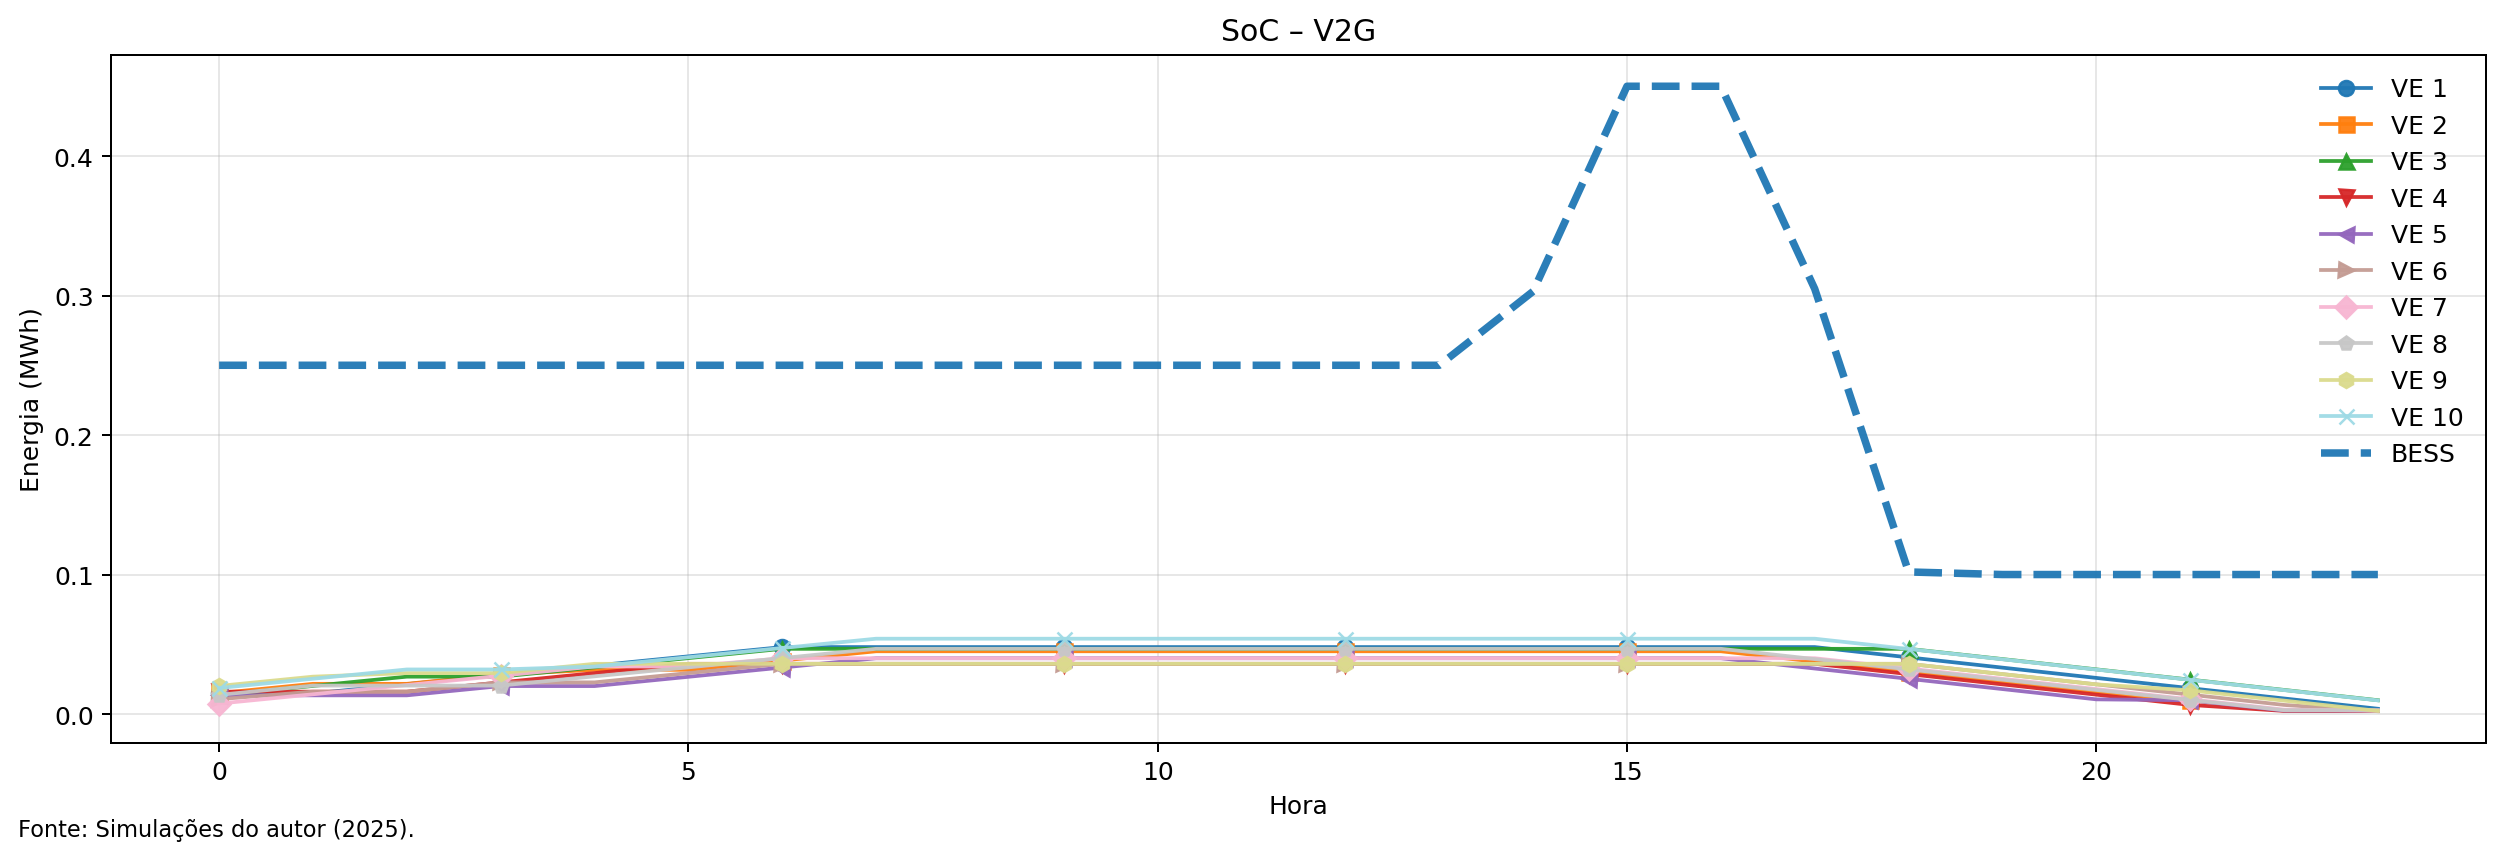

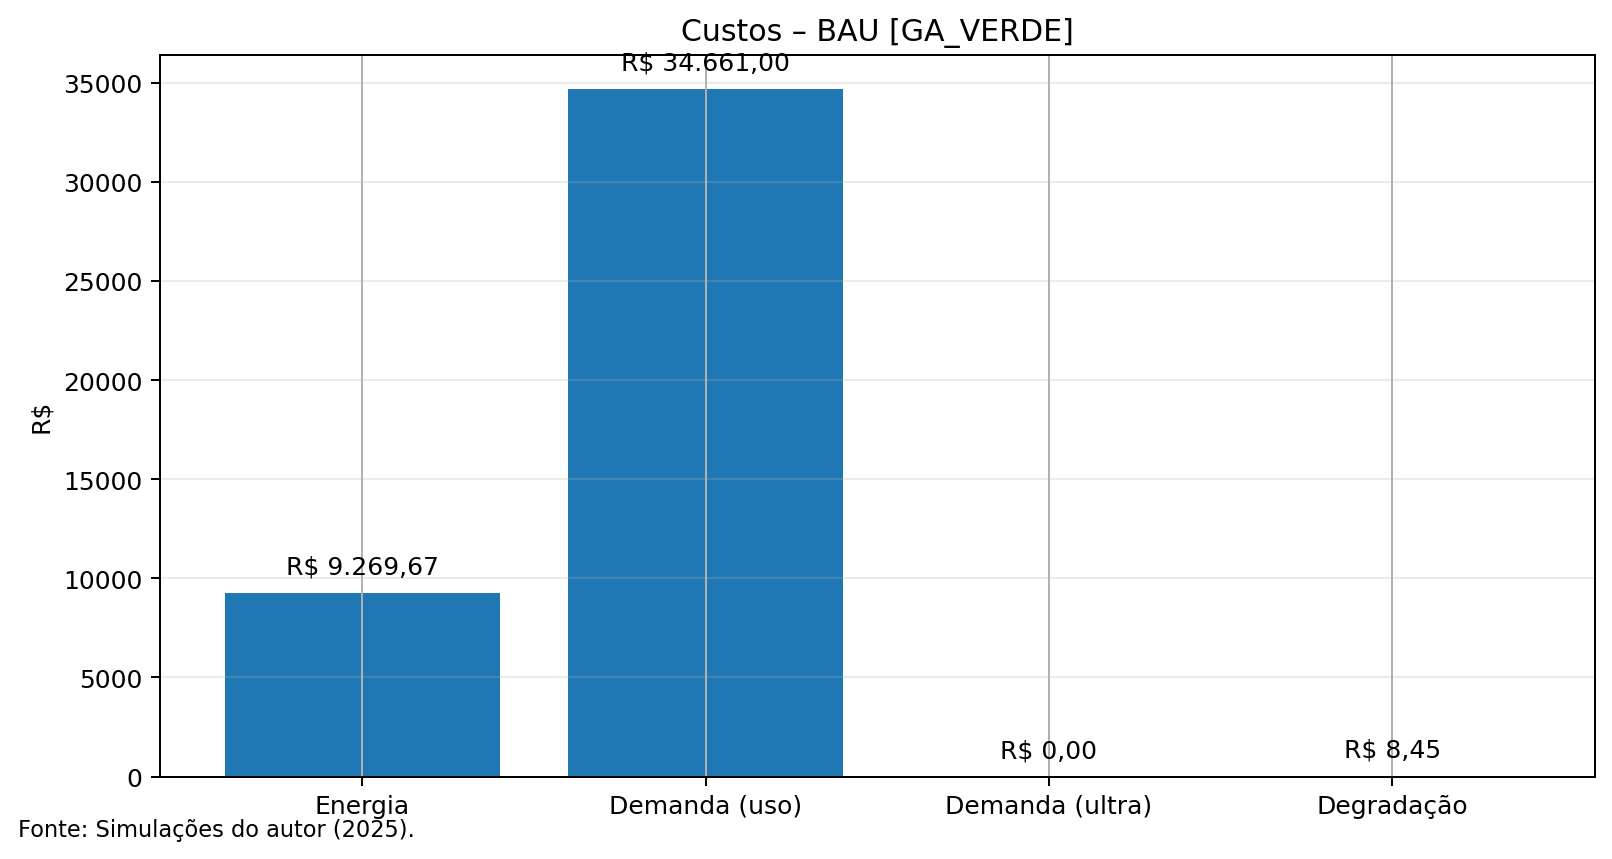

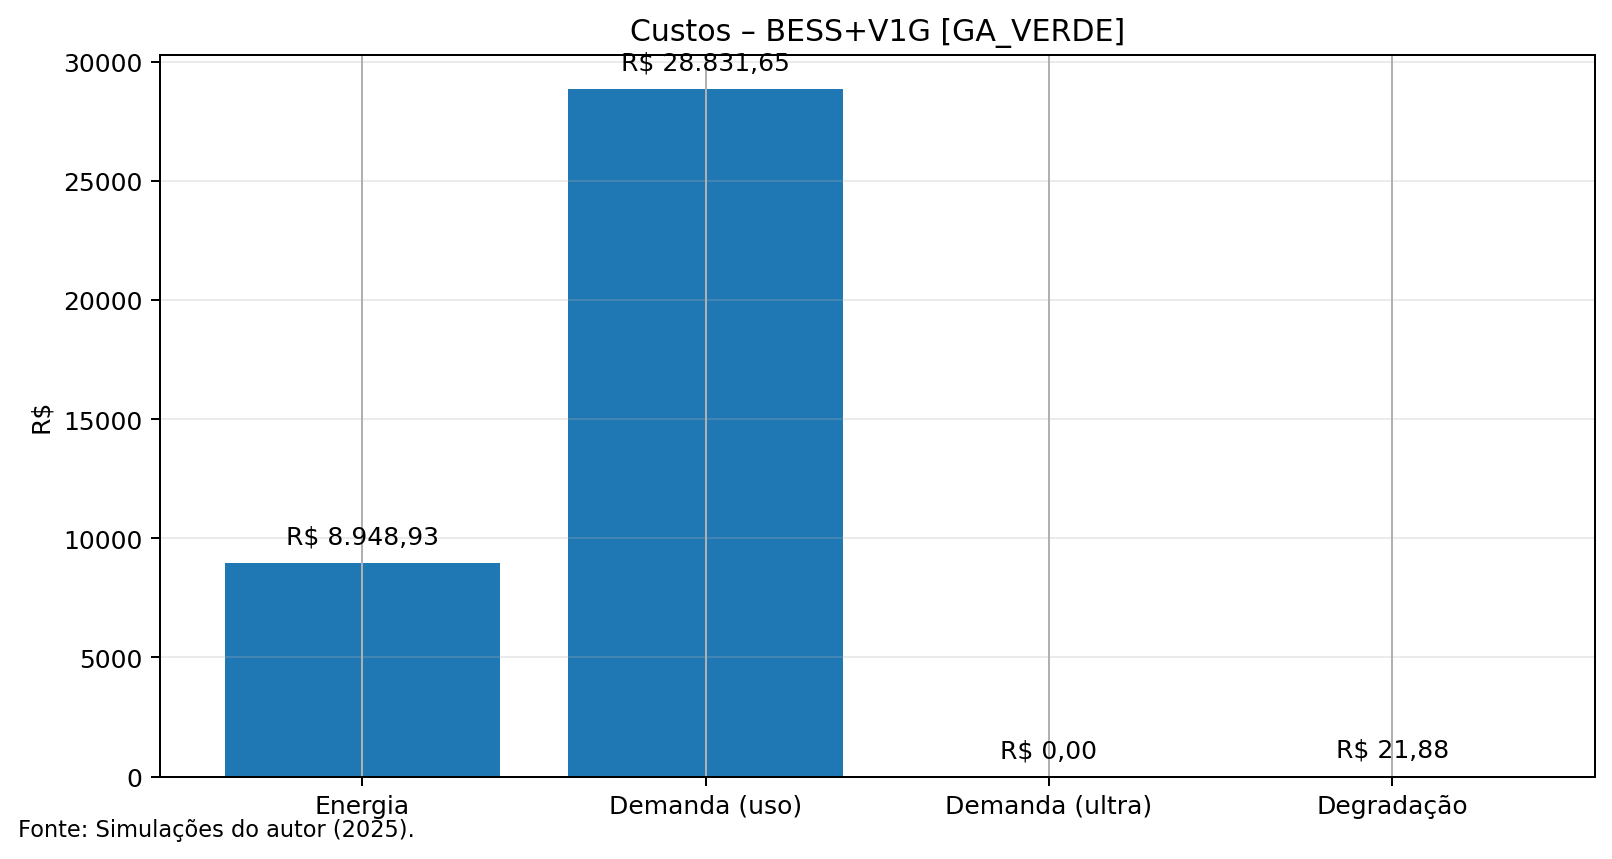

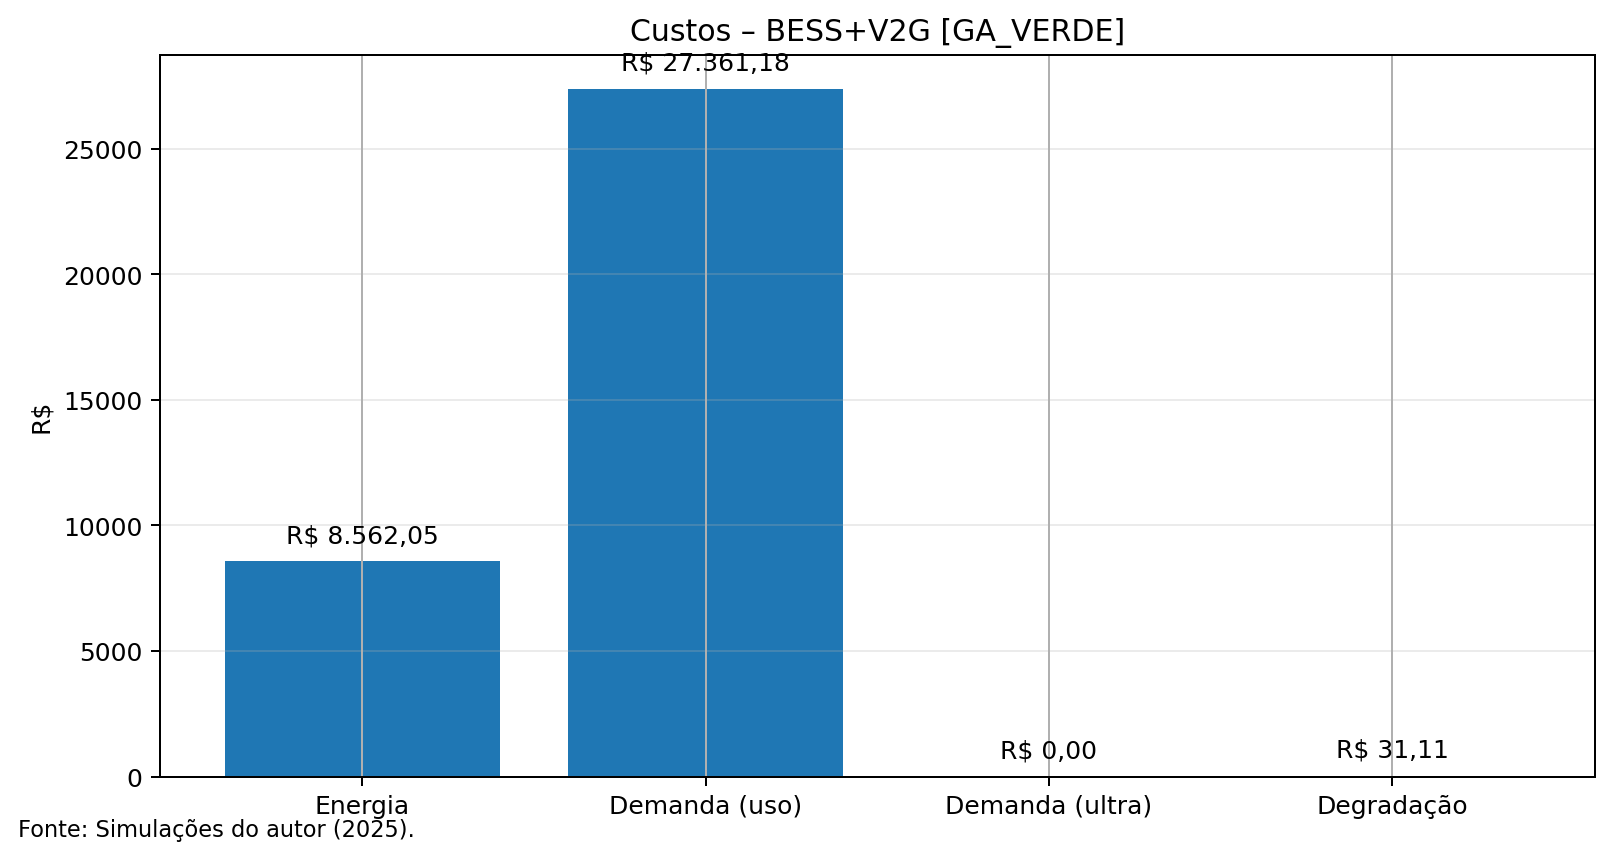

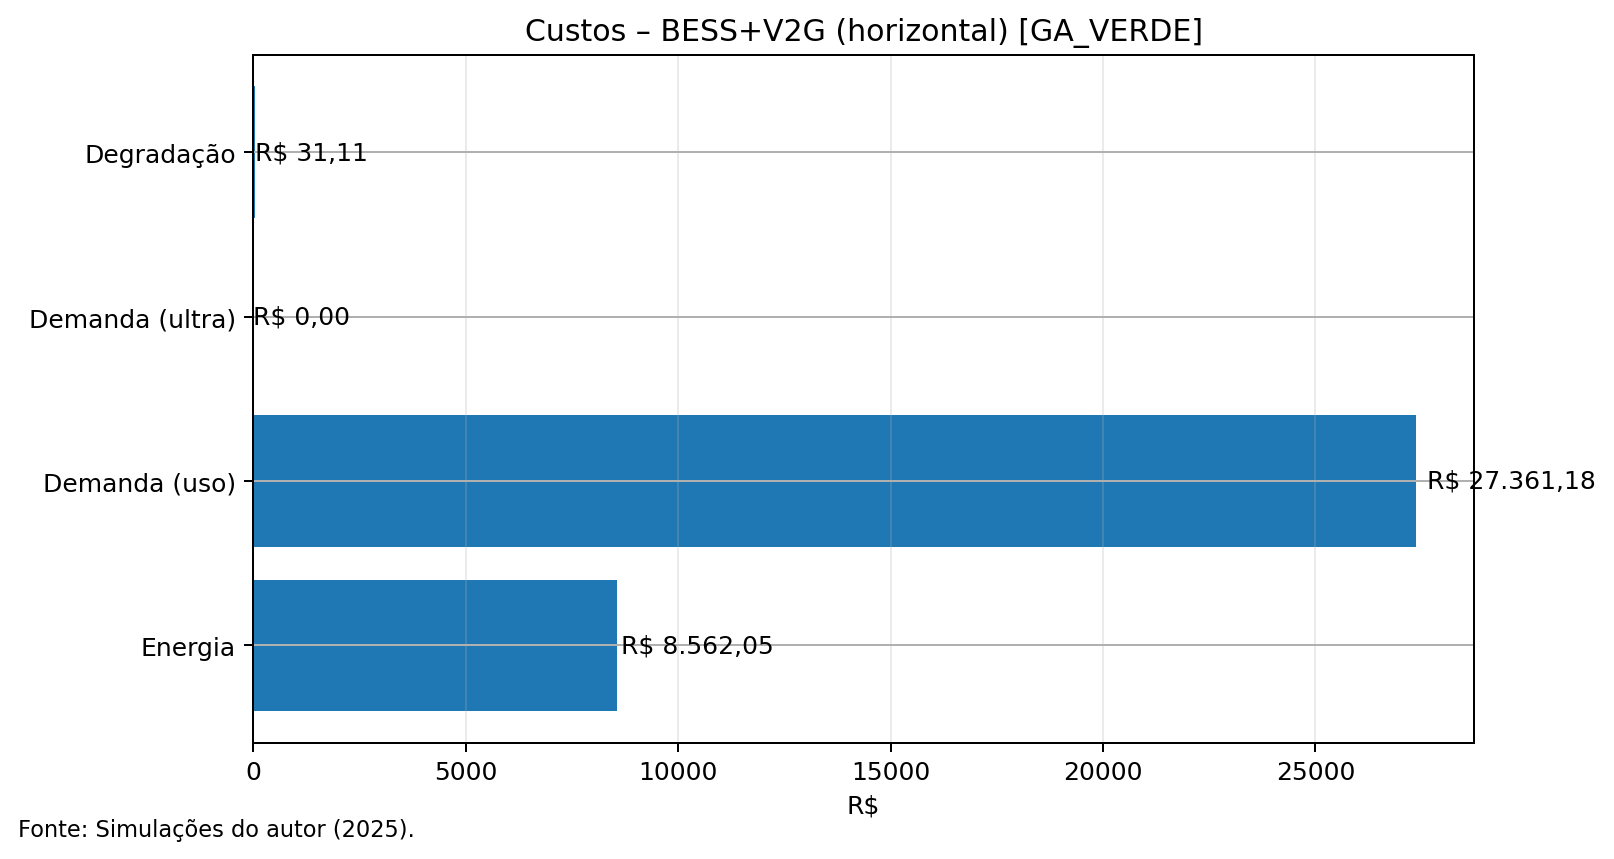

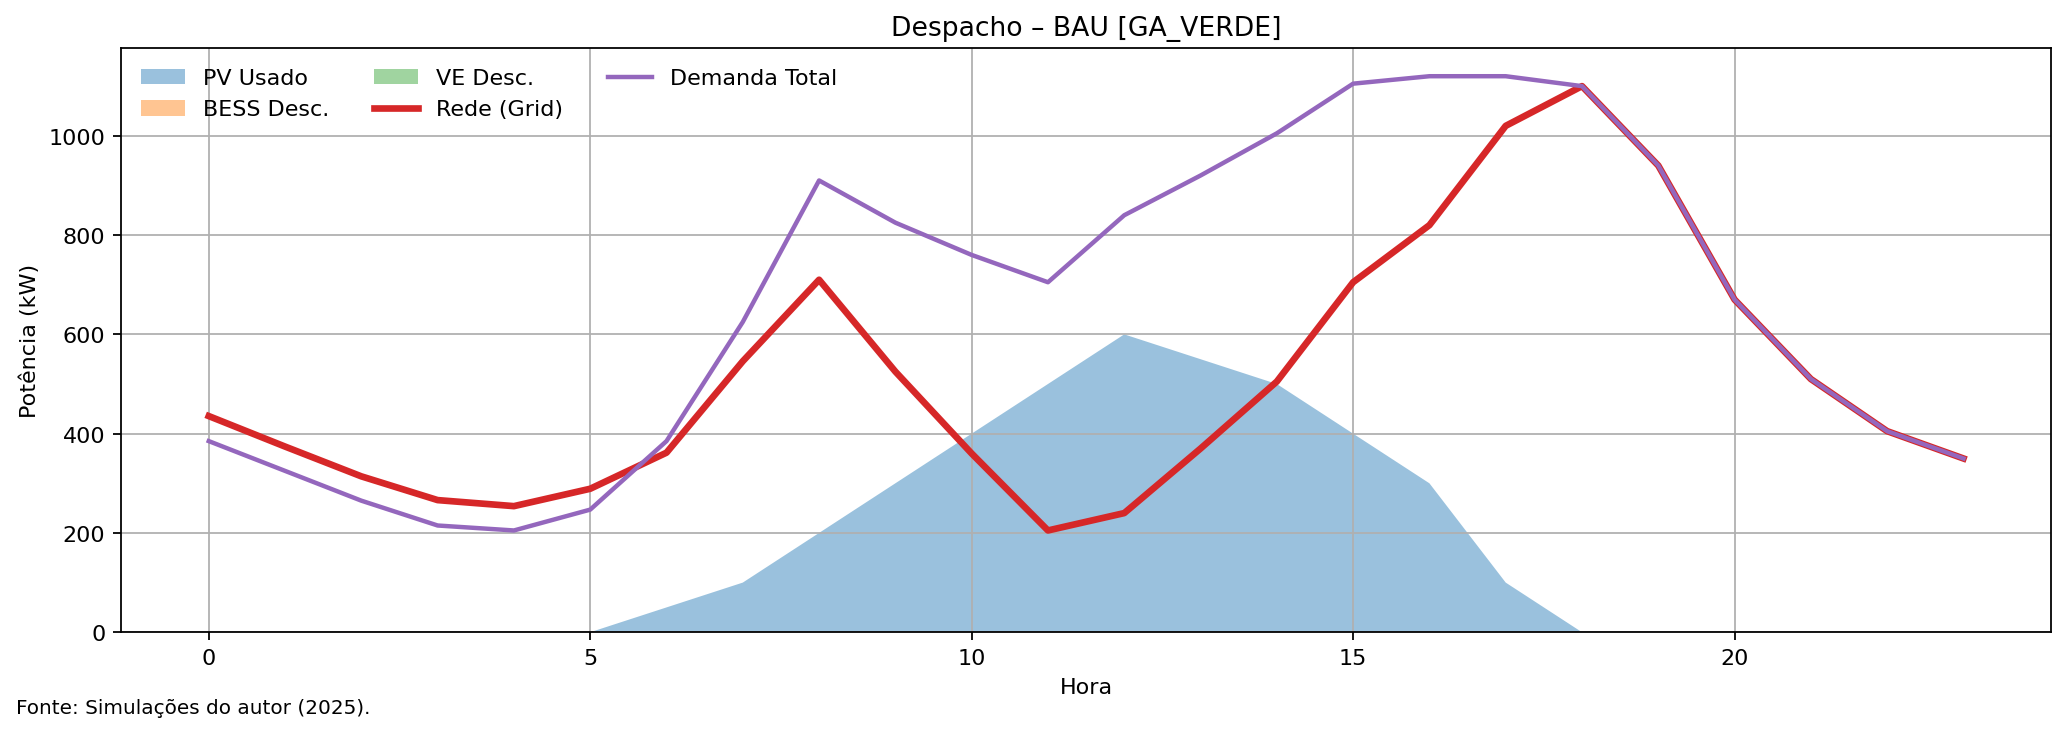

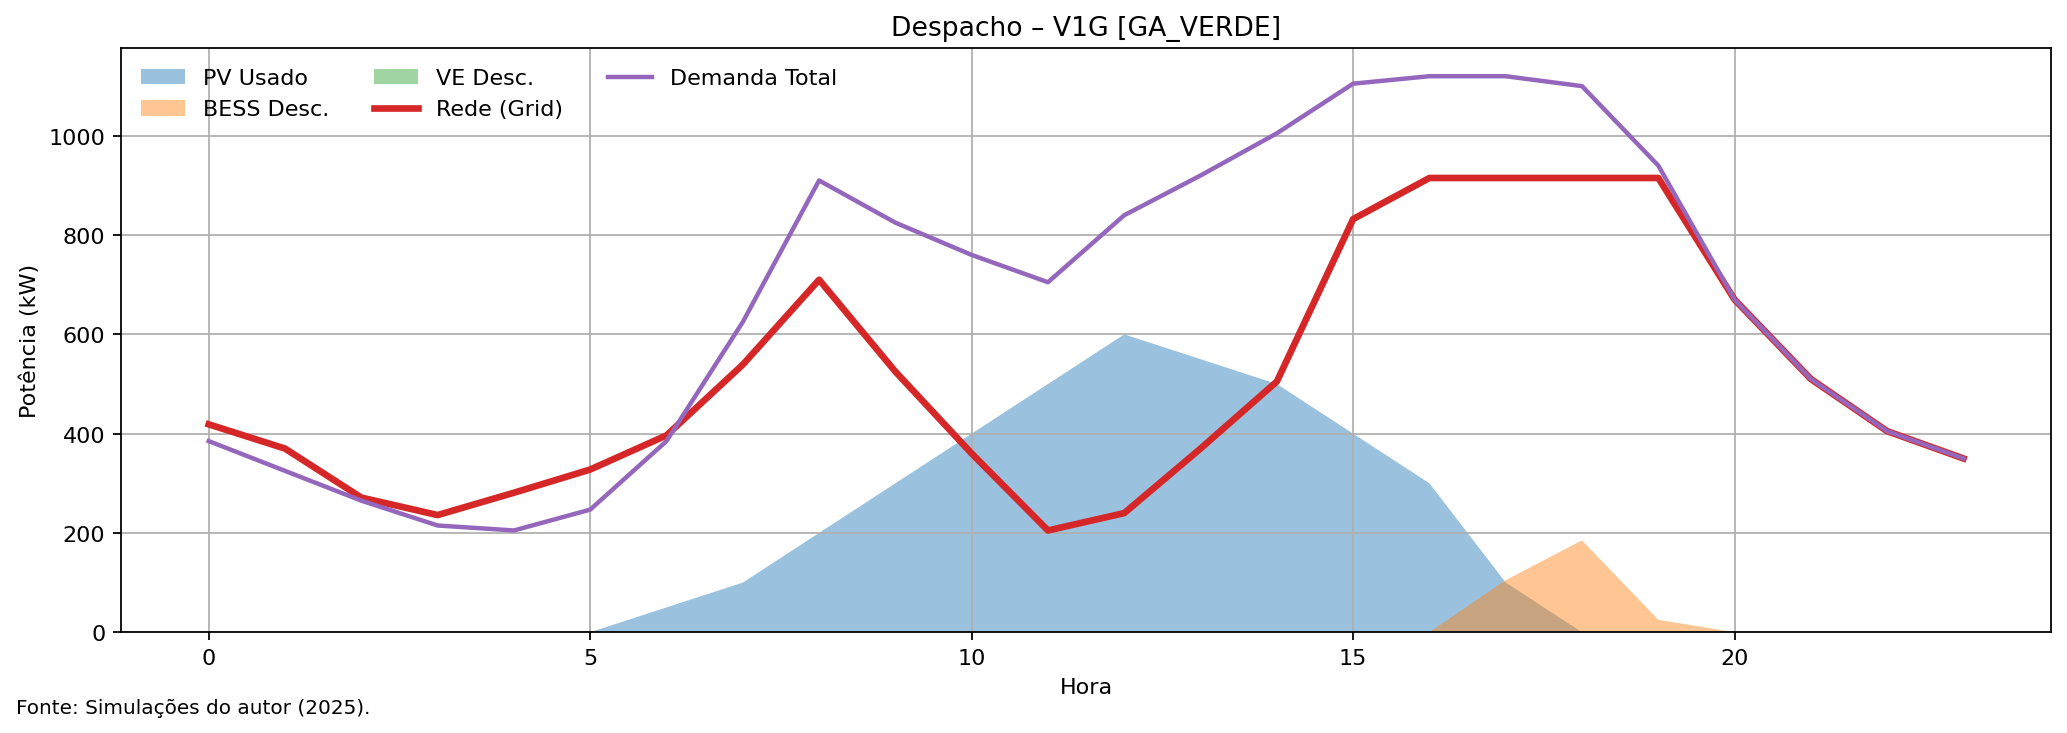

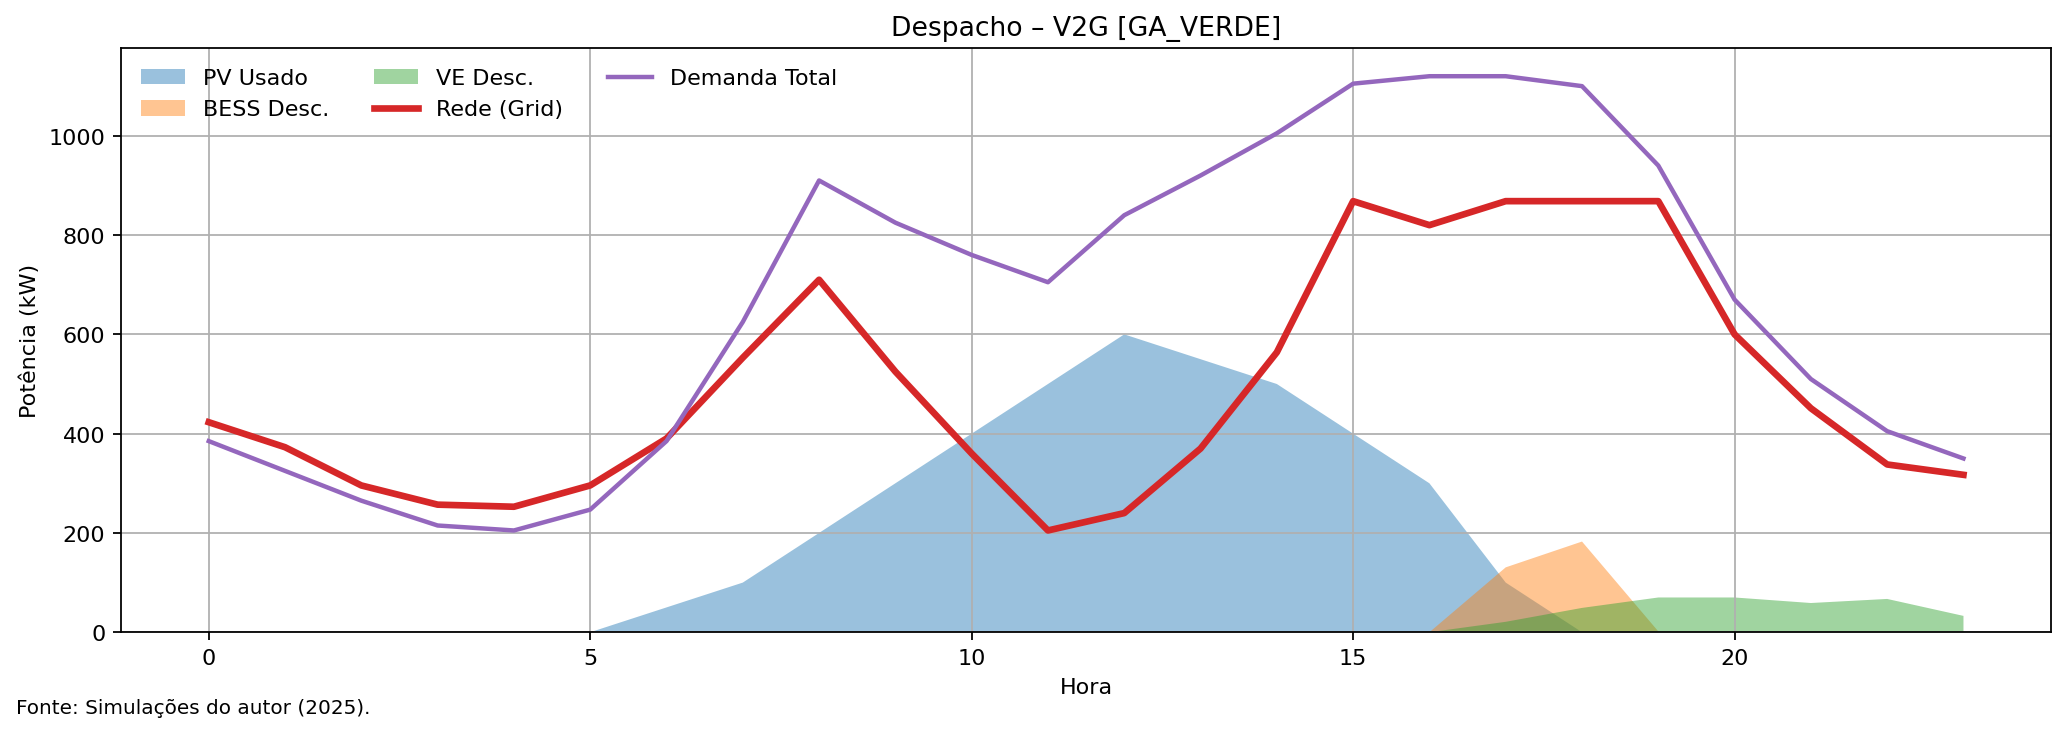

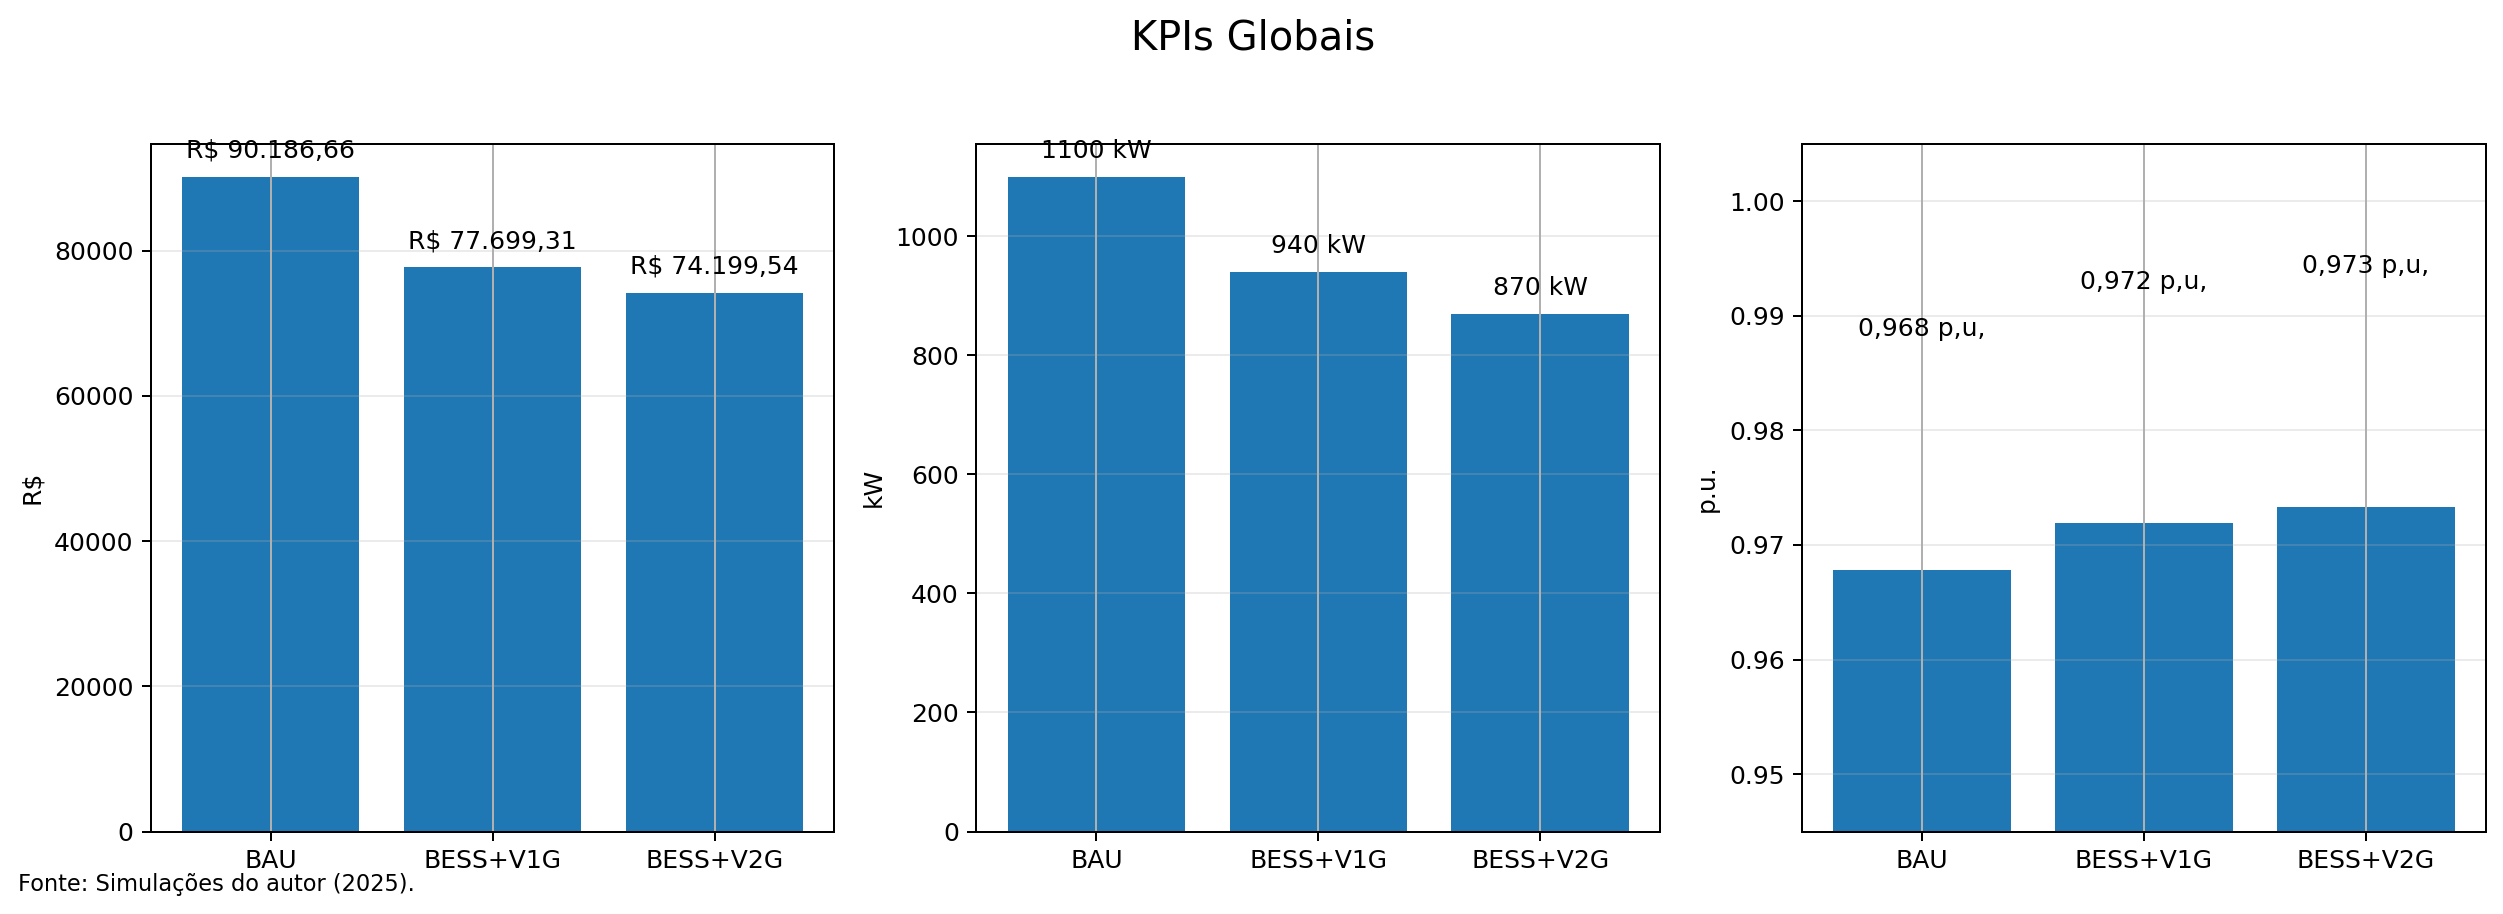

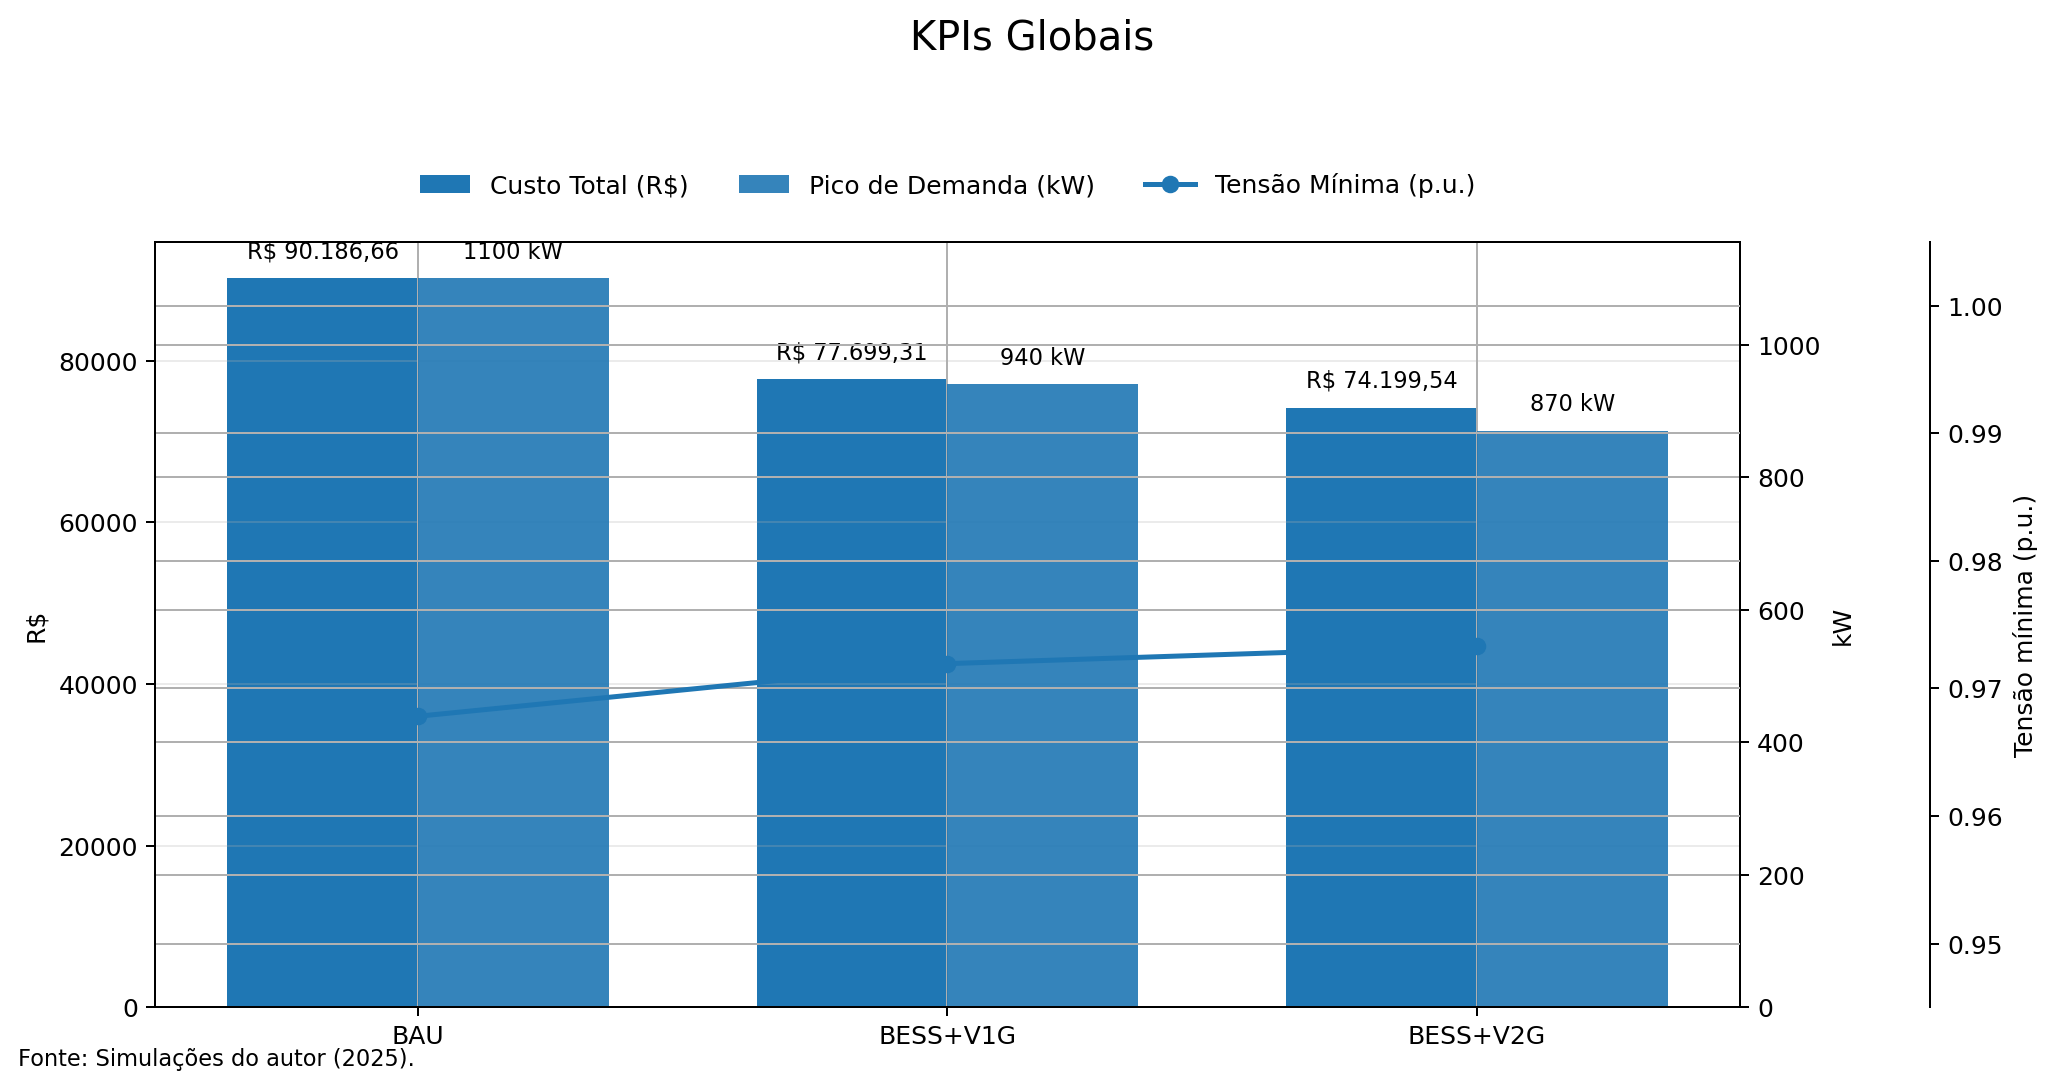

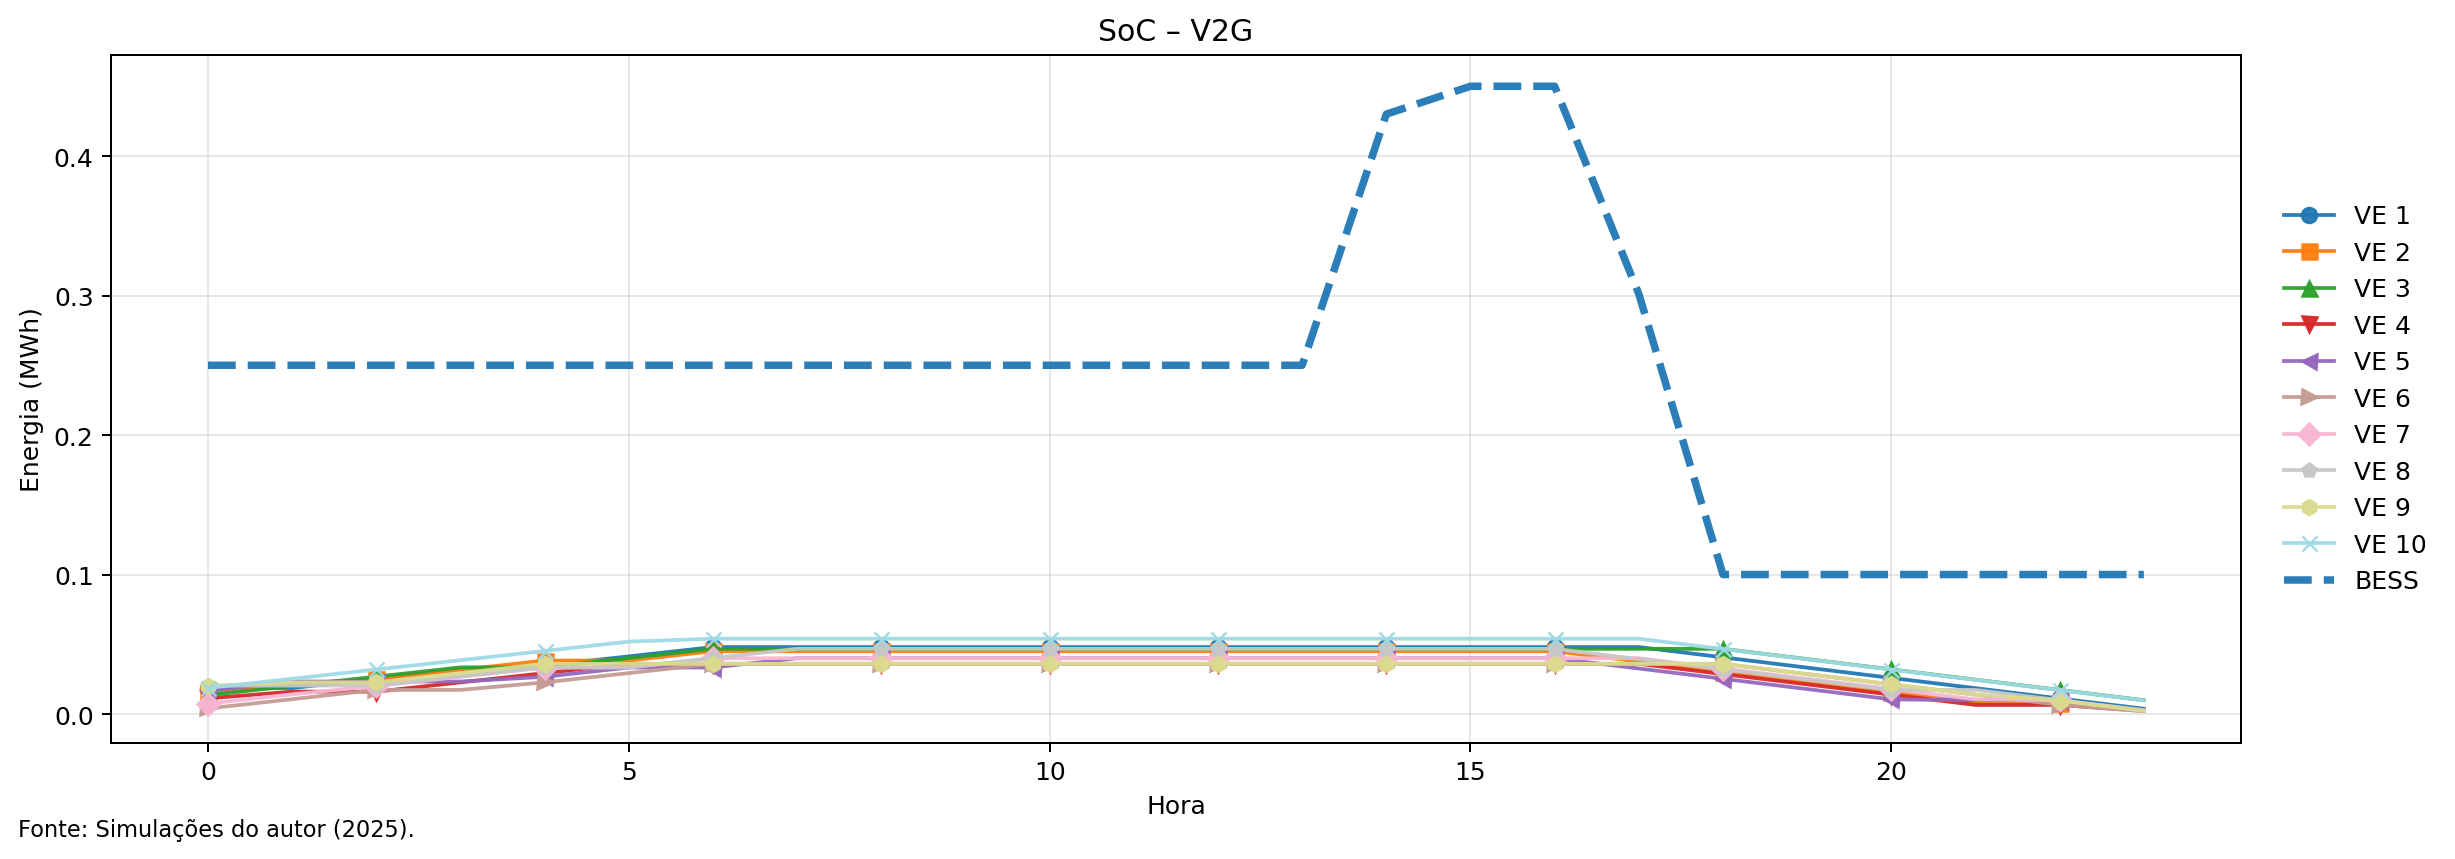

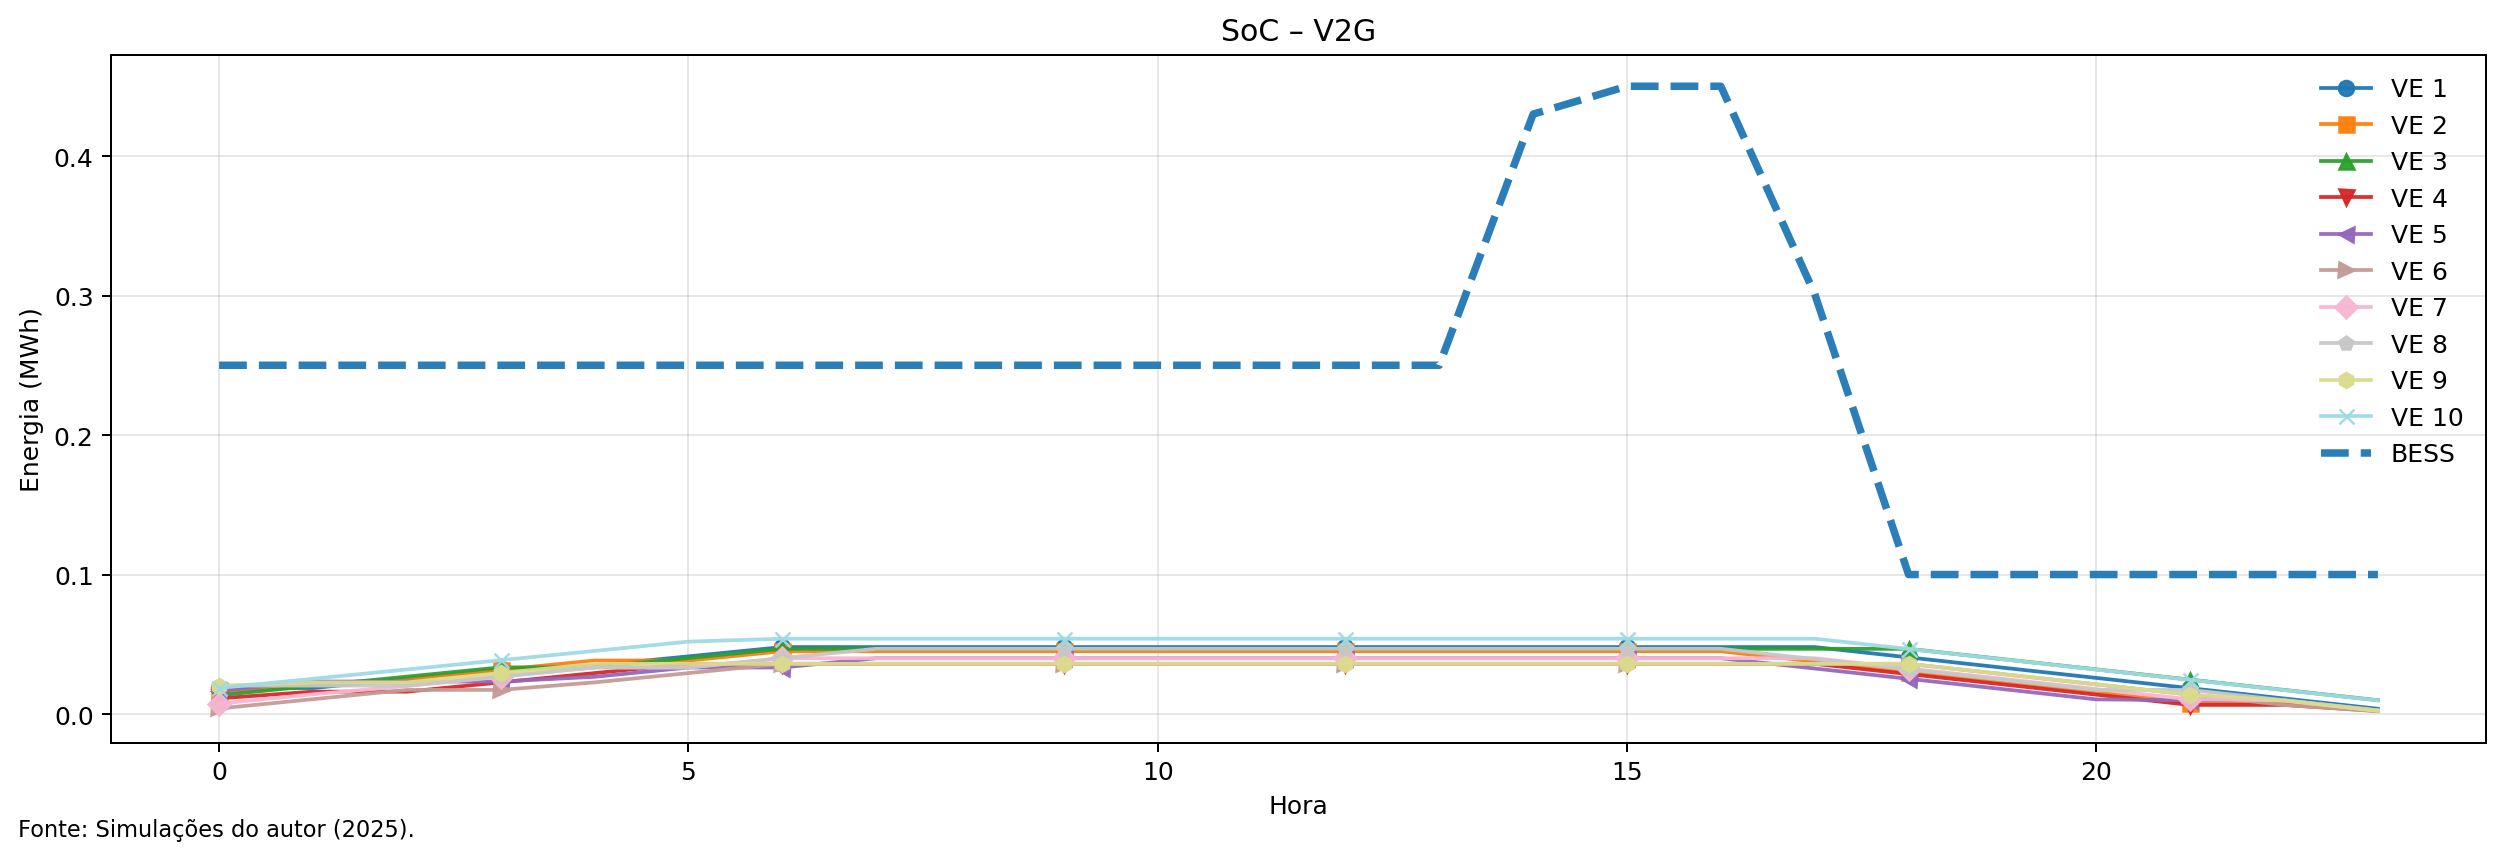

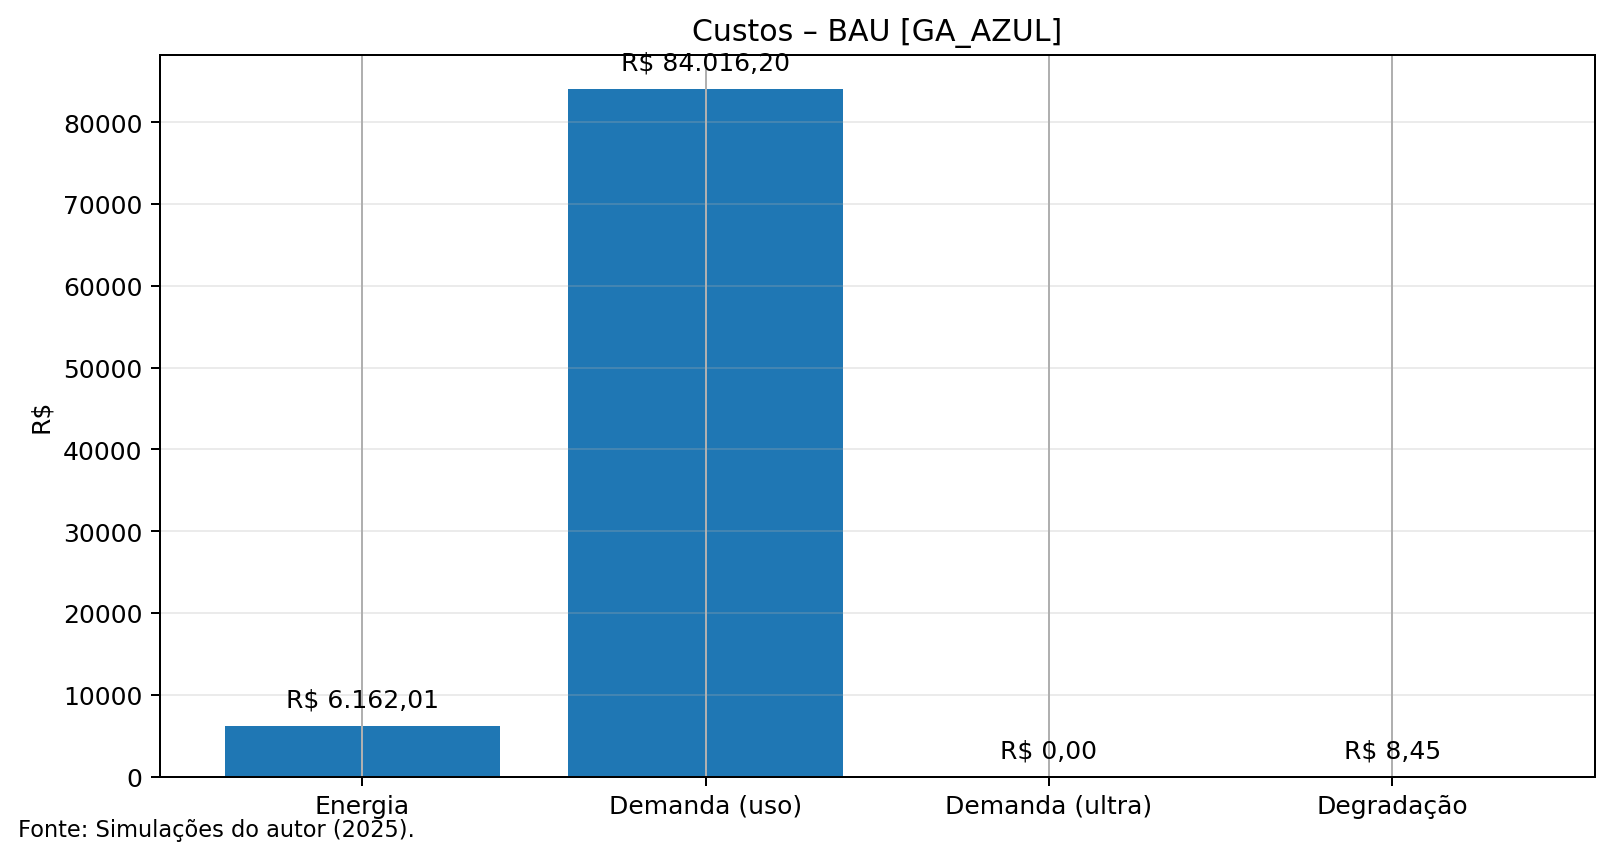

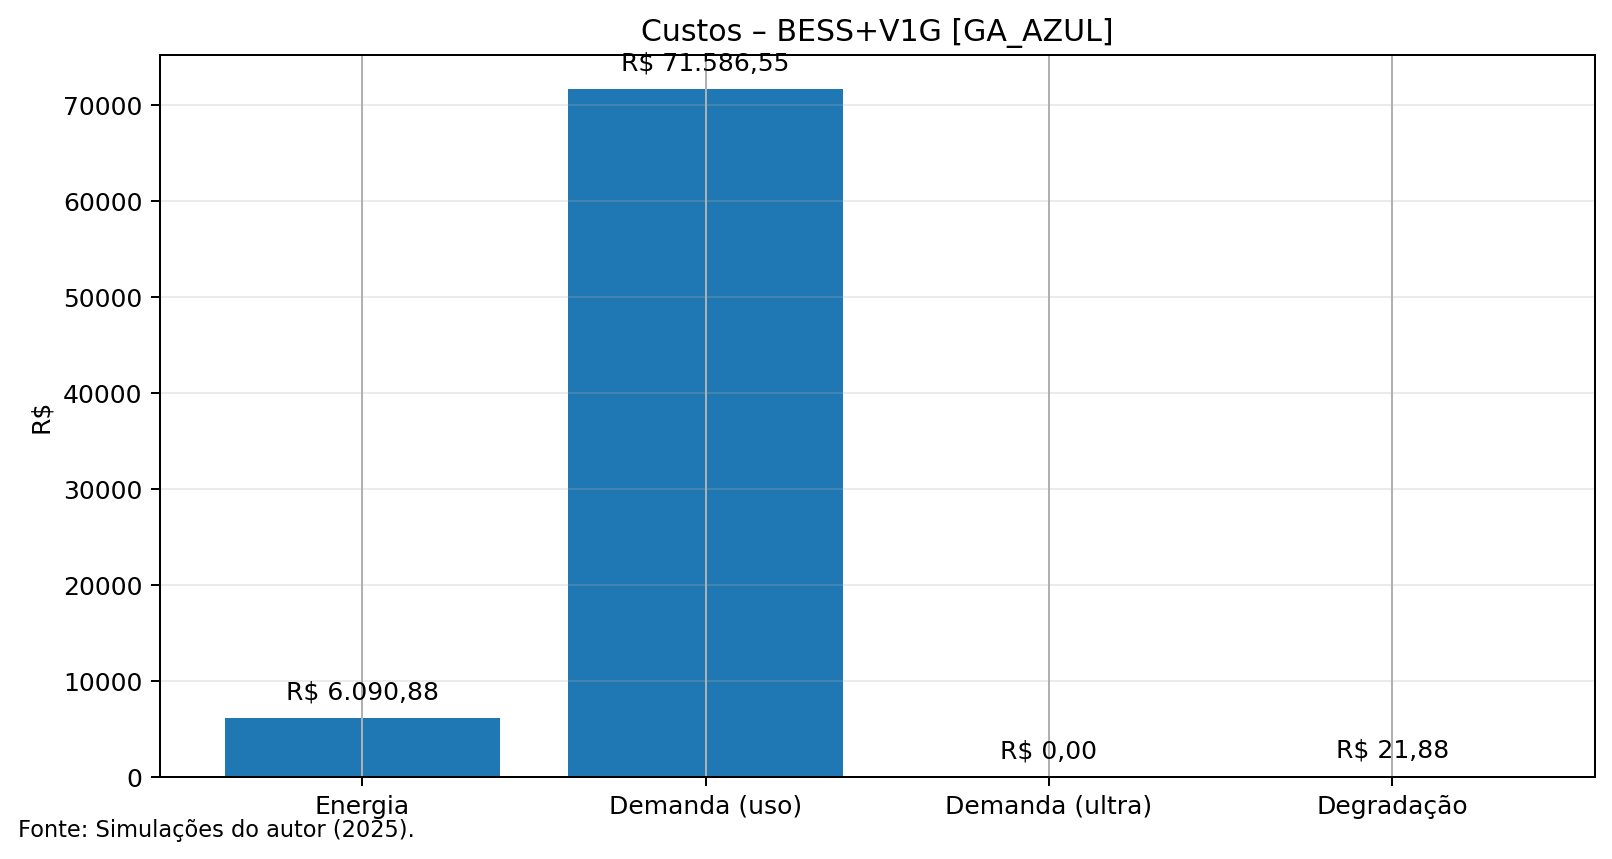

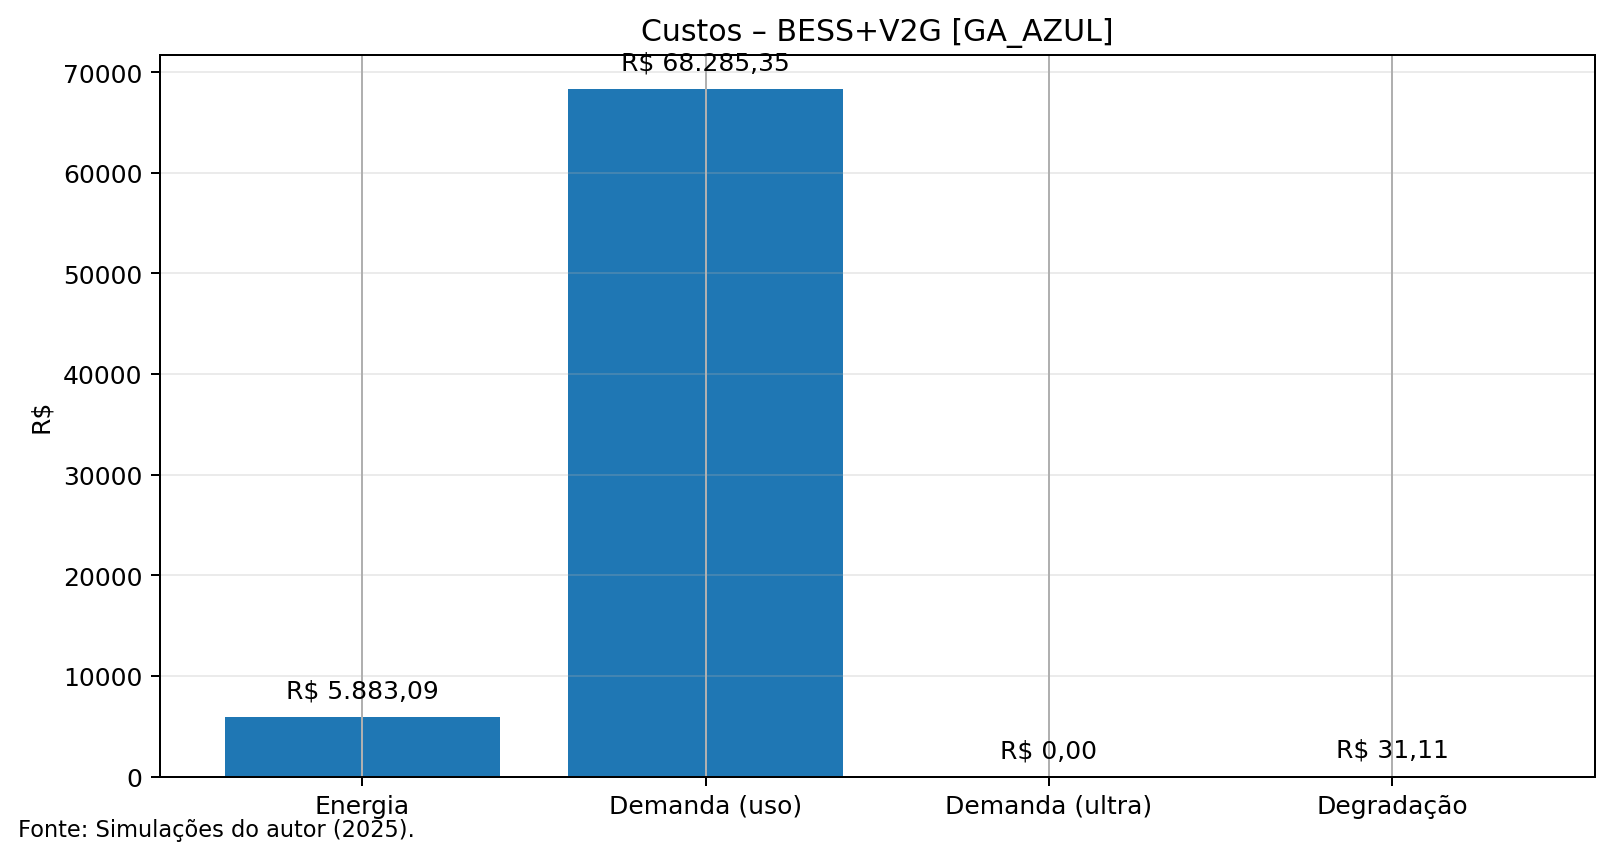

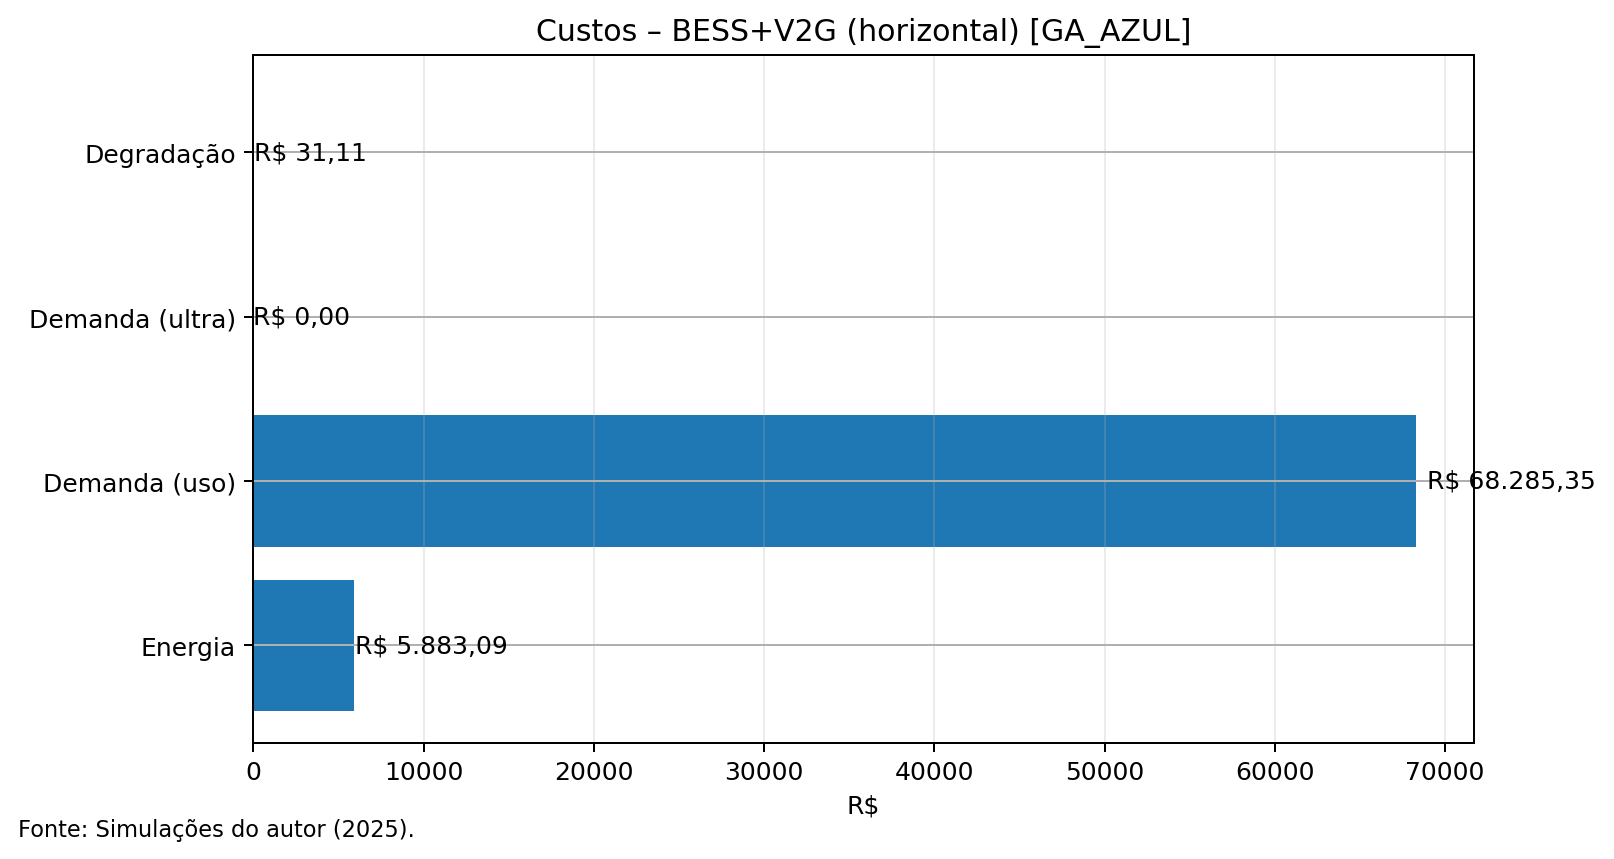

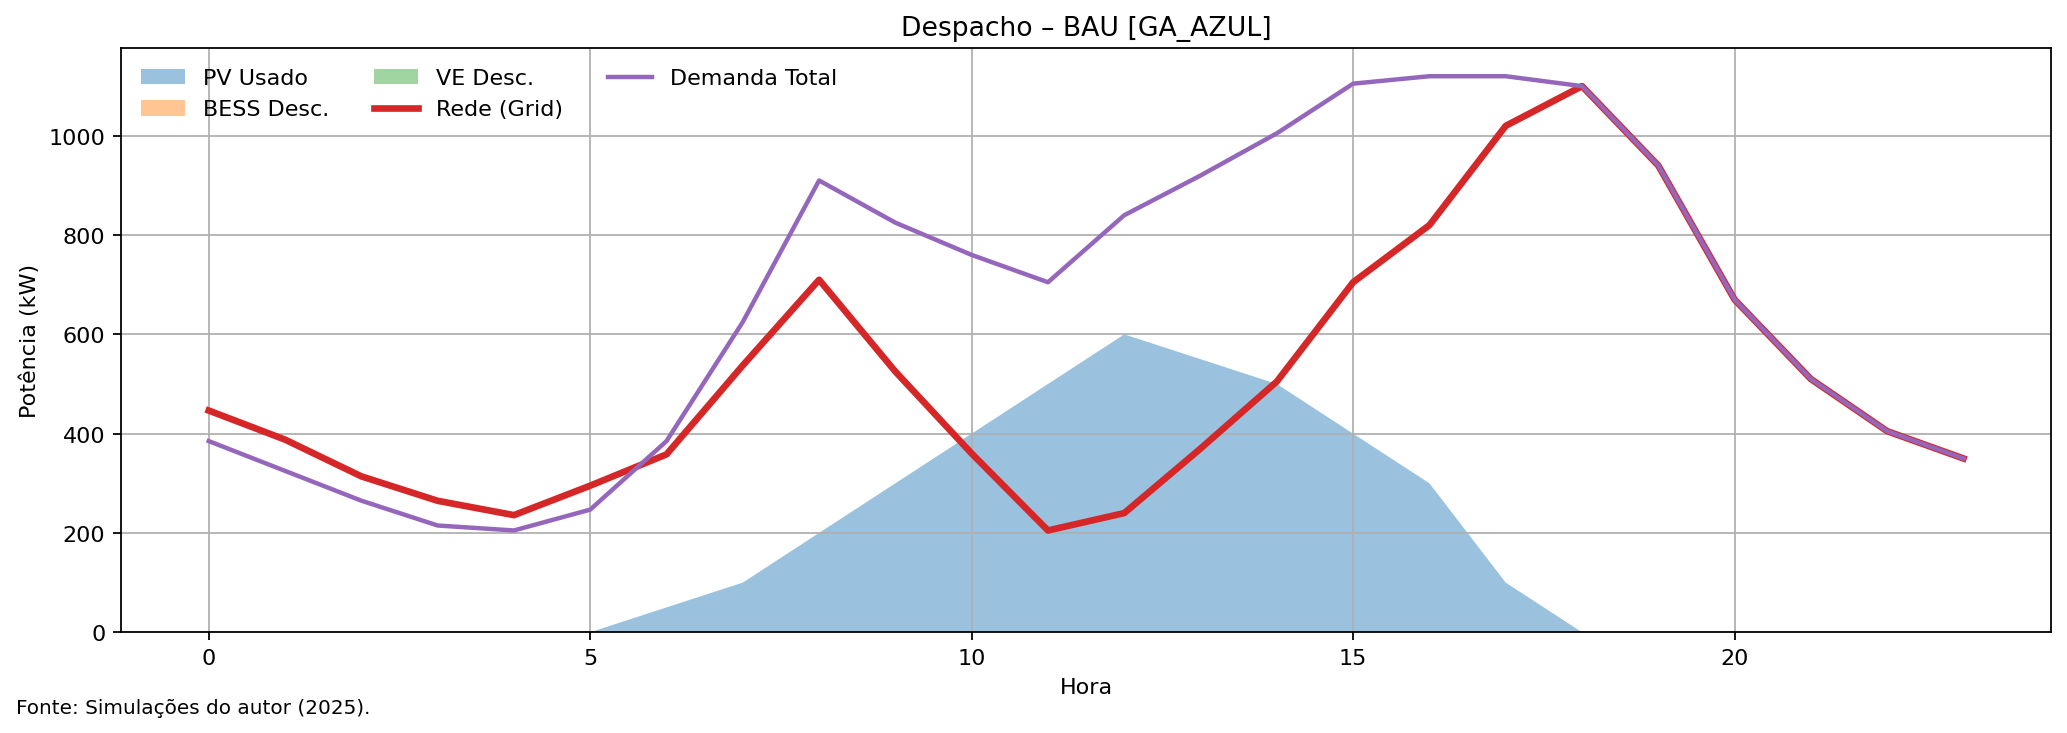

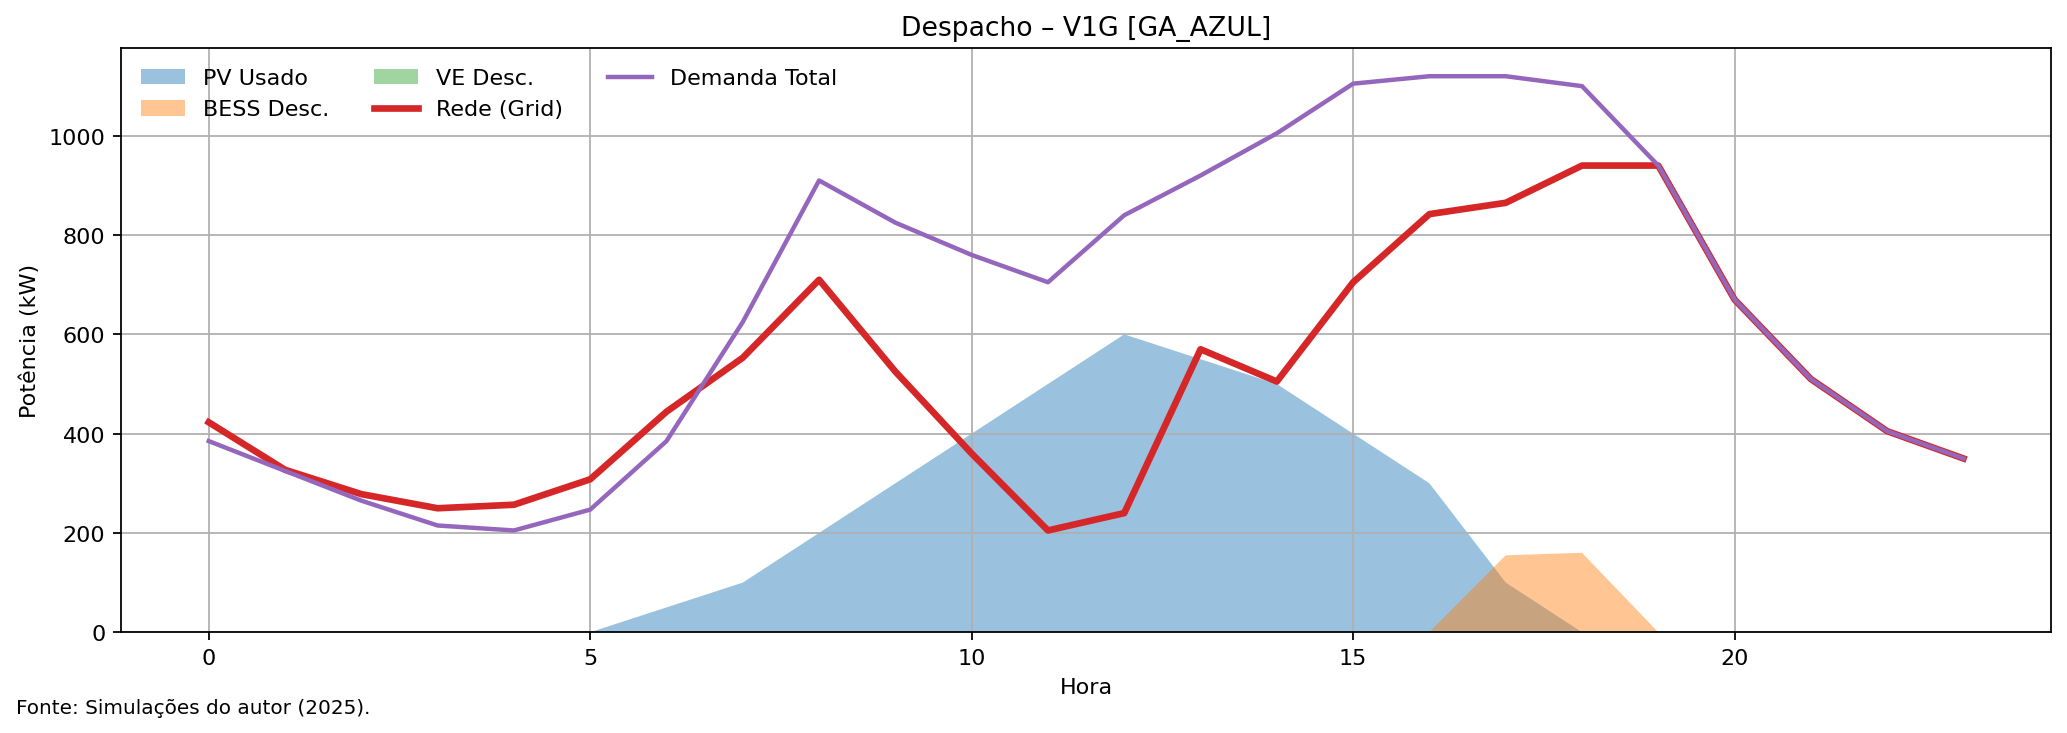

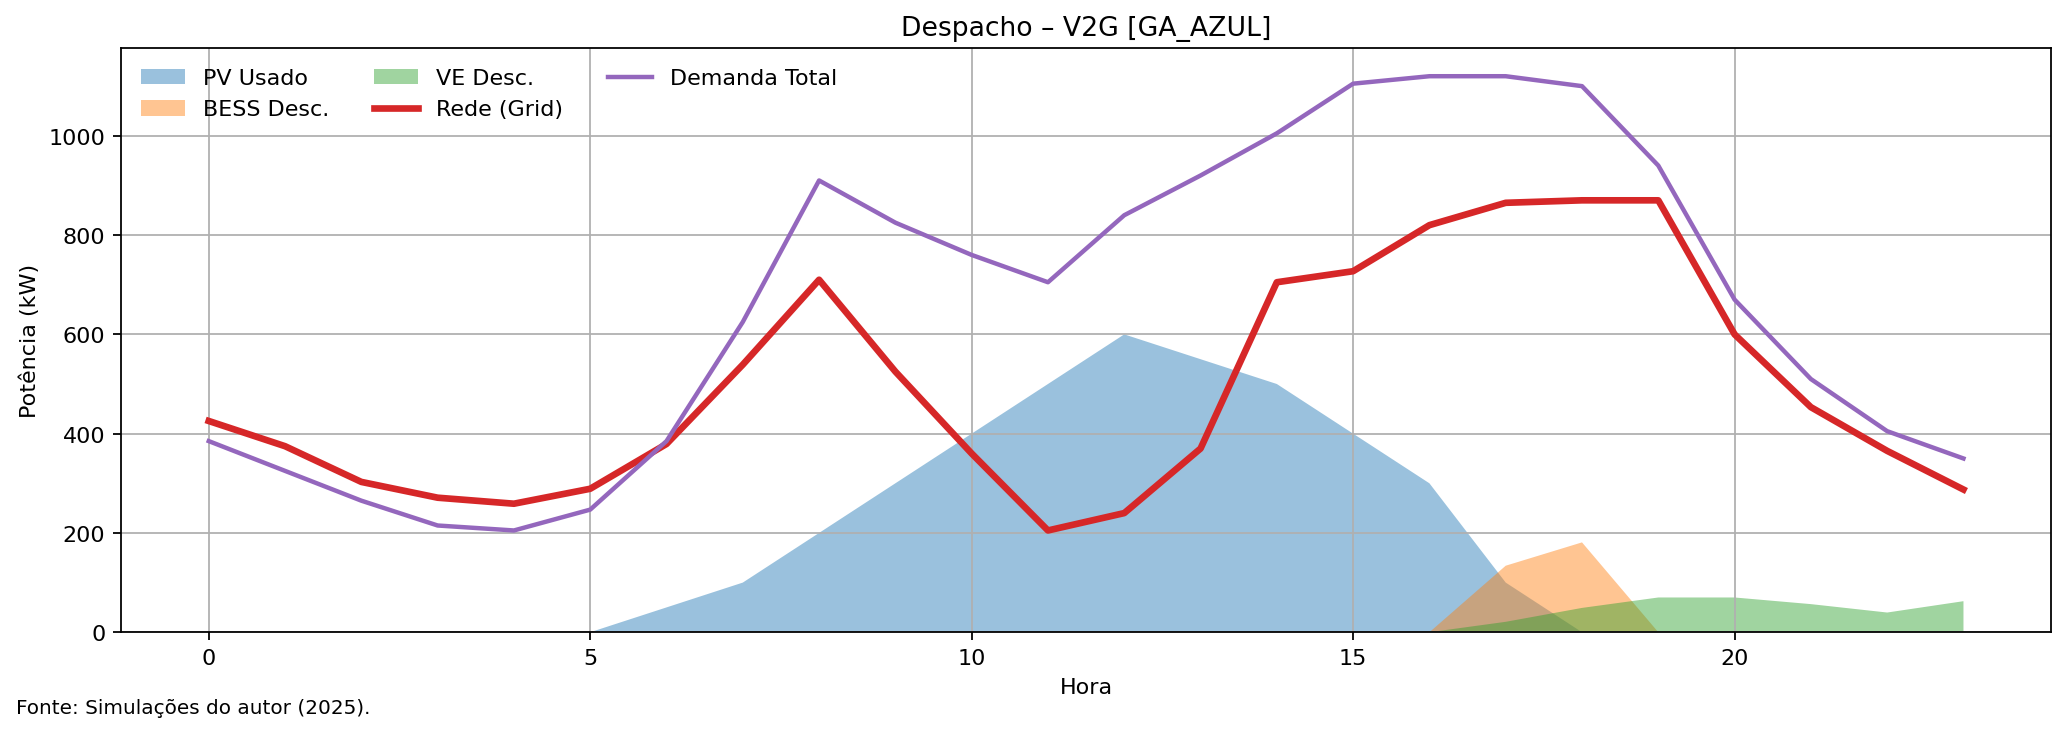

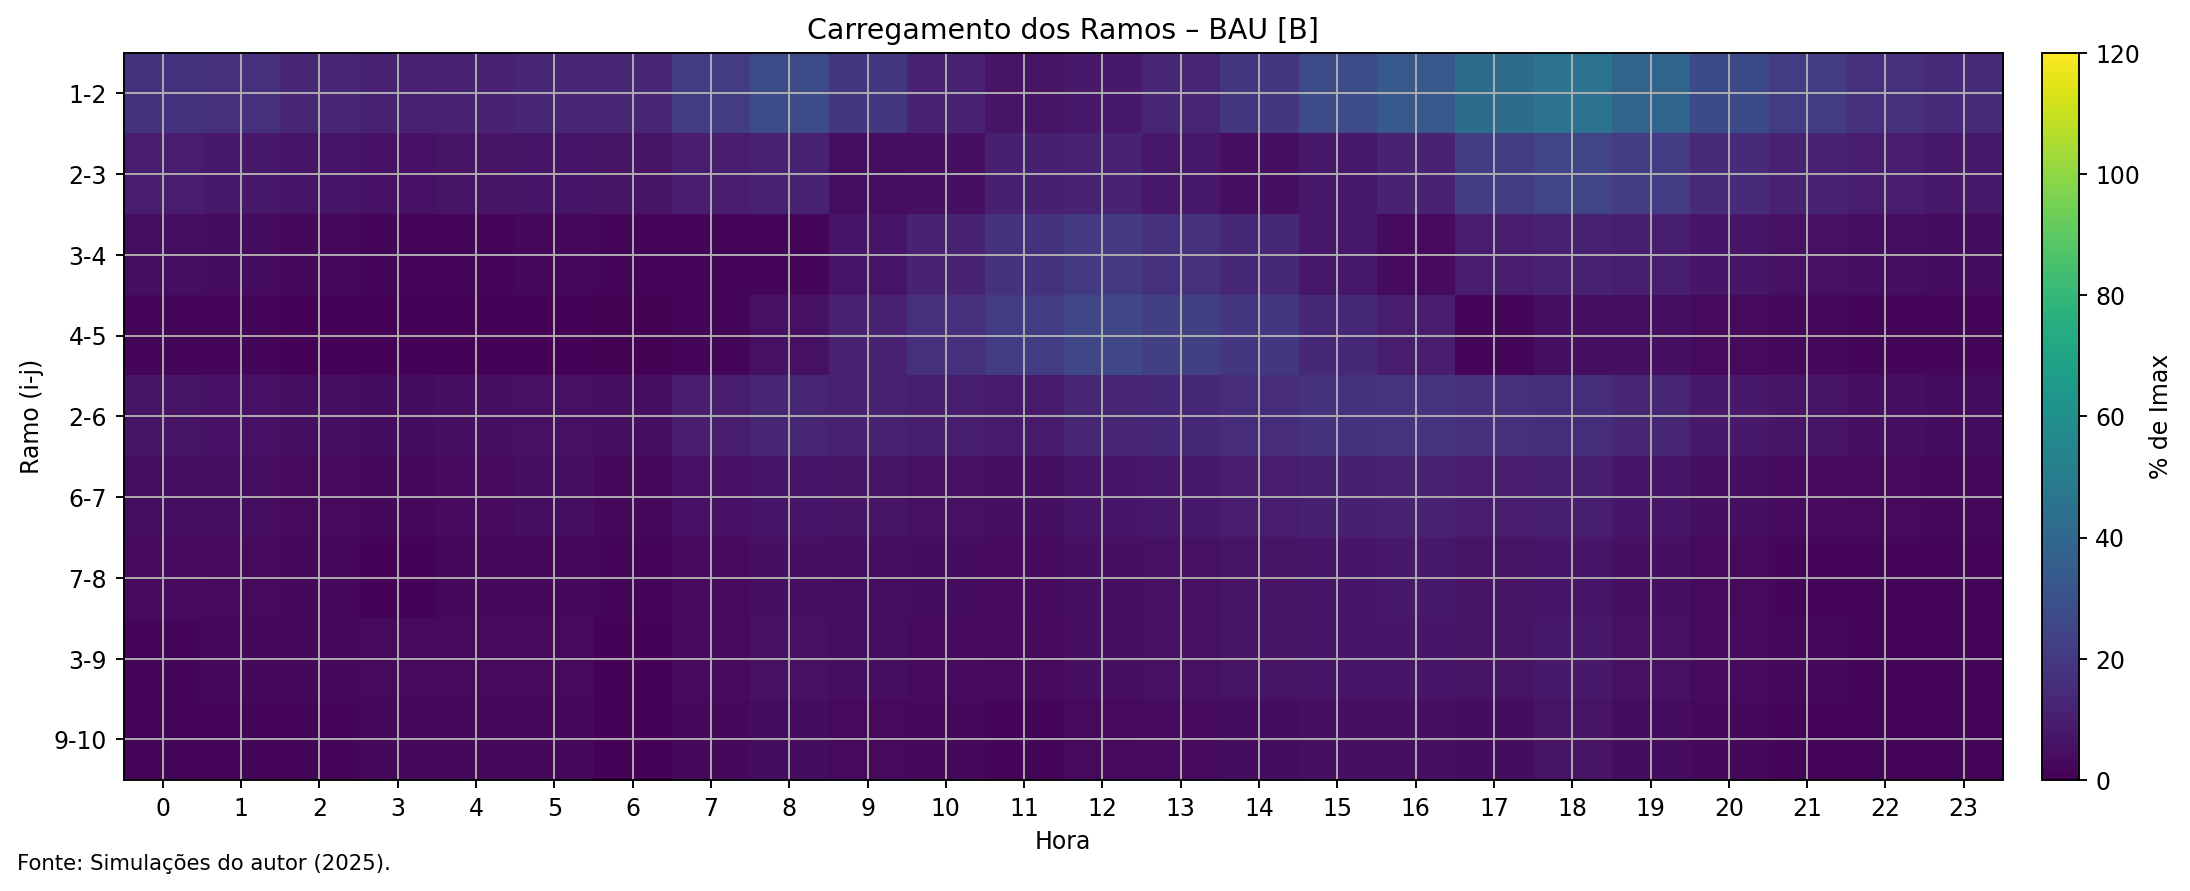

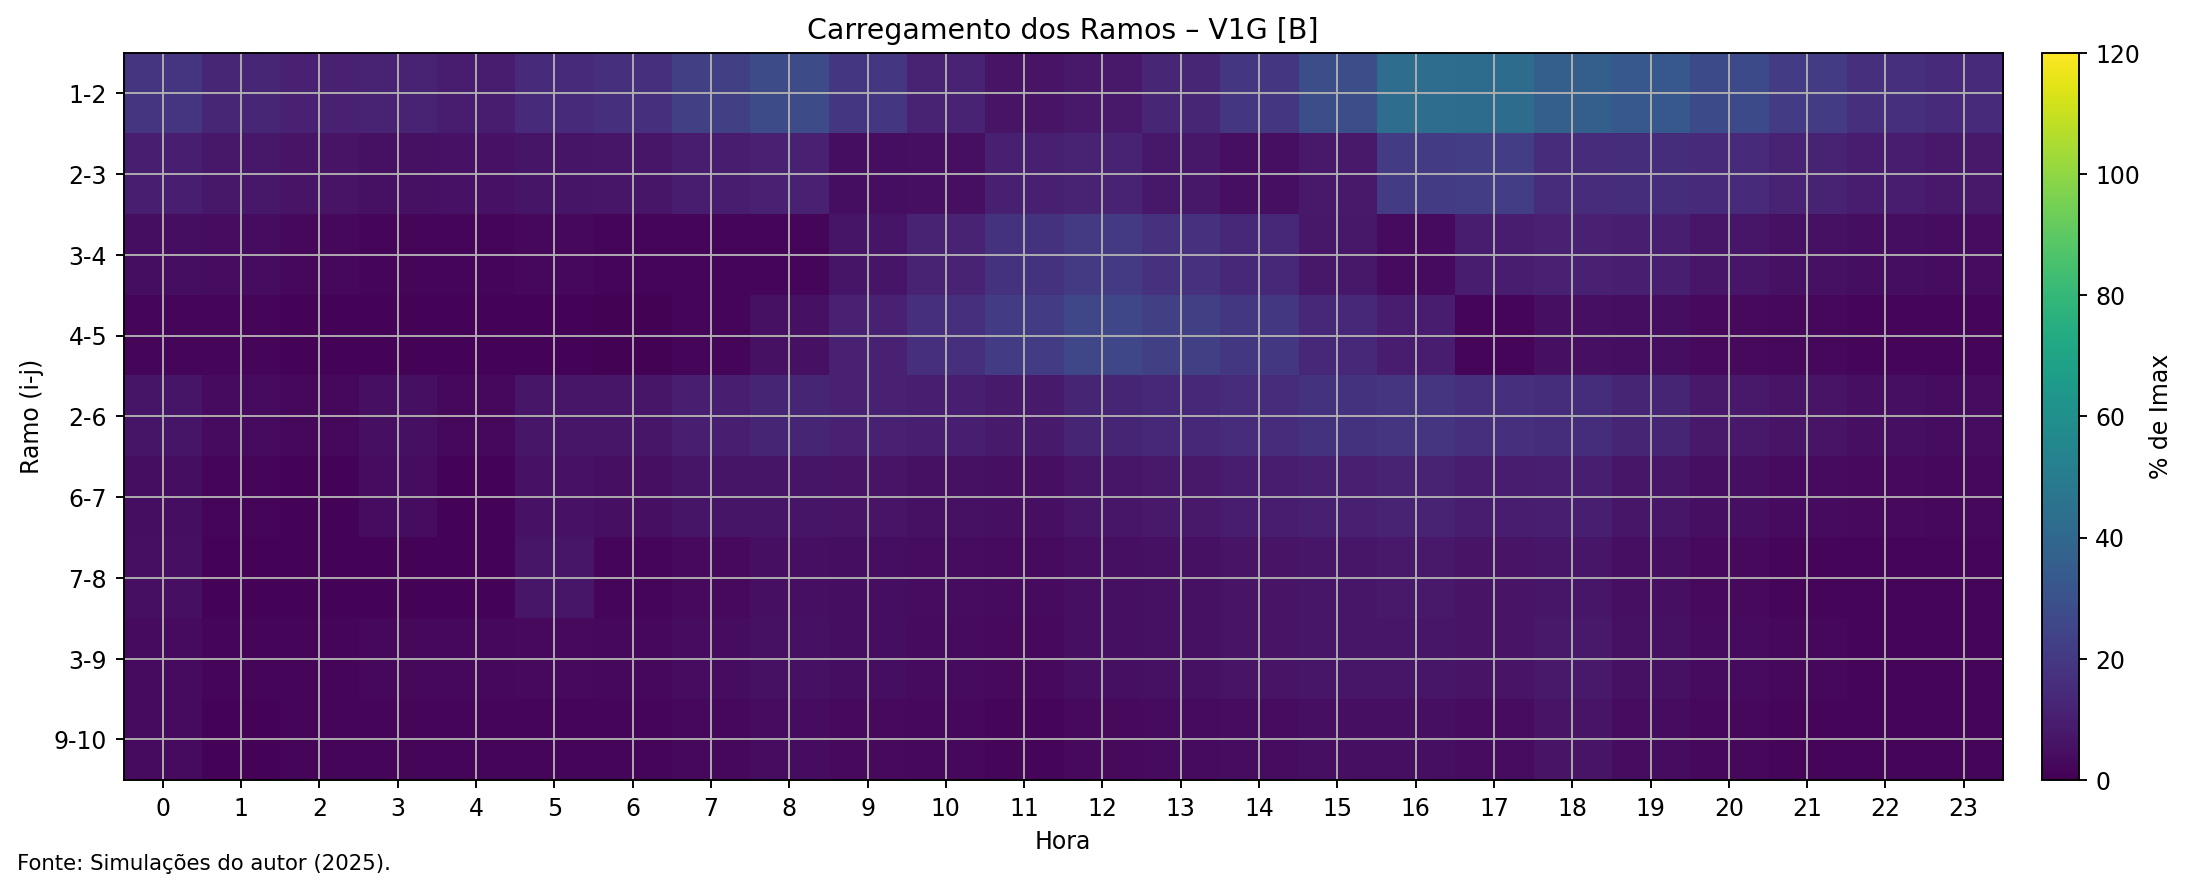

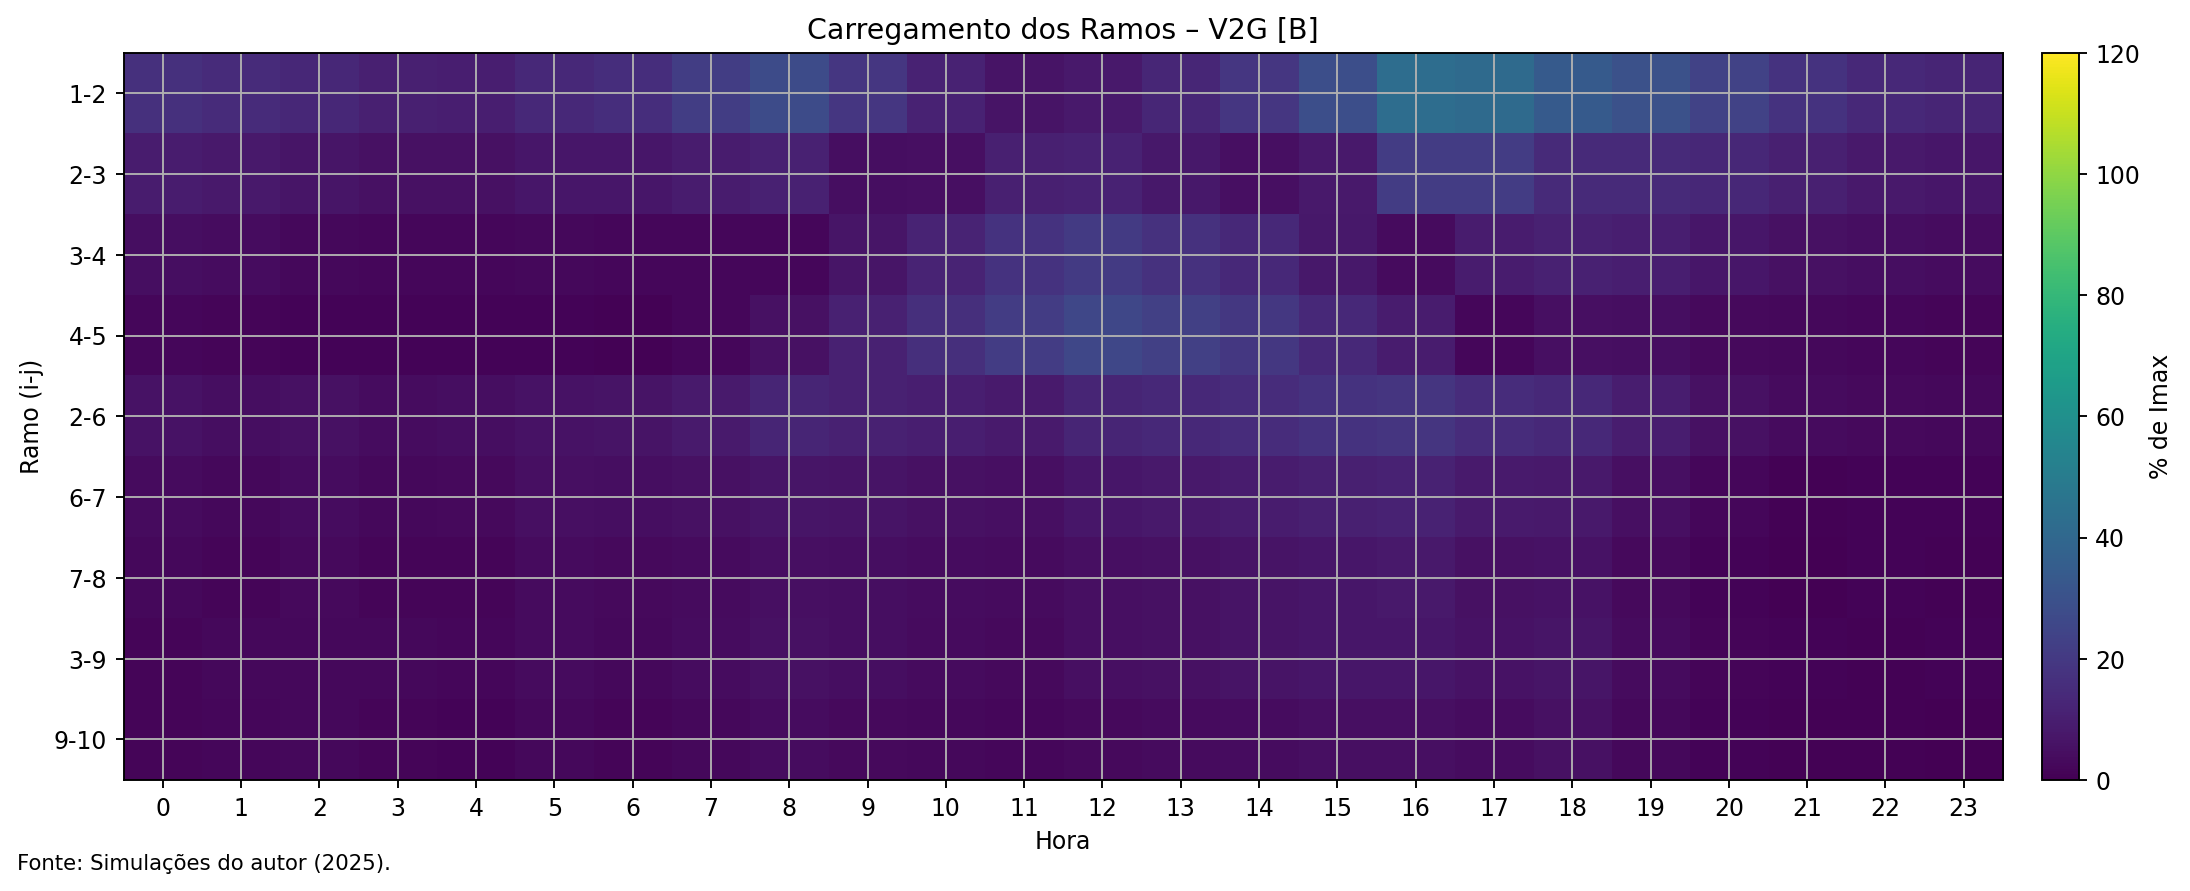

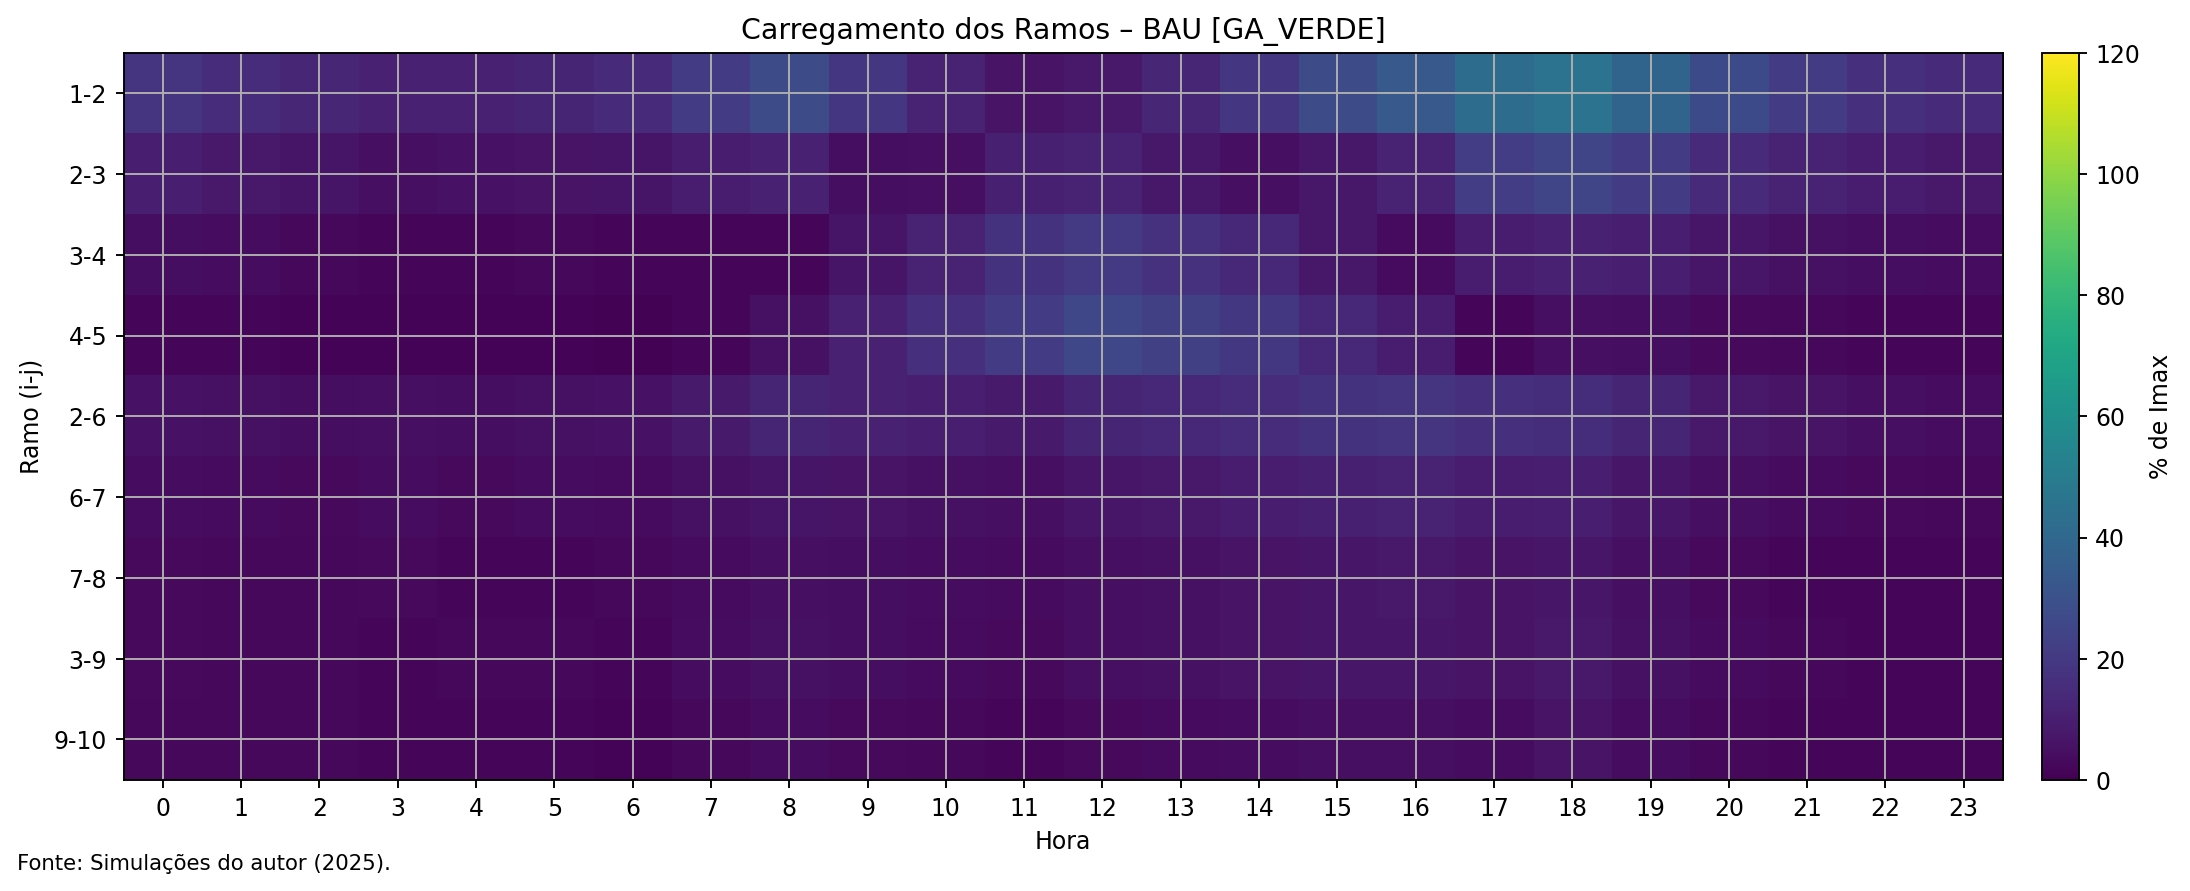

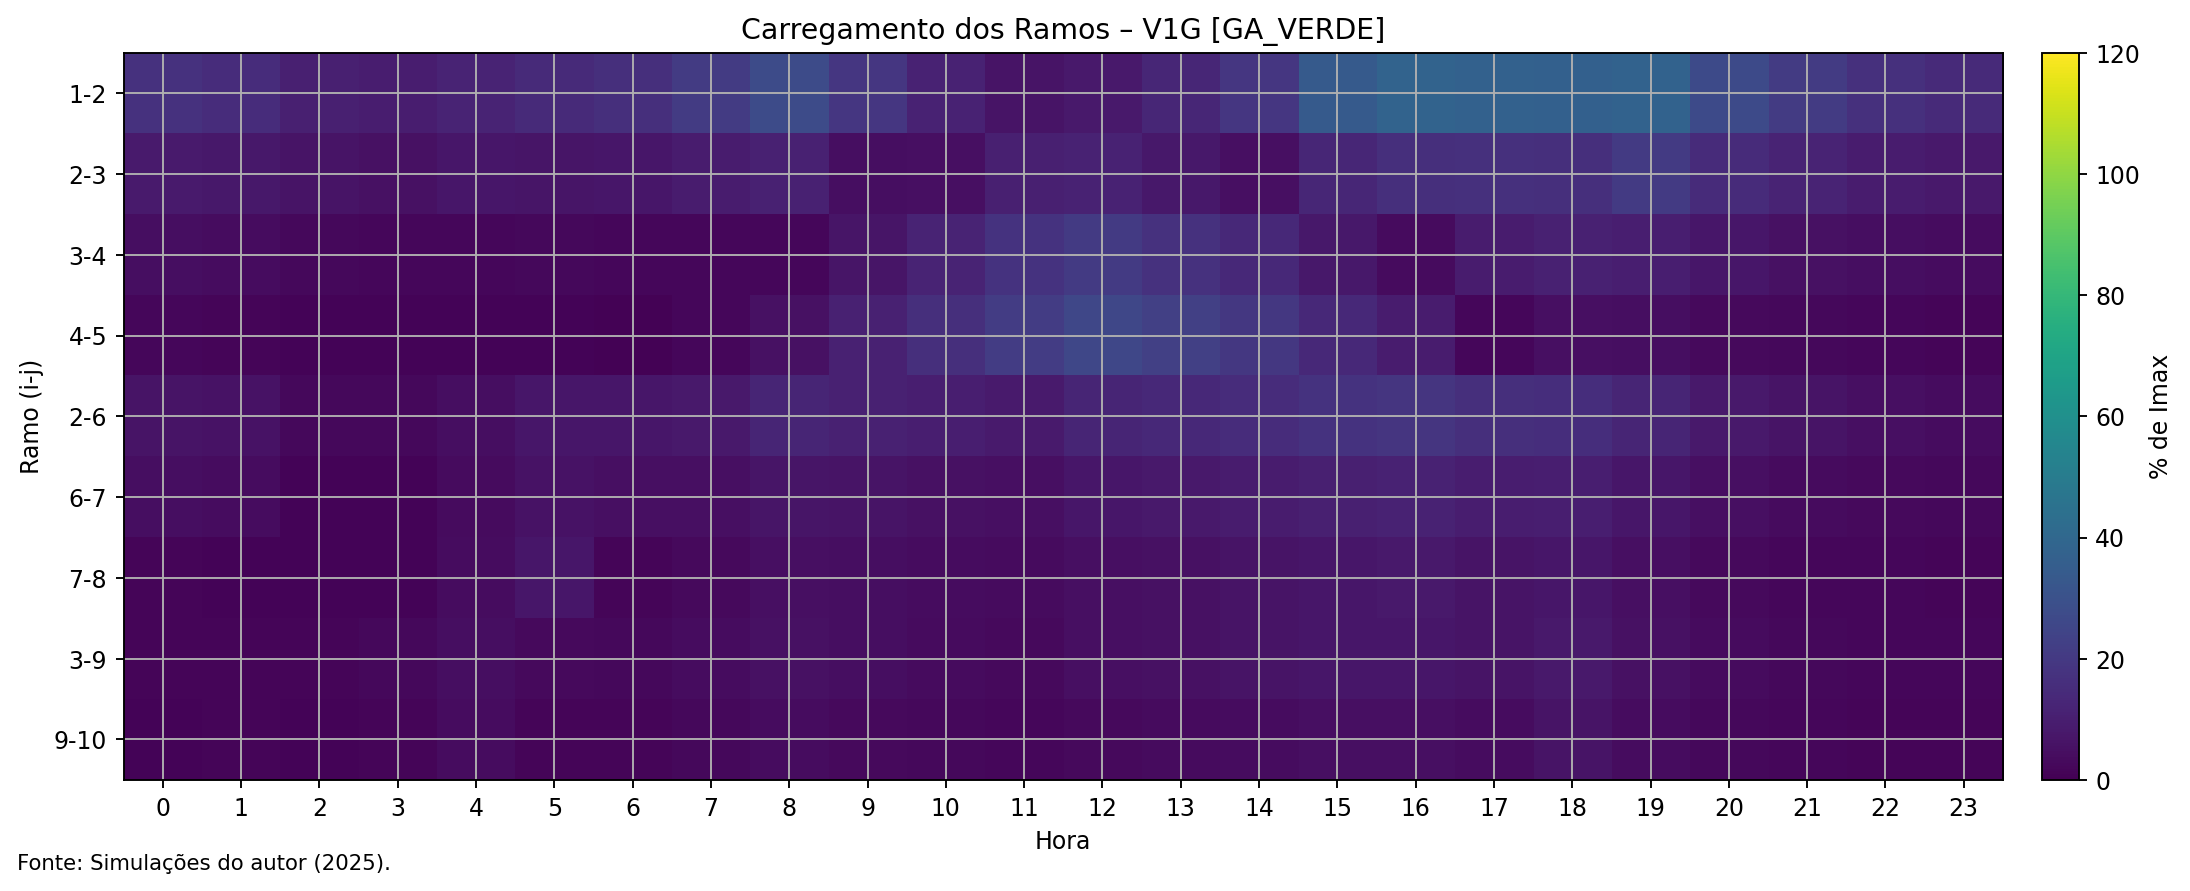

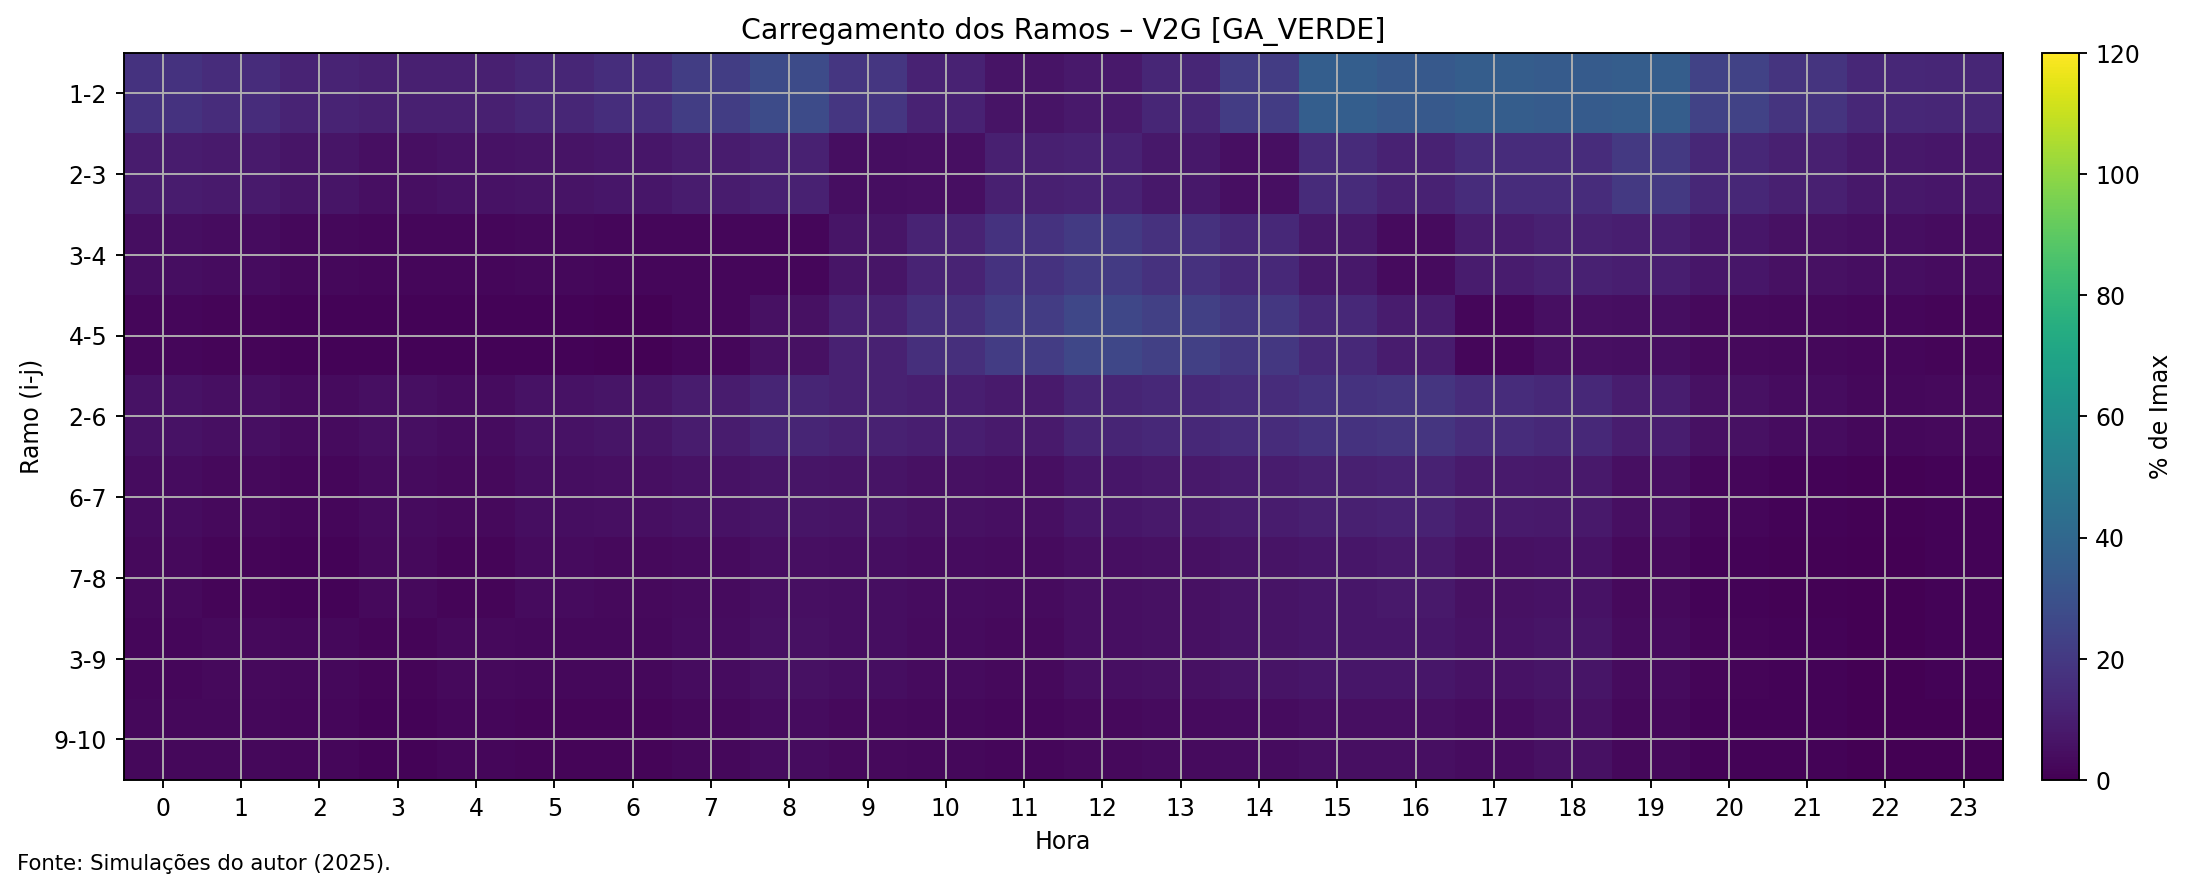

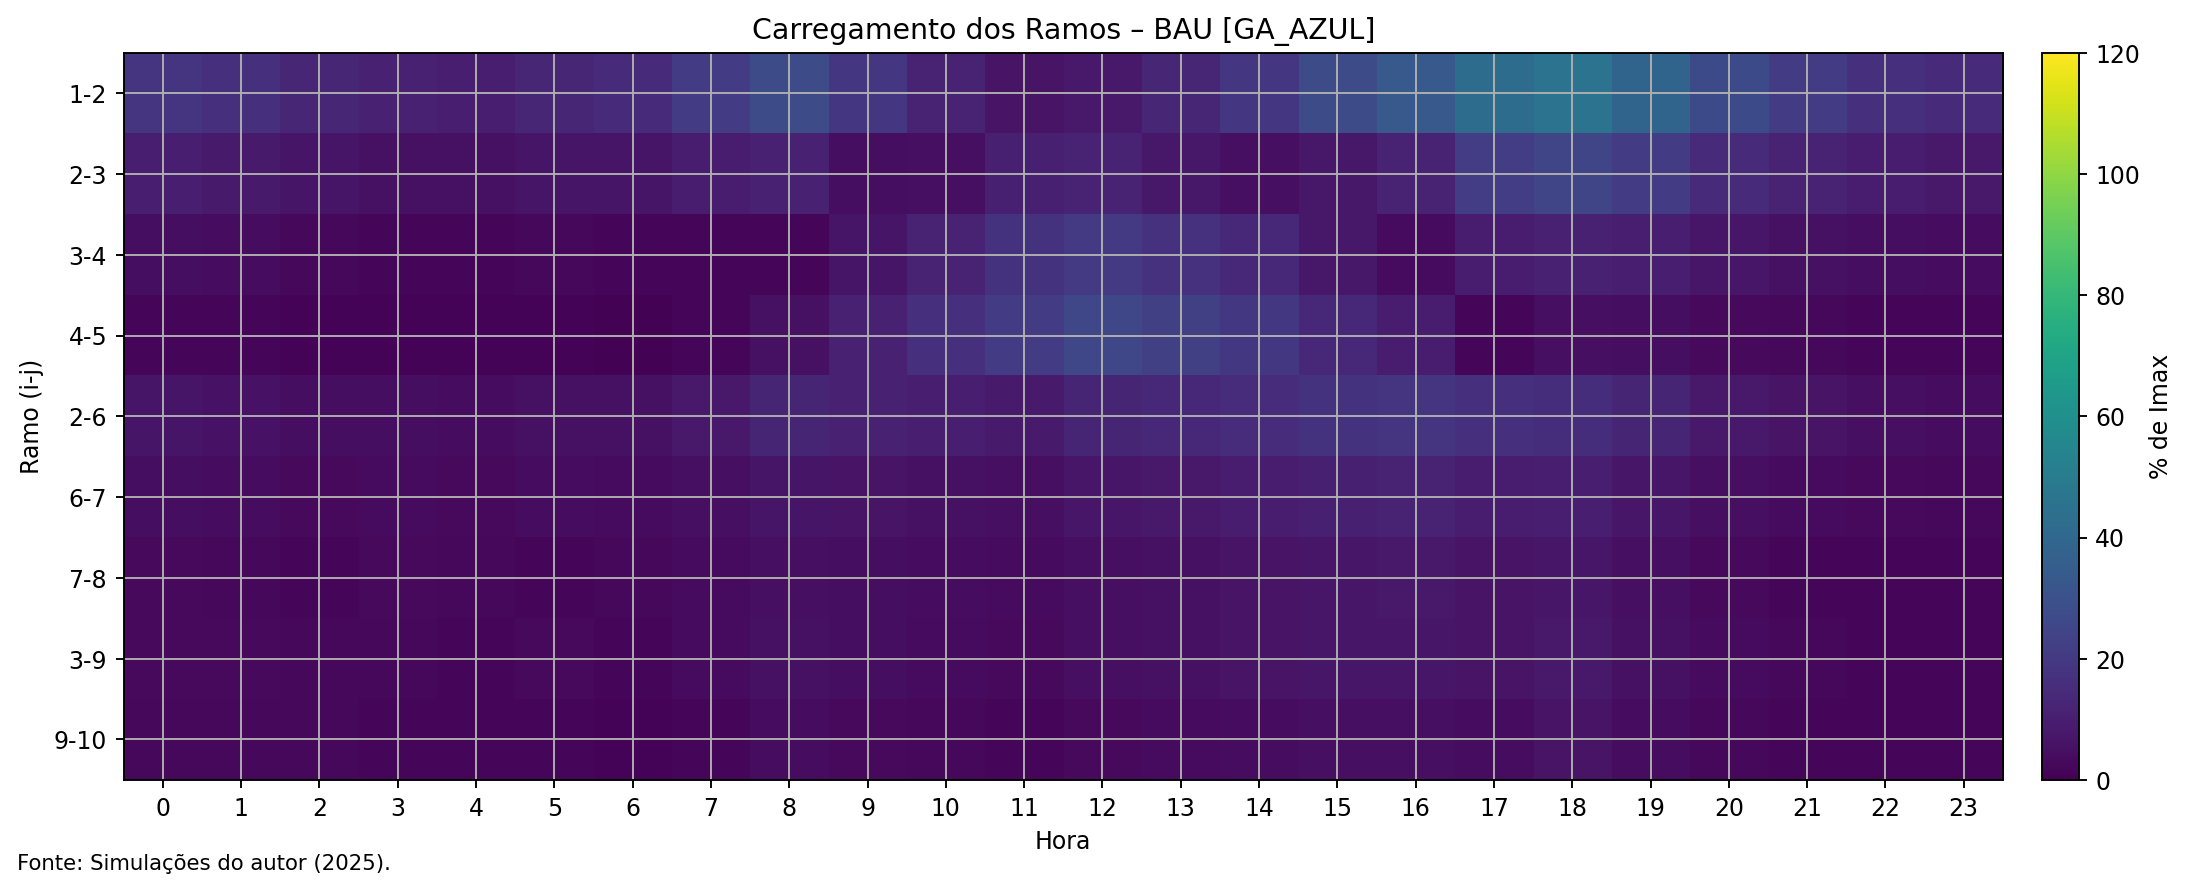

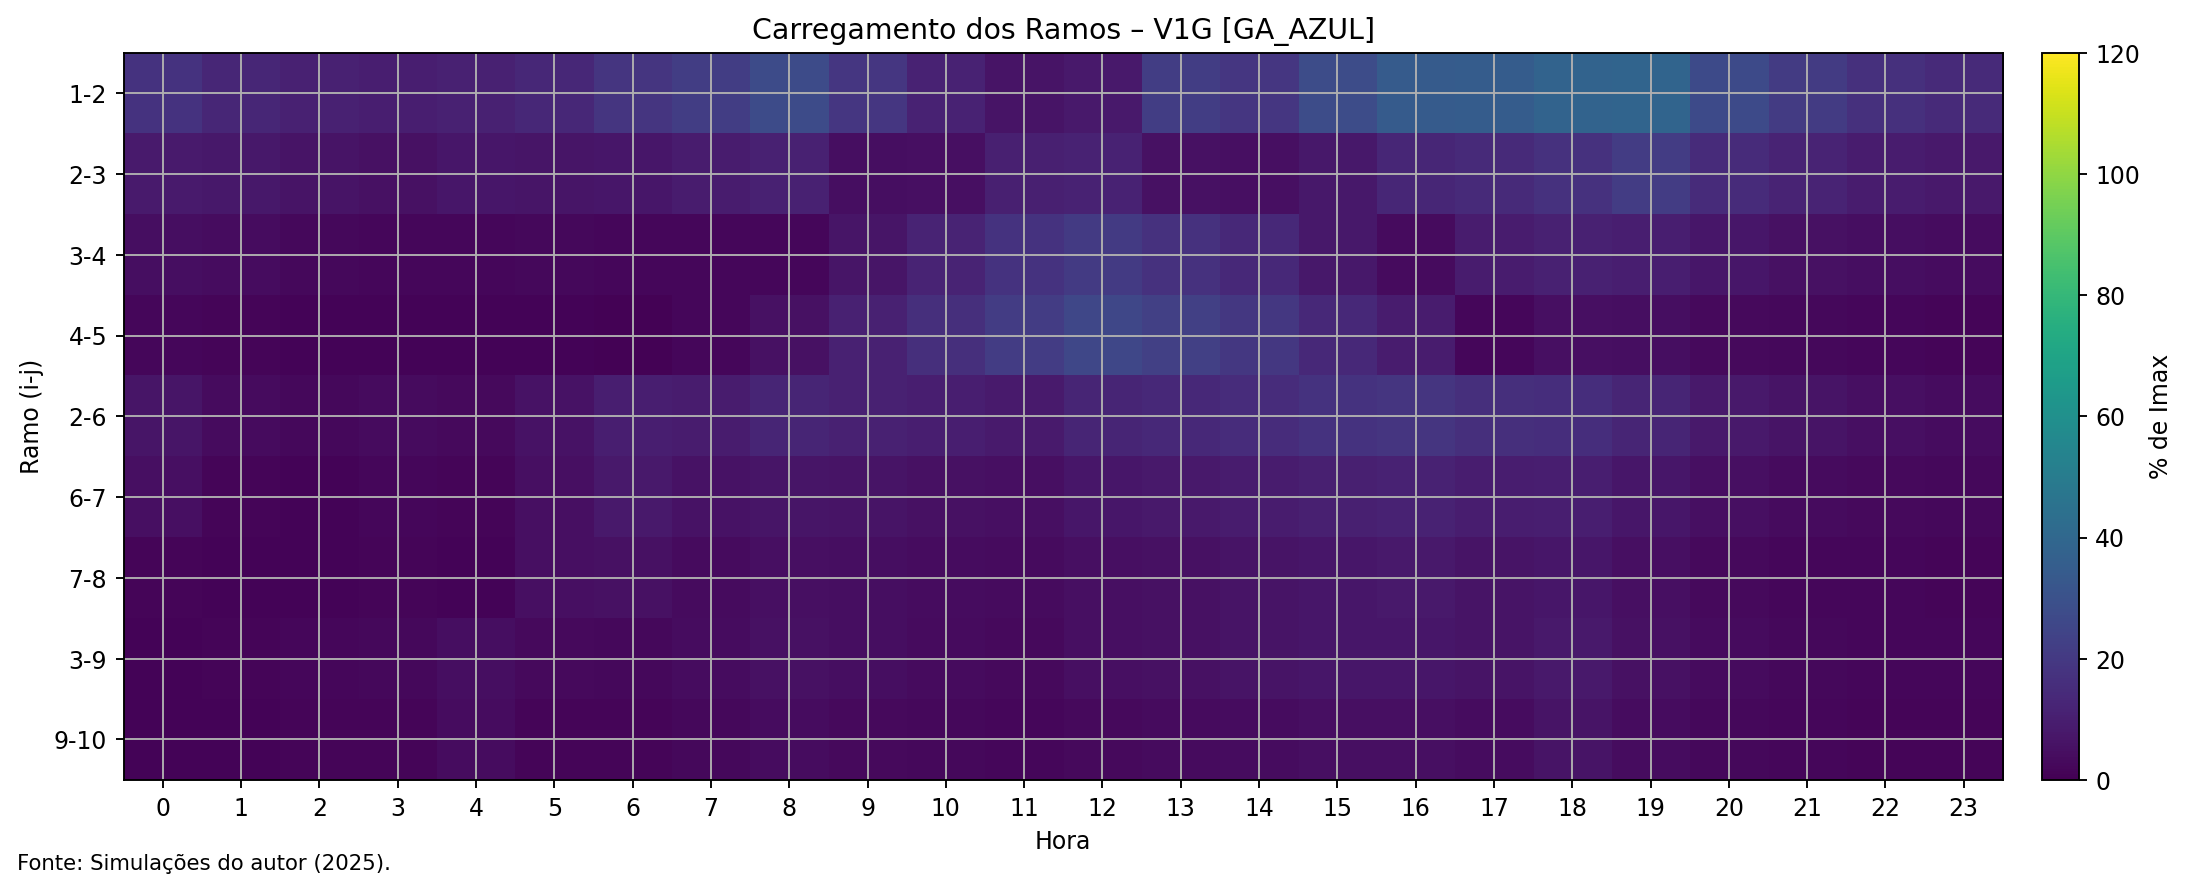

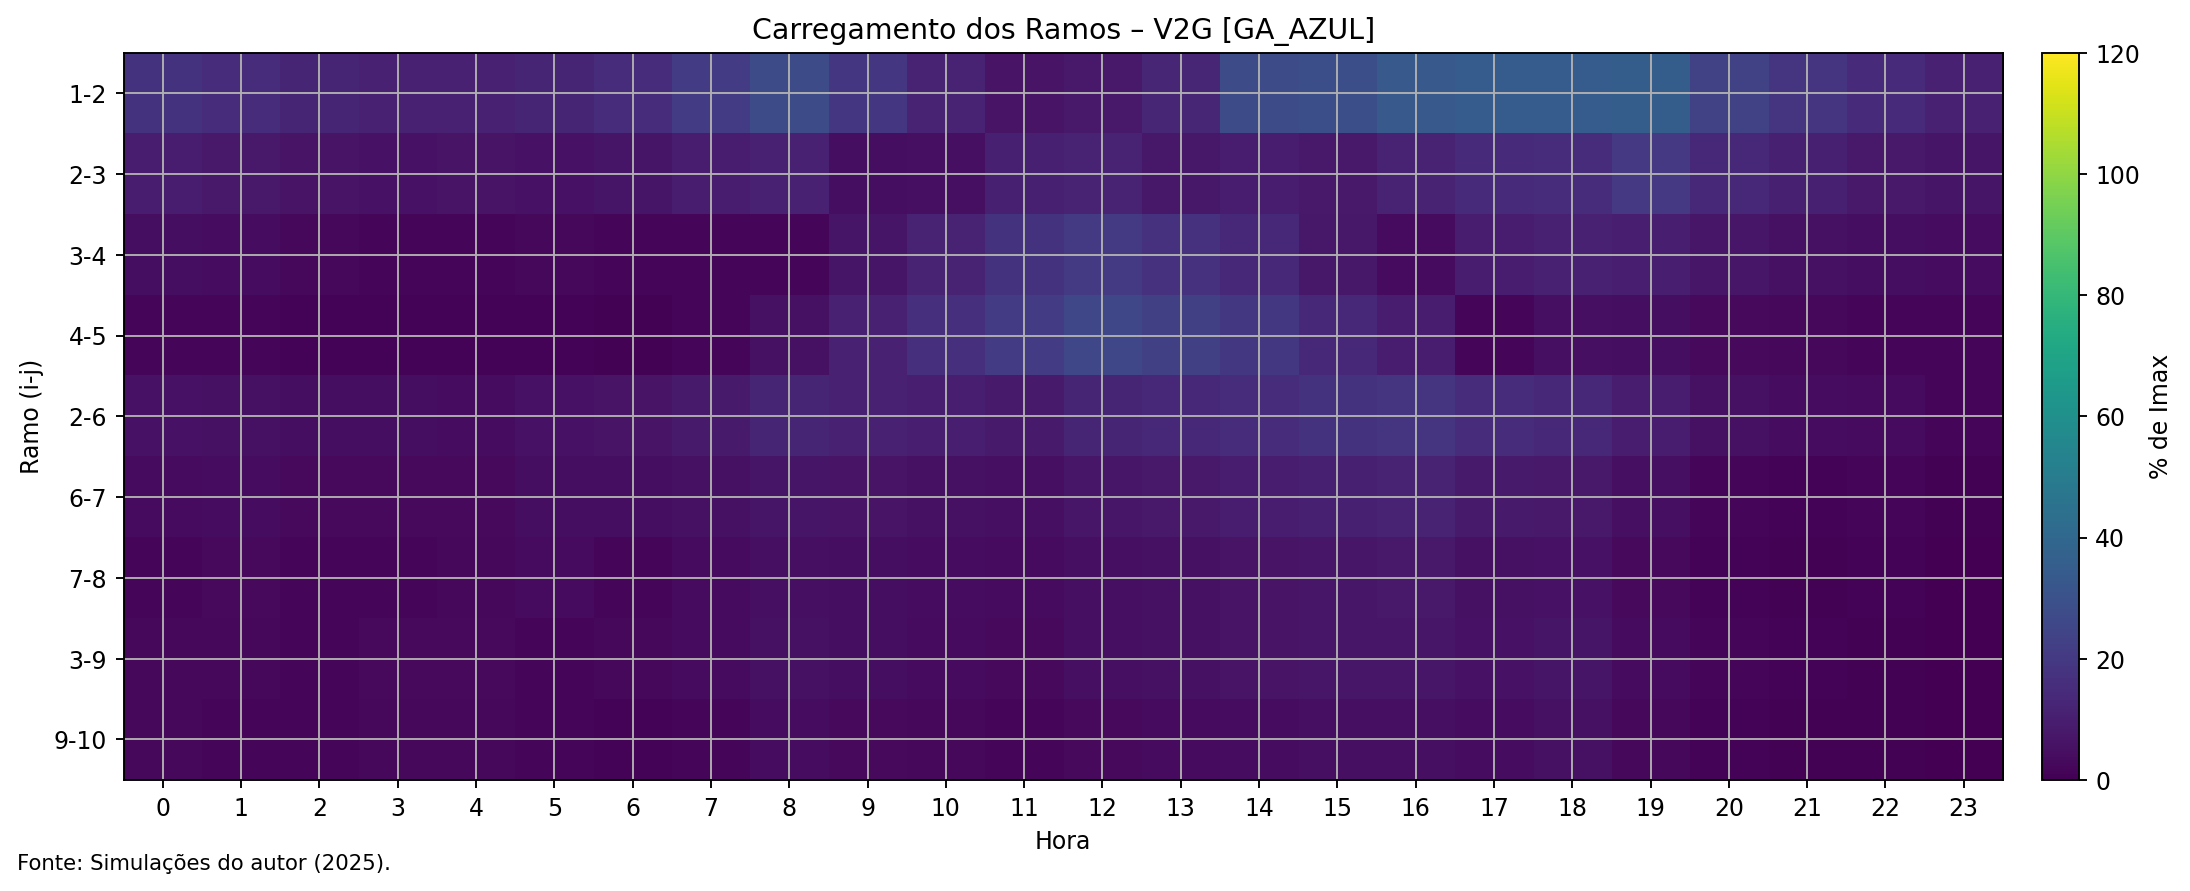

In [16]:
# ============================================================
# BLOCO DE VISUALIZAÇÃO – KPIs com legenda limpa + HEATMAPS
# (colar e rodar após o código principal)
# ============================================================
import numpy as np, math, os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Image as IPyImage
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.grid"] = True

# ---------- Helpers de formatação ----------
def _fmt_brl(x):
    s=f"R$ {x:,.2f}"
    return s.replace(",", "X").replace(".", ",").replace("X",".")
def _fmt_kw(x):
    return (f"{int(round(x))} kW" if abs(x-int(round(x)))<1e-9 else f"{x:.1f} kW".replace(".",","))
def _fmt_pu(x,casas=3):
    return f"{x:.{casas}f} p.u.".replace(".",",")
def _annotate(ax, rects, fmt, dy=0.02):
    y0,y1=ax.get_ylim(); span=max(y1-y0,1)
    for r in rects:
        v=r.get_height()
        ax.text(r.get_x()+r.get_width()/2, v+dy*span, fmt(v), ha="center", va="bottom", fontsize=9)

# ---------- KPI “single” com legenda limpa ----------
def plot_kpis_single_clean(df_kpis, out_path, dpi=180):
    scen=list(df_kpis.index)
    custo=df_kpis['Custo Total (R$)'].values.astype(float)
    pico =df_kpis['Pico de Demanda (kW)'].values.astype(float)
    vmin =df_kpis['Tensão Mínima (p.u.)'].values.astype(float)

    width=0.36
    x=np.arange(len(scen))
    fig,ax1=plt.subplots(figsize=(11.5,6),dpi=dpi)
    fig.suptitle("KPIs Globais",fontsize=16)

    r1=ax1.bar(x-width/2,custo,width=width)
    ax1.set_ylabel("R$"); ax1.grid(True,axis='y',alpha=0.25); ax1.set_xticks(x,scen)
    _annotate(ax1,r1,_fmt_brl)

    ax2=ax1.twinx()
    r2=ax2.bar(x+width/2,pico,width=width,alpha=0.9)
    ax2.set_ylabel("kW")
    _annotate(ax2,r2,_fmt_kw)

    ax3=ax1.twinx()
    ax3.spines.right.set_position(("axes",1.12))
    ax3.set_ylabel("Tensão mínima (p.u.)")
    ax3.set_ylim(min(0.945,vmin.min()-0.005), max(1.005,vmin.max()+0.005))
    l3,=ax3.plot(x,vmin,marker="o",linestyle="-",linewidth=2.0)

    p1 = Patch(facecolor=r1[0].get_facecolor(), label="Custo Total (R$)")
    p2 = Patch(facecolor=r2[0].get_facecolor(), label="Pico de Demanda (kW)")
    p3 = Line2D([0],[0], color=l3.get_color(), marker='o', linewidth=2.0, label="Tensão Mínima (p.u.)")
    ax1.legend(handles=[p1,p2,p3], loc="upper center", bbox_to_anchor=(0.5,1.12), ncol=3, frameon=False)

    plt.tight_layout(rect=[0,0,1,0.94])
    plt.figtext(0.01,0.01,"Fonte: Simulações do autor (2025).",fontsize=9)
    plt.savefig(out_path,bbox_inches="tight"); plt.close()

# ---------- Mostrar todas as figuras PNG existentes ----------
def show_all_figs(structures=("B","GA_VERDE","GA_AZUL"), width=1050):
    templates = [
        "kpi_global_triptych_{s}.png",
        "kpi_global_single_{s}.png",
        "soc_v2g_legenda_fora_{s}.png",
        "soc_v2g_legenda_dentro_{s}.png",
        "custos_BAU_vertical_{s}.png",
        "custos_V1G_vertical_{s}.png",
        "custos_V2G_vertical_{s}.png",
        "custos_V2G_horizontal_{s}.png",
        "despacho_BAU_{s}.png",
        "despacho_V1G_{s}.png",
        "despacho_V2G_{s}.png",
    ]
    for s in structures:
        display(HTML(f"<h2 style='margin:16px 0'>Estrutura: {s}</h2>"))
        for t in templates:
            fname = t.format(s=s)
            if os.path.exists(fname):
                display(HTML(f"<div style='font-weight:600;margin:8px 0'>{fname}</div>"))
                display(IPyImage(filename=fname, width=width))
            else:
                display(HTML(f"<div style='color:#a00'>[Aviso] Arquivo não encontrado: {fname}</div>"))

# ---------- HEATMAP: carregamento dos ramos ----------
# Calcula P_ij e Q_ij por hora a partir das injeções nodais (radial)
def _tree_helpers_from_A6(A6):
    nodes = sorted(set(A6["From"]).union(set(A6["To"])))
    E = [(int(r.From), int(r.To)) for _,r in A6.iterrows()]
    children = {n:[] for n in nodes}
    parent = {n:None for n in nodes}
    for i,j in E:
        children[i].append(j); parent[j]=i
    order = sorted(E, key=lambda e: e[1], reverse=True)  # rascunho de pós-ordem por índice
    return nodes, E, children, parent, order

def _compute_branch_flows(P_net_node, Q_net_node, E, children, parent, order):
    # P_net_node/Q_net_node: dict node->array(24)
    T = len(next(iter(P_net_node.values())))
    Pbr = {e:np.zeros(T) for e in E}
    Qbr = {e:np.zeros(T) for e in E}
    # pós-ordem: das folhas para a raiz
    for t in range(T):
        # acumular por subárvore
        # percorre arestas de quem é "mais fundo" para cima
        for (i,j) in order:
            Pbr[(i,j)][t] = P_net_node[j][t] + sum(Pbr[(j,k)][t] for k in children[j])
            Qbr[(i,j)][t] = Q_net_node[j][t] + sum(Qbr[(j,k)][t] for k in children[j])
    return Pbr, Qbr

def _build_injections_from_result(res, A3, A4, A11_ev, BESS_node, PV_nodes, EV_node_map, TANPHI):
    # Carga ativa/reativa por nó
    nodes = [int(c.split("_")[1]) for c in A3.columns if c.startswith("no_")]
    T = 24
    P_load = {j: np.array([A3.loc[t, f"no_{j}_kW"]/1000.0 for t in range(T)]) for j in nodes}
    Q_load = {j: P_load[j]*TANPHI for j in nodes}

    # PV (por nó)
    pv_node = {n: res["pv_node_MW"][n] for n in nodes}  # já é MW por hora

    # BESS (no nó BESS): positivo = descarga, negativo = carga
    bess_net = res["bess_dis_MW"] - res["bess_ch_MW"]

    # EVs por nó
    Tarr = np.arange(T)
    ev_net_node = {n: np.zeros(T) for n in nodes}
    for i in range(res["ev_dis_MW"].shape[0]):
        node = EV_node_map[i]
        ev_net_node[node] += (res["ev_dis_MW"][i] - res["ev_ch_MW"][i])

    # Injeção líquida ativa/reativa por nó (positiva = geração)
    P_gen = {j: np.zeros(T) for j in nodes}
    for j in nodes:
        if j in PV_nodes: P_gen[j] += pv_node[j]
        if j == BESS_node: P_gen[j] += bess_net
        # EVs:
        P_gen[j] += ev_net_node[j]
    # Ativa líquida do ponto de vista da rede: carga - geração
    P_net = {j: P_load[j] - P_gen[j] for j in nodes}
    # Reativa: só carga (não modelamos Q dos DERs)
    Q_net = {j: Q_load[j] for j in nodes}

    return P_net, Q_net

def heatmap_branch_loading(structure_code="B", scenario="BAU",
                           vmax_pct=120, cmap="viridis", dpi=170, show_values=False):
    # 1) Reexecuta o cenário para obter despachos (rápido e idêntico ao principal)
    price = build_energy_price_array(structure_code)
    demand = build_demand_tariff(structure_code)
    setup = {"structure":structure_code,"price":price,"demand":demand}
    res = run_scenario(setup, {"BAU":"BAU","V1G":"V1G","V2G":"V2G"}[scenario])

    # 2) Reconstrói injeções nodais e fluxos por ramo/hora
    nodes, E, children, parent, order = _tree_helpers_from_A6(A6)
    EV_node_map = {int(r.VE)-1:int(r.node) for _,r in A11_ev.iterrows()}
    P_net, Q_net = _build_injections_from_result(res, A3, A4, A11_ev, int(A11_bess["node"].iloc[0]),
                                                 list(A11_pv["node"]), EV_node_map, TANPHI)
    Pbr, Qbr = _compute_branch_flows(P_net, Q_net, E, children, parent, order)

    # 3) Carregamento (%) = sqrt(P^2 + Q^2) / Imax * 100
    Imax = {(int(r.From),int(r.To)):float(r.I_max_pu) for _,r in A6.iterrows()}
    edges = list(Pbr.keys())
    edges_lbl = [f"{i}-{j}" for (i,j) in edges]
    T=24
    load_pct = np.zeros((len(edges), T))
    for idx,e in enumerate(edges):
        S = np.sqrt(Pbr[e]**2 + Qbr[e]**2)
        load_pct[idx,:] = (S / Imax[e]) * 100.0

    # 4) Plot heatmap
    fig,ax=plt.subplots(figsize=(13,5.5),dpi=dpi)
    im=ax.imshow(load_pct, aspect="auto", origin="upper", cmap=cmap, vmin=0, vmax=vmax_pct)
    ax.set_title(f"Carregamento dos Ramos – {scenario} [{structure_code}]")
    ax.set_xlabel("Hora"); ax.set_ylabel("Ramo (i-j)")
    ax.set_xticks(range(T)); ax.set_xticklabels(range(T))
    ax.set_yticks(range(len(edges))); ax.set_yticklabels(edges_lbl)
    cbar=plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("% de Imax")

    if show_values:
        for i in range(load_pct.shape[0]):
            for j in range(load_pct.shape[1]):
                ax.text(j, i, f"{load_pct[i,j]:.0f}", ha="center", va="center", fontsize=7, color="white")
    plt.figtext(0.01,0.01,"Fonte: Simulações do autor (2025).",fontsize=9)
    fname=f"heatmap_carregamento_{scenario}_{structure_code}.png"
    plt.tight_layout(rect=[0,0,1,0.95]); plt.savefig(fname,bbox_inches="tight"); plt.close()
    display(HTML(f"<div style='font-weight:600;margin:8px 0'>{fname}</div>"))
    display(IPyImage(filename=fname, width=1100))

# ---------- Painel completo de resultados ----------
def painel_resultados(structures=("B","GA_VERDE","GA_AZUL"),
                      cenarios=("BAU","V1G","V2G"),
                      refazer_kpi_single=True):
    display(HTML("<h2 style='margin:16px 0'>Painel de Resultados</h2>"))

    # 1) (opcional) Recriar KPI single com legenda limpa a partir do df_kpis_results já produzido
    if refazer_kpi_single:
        for s in structures:
            if s in df_kpis_results:
                out=f"kpi_global_single_{s}.png"
                plot_kpis_single_clean(df_kpis_results[s][['Custo Total (R$)','Pico de Demanda (kW)','Tensão Mínima (p.u.)']], out)
        display(HTML("<div style='margin:6px 0'>KPIs “single” recriados com legenda limpa.</div>"))

    # 2) Mostrar todas as figuras PNG existentes
    show_all_figs(structures)

    # 3) Heatmaps de carregamento por cenário/estrutura
    for s in structures:
        display(HTML(f"<h3 style='margin:12px 0'>Mapas de Calor – {s}</h3>"))
        for c in cenarios:
            heatmap_branch_loading(structure_code=s, scenario=c, vmax_pct=120, cmap="viridis", dpi=170, show_values=False)

# ====== Executar o painel (chame quando quiser) ======
painel_resultados(structures=("B","GA_VERDE","GA_AZUL"), cenarios=("BAU","V1G","V2G"))

